In [3]:
# ============================================================
# STEP 88A: SET PROJECT ROOT
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

print("📁 Current notebook folder:")
print(Path.cwd())

print("\n📁 Project root:")
print(PROJECT_ROOT)

print("\n✅ STEP 88A COMPLETED")

📁 Current notebook folder:
c:\Users\saura\OneDrive\Pictures\Documents\Drought_Severity_Mapping(2)\notebooks

📁 Project root:
c:\Users\saura\OneDrive\Pictures\Documents\Drought_Severity_Mapping(2)

✅ STEP 88A COMPLETED


In [4]:
# ============================================================
# STEP 88: LOAD DATA FROM DATASET ANALYSIS
# ============================================================

print("============================================================")
print("STEP 88: LOADING ANALYSIS DATA")
print("============================================================")

# Path to saved analysis tables
statistics_folder = (
    PROJECT_ROOT
    / "results"
    / "statistics"
)

# Load metadata
metadata_path = statistics_folder / "metadata_analysis.csv"

df_processed = pd.read_csv(
    metadata_path
)

# Load satellite image statistics
satellite_path = (
    statistics_folder
    / "satellite_image_statistics.csv"
)

image_stats_df = pd.read_csv(
    satellite_path
)

# Load A/B pair statistics
pair_path = (
    statistics_folder
    / "satellite_ab_pair_statistics.csv"
)

ab_pairs_df = pd.read_csv(
    pair_path
)

# ------------------------------------------------------------
# Display loaded data
# ------------------------------------------------------------

print("\n🌍 Metadata records:", len(df_processed))
print("📡 Satellite image records:", len(image_stats_df))
print("🔗 A/B pair records:", len(ab_pairs_df))

print("\n📋 Metadata columns:")
print(list(df_processed.columns))

print("\n📋 Satellite columns:")
print(list(image_stats_df.columns))

print("\n📋 A/B pair columns:")
print(list(ab_pairs_df.columns))

print("\n============================================================")
print("✅ STEP 88 COMPLETED")
print("============================================================")

STEP 88: LOADING ANALYSIS DATA

🌍 Metadata records: 1100
📡 Satellite image records: 2200
🔗 A/B pair records: 1100

📋 Metadata columns:
['Unnamed: 0', 'Initial dates', 'End dates', 'Latitud', 'Longitudes', 'Cloudiness Mean', 'Water percentage Mean', 'Vegetation percentage Mean', 'Year', 'Month', 'Duration_Days']

📋 Satellite columns:
['Image_ID', 'NDVI_Min', 'NDVI_Max', 'NDVI_Mean', 'NDVI_Std', 'RGB_Min', 'RGB_Max', 'RGB_Mean', 'RGB_Std', 'VV_Min', 'VV_Max', 'VV_Mean', 'VV_Std', 'VH_Min', 'VH_Max', 'VH_Mean', 'VH_Std']

📋 A/B pair columns:
['Base_ID', 'Image_ID_A_ID', 'NDVI_Mean_A', 'NDVI_Std_A', 'RGB_Mean_A', 'RGB_Std_A', 'VV_Mean_A', 'VV_Std_A', 'VH_Mean_A', 'VH_Std_A', 'Image_ID_B_ID', 'NDVI_Mean_B', 'NDVI_Std_B', 'RGB_Mean_B', 'RGB_Std_B', 'VV_Mean_B', 'VV_Std_B', 'VH_Mean_B', 'VH_Std_B']

✅ STEP 88 COMPLETED


In [5]:
# ============================================================
# STEP 89: INSPECT A/B PAIR STRUCTURE
# ============================================================

print("============================================================")
print("STEP 89: INSPECTING A/B PAIR STRUCTURE")
print("============================================================")

print("\n📋 A/B PAIR COLUMNS")
print("============================================================")

for i, column in enumerate(ab_pairs_df.columns, start=1):
    print(f"{i}. {column}")

print("\n📊 Shape:")
print(ab_pairs_df.shape)

print("\n📋 First 10 A/B pair records:")
display(ab_pairs_df.head(10))

print("\n📋 Data types:")
display(
    ab_pairs_df.dtypes.to_frame("Data_Type")
)

print("\n============================================================")
print("🔎 UNIQUE VALUES OF IDENTIFIER COLUMNS")
print("============================================================")

# Display likely identifier columns without assuming their names
for column in ab_pairs_df.columns:

    if (
        "id" in column.lower()
        or "base" in column.lower()
        or "image" in column.lower()
    ):
        print(f"\n📌 {column}")
        print(
            ab_pairs_df[column]
            .astype(str)
            .head(20)
            .tolist()
        )

print("\n============================================================")
print("✅ STEP 89 COMPLETED")
print("============================================================")

STEP 89: INSPECTING A/B PAIR STRUCTURE

📋 A/B PAIR COLUMNS
1. Base_ID
2. Image_ID_A_ID
3. NDVI_Mean_A
4. NDVI_Std_A
5. RGB_Mean_A
6. RGB_Std_A
7. VV_Mean_A
8. VV_Std_A
9. VH_Mean_A
10. VH_Std_A
11. Image_ID_B_ID
12. NDVI_Mean_B
13. NDVI_Std_B
14. RGB_Mean_B
15. RGB_Std_B
16. VV_Mean_B
17. VV_Std_B
18. VH_Mean_B
19. VH_Std_B

📊 Shape:
(1100, 19)

📋 First 10 A/B pair records:


,Base_ID,Image_ID_A_ID,NDVI_Mean_A,NDVI_Std_A,RGB_Mean_A,RGB_Std_A,VV_Mean_A,VV_Std_A,VH_Mean_A,VH_Std_A,Image_ID_B_ID,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
0,0,0A,0.419874,0.188054,59.358520,29.101707,98.943370,25.149336,36.220520,35.769710,0B,0.442054,0.205206,62.659954,27.149958,95.604490,22.078629,29.585190,31.129162
1,1000,1000A,0.857682,0.071245,22.158844,11.020837,135.655690,12.117051,82.304985,10.564413,1000B,0.761015,0.108656,34.780136,14.468691,121.115050,14.322373,72.604520,12.334583
2,1001,1001A,0.323438,0.120328,104.260010,33.635567,115.642204,15.816455,62.008648,18.568058,1001B,0.309842,0.132019,102.217865,32.433945,122.817604,21.104383,63.998200,19.871744
3,1002,1002A,0.361400,0.061198,75.003140,26.774780,110.184230,11.780373,56.584564,14.461262,1002B,0.387951,0.050842,69.204414,21.700020,107.664345,11.338058,50.158504,13.032197
4,1003,1003A,0.624415,0.158128,36.169903,21.973907,97.653564,25.679062,47.102170,25.780767,1003B,0.542685,0.155566,39.057600,20.560713,108.538610,36.763180,44.221790,31.111513
5,1004,1004A,0.357287,0.210149,92.879295,49.762720,128.750980,19.020260,68.039240,19.354170,1004B,0.364991,0.169939,87.094990,40.758420,135.894170,32.042400,79.475350,27.093605
6,1005,1005A,0.466249,0.201184,74.175835,46.759580,118.126000,18.064070,61.866640,19.501114,1005B,0.565064,0.208042,57.467890,46.084328,114.685790,17.135977,65.519780,19.937794
7,1006,1006A,0.654756,0.105552,48.419086,11.316570,143.532270,14.426009,88.455690,13.346479,1006B,0.678706,0.105768,47.546480,11.700925,147.192580,10.296534,93.254395,9.776903
8,1007,1007A,0.404344,0.225213,76.241234,44.715534,94.728780,31.291378,37.506737,36.451870,1007B,0.411729,0.228897,76.943530,48.155490,98.320180,29.523685,41.351720,36.464863
9,1008,1008A,0.290414,0.241412,95.944680,47.157450,94.035545,26.086205,38.083710,27.210384,1008B,0.436751,0.184484,73.235250,28.380226,101.604350,21.564028,47.310894,26.779415



📋 Data types:


,Data_Type
Base_ID,int64
Image_ID_A_ID,str
NDVI_Mean_A,float64
NDVI_Std_A,float64
RGB_Mean_A,float64
RGB_Std_A,float64
VV_Mean_A,float64
VV_Std_A,float64
VH_Mean_A,float64
VH_Std_A,float64



🔎 UNIQUE VALUES OF IDENTIFIER COLUMNS

📌 Base_ID
['0', '1000', '1001', '1002', '1003', '1004', '1005', '1006', '1007', '1008', '1009', '100', '1010', '1011', '1012', '1013', '1014', '1015', '1016', '1017']

📌 Image_ID_A_ID
['0A', '1000A', '1001A', '1002A', '1003A', '1004A', '1005A', '1006A', '1007A', '1008A', '1009A', '100A', '1010A', '1011A', '1012A', '1013A', '1014A', '1015A', '1016A', '1017A']

📌 Image_ID_B_ID
['0B', '1000B', '1001B', '1002B', '1003B', '1004B', '1005B', '1006B', '1007B', '1008B', '1009B', '100B', '1010B', '1011B', '1012B', '1013B', '1014B', '1015B', '1016B', '1017B']

✅ STEP 89 COMPLETED


In [6]:
# ============================================================
# STEP 90: VERIFY A/B PAIR CONSISTENCY
# ============================================================

print("============================================================")
print("STEP 90: VERIFYING A/B PAIR CONSISTENCY")
print("============================================================")

# Convert identifiers to strings for safe comparison
base_ids = ab_pairs_df["Base_ID"].astype(str)
image_a_ids = ab_pairs_df["Image_ID_A_ID"].astype(str)
image_b_ids = ab_pairs_df["Image_ID_B_ID"].astype(str)

# Expected IDs
expected_a_ids = base_ids + "A"
expected_b_ids = base_ids + "B"

# Check A consistency
a_mismatch = image_a_ids != expected_a_ids

# Check B consistency
b_mismatch = image_b_ids != expected_b_ids

print("\n📊 PAIR COUNT")
print("============================================================")
print("Total A/B pairs:", len(ab_pairs_df))

print("\n🔎 A IMAGE-ID CONSISTENCY")
print("============================================================")
print("A mismatches:", a_mismatch.sum())

print("\n🔎 B IMAGE-ID CONSISTENCY")
print("============================================================")
print("B mismatches:", b_mismatch.sum())

# ------------------------------------------------------------
# Show mismatches if any
# ------------------------------------------------------------

if a_mismatch.sum() > 0:

    print("\n⚠️ First A mismatches:")
    display(
        ab_pairs_df.loc[
            a_mismatch,
            [
                "Base_ID",
                "Image_ID_A_ID"
            ]
        ].head(10)
    )

if b_mismatch.sum() > 0:

    print("\n⚠️ First B mismatches:")
    display(
        ab_pairs_df.loc[
            b_mismatch,
            [
                "Base_ID",
                "Image_ID_B_ID"
            ]
        ].head(10)
    )

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n============================================================")
print("📌 FINAL PAIR CONSISTENCY RESULT")
print("============================================================")

if (
    len(ab_pairs_df) == 1100
    and a_mismatch.sum() == 0
    and b_mismatch.sum() == 0
):
    print("✅ Exactly 1100 A/B pairs found.")
    print("✅ Every A image matches its Base_ID.")
    print("✅ Every B image matches its Base_ID.")
    print("✅ A/B pair structure is consistent.")
else:
    print("⚠️ A/B pair consistency requires investigation.")

print("\n============================================================")
print("✅ STEP 90 COMPLETED")
print("============================================================")

STEP 90: VERIFYING A/B PAIR CONSISTENCY

📊 PAIR COUNT
Total A/B pairs: 1100

🔎 A IMAGE-ID CONSISTENCY
A mismatches: 0

🔎 B IMAGE-ID CONSISTENCY
B mismatches: 0

📌 FINAL PAIR CONSISTENCY RESULT
✅ Exactly 1100 A/B pairs found.
✅ Every A image matches its Base_ID.
✅ Every B image matches its Base_ID.
✅ A/B pair structure is consistent.

✅ STEP 90 COMPLETED


In [7]:
# ============================================================
# STEP 91: CHECK A/B PAIR FEATURE COMPLETENESS
# ============================================================

print("============================================================")
print("STEP 91: CHECKING A/B PAIR FEATURE COMPLETENESS")
print("============================================================")

required_pair_columns = [
    "Base_ID",
    "Image_ID_A_ID",
    "NDVI_Mean_A",
    "NDVI_Std_A",
    "RGB_Mean_A",
    "RGB_Std_A",
    "VV_Mean_A",
    "VV_Std_A",
    "VH_Mean_A",
    "VH_Std_A",
    "Image_ID_B_ID",
    "NDVI_Mean_B",
    "NDVI_Std_B",
    "RGB_Mean_B",
    "RGB_Std_B",
    "VV_Mean_B",
    "VV_Std_B",
    "VH_Mean_B",
    "VH_Std_B"
]

print("\n📋 REQUIRED COLUMNS")
print("============================================================")

missing_columns = [
    column
    for column in required_pair_columns
    if column not in ab_pairs_df.columns
]

if len(missing_columns) == 0:
    print("✅ All required A/B feature columns are present.")
else:
    print("⚠️ Missing columns:")
    for column in missing_columns:
        print(" -", column)

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("\n🔎 MISSING VALUES IN A/B FEATURES")
print("============================================================")

pair_missing = ab_pairs_df[
    required_pair_columns
].isnull().sum()

display(
    pair_missing[
        pair_missing > 0
    ].to_frame("Missing_Count")
)

total_missing = pair_missing.sum()

print("\nTotal missing A/B feature values:", total_missing)

# ------------------------------------------------------------
# Check numeric feature validity
# ------------------------------------------------------------

numeric_pair_columns = [
    column
    for column in required_pair_columns
    if column not in [
        "Base_ID",
        "Image_ID_A_ID",
        "Image_ID_B_ID"
    ]
]

non_numeric_columns = [
    column
    for column in numeric_pair_columns
    if not pd.api.types.is_numeric_dtype(
        ab_pairs_df[column]
    )
]

print("\n🔎 NUMERIC FEATURE CHECK")
print("============================================================")

if len(non_numeric_columns) == 0:
    print("✅ All satellite feature columns are numeric.")
else:
    print("⚠️ Non-numeric feature columns:")
    print(non_numeric_columns)

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n============================================================")
print("📌 FINAL FEATURE COMPLETENESS RESULT")
print("============================================================")

if (
    len(missing_columns) == 0
    and total_missing == 0
    and len(non_numeric_columns) == 0
):
    print("✅ A/B satellite feature table is complete.")
    print("✅ No required columns are missing.")
    print("✅ No missing feature values found.")
    print("✅ All feature columns are numeric.")
else:
    print("⚠️ A/B feature table requires investigation.")

print("\n============================================================")
print("✅ STEP 91 COMPLETED")
print("============================================================")

STEP 91: CHECKING A/B PAIR FEATURE COMPLETENESS

📋 REQUIRED COLUMNS
✅ All required A/B feature columns are present.

🔎 MISSING VALUES IN A/B FEATURES


,Missing_Count



Total missing A/B feature values: 0

🔎 NUMERIC FEATURE CHECK
✅ All satellite feature columns are numeric.

📌 FINAL FEATURE COMPLETENESS RESULT
✅ A/B satellite feature table is complete.
✅ No required columns are missing.
✅ No missing feature values found.
✅ All feature columns are numeric.

✅ STEP 91 COMPLETED


In [8]:
# ============================================================
# STEP 92: VERIFY SATELLITE FEATURE VALUE RANGES
# ============================================================

print("============================================================")
print("STEP 92: VERIFYING SATELLITE FEATURE VALUE RANGES")
print("============================================================")

feature_columns = [
    "NDVI_Mean_A",
    "NDVI_Std_A",
    "RGB_Mean_A",
    "RGB_Std_A",
    "VV_Mean_A",
    "VV_Std_A",
    "VH_Mean_A",
    "VH_Std_A",
    "NDVI_Mean_B",
    "NDVI_Std_B",
    "RGB_Mean_B",
    "RGB_Std_B",
    "VV_Mean_B",
    "VV_Std_B",
    "VH_Mean_B",
    "VH_Std_B"
]

print("\n📊 FEATURE VALUE RANGES")
print("============================================================")

range_summary = pd.DataFrame({
    "Minimum": ab_pairs_df[feature_columns].min(),
    "Maximum": ab_pairs_df[feature_columns].max(),
    "Mean": ab_pairs_df[feature_columns].mean(),
    "Std": ab_pairs_df[feature_columns].std()
})

display(range_summary.round(4))

# ------------------------------------------------------------
# Check NDVI range
# ------------------------------------------------------------

ndvi_columns = [
    "NDVI_Mean_A",
    "NDVI_Std_A",
    "NDVI_Mean_B",
    "NDVI_Std_B"
]

print("\n🌱 NDVI RANGE CHECK")
print("============================================================")

print(
    "NDVI feature minimum:",
    ab_pairs_df[ndvi_columns].min().min()
)

print(
    "NDVI feature maximum:",
    ab_pairs_df[ndvi_columns].max().max()
)

# ------------------------------------------------------------
# Check negative standard deviations
# ------------------------------------------------------------

std_columns = [
    "NDVI_Std_A",
    "RGB_Std_A",
    "VV_Std_A",
    "VH_Std_A",
    "NDVI_Std_B",
    "RGB_Std_B",
    "VV_Std_B",
    "VH_Std_B"
]

negative_std_count = (
    ab_pairs_df[std_columns] < 0
).sum().sum()

print("\n📐 STANDARD DEVIATION CHECK")
print("============================================================")

print(
    "Negative standard deviation values:",
    negative_std_count
)

# ------------------------------------------------------------
# Check non-finite values
# ------------------------------------------------------------

non_finite_count = (
    ~np.isfinite(
        ab_pairs_df[feature_columns]
    )
).sum().sum()

print("\n🔎 FINITE VALUE CHECK")
print("============================================================")

print(
    "Non-finite feature values:",
    non_finite_count
)

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n============================================================")
print("📌 FINAL VALUE RANGE RESULT")
print("============================================================")

if (
    negative_std_count == 0
    and non_finite_count == 0
):
    print("✅ No negative standard deviations.")
    print("✅ No NaN/Inf numeric feature values.")
    print("✅ Satellite feature values are ready for integration.")
else:
    print("⚠️ Some satellite feature values require investigation.")

print("\n============================================================")
print("✅ STEP 92 COMPLETED")
print("============================================================")

STEP 92: VERIFYING SATELLITE FEATURE VALUE RANGES

📊 FEATURE VALUE RANGES


,Minimum,Maximum,Mean,Std
NDVI_Mean_A,-0.8958,0.8958,0.5169,0.2190
NDVI_Std_A,0.0151,0.6332,0.1416,0.0778
RGB_Mean_A,9.0145,192.8857,55.7909,25.0325
RGB_Std_A,4.7021,97.6379,23.0628,11.5222
VV_Mean_A,18.4253,167.8052,118.7073,20.9964
VV_Std_A,5.9034,64.5402,19.9001,9.0183
VH_Mean_A,0.0000,112.8803,62.6150,22.7008
VH_Std_A,0.0000,48.9896,19.8402,7.6502
NDVI_Mean_B,-0.8752,0.9015,0.5202,0.2198
NDVI_Std_B,0.0125,0.6587,0.1409,0.0808



🌱 NDVI RANGE CHECK
NDVI feature minimum: -0.8957748
NDVI feature maximum: 0.9015417

📐 STANDARD DEVIATION CHECK
Negative standard deviation values: 0

🔎 FINITE VALUE CHECK
Non-finite feature values: 0

📌 FINAL VALUE RANGE RESULT
✅ No negative standard deviations.
✅ No NaN/Inf numeric feature values.
✅ Satellite feature values are ready for integration.

✅ STEP 92 COMPLETED


In [9]:
# ============================================================
# STEP 93: CREATE CLEAN A/B SATELLITE FEATURE TABLE
# ============================================================

print("============================================================")
print("STEP 93: CREATING CLEAN A/B SATELLITE FEATURE TABLE")
print("============================================================")

# Create a clean copy
satellite_pair_df = ab_pairs_df.copy()

# ------------------------------------------------------------
# Ensure identifier columns have consistent types
# ------------------------------------------------------------

satellite_pair_df["Base_ID"] = (
    satellite_pair_df["Base_ID"]
    .astype(str)
    .str.strip()
)

satellite_pair_df["Image_ID_A_ID"] = (
    satellite_pair_df["Image_ID_A_ID"]
    .astype(str)
    .str.strip()
)

satellite_pair_df["Image_ID_B_ID"] = (
    satellite_pair_df["Image_ID_B_ID"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# Check the cleaned table
# ------------------------------------------------------------

print("\n📊 CLEAN SATELLITE PAIR TABLE")
print("============================================================")

print("Rows   :", len(satellite_pair_df))
print("Columns:", len(satellite_pair_df.columns))

print("\n📋 Columns:")
print(list(satellite_pair_df.columns))

print("\n📋 First 5 records:")
display(
    satellite_pair_df.head()
)

# ------------------------------------------------------------
# Verify identifiers after cleaning
# ------------------------------------------------------------

identifier_check = (
    satellite_pair_df["Image_ID_A_ID"]
    == satellite_pair_df["Base_ID"] + "A"
)

identifier_check_b = (
    satellite_pair_df["Image_ID_B_ID"]
    == satellite_pair_df["Base_ID"] + "B"
)

print("\n🔎 IDENTIFIER VERIFICATION")
print("============================================================")

print(
    "A identifier mismatches:",
    (~identifier_check).sum()
)

print(
    "B identifier mismatches:",
    (~identifier_check_b).sum()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 CLEAN TABLE STATUS")
print("============================================================")

if (
    len(satellite_pair_df) == 1100
    and identifier_check.all()
    and identifier_check_b.all()
):
    print("✅ Clean satellite pair table created.")
    print("✅ 1100 A/B pairs retained.")
    print("✅ A identifiers verified.")
    print("✅ B identifiers verified.")
else:
    print("⚠️ Clean table requires investigation.")

print("\n============================================================")
print("✅ STEP 93 COMPLETED")
print("============================================================")

STEP 93: CREATING CLEAN A/B SATELLITE FEATURE TABLE

📊 CLEAN SATELLITE PAIR TABLE
Rows   : 1100
Columns: 19

📋 Columns:
['Base_ID', 'Image_ID_A_ID', 'NDVI_Mean_A', 'NDVI_Std_A', 'RGB_Mean_A', 'RGB_Std_A', 'VV_Mean_A', 'VV_Std_A', 'VH_Mean_A', 'VH_Std_A', 'Image_ID_B_ID', 'NDVI_Mean_B', 'NDVI_Std_B', 'RGB_Mean_B', 'RGB_Std_B', 'VV_Mean_B', 'VV_Std_B', 'VH_Mean_B', 'VH_Std_B']

📋 First 5 records:


,Base_ID,Image_ID_A_ID,NDVI_Mean_A,NDVI_Std_A,RGB_Mean_A,RGB_Std_A,VV_Mean_A,VV_Std_A,VH_Mean_A,VH_Std_A,Image_ID_B_ID,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
0,0,0A,0.419874,0.188054,59.358520,29.101707,98.943370,25.149336,36.220520,35.769710,0B,0.442054,0.205206,62.659954,27.149958,95.604490,22.078629,29.585190,31.129162
1,1000,1000A,0.857682,0.071245,22.158844,11.020837,135.655690,12.117051,82.304985,10.564413,1000B,0.761015,0.108656,34.780136,14.468691,121.115050,14.322373,72.604520,12.334583
2,1001,1001A,0.323438,0.120328,104.260010,33.635567,115.642204,15.816455,62.008648,18.568058,1001B,0.309842,0.132019,102.217865,32.433945,122.817604,21.104383,63.998200,19.871744
3,1002,1002A,0.361400,0.061198,75.003140,26.774780,110.184230,11.780373,56.584564,14.461262,1002B,0.387951,0.050842,69.204414,21.700020,107.664345,11.338058,50.158504,13.032197
4,1003,1003A,0.624415,0.158128,36.169903,21.973907,97.653564,25.679062,47.102170,25.780767,1003B,0.542685,0.155566,39.057600,20.560713,108.538610,36.763180,44.221790,31.111513



🔎 IDENTIFIER VERIFICATION
A identifier mismatches: 0
B identifier mismatches: 0

📌 CLEAN TABLE STATUS
✅ Clean satellite pair table created.
✅ 1100 A/B pairs retained.
✅ A identifiers verified.
✅ B identifiers verified.

✅ STEP 93 COMPLETED


In [10]:
# ============================================================
# STEP 94: PREPARE METADATA FOR INTEGRATION
# ============================================================

print("============================================================")
print("STEP 94: PREPARING METADATA FOR INTEGRATION")
print("============================================================")

# Create a clean copy
metadata_integration_df = df_processed.copy()

print("\n📊 ORIGINAL METADATA STRUCTURE")
print("============================================================")

print("Rows   :", len(metadata_integration_df))
print("Columns:", len(metadata_integration_df.columns))

print("\n📋 Columns:")
print(list(metadata_integration_df.columns))

# ------------------------------------------------------------
# Inspect first records
# ------------------------------------------------------------

print("\n📋 FIRST 10 METADATA RECORDS")
print("============================================================")

display(
    metadata_integration_df.head(10)
)

# ------------------------------------------------------------
# Check the existing index column
# ------------------------------------------------------------

print("\n🔎 EXISTING INDEX / RECORD COLUMN")
print("============================================================")

if "Unnamed: 0" in metadata_integration_df.columns:

    print("✅ 'Unnamed: 0' column is present.")

    print("\nFirst 20 values:")
    print(
        metadata_integration_df["Unnamed: 0"]
        .head(20)
        .tolist()
    )

    print(
        "\nUnique values:",
        metadata_integration_df["Unnamed: 0"].nunique()
    )

else:

    print("⚠️ 'Unnamed: 0' column is not present.")

# ------------------------------------------------------------
# Check duplicate records using the available record column
# ------------------------------------------------------------

print("\n🔎 DUPLICATE RECORD IDENTIFIER CHECK")
print("============================================================")

if "Unnamed: 0" in metadata_integration_df.columns:

    duplicate_record_ids = (
        metadata_integration_df["Unnamed: 0"]
        .duplicated()
        .sum()
    )

    print(
        "Duplicate 'Unnamed: 0' values:",
        duplicate_record_ids
    )

    if duplicate_record_ids == 0:
        print("✅ Record identifiers are unique.")
    else:
        print("⚠️ Duplicate record identifiers found.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 METADATA INTEGRATION STATUS")
print("============================================================")

print("Metadata rows available:",
      len(metadata_integration_df))

print("""
✅ Metadata copied safely.
✅ Original df_processed remains unchanged.
✅ Existing metadata identifier structure inspected.
⚠️ No satellite-to-metadata mapping has been assumed.
""")

print("============================================================")
print("✅ STEP 94 COMPLETED")
print("============================================================")

STEP 94: PREPARING METADATA FOR INTEGRATION

📊 ORIGINAL METADATA STRUCTURE
Rows   : 1100
Columns: 11

📋 Columns:
['Unnamed: 0', 'Initial dates', 'End dates', 'Latitud', 'Longitudes', 'Cloudiness Mean', 'Water percentage Mean', 'Vegetation percentage Mean', 'Year', 'Month', 'Duration_Days']

📋 FIRST 10 METADATA RECORDS


,Unnamed: 0,Initial dates,End dates,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days
0,0,2021-05-28,2021-08-28,-27.178578,-61.344276,0.557070,0.005318,35.276470,2021,5,92
1,1,2019-06-22,2019-09-22,-13.501406,-69.013707,2.929528,0.533353,93.824572,2019,6,92
2,2,2023-09-18,2023-12-18,-4.504011,-59.313504,1.934562,7.026944,79.781830,2023,9,91
3,3,2021-02-22,2021-05-22,-18.441324,123.385166,0.199029,0.036947,27.204141,2021,2,89
4,4,2023-04-28,2023-07-28,-12.400100,38.724987,2.452178,0.005001,81.946476,2023,4,91
5,5,2019-01-08,2019-04-08,20.220866,81.860852,0.283436,1.470507,38.952452,2019,1,90
6,6,2019-04-03,2019-07-03,-14.650140,35.524597,1.271118,11.077662,56.615342,2019,4,91
7,7,2020-08-21,2020-11-21,-15.764839,-61.420440,1.205603,0.018092,52.874712,2020,8,92
8,8,2020-03-05,2020-06-05,-33.422752,147.692184,1.273031,0.089059,43.803983,2020,3,92
9,9,2020-09-07,2020-12-07,-9.438757,-47.279686,1.139622,0.006627,30.111595,2020,9,91



🔎 EXISTING INDEX / RECORD COLUMN
✅ 'Unnamed: 0' column is present.

First 20 values:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Unique values: 1100

🔎 DUPLICATE RECORD IDENTIFIER CHECK
Duplicate 'Unnamed: 0' values: 0
✅ Record identifiers are unique.

📌 METADATA INTEGRATION STATUS
Metadata rows available: 1100

✅ Metadata copied safely.
✅ Original df_processed remains unchanged.
✅ Existing metadata identifier structure inspected.
⚠️ No satellite-to-metadata mapping has been assumed.

✅ STEP 94 COMPLETED


In [11]:
# ============================================================
# STEP 95: INSPECT METADATA DATE STRUCTURE
# ============================================================

print("============================================================")
print("STEP 95: INSPECTING METADATA DATE STRUCTURE")
print("============================================================")

date_columns = [
    "Initial dates",
    "End dates"
]

# ------------------------------------------------------------
# Check date columns
# ------------------------------------------------------------

print("\n📅 DATE COLUMNS")
print("============================================================")

for column in date_columns:

    print(f"\n📌 {column}")

    print("Data type:")
    print(metadata_integration_df[column].dtype)

    print("\nFirst 20 values:")
    print(
        metadata_integration_df[column]
        .head(20)
        .tolist()
    )

    print(
        "\nUnique values:",
        metadata_integration_df[column].nunique()
    )

# ------------------------------------------------------------
# Convert dates temporarily for inspection
# ------------------------------------------------------------

print("\n============================================================")
print("📅 DATE CONVERSION CHECK")
print("============================================================")

metadata_integration_df["_Initial_Date_Check"] = pd.to_datetime(
    metadata_integration_df["Initial dates"],
    errors="coerce"
)

metadata_integration_df["_End_Date_Check"] = pd.to_datetime(
    metadata_integration_df["End dates"],
    errors="coerce"
)

print(
    "Invalid Initial dates:",
    metadata_integration_df["_Initial_Date_Check"].isna().sum()
)

print(
    "Invalid End dates:",
    metadata_integration_df["_End_Date_Check"].isna().sum()
)

# ------------------------------------------------------------
# Date ranges
# ------------------------------------------------------------

print("\n============================================================")
print("📊 DATE RANGES")
print("============================================================")

print(
    "Earliest Initial date:",
    metadata_integration_df["_Initial_Date_Check"].min()
)

print(
    "Latest Initial date:",
    metadata_integration_df["_Initial_Date_Check"].max()
)

print(
    "Earliest End date:",
    metadata_integration_df["_End_Date_Check"].min()
)

print(
    "Latest End date:",
    metadata_integration_df["_End_Date_Check"].max()
)

# ------------------------------------------------------------
# Check chronological consistency
# ------------------------------------------------------------

invalid_date_order = (
    metadata_integration_df["_End_Date_Check"]
    < metadata_integration_df["_Initial_Date_Check"]
).sum()

print("\n============================================================")
print("🔎 DATE ORDER CHECK")
print("============================================================")

print(
    "End date earlier than Initial date:",
    invalid_date_order
)

if invalid_date_order == 0:
    print("✅ Date ordering is valid.")
else:
    print("⚠️ Some records have invalid date ordering.")

# ------------------------------------------------------------
# Remove temporary inspection columns
# ------------------------------------------------------------

metadata_integration_df.drop(
    columns=[
        "_Initial_Date_Check",
        "_End_Date_Check"
    ],
    inplace=True
)

print("\n============================================================")
print("✅ STEP 95 COMPLETED")
print("============================================================")

STEP 95: INSPECTING METADATA DATE STRUCTURE

📅 DATE COLUMNS

📌 Initial dates
Data type:
str

First 20 values:
['2021-05-28', '2019-06-22', '2023-09-18', '2021-02-22', '2023-04-28', '2019-01-08', '2019-04-03', '2020-08-21', '2020-03-05', '2020-09-07', '2022-09-12', '2022-04-16', '2022-04-19', '2022-03-12', '2023-04-19', '2019-04-10', '2023-09-28', '2019-02-06', '2023-08-20', '2023-05-19']

Unique values: 767

📌 End dates
Data type:
str

First 20 values:
['2021-08-28', '2019-09-22', '2023-12-18', '2021-05-22', '2023-07-28', '2019-04-08', '2019-07-03', '2020-11-21', '2020-06-05', '2020-12-07', '2022-12-12', '2022-07-16', '2022-07-19', '2022-06-12', '2023-07-19', '2019-07-10', '2023-12-28', '2019-05-06', '2023-11-20', '2023-08-19']

Unique values: 767

📅 DATE CONVERSION CHECK
Invalid Initial dates: 0
Invalid End dates: 0

📊 DATE RANGES
Earliest Initial date: 2017-01-25 00:00:00
Latest Initial date: 2023-09-28 00:00:00
Earliest End date: 2017-04-25 00:00:00
Latest End date: 2023-12-28 00:00

In [12]:
# ============================================================
# STEP 96: CHECK METADATA ID vs SATELLITE BASE_ID
# ============================================================

print("============================================================")
print("STEP 96: CHECKING METADATA ID vs SATELLITE BASE_ID")
print("============================================================")

# ------------------------------------------------------------
# Prepare comparable ID values
# ------------------------------------------------------------

metadata_ids = (
    metadata_integration_df["Unnamed: 0"]
    .astype(str)
    .str.strip()
)

satellite_base_ids = (
    satellite_pair_df["Base_ID"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# Unique values
# ------------------------------------------------------------

print("\n📊 METADATA IDENTIFIER")
print("============================================================")

print(
    "Metadata identifier count:",
    metadata_ids.nunique()
)

print(
    "First 20 metadata IDs:"
)

print(
    metadata_ids.head(20).tolist()
)

print("\n📡 SATELLITE BASE_ID")

print(
    "Satellite Base_ID count:",
    satellite_base_ids.nunique()
)

print(
    "First 20 satellite Base_IDs:"
)

print(
    satellite_base_ids.head(20).tolist()
)

# ------------------------------------------------------------
# Find common identifiers
# ------------------------------------------------------------

common_ids = set(metadata_ids) & set(satellite_base_ids)

metadata_only_ids = set(metadata_ids) - set(satellite_base_ids)

satellite_only_ids = set(satellite_base_ids) - set(metadata_ids)

print("\n============================================================")
print("🔗 ID OVERLAP ANALYSIS")
print("============================================================")

print("Common IDs:", len(common_ids))
print("Metadata-only IDs:", len(metadata_only_ids))
print("Satellite-only IDs:", len(satellite_only_ids))

print("\n📋 First 20 common IDs:")
print(sorted(common_ids)[:20])

print("\n📋 First 20 metadata-only IDs:")
print(sorted(metadata_only_ids)[:20])

print("\n📋 First 20 satellite-only IDs:")
print(sorted(satellite_only_ids)[:20])

# ------------------------------------------------------------
# Calculate overlap percentage
# ------------------------------------------------------------

metadata_overlap_percentage = (
    len(common_ids)
    / len(set(metadata_ids))
    * 100
)

satellite_overlap_percentage = (
    len(common_ids)
    / len(set(satellite_base_ids))
    * 100
)

print("\n============================================================")
print("📊 OVERLAP PERCENTAGE")
print("============================================================")

print(
    f"Metadata IDs matching satellite Base_ID: "
    f"{metadata_overlap_percentage:.2f}%"
)

print(
    f"Satellite Base_IDs matching metadata IDs: "
    f"{satellite_overlap_percentage:.2f}%"
)

print("\n============================================================")
print("📌 IMPORTANT")
print("============================================================")

print("""
This step only measures ID similarity.

We will NOT merge the tables unless the identifier
relationship is sufficiently supported by the dataset.
""")

print("\n============================================================")
print("✅ STEP 96 COMPLETED")
print("============================================================")

STEP 96: CHECKING METADATA ID vs SATELLITE BASE_ID

📊 METADATA IDENTIFIER
Metadata identifier count: 1100
First 20 metadata IDs:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']

📡 SATELLITE BASE_ID
Satellite Base_ID count: 1100
First 20 satellite Base_IDs:
['0', '1000', '1001', '1002', '1003', '1004', '1005', '1006', '1007', '1008', '1009', '100', '1010', '1011', '1012', '1013', '1014', '1015', '1016', '1017']

🔗 ID OVERLAP ANALYSIS
Common IDs: 1100
Metadata-only IDs: 0
Satellite-only IDs: 0

📋 First 20 common IDs:
['0', '1', '10', '100', '1000', '1001', '1002', '1003', '1004', '1005', '1006', '1007', '1008', '1009', '101', '1010', '1011', '1012', '1013', '1014']

📋 First 20 metadata-only IDs:
[]

📋 First 20 satellite-only IDs:
[]

📊 OVERLAP PERCENTAGE
Metadata IDs matching satellite Base_ID: 100.00%
Satellite Base_IDs matching metadata IDs: 100.00%

📌 IMPORTANT

This step only measures ID similarity.

We will NOT merge the

In [13]:
# ============================================================
# STEP 97: VERIFY ID MATCHING RESULT
# ============================================================

print("============================================================")
print("STEP 97: VERIFYING ID MATCHING RESULT")
print("============================================================")

metadata_id_set = set(
    metadata_integration_df["Unnamed: 0"]
    .astype(str)
    .str.strip()
)

satellite_id_set = set(
    satellite_pair_df["Base_ID"]
    .astype(str)
    .str.strip()
)

common_ids = metadata_id_set & satellite_id_set

metadata_match_count = sum(
    metadata_integration_df["Unnamed: 0"]
    .astype(str)
    .str.strip()
    .isin(common_ids)
)

satellite_match_count = sum(
    satellite_pair_df["Base_ID"]
    .astype(str)
    .str.strip()
    .isin(common_ids)
)

print("\n📊 ID MATCHING SUMMARY")
print("============================================================")

print("Metadata records          :", len(metadata_integration_df))
print("Satellite pair records   :", len(satellite_pair_df))
print("Common Base_ID values     :", len(common_ids))
print("Metadata records matched  :", metadata_match_count)
print("Satellite pairs matched   :", satellite_match_count)

metadata_match_pct = (
    metadata_match_count / len(metadata_integration_df) * 100
)

satellite_match_pct = (
    satellite_match_count / len(satellite_pair_df) * 100
)

print(
    f"\nMetadata match percentage : "
    f"{metadata_match_pct:.2f}%"
)

print(
    f"Satellite match percentage: "
    f"{satellite_match_pct:.2f}%"
)

# ------------------------------------------------------------
# Check whether each matched metadata ID is unique
# ------------------------------------------------------------

metadata_duplicate_ids = (
    metadata_integration_df["Unnamed: 0"]
    .astype(str)
    .str.strip()
    .duplicated()
    .sum()
)

satellite_duplicate_ids = (
    satellite_pair_df["Base_ID"]
    .astype(str)
    .str.strip()
    .duplicated()
    .sum()
)

print("\n🔎 UNIQUENESS CHECK")
print("============================================================")

print(
    "Duplicate metadata IDs:",
    metadata_duplicate_ids
)

print(
    "Duplicate satellite Base_IDs:",
    satellite_duplicate_ids
)

# ------------------------------------------------------------
# Final decision
# ------------------------------------------------------------

print("\n============================================================")
print("📌 INTEGRATION KEY DECISION")
print("============================================================")

if (
    metadata_match_pct == 100
    and satellite_match_pct == 100
    and metadata_duplicate_ids == 0
    and satellite_duplicate_ids == 0
):
    print("✅ STRONG ID MATCH FOUND")
    print("✅ 'Unnamed: 0' can be used as the integration key.")
    print("➡️ We can proceed to a controlled merge.")

else:
    print("⚠️ ID MATCH IS NOT COMPLETE")
    print("❌ Do NOT merge using 'Unnamed: 0' yet.")
    print("➡️ Another matching strategy must be investigated.")

print("\n============================================================")
print("✅ STEP 97 COMPLETED")
print("============================================================")

STEP 97: VERIFYING ID MATCHING RESULT

📊 ID MATCHING SUMMARY
Metadata records          : 1100
Satellite pair records   : 1100
Common Base_ID values     : 1100
Metadata records matched  : 1100
Satellite pairs matched   : 1100

Metadata match percentage : 100.00%
Satellite match percentage: 100.00%

🔎 UNIQUENESS CHECK
Duplicate metadata IDs: 0
Duplicate satellite Base_IDs: 0

📌 INTEGRATION KEY DECISION
✅ STRONG ID MATCH FOUND
✅ 'Unnamed: 0' can be used as the integration key.
➡️ We can proceed to a controlled merge.

✅ STEP 97 COMPLETED


In [14]:
# ============================================================
# STEP 98: CREATE VERIFIED INTEGRATION KEY
# ============================================================

print("============================================================")
print("STEP 98: CREATING INTEGRATION KEY")
print("============================================================")

# ------------------------------------------------------------
# Create standardized integration IDs
# ------------------------------------------------------------

metadata_integration_df["Integration_ID"] = (
    metadata_integration_df["Unnamed: 0"]
    .astype(str)
    .str.strip()
)

satellite_pair_df["Integration_ID"] = (
    satellite_pair_df["Base_ID"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# Display samples
# ------------------------------------------------------------

print("\n🌍 METADATA INTEGRATION IDs")
print("============================================================")

display(
    metadata_integration_df[
        ["Unnamed: 0", "Integration_ID"]
    ].head(10)
)

print("\n📡 SATELLITE INTEGRATION IDs")
print("============================================================")

display(
    satellite_pair_df[
        ["Base_ID", "Integration_ID"]
    ].head(10)
)

# ------------------------------------------------------------
# Check uniqueness
# ------------------------------------------------------------

metadata_unique = (
    metadata_integration_df["Integration_ID"].is_unique
)

satellite_unique = (
    satellite_pair_df["Integration_ID"].is_unique
)

print("\n============================================================")
print("🔎 INTEGRATION KEY CHECK")
print("============================================================")

print(
    "Metadata Integration_ID unique :",
    metadata_unique
)

print(
    "Satellite Integration_ID unique:",
    satellite_unique
)

# ------------------------------------------------------------
# Check overlap
# ------------------------------------------------------------

metadata_ids = set(
    metadata_integration_df["Integration_ID"]
)

satellite_ids = set(
    satellite_pair_df["Integration_ID"]
)

common_ids = metadata_ids & satellite_ids

print(
    "\nCommon Integration_IDs:",
    len(common_ids)
)

print(
    "Metadata IDs:",
    len(metadata_ids)
)

print(
    "Satellite IDs:",
    len(satellite_ids)
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 98 STATUS")
print("============================================================")

if (
    metadata_unique
    and satellite_unique
    and len(common_ids) == len(metadata_ids)
    and len(common_ids) == len(satellite_ids)
):
    print("✅ Integration key is complete and unique.")
    print("✅ Both datasets contain the same IDs.")
    print("➡️ Ready for controlled integration.")
else:
    print("⚠️ Integration key is NOT a complete one-to-one match.")
    print("❌ Do not merge yet.")

print("\n============================================================")
print("✅ STEP 98 COMPLETED")
print("============================================================")

STEP 98: CREATING INTEGRATION KEY

🌍 METADATA INTEGRATION IDs


,Unnamed: 0,Integration_ID
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4
5,5,5
6,6,6
7,7,7
8,8,8
9,9,9



📡 SATELLITE INTEGRATION IDs


,Base_ID,Integration_ID
0,0,0
1,1000,1000
2,1001,1001
3,1002,1002
4,1003,1003
5,1004,1004
6,1005,1005
7,1006,1006
8,1007,1007
9,1008,1008



🔎 INTEGRATION KEY CHECK
Metadata Integration_ID unique : True
Satellite Integration_ID unique: True

Common Integration_IDs: 1100
Metadata IDs: 1100
Satellite IDs: 1100

📌 STEP 98 STATUS
✅ Integration key is complete and unique.
✅ Both datasets contain the same IDs.
➡️ Ready for controlled integration.

✅ STEP 98 COMPLETED


In [15]:
# ============================================================
# STEP 99: CONTROLLED METADATA + SATELLITE MERGE
# ============================================================

print("============================================================")
print("STEP 99: CONTROLLED METADATA + SATELLITE MERGE")
print("============================================================")

# ------------------------------------------------------------
# Perform one-to-one merge using the verified Integration_ID
# ------------------------------------------------------------

integrated_df = pd.merge(
    metadata_integration_df,
    satellite_pair_df,
    on="Integration_ID",
    how="inner",
    validate="one_to_one",
    suffixes=("_metadata", "_satellite")
)

# ------------------------------------------------------------
# Basic merge information
# ------------------------------------------------------------

print("\n📊 MERGE RESULT")
print("============================================================")

print("Metadata records       :", len(metadata_integration_df))
print("Satellite pair records:", len(satellite_pair_df))
print("Integrated records    :", len(integrated_df))

print("\n📋 Integrated dataset shape:")
print(integrated_df.shape)

# ------------------------------------------------------------
# Check expected record count
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 MERGE VALIDATION")
print("============================================================")

if len(integrated_df) == 1100:
    print("✅ All 1100 records were integrated.")
else:
    print(
        "⚠️ Integrated record count is:",
        len(integrated_df)
    )

# ------------------------------------------------------------
# Check Integration_ID uniqueness
# ------------------------------------------------------------

duplicate_integrated_ids = (
    integrated_df["Integration_ID"]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate Integration_IDs:",
    duplicate_integrated_ids
)

if duplicate_integrated_ids == 0:
    print("✅ Integration_ID remains unique.")
else:
    print("⚠️ Duplicate Integration_IDs detected.")

# ------------------------------------------------------------
# Display sample
# ------------------------------------------------------------

print("\n============================================================")
print("📋 FIRST 5 INTEGRATED RECORDS")
print("============================================================")

display(
    integrated_df.head(5)
)

print("\n============================================================")
print("📋 INTEGRATED DATASET COLUMNS")
print("============================================================")

for i, column in enumerate(
    integrated_df.columns,
    start=1
):
    print(f"{i}. {column}")

print("\n============================================================")
print("✅ STEP 99 COMPLETED")
print("============================================================")

STEP 99: CONTROLLED METADATA + SATELLITE MERGE

📊 MERGE RESULT
Metadata records       : 1100
Satellite pair records: 1100
Integrated records    : 1100

📋 Integrated dataset shape:
(1100, 31)

🔎 MERGE VALIDATION
✅ All 1100 records were integrated.

Duplicate Integration_IDs: 0
✅ Integration_ID remains unique.

📋 FIRST 5 INTEGRATED RECORDS


,Unnamed: 0,Initial dates,End dates,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,...,VH_Std_A,Image_ID_B_ID,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
0,0,2021-05-28,2021-08-28,-27.178578,-61.344276,0.557070,0.005318,35.276470,2021,5,...,35.769710,0B,0.442054,0.205206,62.659954,27.149958,95.604490,22.078629,29.58519,31.129162
1,1,2019-06-22,2019-09-22,-13.501406,-69.013707,2.929528,0.533353,93.824572,2019,6,...,10.066120,1B,0.843120,0.023140,23.352736,7.243216,145.831160,9.612871,89.50125,9.281853
2,2,2023-09-18,2023-12-18,-4.504011,-59.313504,1.934562,7.026944,79.781830,2023,9,...,11.314027,2B,0.856717,0.040438,25.917284,10.263858,144.460890,11.392288,90.59440,11.547525
3,3,2021-02-22,2021-05-22,-18.441324,123.385166,0.199029,0.036947,27.204141,2021,2,...,13.466743,3B,0.444577,0.064815,66.036750,23.783821,95.913124,10.302581,47.29131,12.281598
4,4,2023-04-28,2023-07-28,-12.400100,38.724987,2.452178,0.005001,81.946476,2023,4,...,11.567455,4B,0.712535,0.063672,37.872173,11.569141,131.025800,10.875727,77.86372,11.274268



📋 INTEGRATED DATASET COLUMNS
1. Unnamed: 0
2. Initial dates
3. End dates
4. Latitud
5. Longitudes
6. Cloudiness Mean
7. Water percentage Mean
8. Vegetation percentage Mean
9. Year
10. Month
11. Duration_Days
12. Integration_ID
13. Base_ID
14. Image_ID_A_ID
15. NDVI_Mean_A
16. NDVI_Std_A
17. RGB_Mean_A
18. RGB_Std_A
19. VV_Mean_A
20. VV_Std_A
21. VH_Mean_A
22. VH_Std_A
23. Image_ID_B_ID
24. NDVI_Mean_B
25. NDVI_Std_B
26. RGB_Mean_B
27. RGB_Std_B
28. VV_Mean_B
29. VV_Std_B
30. VH_Mean_B
31. VH_Std_B

✅ STEP 99 COMPLETED


In [16]:
# ============================================================
# STEP 100: VERIFY INTEGRATED DATASET
# ============================================================

print("============================================================")
print("STEP 100: VERIFYING INTEGRATED DATASET")
print("============================================================")

# ------------------------------------------------------------
# 1. Shape
# ------------------------------------------------------------

print("\n📊 INTEGRATED DATASET")
print("============================================================")

print("Rows   :", integrated_df.shape[0])
print("Columns:", integrated_df.shape[1])

# ------------------------------------------------------------
# 2. Duplicate Integration_ID
# ------------------------------------------------------------

duplicate_ids = (
    integrated_df["Integration_ID"]
    .duplicated()
    .sum()
)

print("\n🔎 DUPLICATE CHECK")
print("============================================================")

print("Duplicate Integration_IDs:", duplicate_ids)

# ------------------------------------------------------------
# 3. Missing values
# ------------------------------------------------------------

print("\n🔎 MISSING VALUE CHECK")
print("============================================================")

missing_summary = (
    integrated_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[
        missing_summary > 0
    ].to_frame("Missing_Count")
)

total_missing = missing_summary.sum()

print("Total missing values:", total_missing)

# ------------------------------------------------------------
# 4. Check expected satellite features
# ------------------------------------------------------------

required_satellite_features = [
    "NDVI_Mean_A",
    "NDVI_Std_A",
    "RGB_Mean_A",
    "RGB_Std_A",
    "VV_Mean_A",
    "VV_Std_A",
    "VH_Mean_A",
    "VH_Std_A",
    "NDVI_Mean_B",
    "NDVI_Std_B",
    "RGB_Mean_B",
    "RGB_Std_B",
    "VV_Mean_B",
    "VV_Std_B",
    "VH_Mean_B",
    "VH_Std_B"
]

missing_features = [
    column
    for column in required_satellite_features
    if column not in integrated_df.columns
]

print("\n📡 SATELLITE FEATURE CHECK")
print("============================================================")

if len(missing_features) == 0:
    print("✅ All required satellite features are present.")
else:
    print("⚠️ Missing satellite features:")
    print(missing_features)

# ------------------------------------------------------------
# 5. Final validation
# ------------------------------------------------------------

print("\n============================================================")
print("📌 FINAL INTEGRATION VALIDATION")
print("============================================================")

if (
    len(integrated_df) == 1100
    and duplicate_ids == 0
    and total_missing == 0
    and len(missing_features) == 0
):
    print("✅ INTEGRATED DATASET PASSED VALIDATION")
    print("✅ 1100 records retained")
    print("✅ No duplicate Integration_IDs")
    print("✅ No missing values")
    print("✅ All satellite features present")
else:
    print("⚠️ INTEGRATED DATASET REQUIRES REVIEW")

print("\n============================================================")
print("✅ STEP 100 COMPLETED")
print("============================================================")

STEP 100: VERIFYING INTEGRATED DATASET

📊 INTEGRATED DATASET
Rows   : 1100
Columns: 31

🔎 DUPLICATE CHECK
Duplicate Integration_IDs: 0

🔎 MISSING VALUE CHECK


,Missing_Count


Total missing values: 0

📡 SATELLITE FEATURE CHECK
✅ All required satellite features are present.

📌 FINAL INTEGRATION VALIDATION
✅ INTEGRATED DATASET PASSED VALIDATION
✅ 1100 records retained
✅ No duplicate Integration_IDs
✅ No missing values
✅ All satellite features present

✅ STEP 100 COMPLETED


In [17]:
# ============================================================
# STEP 101: FINAL INTEGRATED FEATURE SUMMARY
# ============================================================

print("============================================================")
print("STEP 101: FINAL INTEGRATED FEATURE SUMMARY")
print("============================================================")

# ------------------------------------------------------------
# Feature groups
# ------------------------------------------------------------

metadata_features = [
    "Latitud",
    "Longitudes",
    "Cloudiness Mean",
    "Water percentage Mean",
    "Vegetation percentage Mean",
    "Year",
    "Month",
    "Duration_Days"
]

satellite_features = [
    "NDVI_Mean_A",
    "NDVI_Std_A",
    "RGB_Mean_A",
    "RGB_Std_A",
    "VV_Mean_A",
    "VV_Std_A",
    "VH_Mean_A",
    "VH_Std_A",
    "NDVI_Mean_B",
    "NDVI_Std_B",
    "RGB_Mean_B",
    "RGB_Std_B",
    "VV_Mean_B",
    "VV_Std_B",
    "VH_Mean_B",
    "VH_Std_B"
]

print("\n🌍 METADATA FEATURES")
print("============================================================")

for i, column in enumerate(metadata_features, start=1):
    if column in integrated_df.columns:
        print(f"{i}. {column}")
    else:
        print(f"{i}. ❌ {column} NOT FOUND")

print("\n📡 SATELLITE FEATURES")
print("============================================================")

for i, column in enumerate(satellite_features, start=1):
    if column in integrated_df.columns:
        print(f"{i}. {column}")
    else:
        print(f"{i}. ❌ {column} NOT FOUND")

# ------------------------------------------------------------
# Feature counts
# ------------------------------------------------------------

available_metadata = [
    column
    for column in metadata_features
    if column in integrated_df.columns
]

available_satellite = [
    column
    for column in satellite_features
    if column in integrated_df.columns
]

print("\n============================================================")
print("📊 FEATURE GROUP SUMMARY")
print("============================================================")

print("Metadata features available :", len(available_metadata))
print("Satellite features available:", len(available_satellite))
print("Total selected features     :",
      len(available_metadata) + len(available_satellite))

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

print("\n============================================================")
print("📈 SELECTED FEATURE STATISTICS")
print("============================================================")

display(
    integrated_df[
        available_metadata + available_satellite
    ].describe().T.round(4)
)

print("\n============================================================")
print("✅ STEP 101 COMPLETED")
print("============================================================")

STEP 101: FINAL INTEGRATED FEATURE SUMMARY

🌍 METADATA FEATURES
1. Latitud
2. Longitudes
3. Cloudiness Mean
4. Water percentage Mean
5. Vegetation percentage Mean
6. Year
7. Month
8. Duration_Days

📡 SATELLITE FEATURES
1. NDVI_Mean_A
2. NDVI_Std_A
3. RGB_Mean_A
4. RGB_Std_A
5. VV_Mean_A
6. VV_Std_A
7. VH_Mean_A
8. VH_Std_A
9. NDVI_Mean_B
10. NDVI_Std_B
11. RGB_Mean_B
12. RGB_Std_B
13. VV_Mean_B
14. VV_Std_B
15. VH_Mean_B
16. VH_Std_B

📊 FEATURE GROUP SUMMARY
Metadata features available : 8
Satellite features available: 16
Total selected features     : 24

📈 SELECTED FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Latitud,1100.0,-0.3088,23.5909,-39.9973,-18.6991,-7.1793,22.9343,39.9343
Longitudes,1100.0,10.0424,76.1887,-123.5208,-57.9682,19.4270,73.8795,177.7271
Cloudiness Mean,1100.0,1.1593,0.9337,0.0000,0.4751,0.9488,1.6041,4.9975
Water percentage Mean,1100.0,3.2556,7.3742,0.0000,0.0820,0.4218,1.7161,39.6091
Vegetation percentage Mean,1100.0,60.7676,24.1002,20.1066,39.5576,59.7056,83.5927,99.6047
Year,1100.0,2020.7164,1.4758,2017.0000,2019.0000,2021.0000,2022.0000,2023.0000
Month,1100.0,5.0291,2.5091,1.0000,3.0000,5.0000,7.0000,9.0000
Duration_Days,1100.0,91.2964,0.9827,89.0000,91.0000,92.0000,92.0000,92.0000
NDVI_Mean_A,1100.0,0.5169,0.2190,-0.8958,0.3985,0.5202,0.6686,0.8958
NDVI_Std_A,1100.0,0.1416,0.0778,0.0151,0.0939,0.1311,0.1787,0.6332



✅ STEP 101 COMPLETED


In [18]:
# ============================================================
# STEP 102: CHECK FEATURE DATA TYPES
# ============================================================

print("============================================================")
print("STEP 102: CHECKING FEATURE DATA TYPES")
print("============================================================")

selected_features = (
    available_metadata
    + available_satellite
)

print("\n📊 SELECTED FEATURES")
print("============================================================")

print("Total features:", len(selected_features))

# ------------------------------------------------------------
# Display data types
# ------------------------------------------------------------

dtype_summary = (
    integrated_df[selected_features]
    .dtypes
    .to_frame("Data_Type")
)

display(dtype_summary)

# ------------------------------------------------------------
# Identify non-numeric columns
# ------------------------------------------------------------

non_numeric_features = [
    column
    for column in selected_features
    if not pd.api.types.is_numeric_dtype(
        integrated_df[column]
    )
]

print("\n============================================================")
print("🔎 NON-NUMERIC FEATURE CHECK")
print("============================================================")

if len(non_numeric_features) == 0:
    print("✅ All selected features are numeric.")
else:
    print("⚠️ Non-numeric features found:")
    for column in non_numeric_features:
        print(" -", column)

# ------------------------------------------------------------
# Identify numeric columns
# ------------------------------------------------------------

numeric_features = [
    column
    for column in selected_features
    if pd.api.types.is_numeric_dtype(
        integrated_df[column]
    )
]

print("\nNumeric features:", len(numeric_features))

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n============================================================")
print("📌 DATA TYPE VALIDATION")
print("============================================================")

if len(non_numeric_features) == 0:
    print("✅ Feature data types are ready for numerical analysis.")
else:
    print("⚠️ Data type conversion will be required.")

print("\n============================================================")
print("✅ STEP 102 COMPLETED")
print("============================================================")

STEP 102: CHECKING FEATURE DATA TYPES

📊 SELECTED FEATURES
Total features: 24


,Data_Type
Latitud,float64
Longitudes,float64
Cloudiness Mean,float64
Water percentage Mean,float64
Vegetation percentage Mean,float64
Year,int64
Month,int64
Duration_Days,int64
NDVI_Mean_A,float64
NDVI_Std_A,float64



🔎 NON-NUMERIC FEATURE CHECK
✅ All selected features are numeric.

Numeric features: 24

📌 DATA TYPE VALIDATION
✅ Feature data types are ready for numerical analysis.

✅ STEP 102 COMPLETED


In [19]:
# ============================================================
# STEP 103: FEATURE CORRELATION ANALYSIS
# ============================================================

print("============================================================")
print("STEP 103: FEATURE CORRELATION ANALYSIS")
print("============================================================")

# ------------------------------------------------------------
# Create correlation matrix
# ------------------------------------------------------------

correlation_matrix = (
    integrated_df[selected_features]
    .corr()
)

print("\n📊 CORRELATION MATRIX")
print("============================================================")

display(
    correlation_matrix.round(3)
)

# ------------------------------------------------------------
# Find highly correlated feature pairs
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 HIGH CORRELATION PAIRS")
print("============================================================")

high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):

    for j in range(i + 1, len(correlation_matrix.columns)):

        feature_1 = correlation_matrix.columns[i]
        feature_2 = correlation_matrix.columns[j]

        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) >= 0.80:

            high_correlation_pairs.append(
                {
                    "Feature_1": feature_1,
                    "Feature_2": feature_2,
                    "Correlation": correlation_value
                }
            )

if len(high_correlation_pairs) > 0:

    high_corr_df = pd.DataFrame(
        high_correlation_pairs
    ).sort_values(
        "Correlation",
        key=lambda x: abs(x),
        ascending=False
    )

    display(
        high_corr_df.round(3)
    )

else:

    print(
        "✅ No feature pairs have |correlation| >= 0.80."
    )

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n============================================================")
print("📌 CORRELATION ANALYSIS SUMMARY")
print("============================================================")

print(
    "Total selected features:",
    len(selected_features)
)

print(
    "Highly correlated pairs (|r| >= 0.80):",
    len(high_correlation_pairs)
)

print("\n============================================================")
print("✅ STEP 103 COMPLETED")
print("============================================================")

STEP 103: FEATURE CORRELATION ANALYSIS

📊 CORRELATION MATRIX


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Mean_A,NDVI_Std_A,...,VH_Mean_A,VH_Std_A,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
Latitud,1.000,0.093,0.150,0.108,-0.265,-0.100,-0.000,-0.060,-0.195,0.142,...,-0.004,0.217,-0.178,0.147,0.342,0.325,0.087,0.312,0.020,0.230
Longitudes,0.093,1.000,0.017,0.031,-0.253,-0.002,-0.074,-0.056,-0.201,0.004,...,-0.210,0.050,-0.210,-0.002,0.176,0.108,-0.169,0.078,-0.218,0.057
Cloudiness Mean,0.150,0.017,1.000,0.144,0.089,-0.091,0.015,0.032,0.021,0.037,...,0.083,0.099,0.031,-0.015,-0.030,-0.057,0.082,0.100,0.092,0.051
Water percentage Mean,0.108,0.031,0.144,1.000,-0.150,-0.069,-0.006,-0.054,-0.243,0.216,...,-0.176,0.072,-0.240,0.162,-0.064,0.027,-0.241,0.109,-0.180,-0.002
Vegetation percentage Mean,-0.265,-0.253,0.089,-0.150,1.000,0.052,0.005,0.065,0.665,-0.171,...,0.541,-0.216,0.658,-0.157,-0.625,-0.546,0.453,-0.145,0.529,-0.196
Year,-0.100,-0.002,-0.091,-0.069,0.052,1.000,0.036,-0.046,0.093,-0.065,...,0.062,-0.046,0.076,-0.038,-0.052,-0.068,0.052,-0.056,0.052,-0.027
Month,-0.000,-0.074,0.015,-0.006,0.005,0.036,1.000,0.567,0.036,0.022,...,0.079,0.063,0.032,0.014,0.027,0.027,0.075,0.052,0.074,0.066
Duration_Days,-0.060,-0.056,0.032,-0.054,0.065,-0.046,0.567,1.000,0.027,-0.022,...,0.056,0.031,0.039,-0.036,-0.019,-0.039,0.046,0.015,0.053,0.019
NDVI_Mean_A,-0.195,-0.201,0.021,-0.243,0.665,0.093,0.036,0.027,1.000,-0.268,...,0.730,-0.099,0.925,-0.204,-0.572,-0.439,0.664,-0.094,0.674,-0.033
NDVI_Std_A,0.142,0.004,0.037,0.216,-0.171,-0.065,0.022,-0.022,-0.268,1.000,...,-0.236,0.536,-0.234,0.749,0.088,0.367,-0.193,0.397,-0.204,0.375



🔎 HIGH CORRELATION PAIRS


,Feature_1,Feature_2,Correlation
3,VV_Mean_A,VH_Mean_A,0.939
9,VV_Mean_B,VH_Mean_B,0.937
1,RGB_Mean_A,RGB_Mean_B,0.935
8,VH_Mean_A,VH_Mean_B,0.926
0,NDVI_Mean_A,NDVI_Mean_B,0.925
4,VV_Mean_A,VV_Mean_B,0.904
10,VV_Std_B,VH_Std_B,0.892
6,VV_Std_A,VH_Std_A,0.884
5,VV_Mean_A,VH_Mean_B,0.864
2,RGB_Std_A,RGB_Std_B,0.863



📌 CORRELATION ANALYSIS SUMMARY
Total selected features: 24
Highly correlated pairs (|r| >= 0.80): 11

✅ STEP 103 COMPLETED


In [20]:
# ============================================================
# STEP 104: IDENTIFY REDUNDANT FEATURES
# ============================================================

print("============================================================")
print("STEP 104: IDENTIFYING REDUNDANT FEATURES")
print("============================================================")

# Use the correlation matrix created in STEP 103
correlation_matrix = integrated_df[selected_features].corr()

# ------------------------------------------------------------
# Find highly correlated feature pairs
# ------------------------------------------------------------

threshold = 0.80

redundant_pairs = []

for i in range(len(correlation_matrix.columns)):

    for j in range(i + 1, len(correlation_matrix.columns)):

        feature_1 = correlation_matrix.columns[i]
        feature_2 = correlation_matrix.columns[j]

        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) >= threshold:

            redundant_pairs.append({
                "Feature_1": feature_1,
                "Feature_2": feature_2,
                "Absolute_Correlation": abs(correlation_value),
                "Correlation": correlation_value
            })

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("\n🔎 HIGHLY CORRELATED FEATURE PAIRS")
print("============================================================")

if len(redundant_pairs) > 0:

    redundant_features_df = pd.DataFrame(
        redundant_pairs
    ).sort_values(
        "Absolute_Correlation",
        ascending=False
    )

    display(
        redundant_features_df.round(4)
    )

else:

    redundant_features_df = pd.DataFrame(
        columns=[
            "Feature_1",
            "Feature_2",
            "Absolute_Correlation",
            "Correlation"
        ]
    )

    print("✅ No highly correlated feature pairs found.")

# ------------------------------------------------------------
# Count features involved in high correlation
# ------------------------------------------------------------

features_involved = set()

for pair in redundant_pairs:

    features_involved.add(pair["Feature_1"])
    features_involved.add(pair["Feature_2"])

print("\n============================================================")
print("📊 REDUNDANCY SUMMARY")
print("============================================================")

print(
    "Correlation threshold:",
    threshold
)

print(
    "Highly correlated pairs:",
    len(redundant_pairs)
)

print(
    "Features involved:",
    len(features_involved)
)

if len(features_involved) > 0:

    print("\nFeatures involved in high correlation:")

    for feature in sorted(features_involved):
        print(" -", feature)

# ------------------------------------------------------------
# Important: do not remove anything yet
# ------------------------------------------------------------

print("\n============================================================")
print("📌 DECISION")
print("============================================================")

print("""
⚠️ No features have been removed in this step.

The identified relationships will be considered during
feature engineering and feature selection.
""")

print("============================================================")
print("✅ STEP 104 COMPLETED")
print("============================================================")

STEP 104: IDENTIFYING REDUNDANT FEATURES

🔎 HIGHLY CORRELATED FEATURE PAIRS


,Feature_1,Feature_2,Absolute_Correlation,Correlation
3,VV_Mean_A,VH_Mean_A,0.9395,0.9395
9,VV_Mean_B,VH_Mean_B,0.9367,0.9367
1,RGB_Mean_A,RGB_Mean_B,0.9345,0.9345
8,VH_Mean_A,VH_Mean_B,0.9255,0.9255
0,NDVI_Mean_A,NDVI_Mean_B,0.9254,0.9254
4,VV_Mean_A,VV_Mean_B,0.9041,0.9041
10,VV_Std_B,VH_Std_B,0.8922,0.8922
6,VV_Std_A,VH_Std_A,0.8844,0.8844
5,VV_Mean_A,VH_Mean_B,0.8642,0.8642
2,RGB_Std_A,RGB_Std_B,0.8631,0.8631



📊 REDUNDANCY SUMMARY
Correlation threshold: 0.8
Highly correlated pairs: 11
Features involved: 14

Features involved in high correlation:
 - NDVI_Mean_A
 - NDVI_Mean_B
 - RGB_Mean_A
 - RGB_Mean_B
 - RGB_Std_A
 - RGB_Std_B
 - VH_Mean_A
 - VH_Mean_B
 - VH_Std_A
 - VH_Std_B
 - VV_Mean_A
 - VV_Mean_B
 - VV_Std_A
 - VV_Std_B

📌 DECISION

⚠️ No features have been removed in this step.

The identified relationships will be considered during
feature engineering and feature selection.

✅ STEP 104 COMPLETED


In [21]:
# ============================================================
# STEP 105: FEATURE DISTRIBUTION ANALYSIS
# ============================================================

print("============================================================")
print("STEP 105: FEATURE DISTRIBUTION ANALYSIS")
print("============================================================")

# ------------------------------------------------------------
# Basic distribution statistics
# ------------------------------------------------------------

distribution_summary = integrated_df[
    selected_features
].describe().T

distribution_summary["Skewness"] = (
    integrated_df[selected_features]
    .skew()
)

print("\n📊 FEATURE DISTRIBUTION SUMMARY")
print("============================================================")

display(
    distribution_summary.round(4)
)

# ------------------------------------------------------------
# Identify strongly skewed features
# ------------------------------------------------------------

skew_threshold = 1.0

strongly_skewed = (
    distribution_summary[
        distribution_summary["Skewness"].abs() >= skew_threshold
    ]
    .sort_values(
        "Skewness",
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("\n============================================================")
print("🔎 SKEWED FEATURES")
print("============================================================")

if len(strongly_skewed) > 0:

    print(
        f"Features with |skewness| >= {skew_threshold}:"
    )

    display(
        strongly_skewed[
            [
                "count",
                "mean",
                "std",
                "min",
                "max",
                "Skewness"
            ]
        ].round(4)
    )

else:

    print(
        "✅ No strongly skewed features found."
    )

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n============================================================")
print("📌 DISTRIBUTION ANALYSIS SUMMARY")
print("============================================================")

print(
    "Total features analyzed:",
    len(selected_features)
)

print(
    "Strongly skewed features:",
    len(strongly_skewed)
)

print("""
⚠️ No transformation or feature removal is being performed
in this step.

This step only identifies the distribution characteristics
for later preprocessing.
""")

print("============================================================")
print("✅ STEP 105 COMPLETED")
print("============================================================")

STEP 105: FEATURE DISTRIBUTION ANALYSIS

📊 FEATURE DISTRIBUTION SUMMARY


,count,mean,std,min,25%,50%,75%,max,Skewness
Latitud,1100.0,-0.3088,23.5909,-39.9973,-18.6991,-7.1793,22.9343,39.9343,0.2822
Longitudes,1100.0,10.0424,76.1887,-123.5208,-57.9682,19.4270,73.8795,177.7271,0.2841
Cloudiness Mean,1100.0,1.1593,0.9337,0.0000,0.4751,0.9488,1.6041,4.9975,1.2511
Water percentage Mean,1100.0,3.2556,7.3742,0.0000,0.0820,0.4218,1.7161,39.6091,3.1094
Vegetation percentage Mean,1100.0,60.7676,24.1002,20.1066,39.5576,59.7056,83.5927,99.6047,0.0041
Year,1100.0,2020.7164,1.4758,2017.0000,2019.0000,2021.0000,2022.0000,2023.0000,0.0810
Month,1100.0,5.0291,2.5091,1.0000,3.0000,5.0000,7.0000,9.0000,-0.0192
Duration_Days,1100.0,91.2964,0.9827,89.0000,91.0000,92.0000,92.0000,92.0000,-1.2258
NDVI_Mean_A,1100.0,0.5169,0.2190,-0.8958,0.3985,0.5202,0.6686,0.8958,-1.2692
NDVI_Std_A,1100.0,0.1416,0.0778,0.0151,0.0939,0.1311,0.1787,0.6332,1.6190



🔎 SKEWED FEATURES
Features with |skewness| >= 1.0:


,count,mean,std,min,max,Skewness
Water percentage Mean,1100.0,3.2556,7.3742,0.0000,39.6091,3.1094
NDVI_Std_B,1100.0,0.1409,0.0808,0.0125,0.6587,1.8114
VV_Std_B,1100.0,19.9355,9.3220,4.6923,61.7428,1.6405
NDVI_Std_A,1100.0,0.1416,0.0778,0.0151,0.6332,1.6190
VV_Std_A,1100.0,19.9001,9.0183,5.9034,64.5402,1.4929
RGB_Mean_B,1100.0,55.2300,25.1365,8.8021,196.7340,1.4449
RGB_Mean_A,1100.0,55.7909,25.0325,9.0145,192.8857,1.3716
NDVI_Mean_B,1100.0,0.5202,0.2198,-0.8752,0.9015,-1.3126
VV_Mean_B,1100.0,118.9186,21.8501,7.1197,170.9797,-1.2790
NDVI_Mean_A,1100.0,0.5169,0.2190,-0.8958,0.8958,-1.2692



📌 DISTRIBUTION ANALYSIS SUMMARY
Total features analyzed: 24
Strongly skewed features: 14

⚠️ No transformation or feature removal is being performed
in this step.

This step only identifies the distribution characteristics
for later preprocessing.

✅ STEP 105 COMPLETED


In [22]:
# ============================================================
# STEP 106: OUTLIER ANALYSIS USING IQR
# ============================================================

print("============================================================")
print("STEP 106: OUTLIER ANALYSIS")
print("============================================================")

outlier_summary = []

for column in selected_features:

    Q1 = integrated_df[column].quantile(0.25)
    Q3 = integrated_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (integrated_df[column] < lower_bound)
        | (integrated_df[column] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_percentage = (
        outlier_count
        / len(integrated_df)
        * 100
    )

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage
    })

# ------------------------------------------------------------
# Create summary table
# ------------------------------------------------------------

outlier_summary_df = pd.DataFrame(
    outlier_summary
)

outlier_summary_df = (
    outlier_summary_df
    .sort_values(
        "Outlier_Percentage",
        ascending=False
    )
)

print("\n📊 OUTLIER SUMMARY")
print("============================================================")

display(
    outlier_summary_df.round(4)
)

# ------------------------------------------------------------
# Features with outliers
# ------------------------------------------------------------

features_with_outliers = (
    outlier_summary_df[
        outlier_summary_df["Outlier_Count"] > 0
    ]
)

print("\n============================================================")
print("🔎 OUTLIER CHECK")
print("============================================================")

print(
    "Features analyzed:",
    len(selected_features)
)

print(
    "Features containing potential outliers:",
    len(features_with_outliers)
)

# ------------------------------------------------------------
# Final decision
# ------------------------------------------------------------

print("\n============================================================")
print("📌 DECISION")
print("============================================================")

print("""
⚠️ Outliers have ONLY been identified.

No rows or values have been deleted.
No clipping or transformation has been applied.

We will decide how to handle them after understanding
their relationship with the drought-related variables.
""")

print("\n============================================================")
print("✅ STEP 106 COMPLETED")
print("============================================================")

STEP 106: OUTLIER ANALYSIS

📊 OUTLIER SUMMARY


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
3,Water percentage Mean,0.0820,1.7161,1.6341,-2.3691,4.1672,179,16.2727
7,Duration_Days,91.0000,92.0000,1.0000,89.5000,93.5000,105,9.5455
21,VV_Std_B,13.5703,23.3336,9.7634,-1.0748,37.9787,64,5.8182
13,VV_Std_A,13.6928,23.5740,9.8812,-1.1290,38.3958,58,5.2727
17,NDVI_Std_B,0.0909,0.1766,0.0856,-0.0375,0.3050,41,3.7273
18,RGB_Mean_B,37.9388,67.1429,29.2041,-5.8674,110.9490,40,3.6364
10,RGB_Mean_A,38.3574,67.3865,29.0291,-5.1863,110.9301,37,3.3636
2,Cloudiness Mean,0.4751,1.6041,1.1291,-1.2186,3.2978,35,3.1818
20,VV_Mean_B,107.9299,133.7326,25.8027,69.2258,172.4367,35,3.1818
12,VV_Mean_A,107.3093,133.2847,25.9754,68.3462,172.2478,33,3.0000



🔎 OUTLIER CHECK
Features analyzed: 24
Features containing potential outliers: 19

📌 DECISION

⚠️ Outliers have ONLY been identified.

No rows or values have been deleted.
No clipping or transformation has been applied.

We will decide how to handle them after understanding
their relationship with the drought-related variables.


✅ STEP 106 COMPLETED


STEP 107: VISUAL OUTLIER INSPECTION


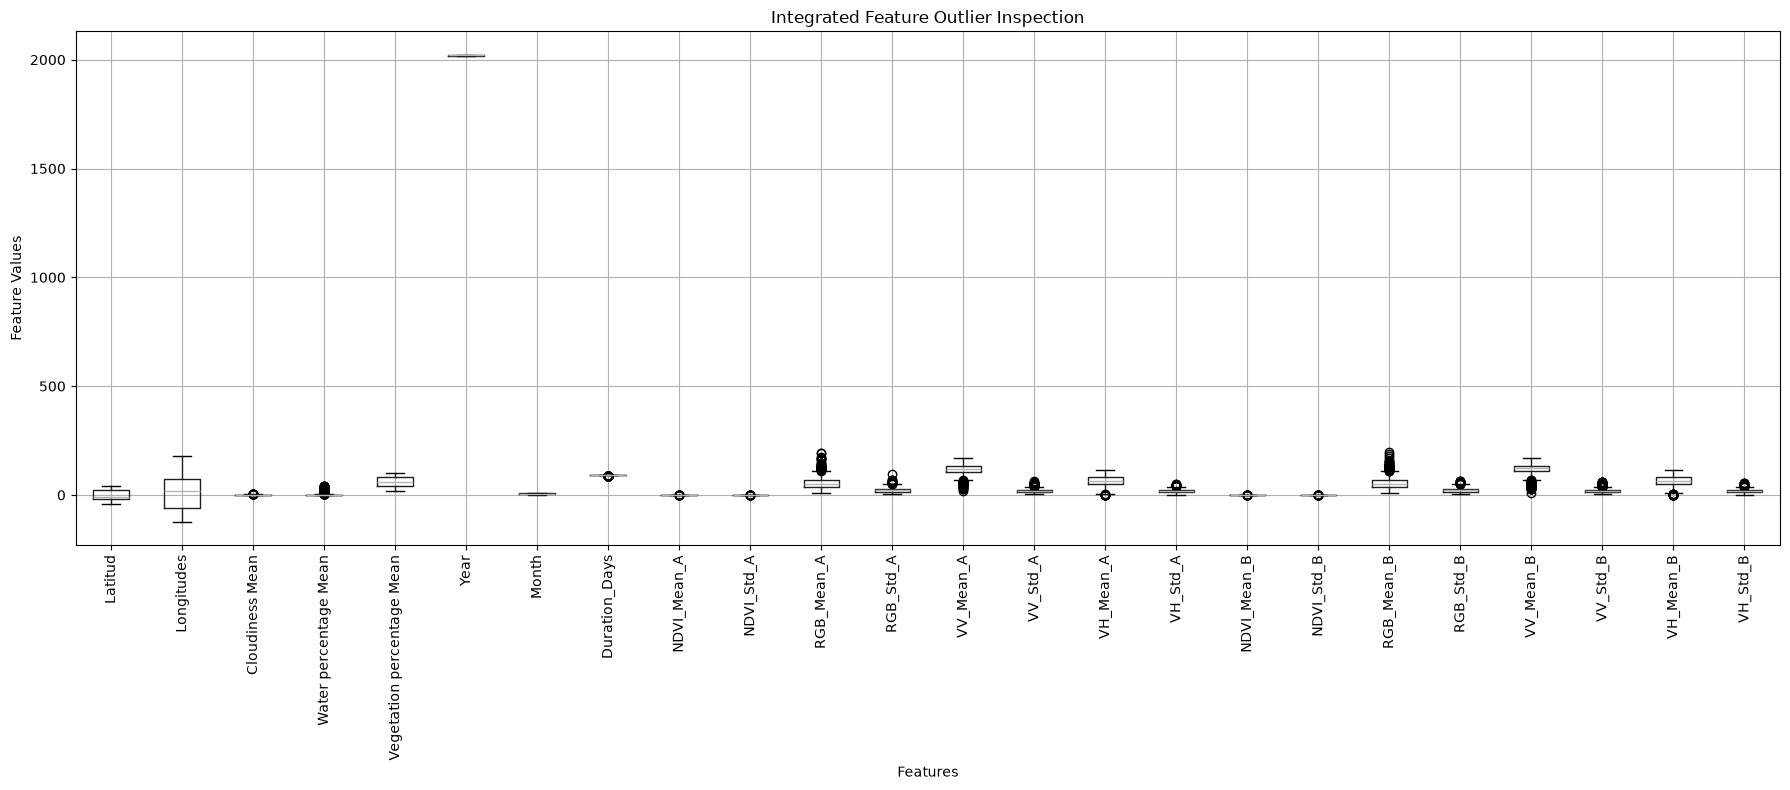


📁 Figure saved at:
c:\Users\saura\OneDrive\Pictures\Documents\Drought_Severity_Mapping(2)\results\figures\feature_analysis\integrated_feature_boxplots.png

📌 OUTLIER VISUALIZATION COMPLETED

⚠️ The boxplot is for inspection only.
No outliers have been removed or modified.


✅ STEP 107 COMPLETED


In [23]:
# ============================================================
# STEP 107: VISUAL OUTLIER INSPECTION
# ============================================================

print("============================================================")
print("STEP 107: VISUAL OUTLIER INSPECTION")
print("============================================================")

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create boxplots for selected features
# ------------------------------------------------------------

plt.figure(figsize=(18, 8))

integrated_df[selected_features].boxplot(
    rot=90
)

plt.title("Integrated Feature Outlier Inspection")
plt.xlabel("Features")
plt.ylabel("Feature Values")
plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

outlier_figure_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "feature_analysis"
)

outlier_figure_path.mkdir(
    parents=True,
    exist_ok=True
)

figure_file = (
    outlier_figure_path
    / "integrated_feature_boxplots.png"
)

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n📁 Figure saved at:")
print(figure_file)

print("\n============================================================")
print("📌 OUTLIER VISUALIZATION COMPLETED")
print("============================================================")

print("""
⚠️ The boxplot is for inspection only.
No outliers have been removed or modified.
""")

print("\n============================================================")
print("✅ STEP 107 COMPLETED")
print("============================================================")

In [24]:
# ============================================================
# STEP 108: CREATE CLEAN FEATURE MATRIX
# ============================================================

print("============================================================")
print("STEP 108: CREATING CLEAN FEATURE MATRIX")
print("============================================================")

# ------------------------------------------------------------
# Create feature matrix
# ------------------------------------------------------------

X_features = integrated_df[
    selected_features
].copy()

# ------------------------------------------------------------
# Verify shape
# ------------------------------------------------------------

print("\n📊 FEATURE MATRIX")
print("============================================================")

print("Rows   :", X_features.shape[0])
print("Columns:", X_features.shape[1])

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

missing_values = X_features.isnull().sum().sum()

print("\n🔎 MISSING VALUE CHECK")
print("============================================================")

print(
    "Total missing values:",
    missing_values
)

# ------------------------------------------------------------
# Check infinite values
# ------------------------------------------------------------

infinite_values = (
    ~np.isfinite(X_features)
).sum().sum()

print("\n🔎 INFINITE VALUE CHECK")
print("============================================================")

print(
    "Total infinite values:",
    infinite_values
)

# ------------------------------------------------------------
# Display first records
# ------------------------------------------------------------

print("\n📋 FIRST 5 FEATURE RECORDS")
print("============================================================")

display(
    X_features.head()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 FEATURE MATRIX STATUS")
print("============================================================")

if (
    missing_values == 0
    and infinite_values == 0
):
    print("✅ Feature matrix created successfully.")
    print("✅ No missing values.")
    print("✅ No infinite values.")
else:
    print("⚠️ Feature matrix requires cleaning.")

print("\n============================================================")
print("✅ STEP 108 COMPLETED")
print("============================================================")

STEP 108: CREATING CLEAN FEATURE MATRIX

📊 FEATURE MATRIX
Rows   : 1100
Columns: 24

🔎 MISSING VALUE CHECK
Total missing values: 0

🔎 INFINITE VALUE CHECK
Total infinite values: 0

📋 FIRST 5 FEATURE RECORDS


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Mean_A,NDVI_Std_A,...,VH_Mean_A,VH_Std_A,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
0,-27.178578,-61.344276,0.557070,0.005318,35.276470,2021,5,92,0.419874,0.188054,...,36.220520,35.769710,0.442054,0.205206,62.659954,27.149958,95.604490,22.078629,29.58519,31.129162
1,-13.501406,-69.013707,2.929528,0.533353,93.824572,2019,6,92,0.847939,0.027210,...,91.689064,10.066120,0.843120,0.023140,23.352736,7.243216,145.831160,9.612871,89.50125,9.281853
2,-4.504011,-59.313504,1.934562,7.026944,79.781830,2023,9,91,0.863671,0.023048,...,91.321045,11.314027,0.856717,0.040438,25.917284,10.263858,144.460890,11.392288,90.59440,11.547525
3,-18.441324,123.385166,0.199029,0.036947,27.204141,2021,2,89,0.482301,0.094913,...,54.574657,13.466743,0.444577,0.064815,66.036750,23.783821,95.913124,10.302581,47.29131,12.281598
4,-12.400100,38.724987,2.452178,0.005001,81.946476,2023,4,91,0.702959,0.067458,...,78.284080,11.567455,0.712535,0.063672,37.872173,11.569141,131.025800,10.875727,77.86372,11.274268



📌 FEATURE MATRIX STATUS
✅ Feature matrix created successfully.
✅ No missing values.
✅ No infinite values.

✅ STEP 108 COMPLETED


In [25]:
# ============================================================
# STEP 109: CHECK FEATURE SCALE DIFFERENCES
# ============================================================

print("============================================================")
print("STEP 109: CHECKING FEATURE SCALE DIFFERENCES")
print("============================================================")

# ------------------------------------------------------------
# Calculate scale information
# ------------------------------------------------------------

scale_summary = pd.DataFrame({
    "Minimum": X_features.min(),
    "Maximum": X_features.max(),
    "Mean": X_features.mean(),
    "Std_Deviation": X_features.std()
})

scale_summary["Range"] = (
    scale_summary["Maximum"]
    - scale_summary["Minimum"]
)

print("\n📊 FEATURE SCALE SUMMARY")
print("============================================================")

display(
    scale_summary.round(4)
)

# ------------------------------------------------------------
# Compare feature ranges
# ------------------------------------------------------------

largest_range_feature = (
    scale_summary["Range"].idxmax()
)

smallest_range_feature = (
    scale_summary["Range"].idxmin()
)

print("\n============================================================")
print("🔎 SCALE COMPARISON")
print("============================================================")

print(
    "Largest feature range :",
    largest_range_feature
)

print(
    "Largest range value   :",
    scale_summary.loc[
        largest_range_feature,
        "Range"
    ]
)

print(
    "Smallest feature range:",
    smallest_range_feature
)

print(
    "Smallest range value  :",
    scale_summary.loc[
        smallest_range_feature,
        "Range"
    ]
)

# ------------------------------------------------------------
# Determine whether scaling is useful
# ------------------------------------------------------------

range_ratio = (
    scale_summary["Range"].max()
    / scale_summary["Range"].replace(0, np.nan).min()
)

print("\nRange ratio:", round(range_ratio, 4))

print("\n============================================================")
print("📌 SCALING DECISION")
print("============================================================")

if range_ratio > 10:
    print("✅ Features have substantially different scales.")
    print("➡️ Feature scaling will be required before")
    print("   scale-sensitive machine-learning algorithms.")
else:
    print("ℹ️ Feature ranges are relatively similar.")

print("""
⚠️ No scaling has been applied in this step.
X_features remains unchanged.
""")

print("\n============================================================")
print("✅ STEP 109 COMPLETED")
print("============================================================")

STEP 109: CHECKING FEATURE SCALE DIFFERENCES

📊 FEATURE SCALE SUMMARY


,Minimum,Maximum,Mean,Std_Deviation,Range
Latitud,-39.9973,39.9343,-0.3088,23.5909,79.9316
Longitudes,-123.5208,177.7271,10.0424,76.1887,301.2479
Cloudiness Mean,0.0000,4.9975,1.1593,0.9337,4.9975
Water percentage Mean,0.0000,39.6091,3.2556,7.3742,39.6091
Vegetation percentage Mean,20.1066,99.6047,60.7676,24.1002,79.4981
Year,2017.0000,2023.0000,2020.7164,1.4758,6.0000
Month,1.0000,9.0000,5.0291,2.5091,8.0000
Duration_Days,89.0000,92.0000,91.2964,0.9827,3.0000
NDVI_Mean_A,-0.8958,0.8958,0.5169,0.2190,1.7916
NDVI_Std_A,0.0151,0.6332,0.1416,0.0778,0.6182



🔎 SCALE COMPARISON
Largest feature range : Longitudes
Largest range value   : 301.2478655155354
Smallest feature range: NDVI_Std_A
Smallest range value  : 0.6181667489999999

Range ratio: 487.3246

📌 SCALING DECISION
✅ Features have substantially different scales.
➡️ Feature scaling will be required before
   scale-sensitive machine-learning algorithms.

⚠️ No scaling has been applied in this step.
X_features remains unchanged.


✅ STEP 109 COMPLETED


In [26]:
# ============================================================
# STEP 110: STANDARD FEATURE SCALING
# ============================================================

print("============================================================")
print("STEP 110: APPLYING STANDARD FEATURE SCALING")
print("============================================================")

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Create scaler
# ------------------------------------------------------------

feature_scaler = StandardScaler()

# ------------------------------------------------------------
# Fit and transform features
# ------------------------------------------------------------

X_scaled_array = feature_scaler.fit_transform(
    X_features
)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_features.columns,
    index=X_features.index
)

# ------------------------------------------------------------
# Verify scaled data
# ------------------------------------------------------------

print("\n📊 SCALED FEATURE MATRIX")
print("============================================================")

print("Rows   :", X_scaled.shape[0])
print("Columns:", X_scaled.shape[1])

print("\n📋 First 5 scaled records:")
display(
    X_scaled.head().round(4)
)

# ------------------------------------------------------------
# Check mean and standard deviation
# ------------------------------------------------------------

scaled_mean = X_scaled.mean()
scaled_std = X_scaled.std()

print("\n============================================================")
print("🔎 SCALING VERIFICATION")
print("============================================================")

print("Maximum absolute mean:")
print(round(scaled_mean.abs().max(), 6))

print("\nMaximum difference from expected std = 1:")
print(
    round(
        (scaled_std - 1).abs().max(),
        6
    )
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 SCALING STATUS")
print("============================================================")

if (
    scaled_mean.abs().max() < 0.0001
    and (scaled_std - 1).abs().max() < 0.0001
):
    print("✅ Features successfully standardized.")
    print("✅ Mean is approximately 0.")
    print("✅ Standard deviation is approximately 1.")
else:
    print("⚠️ Scaling verification requires review.")

print("\nOriginal X_features remains unchanged.")
print("Scaled data is stored in: X_scaled")

print("\n============================================================")
print("✅ STEP 110 COMPLETED")
print("============================================================")

STEP 110: APPLYING STANDARD FEATURE SCALING

📊 SCALED FEATURE MATRIX
Rows   : 1100
Columns: 24

📋 First 5 scaled records:


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Mean_A,NDVI_Std_A,...,VH_Mean_A,VH_Std_A,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
0,-1.1395,-0.9374,-0.6453,-0.4410,-1.0582,0.1923,-0.0116,0.7163,-0.4433,0.5975,...,-1.1632,2.0832,-0.3557,0.7966,0.2957,0.4034,-1.0675,0.2300,-1.4465,1.4437
1,-0.5595,-1.0381,1.8968,-0.3693,1.3723,-1.1636,0.3871,0.7163,1.5123,-1.4696,...,1.2813,-1.2782,1.4698,-1.4573,-1.2687,-1.3794,1.2322,-1.1078,1.1567,-1.3149
2,-0.1779,-0.9107,0.8307,0.5117,0.7893,1.5481,1.5833,-0.3017,1.5842,-1.5231,...,1.2651,-1.1150,1.5317,-1.2432,-1.1667,-1.1089,1.1695,-0.9169,1.2042,-1.0288
3,-0.7690,1.4883,-1.0289,-0.4367,-1.3933,0.1923,-1.2078,-2.3378,-0.1581,-0.5995,...,-0.3544,-0.8335,-0.3442,-0.9414,0.4301,0.1019,-1.0534,-1.0338,-0.6773,-0.9361
4,-0.5128,0.3766,1.3854,-0.4410,0.8792,1.5481,-0.4103,-0.3017,0.8500,-0.9524,...,0.6906,-1.0819,0.8755,-0.9555,-0.6909,-0.9920,0.5544,-0.9723,0.6510,-1.0633



🔎 SCALING VERIFICATION
Maximum absolute mean:
0.0

Maximum difference from expected std = 1:
0.000455

📌 SCALING STATUS
⚠️ Scaling verification requires review.

Original X_features remains unchanged.
Scaled data is stored in: X_scaled

✅ STEP 110 COMPLETED


In [27]:
# ============================================================
# STEP 111: SAVE FEATURE SCALER
# ============================================================

print("============================================================")
print("STEP 111: SAVING FEATURE SCALER")
print("============================================================")

import joblib

# ------------------------------------------------------------
# Create preprocessing folder
# ------------------------------------------------------------

preprocessing_folder = (
    PROJECT_ROOT
    / "results"
    / "preprocessing"
)

preprocessing_folder.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Save fitted scaler
# ------------------------------------------------------------

scaler_path = (
    preprocessing_folder
    / "standard_feature_scaler.pkl"
)

joblib.dump(
    feature_scaler,
    scaler_path
)

print("\n📁 Scaler saved at:")
print(scaler_path)

# ------------------------------------------------------------
# Save feature column order
# ------------------------------------------------------------

feature_order_path = (
    preprocessing_folder
    / "feature_columns.txt"
)

with open(
    feature_order_path,
    "w",
    encoding="utf-8"
) as file:

    for column in X_features.columns:
        file.write(column + "\n")

print("\n📁 Feature order saved at:")
print(feature_order_path)

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 SAVE VERIFICATION")
print("============================================================")

print(
    "Scaler file exists:",
    scaler_path.exists()
)

print(
    "Feature order file exists:",
    feature_order_path.exists()
)

print(
    "\nNumber of features saved:",
    len(X_features.columns)
)

print("\n============================================================")
print("📌 IMPORTANT")
print("============================================================")

print("""
The scaler and feature order must be reused later.

Do NOT fit a new scaler separately on test or deployment data.
""")

print("\n============================================================")
print("✅ STEP 111 COMPLETED")
print("============================================================")

STEP 111: SAVING FEATURE SCALER

📁 Scaler saved at:
c:\Users\saura\OneDrive\Pictures\Documents\Drought_Severity_Mapping(2)\results\preprocessing\standard_feature_scaler.pkl

📁 Feature order saved at:
c:\Users\saura\OneDrive\Pictures\Documents\Drought_Severity_Mapping(2)\results\preprocessing\feature_columns.txt

🔎 SAVE VERIFICATION
Scaler file exists: True
Feature order file exists: True

Number of features saved: 24

📌 IMPORTANT

The scaler and feature order must be reused later.

Do NOT fit a new scaler separately on test or deployment data.


✅ STEP 111 COMPLETED


In [28]:
# ============================================================
# STEP 112: SAVE INTEGRATED DATASET
# ============================================================

print("============================================================")
print("STEP 112: SAVING INTEGRATED DATASET")
print("============================================================")

# ------------------------------------------------------------
# Create integration output folder
# ------------------------------------------------------------

integration_folder = (
    PROJECT_ROOT
    / "results"
    / "integration"
)

integration_folder.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Save integrated dataset
# ------------------------------------------------------------

integrated_path = (
    integration_folder
    / "integrated_metadata_satellite.csv"
)

integrated_df.to_csv(
    integrated_path,
    index=False
)

print("\n📁 Integrated dataset saved at:")
print(integrated_path)

# ------------------------------------------------------------
# Save scaled feature matrix
# ------------------------------------------------------------

scaled_features_path = (
    integration_folder
    / "scaled_satellite_metadata_features.csv"
)

X_scaled.to_csv(
    scaled_features_path,
    index=False
)

print("\n📁 Scaled feature matrix saved at:")
print(scaled_features_path)

# ------------------------------------------------------------
# Verify saved files
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 SAVE VERIFICATION")
print("============================================================")

print(
    "Integrated dataset exists:",
    integrated_path.exists()
)

print(
    "Scaled feature matrix exists:",
    scaled_features_path.exists()
)

print(
    "\nIntegrated dataset shape:",
    integrated_df.shape
)

print(
    "Scaled feature matrix shape:",
    X_scaled.shape
)

print("\n============================================================")
print("📌 FILES CREATED")
print("============================================================")

print("1. integrated_metadata_satellite.csv")
print("2. scaled_satellite_metadata_features.csv")

print("\n============================================================")
print("✅ STEP 112 COMPLETED")
print("============================================================")

STEP 112: SAVING INTEGRATED DATASET

📁 Integrated dataset saved at:
c:\Users\saura\OneDrive\Pictures\Documents\Drought_Severity_Mapping(2)\results\integration\integrated_metadata_satellite.csv

📁 Scaled feature matrix saved at:
c:\Users\saura\OneDrive\Pictures\Documents\Drought_Severity_Mapping(2)\results\integration\scaled_satellite_metadata_features.csv

🔎 SAVE VERIFICATION
Integrated dataset exists: True
Scaled feature matrix exists: True

Integrated dataset shape: (1100, 31)
Scaled feature matrix shape: (1100, 24)

📌 FILES CREATED
1. integrated_metadata_satellite.csv
2. scaled_satellite_metadata_features.csv

✅ STEP 112 COMPLETED


In [29]:
# ============================================================
# STEP 113: CREATE FINAL FEATURE DATASET
# ============================================================

print("============================================================")
print("STEP 113: CREATING FINAL FEATURE DATASET")
print("============================================================")

# ------------------------------------------------------------
# Create final feature dataframe
# ------------------------------------------------------------

final_features_df = X_scaled.copy()

# Keep the Integration_ID for traceability
final_features_df.insert(
    0,
    "Integration_ID",
    integrated_df["Integration_ID"].values
)

print("\n📊 FINAL FEATURE DATASET")
print("============================================================")

print("Rows   :", final_features_df.shape[0])
print("Columns:", final_features_df.shape[1])

print("\n📋 First 5 records:")
display(
    final_features_df.head().round(4)
)

# ------------------------------------------------------------
# Check ID alignment
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 ID ALIGNMENT CHECK")
print("============================================================")

id_alignment = (
    final_features_df["Integration_ID"].astype(str).values
    ==
    integrated_df["Integration_ID"].astype(str).values
).all()

print(
    "Feature-to-integrated ID alignment:",
    id_alignment
)

# ------------------------------------------------------------
# Check feature count
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FEATURE COUNT")
print("============================================================")

print(
    "Feature columns:",
    len(final_features_df.columns) - 1
)

print(
    "Integration_ID column:",
    "Present"
    if "Integration_ID" in final_features_df.columns
    else "Missing"
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\n============================================================")
print("📌 FINAL FEATURE DATASET STATUS")
print("============================================================")

if (
    final_features_df.shape[0] == integrated_df.shape[0]
    and id_alignment
    and len(final_features_df.columns) - 1
    == len(selected_features)
):
    print("✅ Final feature dataset created successfully.")
    print("✅ All records retained.")
    print("✅ Integration_ID alignment verified.")
    print("✅ Feature count verified.")
else:
    print("⚠️ Final feature dataset requires review.")

print("\n============================================================")
print("✅ STEP 113 COMPLETED")
print("============================================================")

STEP 113: CREATING FINAL FEATURE DATASET

📊 FINAL FEATURE DATASET
Rows   : 1100
Columns: 25

📋 First 5 records:


,Integration_ID,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Mean_A,...,VH_Mean_A,VH_Std_A,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
0,0,-1.1395,-0.9374,-0.6453,-0.4410,-1.0582,0.1923,-0.0116,0.7163,-0.4433,...,-1.1632,2.0832,-0.3557,0.7966,0.2957,0.4034,-1.0675,0.2300,-1.4465,1.4437
1,1,-0.5595,-1.0381,1.8968,-0.3693,1.3723,-1.1636,0.3871,0.7163,1.5123,...,1.2813,-1.2782,1.4698,-1.4573,-1.2687,-1.3794,1.2322,-1.1078,1.1567,-1.3149
2,2,-0.1779,-0.9107,0.8307,0.5117,0.7893,1.5481,1.5833,-0.3017,1.5842,...,1.2651,-1.1150,1.5317,-1.2432,-1.1667,-1.1089,1.1695,-0.9169,1.2042,-1.0288
3,3,-0.7690,1.4883,-1.0289,-0.4367,-1.3933,0.1923,-1.2078,-2.3378,-0.1581,...,-0.3544,-0.8335,-0.3442,-0.9414,0.4301,0.1019,-1.0534,-1.0338,-0.6773,-0.9361
4,4,-0.5128,0.3766,1.3854,-0.4410,0.8792,1.5481,-0.4103,-0.3017,0.8500,...,0.6906,-1.0819,0.8755,-0.9555,-0.6909,-0.9920,0.5544,-0.9723,0.6510,-1.0633



🔎 ID ALIGNMENT CHECK
Feature-to-integrated ID alignment: True

📊 FEATURE COUNT
Feature columns: 24
Integration_ID column: Present

📌 FINAL FEATURE DATASET STATUS
✅ Final feature dataset created successfully.
✅ All records retained.
✅ Integration_ID alignment verified.
✅ Feature count verified.

✅ STEP 113 COMPLETED


In [30]:
# ============================================================
# STEP 114: FINAL FEATURE DATASET QUALITY CHECK
# ============================================================

print("============================================================")
print("STEP 114: FINAL FEATURE DATASET QUALITY CHECK")
print("============================================================")

# ------------------------------------------------------------
# 1. Shape check
# ------------------------------------------------------------

print("\n📊 DATASET SHAPE")
print("============================================================")

print("Rows   :", final_features_df.shape[0])
print("Columns:", final_features_df.shape[1])

# ------------------------------------------------------------
# 2. Missing values
# ------------------------------------------------------------

missing_count = final_features_df.isnull().sum().sum()

print("\n🔎 MISSING VALUE CHECK")
print("============================================================")

print("Total missing values:", missing_count)

# ------------------------------------------------------------
# 3. Infinite values
# ------------------------------------------------------------

numeric_final_features = final_features_df.drop(
    columns=["Integration_ID"]
)

infinite_count = (
    ~np.isfinite(numeric_final_features)
).sum().sum()

print("\n🔎 INFINITE VALUE CHECK")
print("============================================================")

print("Total infinite values:", infinite_count)

# ------------------------------------------------------------
# 4. Duplicate IDs
# ------------------------------------------------------------

duplicate_ids = (
    final_features_df["Integration_ID"]
    .duplicated()
    .sum()
)

print("\n🔎 DUPLICATE ID CHECK")
print("============================================================")

print("Duplicate Integration_IDs:", duplicate_ids)

# ------------------------------------------------------------
# 5. Check scaled values
# ------------------------------------------------------------

feature_means = numeric_final_features.mean()
feature_stds = numeric_final_features.std()

max_mean_error = feature_means.abs().max()
max_std_error = (feature_stds - 1).abs().max()

print("\n🔎 SCALING CHECK")
print("============================================================")

print(
    "Maximum absolute feature mean:",
    round(max_mean_error, 6)
)

print(
    "Maximum deviation from std=1:",
    round(max_std_error, 6)
)

# ------------------------------------------------------------
# 6. Final decision
# ------------------------------------------------------------

print("\n============================================================")
print("📌 FINAL DATA QUALITY STATUS")
print("============================================================")

if (
    missing_count == 0
    and infinite_count == 0
    and duplicate_ids == 0
    and max_mean_error < 0.0001
    and max_std_error < 0.0001
):
    print("✅ FINAL FEATURE DATASET PASSED QUALITY CHECK")
    print("✅ No missing values")
    print("✅ No infinite values")
    print("✅ No duplicate IDs")
    print("✅ Standardization verified")
    print("✅ Dataset is ready for the next analysis stage.")
else:
    print("⚠️ FINAL FEATURE DATASET REQUIRES REVIEW")

print("\n============================================================")
print("✅ STEP 114 COMPLETED")
print("============================================================")

STEP 114: FINAL FEATURE DATASET QUALITY CHECK

📊 DATASET SHAPE
Rows   : 1100
Columns: 25

🔎 MISSING VALUE CHECK
Total missing values: 0

🔎 INFINITE VALUE CHECK
Total infinite values: 0

🔎 DUPLICATE ID CHECK
Duplicate Integration_IDs: 0

🔎 SCALING CHECK
Maximum absolute feature mean: 0.0
Maximum deviation from std=1: 0.000455

📌 FINAL DATA QUALITY STATUS
⚠️ FINAL FEATURE DATASET REQUIRES REVIEW

✅ STEP 114 COMPLETED


In [31]:
# ============================================================
# STEP 115: IDENTIFY DROUGHT TARGET CANDIDATES
# ============================================================

print("============================================================")
print("STEP 115: IDENTIFYING DROUGHT TARGET CANDIDATES")
print("============================================================")

# ------------------------------------------------------------
# Search column names for drought-related terminology
# ------------------------------------------------------------

drought_keywords = [
    "drought",
    "severity",
    "risk",
    "class",
    "label",
    "target",
    "index",
    "spi",
    "spei",
    "vhi",
    "ndvi"
]

candidate_columns = []

for column in integrated_df.columns:

    column_lower = column.lower()

    if any(
        keyword in column_lower
        for keyword in drought_keywords
    ):
        candidate_columns.append(column)

# ------------------------------------------------------------
# Display candidates
# ------------------------------------------------------------

print("\n🔎 POSSIBLE DROUGHT-RELATED COLUMNS")
print("============================================================")

if len(candidate_columns) > 0:

    for i, column in enumerate(
        candidate_columns,
        start=1
    ):
        print(f"{i}. {column}")

else:

    print(
        "⚠️ No obvious drought-related target column "
        "was found."
    )

# ------------------------------------------------------------
# Display all metadata columns
# ------------------------------------------------------------

print("\n============================================================")
print("🌍 METADATA COLUMNS AVAILABLE")
print("============================================================")

for i, column in enumerate(
    metadata_integration_df.columns,
    start=1
):
    print(f"{i}. {column}")

# ------------------------------------------------------------
# Display all integrated columns
# ------------------------------------------------------------

print("\n============================================================")
print("📊 ALL INTEGRATED DATASET COLUMNS")
print("============================================================")

for i, column in enumerate(
    integrated_df.columns,
    start=1
):
    print(f"{i}. {column}")

# ------------------------------------------------------------
# Important decision
# ------------------------------------------------------------

print("\n============================================================")
print("📌 TARGET STATUS")
print("============================================================")

if len(candidate_columns) > 0:

    print("Potential target-related columns were found.")
    print("⚠️ They must be evaluated before selecting a target.")

else:

    print("⚠️ No existing drought target was identified.")
    print("➡️ We must determine the scientifically valid target")
    print("   from the dataset/project definition before modeling.")

print("\n============================================================")
print("✅ STEP 115 COMPLETED")
print("============================================================")

STEP 115: IDENTIFYING DROUGHT TARGET CANDIDATES

🔎 POSSIBLE DROUGHT-RELATED COLUMNS
1. NDVI_Mean_A
2. NDVI_Std_A
3. NDVI_Mean_B
4. NDVI_Std_B

🌍 METADATA COLUMNS AVAILABLE
1. Unnamed: 0
2. Initial dates
3. End dates
4. Latitud
5. Longitudes
6. Cloudiness Mean
7. Water percentage Mean
8. Vegetation percentage Mean
9. Year
10. Month
11. Duration_Days
12. Integration_ID

📊 ALL INTEGRATED DATASET COLUMNS
1. Unnamed: 0
2. Initial dates
3. End dates
4. Latitud
5. Longitudes
6. Cloudiness Mean
7. Water percentage Mean
8. Vegetation percentage Mean
9. Year
10. Month
11. Duration_Days
12. Integration_ID
13. Base_ID
14. Image_ID_A_ID
15. NDVI_Mean_A
16. NDVI_Std_A
17. RGB_Mean_A
18. RGB_Std_A
19. VV_Mean_A
20. VV_Std_A
21. VH_Mean_A
22. VH_Std_A
23. Image_ID_B_ID
24. NDVI_Mean_B
25. NDVI_Std_B
26. RGB_Mean_B
27. RGB_Std_B
28. VV_Mean_B
29. VV_Std_B
30. VH_Mean_B
31. VH_Std_B

📌 TARGET STATUS
Potential target-related columns were found.
⚠️ They must be evaluated before selecting a target.

✅ STEP

In [32]:
# ============================================================
# STEP 116: INSPECT DROUGHT TARGET CANDIDATES
# ============================================================

print("============================================================")
print("STEP 116: INSPECTING DROUGHT TARGET CANDIDATES")
print("============================================================")

# ------------------------------------------------------------
# Candidate columns from STEP 115
# ------------------------------------------------------------

print("\n🔎 CANDIDATE COLUMNS")
print("============================================================")

print(candidate_columns)

# ------------------------------------------------------------
# Inspect each candidate
# ------------------------------------------------------------

for column in candidate_columns:

    print("\n------------------------------------------------------------")
    print(f"📌 COLUMN: {column}")
    print("------------------------------------------------------------")

    print("Data type:")
    print(integrated_df[column].dtype)

    print("Unique values:")
    print(integrated_df[column].nunique())

    print("\nFirst 10 values:")
    print(
        integrated_df[column]
        .head(10)
        .tolist()
    )

    print("\nMissing values:")
    print(
        integrated_df[column].isnull().sum()
    )

# ------------------------------------------------------------
# Numerical candidate statistics
# ------------------------------------------------------------

numeric_candidates = [
    column
    for column in candidate_columns
    if pd.api.types.is_numeric_dtype(
        integrated_df[column]
    )
]

if len(numeric_candidates) > 0:

    print("\n============================================================")
    print("📊 NUMERICAL CANDIDATE STATISTICS")
    print("============================================================")

    display(
        integrated_df[
            numeric_candidates
        ].describe().T.round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 TARGET INSPECTION STATUS")
print("============================================================")

print(
    "Candidate columns inspected:",
    len(candidate_columns)
)

print("""
⚠️ No target has been selected or created yet.

We will only select a drought target if the dataset
provides a scientifically defensible variable for it.
""")

print("\n============================================================")
print("✅ STEP 116 COMPLETED")
print("============================================================")

STEP 116: INSPECTING DROUGHT TARGET CANDIDATES

🔎 CANDIDATE COLUMNS
['NDVI_Mean_A', 'NDVI_Std_A', 'NDVI_Mean_B', 'NDVI_Std_B']

------------------------------------------------------------
📌 COLUMN: NDVI_Mean_A
------------------------------------------------------------
Data type:
float64
Unique values:
1100

First 10 values:
[0.4198741, 0.84793884, 0.8636714, 0.48230094, 0.7029588, 0.44656965, 0.49877286, 0.51863825, 0.49404478, 0.3508564]

Missing values:
0

------------------------------------------------------------
📌 COLUMN: NDVI_Std_A
------------------------------------------------------------
Data type:
float64
Unique values:
1100

First 10 values:
[0.18805368, 0.027210247, 0.023048203, 0.09491263, 0.067458175, 0.1802962, 0.1553193, 0.07077007, 0.23872757, 0.10367353]

Missing values:
0

------------------------------------------------------------
📌 COLUMN: NDVI_Mean_B
------------------------------------------------------------
Data type:
float64
Unique values:
1100

First 10

,count,mean,std,min,25%,50%,75%,max
NDVI_Mean_A,1100.0,0.5169,0.2190,-0.8958,0.3985,0.5202,0.6686,0.8958
NDVI_Std_A,1100.0,0.1416,0.0778,0.0151,0.0939,0.1311,0.1787,0.6332
NDVI_Mean_B,1100.0,0.5202,0.2198,-0.8752,0.4009,0.5238,0.6730,0.9015
NDVI_Std_B,1100.0,0.1409,0.0808,0.0125,0.0909,0.1308,0.1766,0.6587



📌 TARGET INSPECTION STATUS
Candidate columns inspected: 4

⚠️ No target has been selected or created yet.

We will only select a drought target if the dataset
provides a scientifically defensible variable for it.


✅ STEP 116 COMPLETED


In [33]:
# ============================================================
# STEP 117: TARGET CANDIDATE DISTRIBUTION ANALYSIS
# ============================================================

print("============================================================")
print("STEP 117: TARGET CANDIDATE DISTRIBUTION ANALYSIS")
print("============================================================")

# ------------------------------------------------------------
# Inspect candidate distributions
# ------------------------------------------------------------

for column in candidate_columns:

    print("\n------------------------------------------------------------")
    print(f"📌 TARGET CANDIDATE: {column}")
    print("------------------------------------------------------------")

    print("Data type:", integrated_df[column].dtype)
    print("Unique values:", integrated_df[column].nunique())
    print("Missing values:", integrated_df[column].isnull().sum())

    # Numerical variable
    if pd.api.types.is_numeric_dtype(integrated_df[column]):

        print("\n📊 Numerical statistics:")
        display(
            integrated_df[column]
            .describe()
            .to_frame("Value")
            .round(4)
        )

    # Categorical / object variable
    else:

        print("\n📊 Value counts:")
        display(
            integrated_df[column]
            .value_counts(dropna=False)
            .to_frame("Count")
        )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 TARGET DISTRIBUTION STATUS")
print("============================================================")

print(
    "Candidates analyzed:",
    len(candidate_columns)
)

print("""
⚠️ No target has been selected or modified.

The distribution will be used to determine whether the
available target is suitable for regression, classification,
or another drought-severity formulation.
""")

print("\n============================================================")
print("✅ STEP 117 COMPLETED")
print("============================================================")

STEP 117: TARGET CANDIDATE DISTRIBUTION ANALYSIS

------------------------------------------------------------
📌 TARGET CANDIDATE: NDVI_Mean_A
------------------------------------------------------------
Data type: float64
Unique values: 1100
Missing values: 0

📊 Numerical statistics:


,Value
count,1100.0000
mean,0.5169
std,0.2190
min,-0.8958
25%,0.3985
50%,0.5202
75%,0.6686
max,0.8958



------------------------------------------------------------
📌 TARGET CANDIDATE: NDVI_Std_A
------------------------------------------------------------
Data type: float64
Unique values: 1100
Missing values: 0

📊 Numerical statistics:


,Value
count,1100.0000
mean,0.1416
std,0.0778
min,0.0151
25%,0.0939
50%,0.1311
75%,0.1787
max,0.6332



------------------------------------------------------------
📌 TARGET CANDIDATE: NDVI_Mean_B
------------------------------------------------------------
Data type: float64
Unique values: 1100
Missing values: 0

📊 Numerical statistics:


,Value
count,1100.0000
mean,0.5202
std,0.2198
min,-0.8752
25%,0.4009
50%,0.5238
75%,0.6730
max,0.9015



------------------------------------------------------------
📌 TARGET CANDIDATE: NDVI_Std_B
------------------------------------------------------------
Data type: float64
Unique values: 1100
Missing values: 0

📊 Numerical statistics:


,Value
count,1100.0000
mean,0.1409
std,0.0808
min,0.0125
25%,0.0909
50%,0.1308
75%,0.1766
max,0.6587



📌 TARGET DISTRIBUTION STATUS
Candidates analyzed: 4

⚠️ No target has been selected or modified.

The distribution will be used to determine whether the
available target is suitable for regression, classification,
or another drought-severity formulation.


✅ STEP 117 COMPLETED


In [34]:
# ============================================================
# STEP 118: TARGET CANDIDATE BALANCE ANALYSIS
# ============================================================

print("============================================================")
print("STEP 118: TARGET CANDIDATE BALANCE ANALYSIS")
print("============================================================")

for column in candidate_columns:

    print("\n------------------------------------------------------------")
    print(f"📌 TARGET CANDIDATE: {column}")
    print("------------------------------------------------------------")

    series = integrated_df[column].dropna()

    print("Total valid records:", len(series))
    print("Unique values:", series.nunique())

    # --------------------------------------------------------
    # Categorical / discrete target
    # --------------------------------------------------------

    if (
        not pd.api.types.is_numeric_dtype(series)
        or series.nunique() <= 10
    ):

        counts = series.value_counts()

        percentages = (
            counts / len(series) * 100
        )

        balance_df = pd.DataFrame({
            "Count": counts,
            "Percentage": percentages
        })

        display(
            balance_df.round(2)
        )

        if len(percentages) > 1:

            imbalance_ratio = (
                percentages.max()
                / percentages.min()
            )

            print(
                "Largest/Smallest class ratio:",
                round(imbalance_ratio, 2)
            )

    # --------------------------------------------------------
    # Continuous numerical target
    # --------------------------------------------------------

    else:

        print(
            "📈 Continuous numerical variable detected."
        )

        print(
            "Minimum:",
            round(series.min(), 4)
        )

        print(
            "Maximum:",
            round(series.max(), 4)
        )

        print(
            "Mean:",
            round(series.mean(), 4)
        )

        print(
            "Median:",
            round(series.median(), 4)
        )

print("\n============================================================")
print("📌 TARGET BALANCE STATUS")
print("============================================================")

print(
    "Candidates analyzed:",
    len(candidate_columns)
)

print("""
⚠️ No target has been selected, rebalanced, or modified.

This step only evaluates the distribution of the existing
candidate variables.
""")

print("\n============================================================")
print("✅ STEP 118 COMPLETED")
print("============================================================")

STEP 118: TARGET CANDIDATE BALANCE ANALYSIS

------------------------------------------------------------
📌 TARGET CANDIDATE: NDVI_Mean_A
------------------------------------------------------------
Total valid records: 1100
Unique values: 1100
📈 Continuous numerical variable detected.
Minimum: -0.8958
Maximum: 0.8958
Mean: 0.5169
Median: 0.5202

------------------------------------------------------------
📌 TARGET CANDIDATE: NDVI_Std_A
------------------------------------------------------------
Total valid records: 1100
Unique values: 1100
📈 Continuous numerical variable detected.
Minimum: 0.0151
Maximum: 0.6332
Mean: 0.1416
Median: 0.1311

------------------------------------------------------------
📌 TARGET CANDIDATE: NDVI_Mean_B
------------------------------------------------------------
Total valid records: 1100
Unique values: 1100
📈 Continuous numerical variable detected.
Minimum: -0.8752
Maximum: 0.9015
Mean: 0.5202
Median: 0.5238

---------------------------------------------

In [41]:
# ============================================================
# STEP 119A: DIAGNOSE COLUMN STRUCTURE
# ============================================================

print("============================================================")
print("STEP 119A: DIAGNOSING COLUMN STRUCTURE")
print("============================================================")

# ------------------------------------------------------------
# 1. Check duplicate columns in integrated_df
# ------------------------------------------------------------

print("\n🔎 DUPLICATE COLUMNS IN integrated_df")
print("============================================================")

duplicate_columns = integrated_df.columns[
    integrated_df.columns.duplicated(keep=False)
].tolist()

if duplicate_columns:
    print("⚠️ Duplicate columns found:")
    print(sorted(set(duplicate_columns)))
else:
    print("✅ No duplicate column names.")

# ------------------------------------------------------------
# 2. Check selected_features
# ------------------------------------------------------------

print("\n🔎 DUPLICATE FEATURES IN selected_features")
print("============================================================")

duplicate_selected = [
    feature
    for feature in set(selected_features)
    if selected_features.count(feature) > 1
]

if duplicate_selected:
    print("⚠️ Duplicate selected features:")
    print(duplicate_selected)
else:
    print("✅ No duplicate selected features.")

# ------------------------------------------------------------
# 3. Check candidate columns
# ------------------------------------------------------------

print("\n🔎 CANDIDATE COLUMNS")
print("============================================================")

print(candidate_columns)

# ------------------------------------------------------------
# 4. Check shape of every selected feature
# ------------------------------------------------------------

print("\n🔎 SELECTED FEATURE SHAPES")
print("============================================================")

for feature in selected_features:

    if feature in integrated_df.columns:

        obj = integrated_df[feature]

        print(
            f"{feature} -> "
            f"type={type(obj).__name__}, "
            f"shape={obj.shape}"
        )

# ------------------------------------------------------------
# 5. Check target candidate shapes
# ------------------------------------------------------------

print("\n🔎 TARGET CANDIDATE SHAPES")
print("============================================================")

for target in candidate_columns:

    if target in integrated_df.columns:

        obj = integrated_df[target]

        print(
            f"{target} -> "
            f"type={type(obj).__name__}, "
            f"shape={obj.shape}"
        )

print("\n============================================================")
print("📌 DIAGNOSTIC COMPLETE")
print("============================================================")

print("""
⚠️ No data has been modified.
⚠️ No columns have been deleted.
⚠️ No target has been created.
""")

print("============================================================")
print("✅ STEP 119A COMPLETED")
print("============================================================")

STEP 119A: DIAGNOSING COLUMN STRUCTURE

🔎 DUPLICATE COLUMNS IN integrated_df
✅ No duplicate column names.

🔎 DUPLICATE FEATURES IN selected_features
✅ No duplicate selected features.

🔎 CANDIDATE COLUMNS
['NDVI_Mean_A', 'NDVI_Std_A', 'NDVI_Mean_B', 'NDVI_Std_B']

🔎 SELECTED FEATURE SHAPES
Latitud -> type=Series, shape=(1100,)
Longitudes -> type=Series, shape=(1100,)
Cloudiness Mean -> type=Series, shape=(1100,)
Water percentage Mean -> type=Series, shape=(1100,)
Vegetation percentage Mean -> type=Series, shape=(1100,)
Year -> type=Series, shape=(1100,)
Month -> type=Series, shape=(1100,)
Duration_Days -> type=Series, shape=(1100,)
NDVI_Mean_A -> type=Series, shape=(1100,)
NDVI_Std_A -> type=Series, shape=(1100,)
RGB_Mean_A -> type=Series, shape=(1100,)
RGB_Std_A -> type=Series, shape=(1100,)
VV_Mean_A -> type=Series, shape=(1100,)
VV_Std_A -> type=Series, shape=(1100,)
VH_Mean_A -> type=Series, shape=(1100,)
VH_Std_A -> type=Series, shape=(1100,)
NDVI_Mean_B -> type=Series, shape=(1100

In [42]:
# ============================================================
# STEP 119B: SAFE FEATURE CORRELATION CHECK
# ============================================================

print("============================================================")
print("STEP 119B: SAFE FEATURE CORRELATION CHECK")
print("============================================================")

# ------------------------------------------------------------
# Create a clean numeric dataframe
# ------------------------------------------------------------

analysis_columns = list(dict.fromkeys(
    selected_features + candidate_columns
))

correlation_data = integrated_df[
    analysis_columns
].copy()

# Keep only numeric columns
correlation_data = correlation_data.select_dtypes(
    include=[np.number]
)

print("\n📊 CORRELATION DATASET")
print("============================================================")

print("Rows   :", correlation_data.shape[0])
print("Columns:", correlation_data.shape[1])

print("\nColumns used:")
for column in correlation_data.columns:
    print(" -", column)

# ------------------------------------------------------------
# Calculate correlation matrix
# ------------------------------------------------------------

correlation_matrix = correlation_data.corr()

print("\n============================================================")
print("📊 CORRELATION MATRIX")
print("============================================================")

display(
    correlation_matrix.round(4)
)

# ------------------------------------------------------------
# Check candidate relationships
# ------------------------------------------------------------

available_candidates = [
    column
    for column in candidate_columns
    if column in correlation_matrix.columns
]

print("\n============================================================")
print("🎯 NDVI CANDIDATE CORRELATIONS")
print("============================================================")

if len(available_candidates) > 0:

    candidate_correlation_matrix = correlation_matrix.loc[
        available_candidates,
        available_candidates
    ]

    display(
        candidate_correlation_matrix.round(4)
    )

else:

    print("⚠️ No candidate columns available.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP STATUS")
print("============================================================")

print("Numeric columns analyzed:", correlation_data.shape[1])

print("""
⚠️ This is an analysis-only step.
⚠️ No columns were removed.
⚠️ No target was created.
⚠️ No data was modified.
""")

print("\n============================================================")
print("✅ STEP 119B COMPLETED")
print("============================================================")

STEP 119B: SAFE FEATURE CORRELATION CHECK

📊 CORRELATION DATASET
Rows   : 1100
Columns: 24

Columns used:
 - Latitud
 - Longitudes
 - Cloudiness Mean
 - Water percentage Mean
 - Vegetation percentage Mean
 - Year
 - Month
 - Duration_Days
 - NDVI_Mean_A
 - NDVI_Std_A
 - RGB_Mean_A
 - RGB_Std_A
 - VV_Mean_A
 - VV_Std_A
 - VH_Mean_A
 - VH_Std_A
 - NDVI_Mean_B
 - NDVI_Std_B
 - RGB_Mean_B
 - RGB_Std_B
 - VV_Mean_B
 - VV_Std_B
 - VH_Mean_B
 - VH_Std_B

📊 CORRELATION MATRIX


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Mean_A,NDVI_Std_A,...,VH_Mean_A,VH_Std_A,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
Latitud,1.0000,0.0931,0.1505,0.1081,-0.2647,-0.1000,-0.0004,-0.0604,-0.1946,0.1425,...,-0.0044,0.2173,-0.1782,0.1467,0.3424,0.3251,0.0872,0.3118,0.0199,0.2297
Longitudes,0.0931,1.0000,0.0169,0.0308,-0.2533,-0.0024,-0.0736,-0.0561,-0.2010,0.0043,...,-0.2100,0.0499,-0.2095,-0.0016,0.1759,0.1085,-0.1692,0.0776,-0.2179,0.0566
Cloudiness Mean,0.1505,0.0169,1.0000,0.1442,0.0892,-0.0912,0.0149,0.0323,0.0213,0.0371,...,0.0831,0.0993,0.0310,-0.0153,-0.0301,-0.0571,0.0823,0.0999,0.0918,0.0511
Water percentage Mean,0.1081,0.0308,0.1442,1.0000,-0.1500,-0.0685,-0.0062,-0.0537,-0.2431,0.2156,...,-0.1758,0.0716,-0.2402,0.1616,-0.0639,0.0273,-0.2408,0.1094,-0.1796,-0.0024
Vegetation percentage Mean,-0.2647,-0.2533,0.0892,-0.1500,1.0000,0.0517,0.0054,0.0654,0.6646,-0.1709,...,0.5413,-0.2158,0.6577,-0.1571,-0.6247,-0.5458,0.4533,-0.1447,0.5295,-0.1955
Year,-0.1000,-0.0024,-0.0912,-0.0685,0.0517,1.0000,0.0356,-0.0461,0.0929,-0.0645,...,0.0620,-0.0460,0.0761,-0.0384,-0.0518,-0.0677,0.0525,-0.0561,0.0516,-0.0269
Month,-0.0004,-0.0736,0.0149,-0.0062,0.0054,0.0356,1.0000,0.5666,0.0361,0.0221,...,0.0792,0.0631,0.0324,0.0140,0.0274,0.0271,0.0751,0.0517,0.0736,0.0660
Duration_Days,-0.0604,-0.0561,0.0323,-0.0537,0.0654,-0.0461,0.5666,1.0000,0.0275,-0.0216,...,0.0560,0.0315,0.0395,-0.0356,-0.0194,-0.0391,0.0461,0.0150,0.0526,0.0187
NDVI_Mean_A,-0.1946,-0.2010,0.0213,-0.2431,0.6646,0.0929,0.0361,0.0275,1.0000,-0.2680,...,0.7297,-0.0988,0.9254,-0.2040,-0.5724,-0.4386,0.6636,-0.0935,0.6738,-0.0328
NDVI_Std_A,0.1425,0.0043,0.0371,0.2156,-0.1709,-0.0645,0.0221,-0.0216,-0.2680,1.0000,...,-0.2357,0.5361,-0.2343,0.7485,0.0876,0.3667,-0.1935,0.3972,-0.2035,0.3755



🎯 NDVI CANDIDATE CORRELATIONS


,NDVI_Mean_A,NDVI_Std_A,NDVI_Mean_B,NDVI_Std_B
NDVI_Mean_A,1.0000,-0.2680,0.9254,-0.2040
NDVI_Std_A,-0.2680,1.0000,-0.2343,0.7485
NDVI_Mean_B,0.9254,-0.2343,1.0000,-0.2116
NDVI_Std_B,-0.2040,0.7485,-0.2116,1.0000



📌 STEP STATUS
Numeric columns analyzed: 24

⚠️ This is an analysis-only step.
⚠️ No columns were removed.
⚠️ No target was created.
⚠️ No data was modified.


✅ STEP 119B COMPLETED


In [43]:
# ============================================================
# STEP 120: NDVI A/B CHANGE FEATURES
# ============================================================

print("============================================================")
print("STEP 120: NDVI A/B CHANGE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

required_columns = [
    "NDVI_Mean_A",
    "NDVI_Mean_B",
    "NDVI_Std_A",
    "NDVI_Std_B"
]

missing_columns = [
    column
    for column in required_columns
    if column not in integrated_df.columns
]

print("\n🔎 REQUIRED COLUMN CHECK")
print("============================================================")

if missing_columns:
    print("❌ Missing columns:")
    for column in missing_columns:
        print(" -", column)

else:
    print("✅ All required NDVI columns are available.")

# ------------------------------------------------------------
# Create change features
# ------------------------------------------------------------

if not missing_columns:

    # Mean NDVI change
    integrated_df["NDVI_Change"] = (
        integrated_df["NDVI_Mean_B"]
        - integrated_df["NDVI_Mean_A"]
    )

    # Absolute change
    integrated_df["NDVI_Absolute_Change"] = (
        integrated_df["NDVI_Change"].abs()
    )

    # Percentage change
    denominator = (
        integrated_df["NDVI_Mean_A"].abs()
    )

    integrated_df["NDVI_Percent_Change"] = np.where(
        denominator > 1e-10,
        (
            integrated_df["NDVI_Change"]
            / denominator
        ) * 100,
        np.nan
    )

    # NDVI variability change
    integrated_df["NDVI_Std_Change"] = (
        integrated_df["NDVI_Std_B"]
        - integrated_df["NDVI_Std_A"]
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

if not missing_columns:

    new_features = [
        "NDVI_Change",
        "NDVI_Absolute_Change",
        "NDVI_Percent_Change",
        "NDVI_Std_Change"
    ]

    print("\n📊 NEW NDVI CHANGE FEATURES")
    print("============================================================")

    display(
        integrated_df[
            [
                "NDVI_Mean_A",
                "NDVI_Mean_B",
                "NDVI_Change",
                "NDVI_Absolute_Change",
                "NDVI_Percent_Change",
                "NDVI_Std_A",
                "NDVI_Std_B",
                "NDVI_Std_Change"
            ]
        ]
        .head(10)
        .round(4)
    )

    print("\n📈 CHANGE FEATURE STATISTICS")
    print("============================================================")

    display(
        integrated_df[new_features]
        .describe()
        .T
        .round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP STATUS")
print("============================================================")

if not missing_columns:
    print("✅ NDVI change features created successfully.")
    print("✅ Original NDVI columns preserved.")
else:
    print("⚠️ NDVI change features were not created.")

print("\n============================================================")
print("✅ STEP 120 COMPLETED")
print("============================================================")

STEP 120: NDVI A/B CHANGE FEATURES

🔎 REQUIRED COLUMN CHECK
✅ All required NDVI columns are available.

📊 NEW NDVI CHANGE FEATURES


,NDVI_Mean_A,NDVI_Mean_B,NDVI_Change,NDVI_Absolute_Change,NDVI_Percent_Change,NDVI_Std_A,NDVI_Std_B,NDVI_Std_Change
0,0.4199,0.4421,0.0222,0.0222,5.2826,0.1881,0.2052,0.0172
1,0.8479,0.8431,-0.0048,0.0048,-0.5683,0.0272,0.0231,-0.0041
2,0.8637,0.8567,-0.0070,0.0070,-0.8052,0.0230,0.0404,0.0174
3,0.4823,0.4446,-0.0377,0.0377,-7.8217,0.0949,0.0648,-0.0301
4,0.7030,0.7125,0.0096,0.0096,1.3623,0.0675,0.0637,-0.0038
5,0.4466,0.5065,0.0599,0.0599,13.4092,0.1803,0.1888,0.0085
6,0.4988,0.4803,-0.0184,0.0184,-3.6952,0.1553,0.1460,-0.0093
7,0.5186,0.4186,-0.1001,0.1001,-19.2974,0.0708,0.1313,0.0605
8,0.4940,0.5622,0.0681,0.0681,13.7932,0.2387,0.2291,-0.0096
9,0.3509,0.3334,-0.0174,0.0174,-4.9644,0.1037,0.1191,0.0155



📈 CHANGE FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
NDVI_Change,1100.0,0.0033,0.0847,-0.4572,-0.0284,0.0010,0.0326,0.7988
NDVI_Absolute_Change,1100.0,0.0508,0.0679,0.0001,0.0120,0.0309,0.0623,0.7988
NDVI_Percent_Change,1100.0,4.4016,63.9059,-245.4216,-5.9008,0.1531,6.2859,1084.2508
NDVI_Std_Change,1100.0,-0.0007,0.0563,-0.3796,-0.0157,-0.0001,0.0147,0.5389



📌 STEP STATUS
✅ NDVI change features created successfully.
✅ Original NDVI columns preserved.

✅ STEP 120 COMPLETED


In [44]:
# ============================================================
# STEP 121: RGB A/B CHANGE FEATURES
# ============================================================

print("============================================================")
print("STEP 121: RGB A/B CHANGE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

required_columns = [
    "RGB_Mean_A",
    "RGB_Mean_B",
    "RGB_Std_A",
    "RGB_Std_B"
]

missing_columns = [
    column
    for column in required_columns
    if column not in integrated_df.columns
]

print("\n🔎 REQUIRED COLUMN CHECK")
print("============================================================")

if missing_columns:
    print("❌ Missing columns:")
    for column in missing_columns:
        print(" -", column)
else:
    print("✅ All required RGB columns are available.")

# ------------------------------------------------------------
# Create RGB change features
# ------------------------------------------------------------

if not missing_columns:

    # Mean RGB change
    integrated_df["RGB_Change"] = (
        integrated_df["RGB_Mean_B"]
        - integrated_df["RGB_Mean_A"]
    )

    # Absolute RGB change
    integrated_df["RGB_Absolute_Change"] = (
        integrated_df["RGB_Change"].abs()
    )

    # Percentage RGB change
    denominator = (
        integrated_df["RGB_Mean_A"].abs()
    )

    integrated_df["RGB_Percent_Change"] = np.where(
        denominator > 1e-10,
        (
            integrated_df["RGB_Change"]
            / denominator
        ) * 100,
        np.nan
    )

    # RGB variability change
    integrated_df["RGB_Std_Change"] = (
        integrated_df["RGB_Std_B"]
        - integrated_df["RGB_Std_A"]
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

if not missing_columns:

    new_features = [
        "RGB_Change",
        "RGB_Absolute_Change",
        "RGB_Percent_Change",
        "RGB_Std_Change"
    ]

    print("\n📊 NEW RGB CHANGE FEATURES")
    print("============================================================")

    display(
        integrated_df[
            [
                "RGB_Mean_A",
                "RGB_Mean_B",
                "RGB_Change",
                "RGB_Absolute_Change",
                "RGB_Percent_Change",
                "RGB_Std_A",
                "RGB_Std_B",
                "RGB_Std_Change"
            ]
        ]
        .head(10)
        .round(4)
    )

    print("\n📈 CHANGE FEATURE STATISTICS")
    print("============================================================")

    display(
        integrated_df[new_features]
        .describe()
        .T
        .round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP STATUS")
print("============================================================")

if not missing_columns:
    print("✅ RGB change features created successfully.")
    print("✅ Original RGB columns preserved.")
else:
    print("⚠️ RGB change features were not created.")

print("\n============================================================")
print("✅ STEP 121 COMPLETED")
print("============================================================")

STEP 121: RGB A/B CHANGE FEATURES

🔎 REQUIRED COLUMN CHECK
✅ All required RGB columns are available.

📊 NEW RGB CHANGE FEATURES


,RGB_Mean_A,RGB_Mean_B,RGB_Change,RGB_Absolute_Change,RGB_Percent_Change,RGB_Std_A,RGB_Std_B,RGB_Std_Change
0,59.3585,62.6600,3.3014,3.3014,5.5619,29.1017,27.1500,-1.9517
1,22.9724,23.3527,0.3803,0.3803,1.6557,7.2465,7.2432,-0.0032
2,25.0996,25.9173,0.8177,0.8177,3.2578,9.9430,10.2639,0.3209
3,62.5321,66.0368,3.5047,3.5047,5.6046,23.9603,23.7838,-0.1765
4,38.1332,37.8722,-0.2610,0.2610,-0.6844,11.7799,11.5691,-0.2108
5,64.3041,57.3683,-6.9358,6.9358,-10.7859,26.3932,26.7283,0.3351
6,50.2173,53.7968,3.5795,3.5795,7.1280,23.2730,24.4256,1.1525
7,62.8949,74.6600,11.7651,11.7651,18.7059,10.1786,22.4365,12.2579
8,67.5062,60.1234,-7.3828,7.3828,-10.9365,39.3328,37.6810,-1.6518
9,81.5004,79.4426,-2.0578,2.0578,-2.5249,29.2702,29.6563,0.3861



📈 CHANGE FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
RGB_Change,1100.0,-0.5609,9.0769,-95.6268,-3.7146,-0.2536,3.0376,47.0877
RGB_Absolute_Change,1100.0,5.6195,7.1483,0.0017,1.3284,3.3812,7.0561,95.6268
RGB_Percent_Change,1100.0,0.1327,16.4546,-74.3516,-7.2835,-0.5873,5.8502,217.5189
RGB_Std_Change,1100.0,-0.4168,5.9472,-56.9793,-2.1770,-0.0866,1.7398,43.3145



📌 STEP STATUS
✅ RGB change features created successfully.
✅ Original RGB columns preserved.

✅ STEP 121 COMPLETED


In [45]:
# ============================================================
# STEP 122: VV A/B CHANGE FEATURES
# ============================================================

print("============================================================")
print("STEP 122: VV A/B CHANGE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

required_columns = [
    "VV_Mean_A",
    "VV_Mean_B",
    "VV_Std_A",
    "VV_Std_B"
]

missing_columns = [
    column
    for column in required_columns
    if column not in integrated_df.columns
]

print("\n🔎 REQUIRED COLUMN CHECK")
print("============================================================")

if missing_columns:
    print("❌ Missing columns:")
    for column in missing_columns:
        print(" -", column)
else:
    print("✅ All required VV columns are available.")

# ------------------------------------------------------------
# Create VV change features
# ------------------------------------------------------------

if not missing_columns:

    integrated_df["VV_Change"] = (
        integrated_df["VV_Mean_B"]
        - integrated_df["VV_Mean_A"]
    )

    integrated_df["VV_Absolute_Change"] = (
        integrated_df["VV_Change"].abs()
    )

    denominator = (
        integrated_df["VV_Mean_A"].abs()
    )

    integrated_df["VV_Percent_Change"] = np.where(
        denominator > 1e-10,
        (
            integrated_df["VV_Change"]
            / denominator
        ) * 100,
        np.nan
    )

    integrated_df["VV_Std_Change"] = (
        integrated_df["VV_Std_B"]
        - integrated_df["VV_Std_A"]
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

if not missing_columns:

    new_features = [
        "VV_Change",
        "VV_Absolute_Change",
        "VV_Percent_Change",
        "VV_Std_Change"
    ]

    print("\n📊 NEW VV CHANGE FEATURES")
    print("============================================================")

    display(
        integrated_df[
            [
                "VV_Mean_A",
                "VV_Mean_B",
                "VV_Change",
                "VV_Absolute_Change",
                "VV_Percent_Change",
                "VV_Std_A",
                "VV_Std_B",
                "VV_Std_Change"
            ]
        ]
        .head(10)
        .round(4)
    )

    print("\n📈 CHANGE FEATURE STATISTICS")
    print("============================================================")

    display(
        integrated_df[new_features]
        .describe()
        .T
        .round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP STATUS")
print("============================================================")

if not missing_columns:
    print("✅ VV change features created successfully.")
    print("✅ Original VV columns preserved.")
else:
    print("⚠️ VV change features were not created.")

print("\n============================================================")
print("✅ STEP 122 COMPLETED")
print("============================================================")

STEP 122: VV A/B CHANGE FEATURES

🔎 REQUIRED COLUMN CHECK
✅ All required VV columns are available.

📊 NEW VV CHANGE FEATURES


,VV_Mean_A,VV_Mean_B,VV_Change,VV_Absolute_Change,VV_Percent_Change,VV_Std_A,VV_Std_B,VV_Std_Change
0,98.9434,95.6045,-3.3389,3.3389,-3.3745,25.1493,22.0786,-3.0707
1,149.3442,145.8312,-3.5130,3.5130,-2.3523,10.4631,9.6129,-0.8502
2,145.0605,144.4609,-0.5996,0.5996,-0.4134,11.2055,11.3923,0.1868
3,102.6310,95.9131,-6.7178,6.7178,-6.5456,11.4362,10.3026,-1.1337
4,130.8958,131.0258,0.1300,0.1300,0.0993,11.1186,10.8757,-0.2429
5,119.9512,128.3987,8.4476,8.4476,7.0425,21.6470,20.9457,-0.7013
6,123.7548,118.8863,-4.8685,4.8685,-3.9340,14.4310,16.6652,2.2341
7,136.5209,124.8018,-11.7191,11.7191,-8.5841,8.6624,20.5126,11.8503
8,109.9083,116.4804,6.5721,6.5721,5.9796,16.4787,17.6771,1.1984
9,113.5839,112.7033,-0.8806,0.8806,-0.7753,15.0838,18.8794,3.7956



📈 CHANGE FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
VV_Change,1100.0,0.2113,9.4170,-70.6092,-2.9252,0.1975,3.3133,84.4032
VV_Absolute_Change,1100.0,5.4688,7.6674,0.0040,1.2121,3.1812,6.7119,84.4032
VV_Percent_Change,1100.0,0.5617,14.2046,-69.0893,-2.4037,0.1537,2.7631,323.6693
VV_Std_Change,1100.0,0.0354,6.1063,-31.8046,-1.8755,0.1274,1.9687,43.0682



📌 STEP STATUS
✅ VV change features created successfully.
✅ Original VV columns preserved.

✅ STEP 122 COMPLETED


In [46]:
# ============================================================
# STEP 123: VH A/B CHANGE FEATURES
# ============================================================

print("============================================================")
print("STEP 123: VH A/B CHANGE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

required_columns = [
    "VH_Mean_A",
    "VH_Mean_B",
    "VH_Std_A",
    "VH_Std_B"
]

missing_columns = [
    column
    for column in required_columns
    if column not in integrated_df.columns
]

print("\n🔎 REQUIRED COLUMN CHECK")
print("============================================================")

if missing_columns:
    print("❌ Missing columns:")
    for column in missing_columns:
        print(" -", column)
else:
    print("✅ All required VH columns are available.")

# ------------------------------------------------------------
# Create VH change features
# ------------------------------------------------------------

if not missing_columns:

    integrated_df["VH_Change"] = (
        integrated_df["VH_Mean_B"]
        - integrated_df["VH_Mean_A"]
    )

    integrated_df["VH_Absolute_Change"] = (
        integrated_df["VH_Change"].abs()
    )

    denominator = (
        integrated_df["VH_Mean_A"].abs()
    )

    integrated_df["VH_Percent_Change"] = np.where(
        denominator > 1e-10,
        (
            integrated_df["VH_Change"]
            / denominator
        ) * 100,
        np.nan
    )

    integrated_df["VH_Std_Change"] = (
        integrated_df["VH_Std_B"]
        - integrated_df["VH_Std_A"]
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

if not missing_columns:

    new_features = [
        "VH_Change",
        "VH_Absolute_Change",
        "VH_Percent_Change",
        "VH_Std_Change"
    ]

    print("\n📊 NEW VH CHANGE FEATURES")
    print("============================================================")

    display(
        integrated_df[
            [
                "VH_Mean_A",
                "VH_Mean_B",
                "VH_Change",
                "VH_Absolute_Change",
                "VH_Percent_Change",
                "VH_Std_A",
                "VH_Std_B",
                "VH_Std_Change"
            ]
        ]
        .head(10)
        .round(4)
    )

    print("\n📈 CHANGE FEATURE STATISTICS")
    print("============================================================")

    display(
        integrated_df[new_features]
        .describe()
        .T
        .round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP STATUS")
print("============================================================")

if not missing_columns:
    print("✅ VH change features created successfully.")
    print("✅ Original VH columns preserved.")
else:
    print("⚠️ VH change features were not created.")

print("\n============================================================")
print("✅ STEP 123 COMPLETED")
print("============================================================")

STEP 123: VH A/B CHANGE FEATURES

🔎 REQUIRED COLUMN CHECK
✅ All required VH columns are available.

📊 NEW VH CHANGE FEATURES


,VH_Mean_A,VH_Mean_B,VH_Change,VH_Absolute_Change,VH_Percent_Change,VH_Std_A,VH_Std_B,VH_Std_Change
0,36.2205,29.5852,-6.6353,6.6353,-18.3193,35.7697,31.1292,-4.6405
1,91.6891,89.5012,-2.1878,2.1878,-2.3861,10.0661,9.2819,-0.7843
2,91.3210,90.5944,-0.7266,0.7266,-0.7957,11.3140,11.5475,0.2335
3,54.5747,47.2913,-7.2833,7.2833,-13.3457,13.4667,12.2816,-1.1851
4,78.2841,77.8637,-0.4204,0.4204,-0.5370,11.5675,11.2743,-0.2932
5,61.3531,68.6825,7.3294,7.3294,11.9463,24.1239,24.9162,0.7923
6,70.8321,65.2270,-5.6051,5.6051,-7.9132,14.3129,16.1171,1.8043
7,86.2198,73.4596,-12.7603,12.7603,-14.7997,9.5291,22.6003,13.0712
8,43.9147,54.0931,10.1784,10.1784,23.1775,22.8516,22.4996,-0.3520
9,59.2125,58.3017,-0.9108,0.9108,-1.5382,17.1722,21.5292,4.3570



📈 CHANGE FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
VH_Change,1100.0,0.2641,8.8301,-51.5907,-3.3928,0.1376,3.3815,6.618310e+01
VH_Absolute_Change,1100.0,5.5682,6.8563,0.0000,1.3100,3.3929,7.4330,6.618310e+01
VH_Percent_Change,1093.0,1359.0237,44397.8556,-100.0000,-5.3660,0.2424,5.6191,1.467809e+06
VH_Std_Change,1100.0,-0.1447,5.4844,-40.0203,-1.7128,0.0178,1.6647,4.238180e+01



📌 STEP STATUS
✅ VH change features created successfully.
✅ Original VH columns preserved.

✅ STEP 123 COMPLETED


In [47]:
# ============================================================
# STEP 124: TEMPORAL CHANGE SUMMARY FEATURES
# ============================================================

print("============================================================")
print("STEP 124: TEMPORAL CHANGE SUMMARY FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Required change features
# ------------------------------------------------------------

required_changes = [
    "NDVI_Change",
    "NDVI_Absolute_Change",
    "RGB_Change",
    "RGB_Absolute_Change",
    "VV_Change",
    "VV_Absolute_Change",
    "VH_Change",
    "VH_Absolute_Change"
]

missing_changes = [
    column
    for column in required_changes
    if column not in integrated_df.columns
]

print("\n🔎 CHANGE FEATURE CHECK")
print("============================================================")

if missing_changes:
    print("⚠️ Missing change features:")
    for column in missing_changes:
        print(" -", column)
else:
    print("✅ All required change features are available.")

# ------------------------------------------------------------
# Create temporal summary features
# ------------------------------------------------------------

if not missing_changes:

    # Overall magnitude of temporal change
    integrated_df["Temporal_Change_Magnitude"] = (
        integrated_df["NDVI_Absolute_Change"]
        + integrated_df["RGB_Absolute_Change"]
        + integrated_df["VV_Absolute_Change"]
        + integrated_df["VH_Absolute_Change"]
    )

    # Average absolute change across modalities
    integrated_df["Mean_Absolute_Temporal_Change"] = (
        integrated_df[
            [
                "NDVI_Absolute_Change",
                "RGB_Absolute_Change",
                "VV_Absolute_Change",
                "VH_Absolute_Change"
            ]
        ].mean(axis=1)
    )

    # Number of modalities showing a decrease
    integrated_df["Decreasing_Modality_Count"] = (
        (integrated_df["NDVI_Change"] < 0).astype(int)
        + (integrated_df["RGB_Change"] < 0).astype(int)
        + (integrated_df["VV_Change"] < 0).astype(int)
        + (integrated_df["VH_Change"] < 0).astype(int)
    )

# ------------------------------------------------------------
# Display new features
# ------------------------------------------------------------

if not missing_changes:

    summary_features = [
        "Temporal_Change_Magnitude",
        "Mean_Absolute_Temporal_Change",
        "Decreasing_Modality_Count"
    ]

    print("\n📊 TEMPORAL SUMMARY FEATURES")
    print("============================================================")

    display(
        integrated_df[
            [
                "Base_ID",
                "NDVI_Change",
                "RGB_Change",
                "VV_Change",
                "VH_Change",
                "Temporal_Change_Magnitude",
                "Mean_Absolute_Temporal_Change",
                "Decreasing_Modality_Count"
            ]
        ]
        .head(10)
        .round(4)
    )

    print("\n📈 SUMMARY STATISTICS")
    print("============================================================")

    display(
        integrated_df[
            summary_features
        ]
        .describe()
        .T
        .round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP STATUS")
print("============================================================")

if not missing_changes:
    print("✅ Temporal summary features created.")
    print("✅ Original A/B features preserved.")
else:
    print("⚠️ Temporal summary features were not created.")

print("\n============================================================")
print("✅ STEP 124 COMPLETED")
print("============================================================")

STEP 124: TEMPORAL CHANGE SUMMARY FEATURES

🔎 CHANGE FEATURE CHECK
✅ All required change features are available.

📊 TEMPORAL SUMMARY FEATURES


,Base_ID,NDVI_Change,RGB_Change,VV_Change,VH_Change,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,Decreasing_Modality_Count
0,0,0.0222,3.3014,-3.3389,-6.6353,13.2978,3.3245,2
1,1,-0.0048,0.3803,-3.5130,-2.1878,6.0860,1.5215,3
2,2,-0.0070,0.8177,-0.5996,-0.7266,2.1509,0.5377,3
3,3,-0.0377,3.5047,-6.7178,-7.2833,17.5436,4.3859,3
4,4,0.0096,-0.2610,0.1300,-0.4204,0.8210,0.2052,2
5,5,0.0599,-6.9358,8.4476,7.3294,22.7726,5.6932,1
6,6,-0.0184,3.5795,-4.8685,-5.6051,14.0715,3.5179,3
7,7,-0.1001,11.7651,-11.7191,-12.7603,36.3445,9.0861,3
8,8,0.0681,-7.3828,6.5721,10.1784,24.2014,6.0504,1
9,9,-0.0174,-2.0578,-0.8806,-0.9108,3.8666,0.9667,4



📈 SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
Temporal_Change_Magnitude,1100.0,16.7072,18.5241,0.0980,5.6322,11.2020,20.8314,217.9648
Mean_Absolute_Temporal_Change,1100.0,4.1768,4.6310,0.0245,1.4080,2.8005,5.2078,54.4912
Decreasing_Modality_Count,1100.0,1.9727,1.1006,0.0000,1.0000,2.0000,3.0000,4.0000



📌 STEP STATUS
✅ Temporal summary features created.
✅ Original A/B features preserved.

✅ STEP 124 COMPLETED


In [48]:
# ============================================================
# STEP 125: TEMPORAL FEATURE CORRELATION CHECK
# ============================================================

print("============================================================")
print("STEP 125: TEMPORAL FEATURE CORRELATION CHECK")
print("============================================================")

# ------------------------------------------------------------
# Temporal features created so far
# ------------------------------------------------------------

temporal_features = [
    "NDVI_Change",
    "NDVI_Absolute_Change",
    "NDVI_Percent_Change",
    "NDVI_Std_Change",

    "RGB_Change",
    "RGB_Absolute_Change",
    "RGB_Percent_Change",
    "RGB_Std_Change",

    "VV_Change",
    "VV_Absolute_Change",
    "VV_Percent_Change",
    "VV_Std_Change",

    "VH_Change",
    "VH_Absolute_Change",
    "VH_Percent_Change",
    "VH_Std_Change",

    "Temporal_Change_Magnitude",
    "Mean_Absolute_Temporal_Change",
    "Decreasing_Modality_Count"
]

# ------------------------------------------------------------
# Keep only features that actually exist
# ------------------------------------------------------------

available_temporal_features = [
    feature
    for feature in temporal_features
    if feature in integrated_df.columns
]

missing_temporal_features = [
    feature
    for feature in temporal_features
    if feature not in integrated_df.columns
]

print("\n📋 AVAILABLE TEMPORAL FEATURES")
print("============================================================")

for feature in available_temporal_features:
    print(" -", feature)

if missing_temporal_features:
    print("\n⚠️ Missing features:")
    for feature in missing_temporal_features:
        print(" -", feature)

# ------------------------------------------------------------
# Correlation matrix
# ------------------------------------------------------------

if len(available_temporal_features) > 1:

    temporal_corr = (
        integrated_df[
            available_temporal_features
        ]
        .corr()
    )

    print("\n============================================================")
    print("📊 TEMPORAL FEATURE CORRELATION MATRIX")
    print("============================================================")

    display(
        temporal_corr.round(3)
    )

    # --------------------------------------------------------
    # Find highly correlated pairs
    # --------------------------------------------------------

    high_corr_pairs = []

    for i in range(
        len(available_temporal_features)
    ):

        for j in range(
            i + 1,
            len(available_temporal_features)
        ):

            feature_a = available_temporal_features[i]
            feature_b = available_temporal_features[j]

            correlation = temporal_corr.loc[
                feature_a,
                feature_b
            ]

            if abs(correlation) >= 0.90:

                high_corr_pairs.append({
                    "Feature_A": feature_a,
                    "Feature_B": feature_b,
                    "Correlation": correlation
                })

    print("\n============================================================")
    print("🔎 HIGH-CORRELATION PAIRS (|r| >= 0.90)")
    print("============================================================")

    if high_corr_pairs:

        high_corr_df = pd.DataFrame(
            high_corr_pairs
        ).sort_values(
            by="Correlation",
            key=lambda x: x.abs(),
            ascending=False
        )

        display(
            high_corr_df.round(4)
        )

    else:

        print(
            "✅ No temporal feature pairs exceeded |r| = 0.90."
        )

else:

    print(
        "\n⚠️ Not enough temporal features available "
        "for correlation analysis."
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP STATUS")
print("============================================================")

print(
    "Temporal features analyzed:",
    len(available_temporal_features)
)

print("""
⚠️ No features have been removed.

This step only identifies potentially redundant
temporal features for the later feature-selection stage.
""")

print("\n============================================================")
print("✅ STEP 125 COMPLETED")
print("============================================================")

STEP 125: TEMPORAL FEATURE CORRELATION CHECK

📋 AVAILABLE TEMPORAL FEATURES
 - NDVI_Change
 - NDVI_Absolute_Change
 - NDVI_Percent_Change
 - NDVI_Std_Change
 - RGB_Change
 - RGB_Absolute_Change
 - RGB_Percent_Change
 - RGB_Std_Change
 - VV_Change
 - VV_Absolute_Change
 - VV_Percent_Change
 - VV_Std_Change
 - VH_Change
 - VH_Absolute_Change
 - VH_Percent_Change
 - VH_Std_Change
 - Temporal_Change_Magnitude
 - Mean_Absolute_Temporal_Change
 - Decreasing_Modality_Count

📊 TEMPORAL FEATURE CORRELATION MATRIX


,NDVI_Change,NDVI_Absolute_Change,NDVI_Percent_Change,NDVI_Std_Change,RGB_Change,RGB_Absolute_Change,RGB_Percent_Change,RGB_Std_Change,VV_Change,VV_Absolute_Change,VV_Percent_Change,VV_Std_Change,VH_Change,VH_Absolute_Change,VH_Percent_Change,VH_Std_Change,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,Decreasing_Modality_Count
NDVI_Change,1.000,0.233,0.597,-0.148,-0.451,0.118,-0.385,-0.292,0.591,0.078,0.572,-0.145,0.640,0.135,0.285,-0.077,0.128,0.128,-0.417
NDVI_Absolute_Change,0.233,1.000,0.397,0.042,-0.063,0.566,0.079,-0.031,0.145,0.665,0.334,0.049,0.169,0.665,0.334,0.049,0.744,0.744,-0.045
NDVI_Percent_Change,0.597,0.397,1.000,0.005,-0.076,0.102,0.002,-0.044,0.417,0.225,0.435,-0.021,0.415,0.247,0.093,0.083,0.225,0.225,-0.236
NDVI_Std_Change,-0.148,0.042,0.005,1.000,0.168,-0.017,0.327,0.442,-0.106,0.057,0.135,0.648,-0.087,0.064,0.291,0.638,0.041,0.041,0.088
RGB_Change,-0.451,-0.063,-0.076,0.168,1.000,-0.230,0.862,0.749,-0.085,-0.083,0.000,0.180,-0.261,-0.046,0.032,0.253,-0.140,-0.140,0.119
RGB_Absolute_Change,0.118,0.566,0.102,-0.017,-0.230,1.000,-0.011,-0.168,-0.071,0.428,-0.019,-0.035,-0.007,0.466,0.015,-0.044,0.738,0.738,-0.001
RGB_Percent_Change,-0.385,0.079,0.002,0.327,0.862,-0.011,1.000,0.715,-0.116,0.036,0.015,0.229,-0.233,0.094,0.071,0.317,0.046,0.046,0.112
RGB_Std_Change,-0.292,-0.031,-0.044,0.442,0.749,-0.168,0.715,1.000,-0.032,-0.098,0.052,0.365,-0.130,-0.052,0.066,0.435,-0.125,-0.125,0.026
VV_Change,0.591,0.145,0.417,-0.106,-0.085,-0.071,-0.116,-0.032,1.000,0.044,0.836,0.006,0.909,0.115,0.271,0.081,0.034,0.034,-0.574
VV_Absolute_Change,0.078,0.665,0.225,0.057,-0.083,0.428,0.036,-0.098,0.044,1.000,0.250,0.029,0.102,0.873,0.311,0.034,0.905,0.905,0.003



🔎 HIGH-CORRELATION PAIRS (|r| >= 0.90)


,Feature_A,Feature_B,Correlation
5,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,1.0000
3,VH_Absolute_Change,Temporal_Change_Magnitude,0.9139
4,VH_Absolute_Change,Mean_Absolute_Temporal_Change,0.9139
0,VV_Change,VH_Change,0.9090
1,VV_Absolute_Change,Temporal_Change_Magnitude,0.9046
2,VV_Absolute_Change,Mean_Absolute_Temporal_Change,0.9046



📌 STEP STATUS
Temporal features analyzed: 19

⚠️ No features have been removed.

This step only identifies potentially redundant
temporal features for the later feature-selection stage.


✅ STEP 125 COMPLETED


In [49]:
# ============================================================
# STEP 126: TEMPORAL FEATURE MISSING-VALUE CHECK
# ============================================================

print("============================================================")
print("STEP 126: TEMPORAL FEATURE MISSING-VALUE CHECK")
print("============================================================")

# ------------------------------------------------------------
# Temporal features
# ------------------------------------------------------------

temporal_features = [
    "NDVI_Change",
    "NDVI_Absolute_Change",
    "NDVI_Percent_Change",
    "NDVI_Std_Change",
    "RGB_Change",
    "RGB_Absolute_Change",
    "RGB_Percent_Change",
    "RGB_Std_Change",
    "VV_Change",
    "VV_Absolute_Change",
    "VV_Percent_Change",
    "VV_Std_Change",
    "VH_Change",
    "VH_Absolute_Change",
    "VH_Percent_Change",
    "VH_Std_Change",
    "Temporal_Change_Magnitude",
    "Mean_Absolute_Temporal_Change",
    "Decreasing_Modality_Count"
]

# Keep only existing columns
available_temporal_features = [
    feature
    for feature in temporal_features
    if feature in integrated_df.columns
]

# ------------------------------------------------------------
# Missing-value analysis
# ------------------------------------------------------------

missing_summary = (
    integrated_df[available_temporal_features]
    .isnull()
    .sum()
    .to_frame("Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"]
    / len(integrated_df)
    * 100
)

missing_summary = missing_summary.sort_values(
    by="Missing_Count",
    ascending=False
)

print("\n📊 MISSING VALUE SUMMARY")
print("============================================================")

display(
    missing_summary.round(2)
)

# ------------------------------------------------------------
# Total missing values
# ------------------------------------------------------------

total_missing = (
    integrated_df[
        available_temporal_features
    ]
    .isnull()
    .sum()
    .sum()
)

print("\n============================================================")
print("🔎 OVERALL CHECK")
print("============================================================")

print(
    "Temporal features checked:",
    len(available_temporal_features)
)

print(
    "Total missing values:",
    total_missing
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP STATUS")
print("============================================================")

if total_missing == 0:
    print("✅ No missing values in temporal features.")
else:
    print("⚠️ Missing values detected.")
    print("➡️ We will handle them before final feature selection.")

print("\n============================================================")
print("✅ STEP 126 COMPLETED")
print("============================================================")

STEP 126: TEMPORAL FEATURE MISSING-VALUE CHECK

📊 MISSING VALUE SUMMARY


,Missing_Count,Missing_Percentage
VH_Percent_Change,7,0.64
NDVI_Absolute_Change,0,0.00
NDVI_Change,0,0.00
NDVI_Percent_Change,0,0.00
NDVI_Std_Change,0,0.00
RGB_Absolute_Change,0,0.00
RGB_Change,0,0.00
RGB_Std_Change,0,0.00
VV_Change,0,0.00
VV_Absolute_Change,0,0.00



🔎 OVERALL CHECK
Temporal features checked: 19
Total missing values: 7

📌 STEP STATUS
⚠️ Missing values detected.
➡️ We will handle them before final feature selection.

✅ STEP 126 COMPLETED


In [50]:
# ============================================================
# STEP 127: IDENTIFY REDUNDANT TEMPORAL FEATURES
# ============================================================

print("============================================================")
print("STEP 127: IDENTIFYING REDUNDANT TEMPORAL FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Temporal features
# ------------------------------------------------------------

temporal_features = [
    "NDVI_Change",
    "NDVI_Absolute_Change",
    "NDVI_Percent_Change",
    "NDVI_Std_Change",

    "RGB_Change",
    "RGB_Absolute_Change",
    "RGB_Percent_Change",
    "RGB_Std_Change",

    "VV_Change",
    "VV_Absolute_Change",
    "VV_Percent_Change",
    "VV_Std_Change",

    "VH_Change",
    "VH_Absolute_Change",
    "VH_Percent_Change",
    "VH_Std_Change",

    "Temporal_Change_Magnitude",
    "Mean_Absolute_Temporal_Change",
    "Decreasing_Modality_Count"
]

available_temporal_features = [
    feature
    for feature in temporal_features
    if feature in integrated_df.columns
]

# ------------------------------------------------------------
# Calculate correlation matrix
# ------------------------------------------------------------

temporal_corr = (
    integrated_df[
        available_temporal_features
    ]
    .corr()
)

# ------------------------------------------------------------
# Identify highly correlated feature pairs
# ------------------------------------------------------------

redundant_pairs = []

for i in range(
    len(available_temporal_features)
):

    for j in range(
        i + 1,
        len(available_temporal_features)
    ):

        feature_a = available_temporal_features[i]
        feature_b = available_temporal_features[j]

        correlation = temporal_corr.loc[
            feature_a,
            feature_b
        ]

        if abs(correlation) >= 0.90:

            redundant_pairs.append({
                "Feature_A": feature_a,
                "Feature_B": feature_b,
                "Correlation": correlation
            })

# ------------------------------------------------------------
# Display redundant pairs
# ------------------------------------------------------------

print("\n🔎 HIGHLY CORRELATED TEMPORAL FEATURE PAIRS")
print("============================================================")

if redundant_pairs:

    redundant_df = pd.DataFrame(
        redundant_pairs
    )

    redundant_df["Absolute_Correlation"] = (
        redundant_df["Correlation"].abs()
    )

    redundant_df = redundant_df.sort_values(
        by="Absolute_Correlation",
        ascending=False
    )

    display(
        redundant_df.round(4)
    )

else:

    print(
        "✅ No highly correlated temporal feature pairs found."
    )

# ------------------------------------------------------------
# Create candidate removal list
# ------------------------------------------------------------

redundant_feature_candidates = set()

for pair in redundant_pairs:

    # Keep Feature_A and flag Feature_B as redundant
    redundant_feature_candidates.add(
        pair["Feature_B"]
    )

redundant_feature_candidates = sorted(
    redundant_feature_candidates
)

print("\n============================================================")
print("📋 REDUNDANCY CANDIDATES")
print("============================================================")

if redundant_feature_candidates:

    for feature in redundant_feature_candidates:
        print(" -", feature)

else:

    print("✅ No redundancy candidates identified.")

# ------------------------------------------------------------
# IMPORTANT: Do not modify integrated_df
# ------------------------------------------------------------

print("\n============================================================")
print("📌 IMPORTANT")
print("============================================================")

print("""
No columns were deleted from integrated_df.

The redundancy candidates are only recorded for the
later feature-selection stage.

This protects the original engineered dataset.
""")

print("\n============================================================")
print("✅ STEP 127 COMPLETED")
print("============================================================")

STEP 127: IDENTIFYING REDUNDANT TEMPORAL FEATURES

🔎 HIGHLY CORRELATED TEMPORAL FEATURE PAIRS


,Feature_A,Feature_B,Correlation,Absolute_Correlation
5,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,1.0000,1.0000
3,VH_Absolute_Change,Temporal_Change_Magnitude,0.9139,0.9139
4,VH_Absolute_Change,Mean_Absolute_Temporal_Change,0.9139,0.9139
0,VV_Change,VH_Change,0.9090,0.9090
1,VV_Absolute_Change,Temporal_Change_Magnitude,0.9046,0.9046
2,VV_Absolute_Change,Mean_Absolute_Temporal_Change,0.9046,0.9046



📋 REDUNDANCY CANDIDATES
 - Mean_Absolute_Temporal_Change
 - Temporal_Change_Magnitude
 - VH_Change

📌 IMPORTANT

No columns were deleted from integrated_df.

The redundancy candidates are only recorded for the
later feature-selection stage.

This protects the original engineered dataset.


✅ STEP 127 COMPLETED


In [51]:
# ============================================================
# STEP 128: CREATE FINAL ENGINEERED FEATURE LIST
# ============================================================

print("============================================================")
print("STEP 128: CREATING FINAL ENGINEERED FEATURE LIST")
print("============================================================")

# ------------------------------------------------------------
# Original metadata features
# ------------------------------------------------------------

metadata_features = [
    "Latitud",
    "Longitudes",
    "Cloudiness Mean",
    "Water percentage Mean",
    "Vegetation percentage Mean",
    "Year",
    "Month",
    "Duration_Days"
]

# ------------------------------------------------------------
# Original satellite features
# ------------------------------------------------------------

satellite_features = [
    "NDVI_Mean_A",
    "NDVI_Std_A",
    "RGB_Mean_A",
    "RGB_Std_A",
    "VV_Mean_A",
    "VV_Std_A",
    "VH_Mean_A",
    "VH_Std_A",

    "NDVI_Mean_B",
    "NDVI_Std_B",
    "RGB_Mean_B",
    "RGB_Std_B",
    "VV_Mean_B",
    "VV_Std_B",
    "VH_Mean_B",
    "VH_Std_B"
]

# ------------------------------------------------------------
# Engineered temporal features
# ------------------------------------------------------------

engineered_temporal_features = [
    "NDVI_Change",
    "NDVI_Absolute_Change",
    "NDVI_Percent_Change",
    "NDVI_Std_Change",

    "RGB_Change",
    "RGB_Absolute_Change",
    "RGB_Percent_Change",
    "RGB_Std_Change",

    "VV_Change",
    "VV_Absolute_Change",
    "VV_Percent_Change",
    "VV_Std_Change",

    "VH_Change",
    "VH_Absolute_Change",
    "VH_Percent_Change",
    "VH_Std_Change",

    "Temporal_Change_Magnitude",
    "Mean_Absolute_Temporal_Change",
    "Decreasing_Modality_Count"
]

# ------------------------------------------------------------
# Combine all features
# ------------------------------------------------------------

all_engineered_features = (
    metadata_features
    + satellite_features
    + engineered_temporal_features
)

# Keep only columns actually present
final_engineered_features = [
    feature
    for feature in all_engineered_features
    if feature in integrated_df.columns
]

missing_features = [
    feature
    for feature in all_engineered_features
    if feature not in integrated_df.columns
]

# ------------------------------------------------------------
# Display feature groups
# ------------------------------------------------------------

print("\n📋 METADATA FEATURES")
print("============================================================")

for feature in metadata_features:
    if feature in integrated_df.columns:
        print("✓", feature)

print("\n📡 SATELLITE FEATURES")
print("============================================================")

for feature in satellite_features:
    if feature in integrated_df.columns:
        print("✓", feature)

print("\n🧠 ENGINEERED TEMPORAL FEATURES")
print("============================================================")

for feature in engineered_temporal_features:
    if feature in integrated_df.columns:
        print("✓", feature)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FINAL ENGINEERED FEATURE SUMMARY")
print("============================================================")

print(
    "Metadata features available:",
    sum(
        feature in integrated_df.columns
        for feature in metadata_features
    )
)

print(
    "Satellite features available:",
    sum(
        feature in integrated_df.columns
        for feature in satellite_features
    )
)

print(
    "Temporal features available:",
    sum(
        feature in integrated_df.columns
        for feature in engineered_temporal_features
    )
)

print(
    "Total engineered features:",
    len(final_engineered_features)
)

# ------------------------------------------------------------
# Missing feature report
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 MISSING FEATURE CHECK")
print("============================================================")

if missing_features:

    print("⚠️ Features not available:")

    for feature in missing_features:
        print(" -", feature)

else:

    print("✅ All planned engineered features are available.")

# ------------------------------------------------------------
# Important protection
# ------------------------------------------------------------

print("\n============================================================")
print("📌 IMPORTANT")
print("============================================================")

print("""
No columns were deleted from integrated_df.

This list will be used as the controlled input for
the upcoming feature-selection stage.
""")

print("\n============================================================")
print("✅ STEP 128 COMPLETED")
print("============================================================")

STEP 128: CREATING FINAL ENGINEERED FEATURE LIST

📋 METADATA FEATURES
✓ Latitud
✓ Longitudes
✓ Cloudiness Mean
✓ Water percentage Mean
✓ Vegetation percentage Mean
✓ Year
✓ Month
✓ Duration_Days

📡 SATELLITE FEATURES
✓ NDVI_Mean_A
✓ NDVI_Std_A
✓ RGB_Mean_A
✓ RGB_Std_A
✓ VV_Mean_A
✓ VV_Std_A
✓ VH_Mean_A
✓ VH_Std_A
✓ NDVI_Mean_B
✓ NDVI_Std_B
✓ RGB_Mean_B
✓ RGB_Std_B
✓ VV_Mean_B
✓ VV_Std_B
✓ VH_Mean_B
✓ VH_Std_B

🧠 ENGINEERED TEMPORAL FEATURES
✓ NDVI_Change
✓ NDVI_Absolute_Change
✓ NDVI_Percent_Change
✓ NDVI_Std_Change
✓ RGB_Change
✓ RGB_Absolute_Change
✓ RGB_Percent_Change
✓ RGB_Std_Change
✓ VV_Change
✓ VV_Absolute_Change
✓ VV_Percent_Change
✓ VV_Std_Change
✓ VH_Change
✓ VH_Absolute_Change
✓ VH_Percent_Change
✓ VH_Std_Change
✓ Temporal_Change_Magnitude
✓ Mean_Absolute_Temporal_Change
✓ Decreasing_Modality_Count

📊 FINAL ENGINEERED FEATURE SUMMARY
Metadata features available: 8
Satellite features available: 16
Temporal features available: 19
Total engineered features: 43

🔎 MISSING FEATUR

In [52]:
# ============================================================
# STEP 129: FEATURE AVAILABILITY & DATA QUALITY CHECK
# ============================================================

print("============================================================")
print("STEP 129: FEATURE AVAILABILITY & DATA QUALITY CHECK")
print("============================================================")

# ------------------------------------------------------------
# Use the feature list created in STEP 128
# ------------------------------------------------------------

features_to_check = [
    feature
    for feature in final_engineered_features
    if feature in integrated_df.columns
]

print("\n📋 FEATURES BEING CHECKED")
print("============================================================")

print("Total features:", len(features_to_check))

# ------------------------------------------------------------
# Data type check
# ------------------------------------------------------------

quality_records = []

for feature in features_to_check:

    series = integrated_df[feature]

    quality_records.append({
        "Feature": feature,
        "Data_Type": str(series.dtype),
        "Missing_Count": int(series.isna().sum()),
        "Missing_Percentage": float(
            series.isna().mean() * 100
        ),
        "Unique_Values": int(
            series.nunique(dropna=True)
        )
    })

feature_quality_df = pd.DataFrame(
    quality_records
)

# ------------------------------------------------------------
# Display quality report
# ------------------------------------------------------------

print("\n📊 FEATURE QUALITY REPORT")
print("============================================================")

display(
    feature_quality_df.round(3)
)

# ------------------------------------------------------------
# Non-numeric features
# ------------------------------------------------------------

non_numeric_features = (
    feature_quality_df[
        ~feature_quality_df["Data_Type"].isin([
            "int64",
            "int32",
            "float64",
            "float32"
        ])
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🔎 NON-NUMERIC FEATURES")
print("============================================================")

if non_numeric_features:

    for feature in non_numeric_features:
        print(" -", feature)

else:

    print("✅ All selected features are numeric.")

# ------------------------------------------------------------
# Features containing missing values
# ------------------------------------------------------------

features_with_missing = (
    feature_quality_df[
        feature_quality_df["Missing_Count"] > 0
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🔎 FEATURES WITH MISSING VALUES")
print("============================================================")

if features_with_missing:

    for feature in features_with_missing:
        print(" -", feature)

else:

    print("✅ No missing values found.")

# ------------------------------------------------------------
# Constant features
# ------------------------------------------------------------

constant_features = (
    feature_quality_df[
        feature_quality_df["Unique_Values"] <= 1
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🔎 CONSTANT / ZERO-VARIANCE FEATURES")
print("============================================================")

if constant_features:

    for feature in constant_features:
        print(" -", feature)

else:

    print("✅ No constant features found.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 129 STATUS")
print("============================================================")

print(
    "Features checked:",
    len(features_to_check)
)

print(
    "Features with missing values:",
    len(features_with_missing)
)

print(
    "Non-numeric features:",
    len(non_numeric_features)
)

print(
    "Constant features:",
    len(constant_features)
)

print("""
⚠️ No data has been modified.
⚠️ No feature has been deleted.
⚠️ This step only validates feature quality.
""")

print("\n============================================================")
print("✅ STEP 129 COMPLETED")
print("============================================================")

STEP 129: FEATURE AVAILABILITY & DATA QUALITY CHECK

📋 FEATURES BEING CHECKED
Total features: 43

📊 FEATURE QUALITY REPORT


,Feature,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
0,Latitud,float64,0,0.000,1100
1,Longitudes,float64,0,0.000,1100
2,Cloudiness Mean,float64,0,0.000,1095
3,Water percentage Mean,float64,0,0.000,1094
4,Vegetation percentage Mean,float64,0,0.000,1099
5,Year,int64,0,0.000,7
6,Month,int64,0,0.000,9
7,Duration_Days,int64,0,0.000,4
8,NDVI_Mean_A,float64,0,0.000,1100
9,NDVI_Std_A,float64,0,0.000,1100



🔎 NON-NUMERIC FEATURES
✅ All selected features are numeric.

🔎 FEATURES WITH MISSING VALUES
 - VH_Percent_Change

🔎 CONSTANT / ZERO-VARIANCE FEATURES
✅ No constant features found.

📌 STEP 129 STATUS
Features checked: 43
Features with missing values: 1
Non-numeric features: 0
Constant features: 0

⚠️ No data has been modified.
⚠️ No feature has been deleted.
⚠️ This step only validates feature quality.


✅ STEP 129 COMPLETED


In [53]:
# ============================================================
# STEP 130: FEATURE SCALE & RANGE CHECK
# ============================================================

print("============================================================")
print("STEP 130: FEATURE SCALE & RANGE CHECK")
print("============================================================")

# ------------------------------------------------------------
# Use final engineered features
# ------------------------------------------------------------

features_to_check = [
    feature
    for feature in final_engineered_features
    if feature in integrated_df.columns
]

# Keep numeric features only
numeric_features = (
    integrated_df[features_to_check]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

# ------------------------------------------------------------
# Calculate scale statistics
# ------------------------------------------------------------

scale_report = (
    integrated_df[numeric_features]
    .describe()
    .T
)

scale_report["Range"] = (
    scale_report["max"]
    - scale_report["min"]
)

scale_report["IQR"] = (
    scale_report["75%"]
    - scale_report["25%"]
)

scale_report = scale_report[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "Range",
        "IQR"
    ]
]

# ------------------------------------------------------------
# Display report
# ------------------------------------------------------------

print("\n📊 FEATURE SCALE REPORT")
print("============================================================")

display(
    scale_report.round(4)
)

# ------------------------------------------------------------
# Identify very different scales
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 RANGE CHECK")
print("============================================================")

range_summary = (
    scale_report["Range"]
    .sort_values(ascending=False)
)

display(
    range_summary.to_frame(
        name="Range"
    ).round(4)
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 130 STATUS")
print("============================================================")

print(
    "Numeric features checked:",
    len(numeric_features)
)

print("""
⚠️ No features were modified.
⚠️ No scaling has been applied yet.
⚠️ This step only identifies differences in feature scale.

Scaling will be performed later, after the final feature
selection and train/test split to avoid data leakage.
""")

print("\n============================================================")
print("✅ STEP 130 COMPLETED")
print("============================================================")

STEP 130: FEATURE SCALE & RANGE CHECK

📊 FEATURE SCALE REPORT


,count,mean,std,min,25%,50%,75%,max,Range,IQR
Latitud,1100.0,-0.3088,23.5909,-39.9973,-18.6991,-7.1793,22.9343,3.993430e+01,7.993160e+01,41.6334
Longitudes,1100.0,10.0424,76.1887,-123.5208,-57.9682,19.4270,73.8795,1.777271e+02,3.012479e+02,131.8476
Cloudiness Mean,1100.0,1.1593,0.9337,0.0000,0.4751,0.9488,1.6041,4.997500e+00,4.997500e+00,1.1291
Water percentage Mean,1100.0,3.2556,7.3742,0.0000,0.0820,0.4218,1.7161,3.960910e+01,3.960910e+01,1.6341
Vegetation percentage Mean,1100.0,60.7676,24.1002,20.1066,39.5576,59.7056,83.5927,9.960470e+01,7.949810e+01,44.0350
Year,1100.0,2020.7164,1.4758,2017.0000,2019.0000,2021.0000,2022.0000,2.023000e+03,6.000000e+00,3.0000
Month,1100.0,5.0291,2.5091,1.0000,3.0000,5.0000,7.0000,9.000000e+00,8.000000e+00,4.0000
Duration_Days,1100.0,91.2964,0.9827,89.0000,91.0000,92.0000,92.0000,9.200000e+01,3.000000e+00,1.0000
NDVI_Mean_A,1100.0,0.5169,0.2190,-0.8958,0.3985,0.5202,0.6686,8.958000e-01,1.791600e+00,0.2701
NDVI_Std_A,1100.0,0.1416,0.0778,0.0151,0.0939,0.1311,0.1787,6.332000e-01,6.182000e-01,0.0847



🔎 RANGE CHECK


,Range
VH_Percent_Change,1.467909e+06
NDVI_Percent_Change,1.329672e+03
VV_Percent_Change,3.927586e+02
Longitudes,3.012479e+02
RGB_Percent_Change,2.918706e+02
Temporal_Change_Magnitude,2.178667e+02
RGB_Mean_B,1.879319e+02
RGB_Mean_A,1.838713e+02
VV_Mean_B,1.638600e+02
VV_Change,1.550125e+02



📌 STEP 130 STATUS
Numeric features checked: 43

⚠️ No features were modified.
⚠️ No scaling has been applied yet.
⚠️ This step only identifies differences in feature scale.

Scaling will be performed later, after the final feature
selection and train/test split to avoid data leakage.


✅ STEP 130 COMPLETED


In [54]:
# ============================================================
# STEP 131: FEATURE SKEWNESS CHECK
# ============================================================

print("============================================================")
print("STEP 131: FEATURE SKEWNESS CHECK")
print("============================================================")

# ------------------------------------------------------------
# Get numeric engineered features
# ------------------------------------------------------------

features_to_check = [
    feature
    for feature in final_engineered_features
    if feature in integrated_df.columns
]

numeric_features = (
    integrated_df[features_to_check]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

# ------------------------------------------------------------
# Calculate skewness
# ------------------------------------------------------------

skewness_values = (
    integrated_df[numeric_features]
    .skew()
    .sort_values(ascending=False)
)

skewness_df = skewness_values.to_frame(
    name="Skewness"
)

skewness_df["Absolute_Skewness"] = (
    skewness_df["Skewness"].abs()
)

# ------------------------------------------------------------
# Display skewness
# ------------------------------------------------------------

print("\n📊 FEATURE SKEWNESS")
print("============================================================")

display(
    skewness_df.round(4)
)

# ------------------------------------------------------------
# Identify strongly skewed features
# ------------------------------------------------------------

strongly_skewed = (
    skewness_df[
        skewness_df["Absolute_Skewness"] > 1
    ]
    .index
    .tolist()
)

moderately_skewed = (
    skewness_df[
        (skewness_df["Absolute_Skewness"] > 0.5) &
        (skewness_df["Absolute_Skewness"] <= 1)
    ]
    .index
    .tolist()
)

# ------------------------------------------------------------
# Display categories
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 STRONGLY SKEWED FEATURES (|skew| > 1)")
print("============================================================")

if strongly_skewed:

    for feature in strongly_skewed:
        print(" -", feature)

else:

    print("✅ No strongly skewed features.")

print("\n============================================================")
print("🔎 MODERATELY SKEWED FEATURES (0.5 < |skew| ≤ 1)")
print("============================================================")

if moderately_skewed:

    for feature in moderately_skewed:
        print(" -", feature)

else:

    print("✅ No moderately skewed features.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 131 STATUS")
print("============================================================")

print(
    "Numeric features checked:",
    len(numeric_features)
)

print(
    "Strongly skewed:",
    len(strongly_skewed)
)

print(
    "Moderately skewed:",
    len(moderately_skewed)
)

print("""
⚠️ No transformation has been applied.
⚠️ No features have been removed.
⚠️ This step only identifies distribution characteristics.

Any transformation will be decided later based on the
final modeling requirements.
""")

print("\n============================================================")
print("✅ STEP 131 COMPLETED")
print("============================================================")

STEP 131: FEATURE SKEWNESS CHECK

📊 FEATURE SKEWNESS


,Skewness,Absolute_Skewness
VH_Percent_Change,33.0589,33.0589
NDVI_Percent_Change,11.9735,11.9735
VV_Percent_Change,11.3958,11.3958
NDVI_Absolute_Change,4.0962,4.0962
VV_Absolute_Change,4.0871,4.0871
RGB_Absolute_Change,3.9117,3.9117
Mean_Absolute_Temporal_Change,3.5191,3.5191
Temporal_Change_Magnitude,3.5191,3.5191
Water percentage Mean,3.1094,3.1094
VH_Absolute_Change,3.0549,3.0549



🔎 STRONGLY SKEWED FEATURES (|skew| > 1)
 - VH_Percent_Change
 - NDVI_Percent_Change
 - VV_Percent_Change
 - NDVI_Absolute_Change
 - VV_Absolute_Change
 - RGB_Absolute_Change
 - Mean_Absolute_Temporal_Change
 - Temporal_Change_Magnitude
 - Water percentage Mean
 - VH_Absolute_Change
 - RGB_Percent_Change
 - NDVI_Std_B
 - VV_Std_B
 - NDVI_Std_A
 - VV_Std_A
 - RGB_Mean_B
 - RGB_Mean_A
 - NDVI_Change
 - Cloudiness Mean
 - RGB_Std_A
 - VV_Mean_A
 - Duration_Days
 - NDVI_Mean_A
 - VV_Mean_B
 - RGB_Change
 - NDVI_Mean_B

🔎 MODERATELY SKEWED FEATURES (0.5 < |skew| ≤ 1)
 - RGB_Std_B
 - VH_Std_B
 - VH_Change
 - NDVI_Std_Change
 - VH_Std_A
 - RGB_Std_Change
 - VH_Mean_A
 - VH_Mean_B

📌 STEP 131 STATUS
Numeric features checked: 43
Strongly skewed: 26
Moderately skewed: 8

⚠️ No transformation has been applied.
⚠️ No features have been removed.
⚠️ This step only identifies distribution characteristics.

Any transformation will be decided later based on the
final modeling requirements.


✅ STEP 131

In [55]:
# ============================================================
# STEP 132: OUTLIER CHECK FOR ENGINEERED FEATURES
# ============================================================

print("============================================================")
print("STEP 132: OUTLIER CHECK FOR ENGINEERED FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Get available numeric engineered features
# ------------------------------------------------------------

features_to_check = [
    feature
    for feature in final_engineered_features
    if feature in integrated_df.columns
]

numeric_features = (
    integrated_df[features_to_check]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

# ------------------------------------------------------------
# Calculate IQR-based outliers
# ------------------------------------------------------------

outlier_records = []

for feature in numeric_features:

    series = integrated_df[feature].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_percentage = (
        outlier_count / len(series) * 100
        if len(series) > 0
        else 0
    )

    outlier_records.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": int(outlier_count),
        "Outlier_Percentage": outlier_percentage
    })

outlier_df = pd.DataFrame(outlier_records)

# ------------------------------------------------------------
# Sort by outlier percentage
# ------------------------------------------------------------

outlier_df = outlier_df.sort_values(
    by="Outlier_Percentage",
    ascending=False
)

# ------------------------------------------------------------
# Display report
# ------------------------------------------------------------

print("\n📊 IQR OUTLIER REPORT")
print("============================================================")

display(
    outlier_df.round(4)
)

# ------------------------------------------------------------
# High-outlier features
# ------------------------------------------------------------

high_outlier_features = (
    outlier_df[
        outlier_df["Outlier_Percentage"] > 5
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🔎 FEATURES WITH >5% POTENTIAL OUTLIERS")
print("============================================================")

if high_outlier_features:

    for feature in high_outlier_features:
        print(" -", feature)

else:

    print("✅ No feature has more than 5% potential outliers.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 132 STATUS")
print("============================================================")

print(
    "Numeric features checked:",
    len(numeric_features)
)

print(
    "Features with >5% potential outliers:",
    len(high_outlier_features)
)

print("""
⚠️ No rows were removed.
⚠️ No values were changed.
⚠️ No clipping or imputation was performed.

The detected values are only flagged as potential outliers.
They may represent genuine environmental conditions and
must not be removed automatically.
""")

print("\n============================================================")
print("✅ STEP 132 COMPLETED")
print("============================================================")

STEP 132: OUTLIER CHECK FOR ENGINEERED FEATURES

📊 IQR OUTLIER REPORT


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
3,Water percentage Mean,0.0820,1.7161,1.6341,-2.3691,4.1672,179,16.2727
38,VH_Percent_Change,-5.3660,5.6191,10.9850,-21.8435,22.0966,159,14.5471
27,NDVI_Std_Change,-0.0157,0.0147,0.0304,-0.0614,0.0604,130,11.8182
35,VV_Std_Change,-1.8755,1.9687,3.8441,-7.6417,7.7349,128,11.6364
31,RGB_Std_Change,-2.1770,1.7398,3.9167,-8.0521,7.6149,127,11.5455
34,VV_Percent_Change,-2.4037,2.7631,5.1668,-10.1538,10.5132,123,11.1818
39,VH_Std_Change,-1.7128,1.6647,3.3775,-6.7790,6.7309,121,11.0000
26,NDVI_Percent_Change,-5.9008,6.2859,12.1867,-24.1809,24.5659,119,10.8182
28,RGB_Change,-3.7146,3.0376,6.7522,-13.8429,13.1658,110,10.0000
7,Duration_Days,91.0000,92.0000,1.0000,89.5000,93.5000,105,9.5455



🔎 FEATURES WITH >5% POTENTIAL OUTLIERS
 - Water percentage Mean
 - VH_Percent_Change
 - NDVI_Std_Change
 - VV_Std_Change
 - RGB_Std_Change
 - VV_Percent_Change
 - VH_Std_Change
 - NDVI_Percent_Change
 - RGB_Change
 - Duration_Days
 - VV_Change
 - NDVI_Change
 - VH_Change
 - RGB_Absolute_Change
 - RGB_Percent_Change
 - NDVI_Absolute_Change
 - Mean_Absolute_Temporal_Change
 - Temporal_Change_Magnitude
 - VV_Absolute_Change
 - VH_Absolute_Change
 - VV_Std_B
 - VV_Std_A

📌 STEP 132 STATUS
Numeric features checked: 43
Features with >5% potential outliers: 22

⚠️ No rows were removed.
⚠️ No values were changed.
⚠️ No clipping or imputation was performed.

The detected values are only flagged as potential outliers.
They may represent genuine environmental conditions and
must not be removed automatically.


✅ STEP 132 COMPLETED


In [56]:
# ============================================================
# STEP 133: DUPLICATE INFORMATION CHECK
# ============================================================

print("============================================================")
print("STEP 133: DUPLICATE INFORMATION CHECK")
print("============================================================")

# ------------------------------------------------------------
# Get available numeric engineered features
# ------------------------------------------------------------

features_to_check = [
    feature
    for feature in final_engineered_features
    if feature in integrated_df.columns
]

numeric_features = (
    integrated_df[features_to_check]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

# ------------------------------------------------------------
# Calculate absolute correlation matrix
# ------------------------------------------------------------

correlation_matrix = (
    integrated_df[numeric_features]
    .corr()
    .abs()
)

# ------------------------------------------------------------
# Find highly correlated pairs
# ------------------------------------------------------------

duplicate_information_pairs = []

for i in range(len(numeric_features)):

    for j in range(i + 1, len(numeric_features)):

        feature_a = numeric_features[i]
        feature_b = numeric_features[j]

        correlation = correlation_matrix.loc[
            feature_a,
            feature_b
        ]

        if correlation >= 0.95:

            duplicate_information_pairs.append({
                "Feature_A": feature_a,
                "Feature_B": feature_b,
                "Absolute_Correlation": correlation
            })

# ------------------------------------------------------------
# Create report
# ------------------------------------------------------------

duplicate_information_df = pd.DataFrame(
    duplicate_information_pairs
)

if not duplicate_information_df.empty:

    duplicate_information_df = (
        duplicate_information_df
        .sort_values(
            by="Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n🔎 HIGHLY CORRELATED FEATURE PAIRS")
print("============================================================")

if duplicate_information_df.empty:

    print(
        "✅ No feature pairs have |correlation| >= 0.95."
    )

else:

    display(
        duplicate_information_df.round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 133 STATUS")
print("============================================================")

print(
    "Numeric features checked:",
    len(numeric_features)
)

print(
    "Highly correlated pairs:",
    len(duplicate_information_pairs)
)

print("""
⚠️ No features were deleted.
⚠️ No values were modified.

Highly correlated features will be considered later during
the formal feature-selection stage.
""")

print("\n============================================================")
print("✅ STEP 133 COMPLETED")
print("============================================================")

STEP 133: DUPLICATE INFORMATION CHECK

🔎 HIGHLY CORRELATED FEATURE PAIRS


,Feature_A,Feature_B,Absolute_Correlation
0,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,1.0



📌 STEP 133 STATUS
Numeric features checked: 43
Highly correlated pairs: 1

⚠️ No features were deleted.
⚠️ No values were modified.

Highly correlated features will be considered later during
the formal feature-selection stage.


✅ STEP 133 COMPLETED


In [57]:
# ============================================================
# STEP 134: FINAL FEATURE INVENTORY
# ============================================================

print("============================================================")
print("STEP 134: FINAL FEATURE INVENTORY")
print("============================================================")

# ------------------------------------------------------------
# Get all current columns
# ------------------------------------------------------------

all_columns = integrated_df.columns.tolist()

print("\n📊 DATASET OVERVIEW")
print("============================================================")

print("Rows   :", integrated_df.shape[0])
print("Columns:", integrated_df.shape[1])

# ------------------------------------------------------------
# Separate feature types
# ------------------------------------------------------------

identifier_columns = [
    column
    for column in [
        "Base_ID",
        "Image_ID_A_ID",
        "Image_ID_B_ID"
    ]
    if column in integrated_df.columns
]

engineered_columns = [
    column
    for column in integrated_df.columns
    if column in [
        "NDVI_Change",
        "NDVI_Absolute_Change",
        "NDVI_Percent_Change",
        "NDVI_Std_Change",
        "RGB_Change",
        "RGB_Absolute_Change",
        "RGB_Percent_Change",
        "RGB_Std_Change",
        "VV_Change",
        "VV_Absolute_Change",
        "VV_Percent_Change",
        "VV_Std_Change",
        "VH_Change",
        "VH_Absolute_Change",
        "VH_Percent_Change",
        "VH_Std_Change",
        "Temporal_Change_Magnitude",
        "Mean_Absolute_Temporal_Change",
        "Decreasing_Modality_Count"
    ]
]

# ------------------------------------------------------------
# Display identifiers
# ------------------------------------------------------------

print("\n🆔 IDENTIFIER COLUMNS")
print("============================================================")

if identifier_columns:

    for column in identifier_columns:
        print(" -", column)

else:

    print("None found.")

# ------------------------------------------------------------
# Display engineered features
# ------------------------------------------------------------

print("\n🧠 ENGINEERED FEATURES")
print("============================================================")

if engineered_columns:

    for column in engineered_columns:
        print(" -", column)

else:

    print("No engineered features found.")

# ------------------------------------------------------------
# Numeric / categorical inventory
# ------------------------------------------------------------

numeric_columns = (
    integrated_df
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_columns = (
    integrated_df
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)

print("\n🔢 NUMERIC COLUMNS")
print("============================================================")

print("Count:", len(numeric_columns))

print("\n📝 CATEGORICAL / TEXT COLUMNS")
print("============================================================")

print("Count:", len(categorical_columns))

# ------------------------------------------------------------
# Feature count
# ------------------------------------------------------------

non_feature_columns = set(
    identifier_columns
)

feature_columns = [
    column
    for column in integrated_df.columns
    if column not in non_feature_columns
]

print("\n============================================================")
print("📈 FINAL INVENTORY SUMMARY")
print("============================================================")

print("Total dataset columns :", integrated_df.shape[1])
print("Identifier columns    :", len(identifier_columns))
print("Numeric columns        :", len(numeric_columns))
print("Categorical/text       :", len(categorical_columns))
print("Potential feature cols :", len(feature_columns))
print("Engineered features    :", len(engineered_columns))

# ------------------------------------------------------------
# Duplicate column check
# ------------------------------------------------------------

duplicate_columns = integrated_df.columns[
    integrated_df.columns.duplicated()
].tolist()

print("\n============================================================")
print("🔎 DUPLICATE COLUMN CHECK")
print("============================================================")

if duplicate_columns:

    print("⚠️ Duplicate columns found:")
    print(duplicate_columns)

else:

    print("✅ No duplicate column names.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 134 STATUS")
print("============================================================")

print("""
✅ Feature inventory completed.
✅ Data integration structure preserved.
✅ Engineered features preserved.
✅ No columns deleted.
✅ No values modified.

The dataset is now ready to move toward
formal feature-selection preparation.
""")

print("\n============================================================")
print("✅ STEP 134 COMPLETED")
print("============================================================")

STEP 134: FINAL FEATURE INVENTORY

📊 DATASET OVERVIEW
Rows   : 1100
Columns: 50

🆔 IDENTIFIER COLUMNS
 - Base_ID
 - Image_ID_A_ID
 - Image_ID_B_ID

🧠 ENGINEERED FEATURES
 - NDVI_Change
 - NDVI_Absolute_Change
 - NDVI_Percent_Change
 - NDVI_Std_Change
 - RGB_Change
 - RGB_Absolute_Change
 - RGB_Percent_Change
 - RGB_Std_Change
 - VV_Change
 - VV_Absolute_Change
 - VV_Percent_Change
 - VV_Std_Change
 - VH_Change
 - VH_Absolute_Change
 - VH_Percent_Change
 - VH_Std_Change
 - Temporal_Change_Magnitude
 - Mean_Absolute_Temporal_Change
 - Decreasing_Modality_Count

🔢 NUMERIC COLUMNS
Count: 44

📝 CATEGORICAL / TEXT COLUMNS
Count: 6

📈 FINAL INVENTORY SUMMARY
Total dataset columns : 50
Identifier columns    : 3
Numeric columns        : 44
Categorical/text       : 6
Potential feature cols : 47
Engineered features    : 19

🔎 DUPLICATE COLUMN CHECK
✅ No duplicate column names.

📌 STEP 134 STATUS

✅ Feature inventory completed.
✅ Data integration structure preserved.
✅ Engineered features preserve

In [58]:
# ============================================================
# STEP 135: PREPARE FEATURE-SELECTION INPUT
# ============================================================

print("============================================================")
print("STEP 135: PREPARING FEATURE-SELECTION INPUT")
print("============================================================")

# ------------------------------------------------------------
# Start with the final engineered feature list
# ------------------------------------------------------------

features_for_selection = [
    feature
    for feature in final_engineered_features
    if feature in integrated_df.columns
]

# ------------------------------------------------------------
# Remove identifier columns from ML features
# ------------------------------------------------------------

identifier_columns = [
    "Base_ID",
    "Image_ID_A_ID",
    "Image_ID_B_ID"
]

features_for_selection = [
    feature
    for feature in features_for_selection
    if feature not in identifier_columns
]

# ------------------------------------------------------------
# Keep numeric features only
# ------------------------------------------------------------

feature_selection_df = (
    integrated_df[
        features_for_selection
    ]
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# Remove duplicate feature names from the selection list
# ------------------------------------------------------------

feature_selection_df = (
    feature_selection_df.loc[
        :,
        ~feature_selection_df.columns.duplicated()
    ]
)

# ------------------------------------------------------------
# Display preparation summary
# ------------------------------------------------------------

print("\n📊 FEATURE-SELECTION DATASET")
print("============================================================")

print("Rows   :", feature_selection_df.shape[0])
print("Columns:", feature_selection_df.shape[1])

print("\n📋 FEATURES")
print("============================================================")

for feature in feature_selection_df.columns:
    print(" -", feature)

# ------------------------------------------------------------
# Missing-value summary
# ------------------------------------------------------------

missing_count = (
    feature_selection_df
    .isna()
    .sum()
    .sum()
)

print("\n============================================================")
print("🔎 MISSING VALUE CHECK")
print("============================================================")

print(
    "Total missing values:",
    int(missing_count)
)

# ------------------------------------------------------------
# Constant feature check
# ------------------------------------------------------------

constant_features = [
    feature
    for feature in feature_selection_df.columns
    if feature_selection_df[feature].nunique(
        dropna=True
    ) <= 1
]

print("\n============================================================")
print("🔎 CONSTANT FEATURE CHECK")
print("============================================================")

if constant_features:

    for feature in constant_features:
        print("⚠️", feature)

else:

    print("✅ No constant features found.")

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\n============================================================")
print("👀 FEATURE-SELECTION DATA PREVIEW")
print("============================================================")

display(
    feature_selection_df.head(10).round(4)
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 135 STATUS")
print("============================================================")

print(
    "Features prepared:",
    feature_selection_df.shape[1]
)

print("""
✅ Feature-selection input prepared.
✅ Identifier columns excluded.
✅ Numeric features retained.
✅ Original integrated_df preserved.
✅ No original data deleted.
""")

print("\n============================================================")
print("✅ STEP 135 COMPLETED")
print("============================================================")

STEP 135: PREPARING FEATURE-SELECTION INPUT

📊 FEATURE-SELECTION DATASET
Rows   : 1100
Columns: 43

📋 FEATURES
 - Latitud
 - Longitudes
 - Cloudiness Mean
 - Water percentage Mean
 - Vegetation percentage Mean
 - Year
 - Month
 - Duration_Days
 - NDVI_Mean_A
 - NDVI_Std_A
 - RGB_Mean_A
 - RGB_Std_A
 - VV_Mean_A
 - VV_Std_A
 - VH_Mean_A
 - VH_Std_A
 - NDVI_Mean_B
 - NDVI_Std_B
 - RGB_Mean_B
 - RGB_Std_B
 - VV_Mean_B
 - VV_Std_B
 - VH_Mean_B
 - VH_Std_B
 - NDVI_Change
 - NDVI_Absolute_Change
 - NDVI_Percent_Change
 - NDVI_Std_Change
 - RGB_Change
 - RGB_Absolute_Change
 - RGB_Percent_Change
 - RGB_Std_Change
 - VV_Change
 - VV_Absolute_Change
 - VV_Percent_Change
 - VV_Std_Change
 - VH_Change
 - VH_Absolute_Change
 - VH_Percent_Change
 - VH_Std_Change
 - Temporal_Change_Magnitude
 - Mean_Absolute_Temporal_Change
 - Decreasing_Modality_Count

🔎 MISSING VALUE CHECK
Total missing values: 7

🔎 CONSTANT FEATURE CHECK
✅ No constant features found.

👀 FEATURE-SELECTION DATA PREVIEW


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Mean_A,NDVI_Std_A,...,VV_Absolute_Change,VV_Percent_Change,VV_Std_Change,VH_Change,VH_Absolute_Change,VH_Percent_Change,VH_Std_Change,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,Decreasing_Modality_Count
0,-27.1786,-61.3443,0.5571,0.0053,35.2765,2021,5,92,0.4199,0.1881,...,3.3389,-3.3745,-3.0707,-6.6353,6.6353,-18.3193,-4.6405,13.2978,3.3245,2
1,-13.5014,-69.0137,2.9295,0.5334,93.8246,2019,6,92,0.8479,0.0272,...,3.5130,-2.3523,-0.8502,-2.1878,2.1878,-2.3861,-0.7843,6.0860,1.5215,3
2,-4.5040,-59.3135,1.9346,7.0269,79.7818,2023,9,91,0.8637,0.0230,...,0.5996,-0.4134,0.1868,-0.7266,0.7266,-0.7957,0.2335,2.1509,0.5377,3
3,-18.4413,123.3852,0.1990,0.0369,27.2041,2021,2,89,0.4823,0.0949,...,6.7178,-6.5456,-1.1337,-7.2833,7.2833,-13.3457,-1.1851,17.5436,4.3859,3
4,-12.4001,38.7250,2.4522,0.0050,81.9465,2023,4,91,0.7030,0.0675,...,0.1300,0.0993,-0.2429,-0.4204,0.4204,-0.5370,-0.2932,0.8210,0.2052,2
5,20.2209,81.8609,0.2834,1.4705,38.9525,2019,1,90,0.4466,0.1803,...,8.4476,7.0425,-0.7013,7.3294,7.3294,11.9463,0.7923,22.7726,5.6932,1
6,-14.6501,35.5246,1.2711,11.0777,56.6153,2019,4,91,0.4988,0.1553,...,4.8685,-3.9340,2.2341,-5.6051,5.6051,-7.9132,1.8043,14.0715,3.5179,3
7,-15.7648,-61.4204,1.2056,0.0181,52.8747,2020,8,92,0.5186,0.0708,...,11.7191,-8.5841,11.8503,-12.7603,12.7603,-14.7997,13.0712,36.3445,9.0861,3
8,-33.4228,147.6922,1.2730,0.0891,43.8040,2020,3,92,0.4940,0.2387,...,6.5721,5.9796,1.1984,10.1784,10.1784,23.1775,-0.3520,24.2014,6.0504,1
9,-9.4388,-47.2797,1.1396,0.0066,30.1116,2020,9,91,0.3509,0.1037,...,0.8806,-0.7753,3.7956,-0.9108,0.9108,-1.5382,4.3570,3.8666,0.9667,4



📌 STEP 135 STATUS
Features prepared: 43

✅ Feature-selection input prepared.
✅ Identifier columns excluded.
✅ Numeric features retained.
✅ Original integrated_df preserved.
✅ No original data deleted.


✅ STEP 135 COMPLETED


In [59]:
# ============================================================
# STEP 136: FEATURE VARIANCE CHECK
# ============================================================

print("============================================================")
print("STEP 136: FEATURE VARIANCE CHECK")
print("============================================================")

# ------------------------------------------------------------
# Use the feature-selection dataframe from STEP 135
# ------------------------------------------------------------

variance_df = (
    feature_selection_df
    .var()
    .to_frame(name="Variance")
)

# ------------------------------------------------------------
# Add standard deviation and unique-value count
# ------------------------------------------------------------

variance_df["Standard_Deviation"] = (
    feature_selection_df.std()
)

variance_df["Unique_Values"] = (
    feature_selection_df.nunique()
)

# ------------------------------------------------------------
# Sort by variance
# ------------------------------------------------------------

variance_df = variance_df.sort_values(
    by="Variance",
    ascending=True
)

# ------------------------------------------------------------
# Display report
# ------------------------------------------------------------

print("\n📊 FEATURE VARIANCE REPORT")
print("============================================================")

display(
    variance_df.round(6)
)

# ------------------------------------------------------------
# Identify zero-variance features
# ------------------------------------------------------------

zero_variance_features = (
    variance_df[
        variance_df["Variance"] == 0
    ]
    .index
    .tolist()
)

# ------------------------------------------------------------
# Identify very-low-variance features
# ------------------------------------------------------------

non_zero_variances = variance_df[
    variance_df["Variance"] > 0
]["Variance"]

if len(non_zero_variances) > 0:

    variance_threshold = (
        non_zero_variances.quantile(0.05)
    )

    low_variance_features = (
        variance_df[
            (variance_df["Variance"] > 0) &
            (
                variance_df["Variance"]
                <= variance_threshold
            )
        ]
        .index
        .tolist()
    )

else:

    variance_threshold = 0
    low_variance_features = []

# ------------------------------------------------------------
# Display findings
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 ZERO-VARIANCE FEATURES")
print("============================================================")

if zero_variance_features:

    for feature in zero_variance_features:
        print(" -", feature)

else:

    print("✅ No zero-variance features found.")

print("\n============================================================")
print("🔎 LOW-VARIANCE FEATURES")
print("============================================================")

print(
    "5th-percentile variance threshold:",
    round(variance_threshold, 6)
)

if low_variance_features:

    for feature in low_variance_features:
        print(" -", feature)

else:

    print("✅ No unusually low-variance features identified.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 136 STATUS")
print("============================================================")

print(
    "Features checked:",
    len(variance_df)
)

print(
    "Zero-variance features:",
    len(zero_variance_features)
)

print(
    "Low-variance candidates:",
    len(low_variance_features)
)

print("""
⚠️ No features were removed.
⚠️ feature_selection_df was not modified.
⚠️ integrated_df was not modified.

The results will be considered during formal
feature selection.
""")

print("\n============================================================")
print("✅ STEP 136 COMPLETED")
print("============================================================")

STEP 136: FEATURE VARIANCE CHECK

📊 FEATURE VARIANCE REPORT


,Variance,Standard_Deviation,Unique_Values
NDVI_Std_Change,3.173000e-03,0.056327,1100
NDVI_Absolute_Change,4.612000e-03,0.067908,1100
NDVI_Std_A,6.060000e-03,0.077847,1100
NDVI_Std_B,6.531000e-03,0.080816,1100
NDVI_Change,7.179000e-03,0.084731,1100
NDVI_Mean_A,4.795700e-02,0.218991,1100
NDVI_Mean_B,4.831000e-02,0.219795,1100
Cloudiness Mean,8.717770e-01,0.933690,1095
Duration_Days,9.657740e-01,0.982738,4
Decreasing_Modality_Count,1.211266e+00,1.100576,5



🔎 ZERO-VARIANCE FEATURES
✅ No zero-variance features found.

🔎 LOW-VARIANCE FEATURES
5th-percentile variance threshold: 0.006107
 - NDVI_Std_Change
 - NDVI_Absolute_Change
 - NDVI_Std_A

📌 STEP 136 STATUS
Features checked: 43
Zero-variance features: 0
Low-variance candidates: 3

⚠️ No features were removed.
⚠️ feature_selection_df was not modified.
⚠️ integrated_df was not modified.

The results will be considered during formal
feature selection.


✅ STEP 136 COMPLETED


In [60]:
# ============================================================
# STEP 137: IDENTIFY NEAR-ZERO-VARIANCE FEATURES
# ============================================================

print("============================================================")
print("STEP 137: IDENTIFY NEAR-ZERO-VARIANCE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Recalculate variance safely from feature_selection_df
# ------------------------------------------------------------

feature_variance = (
    feature_selection_df
    .var()
)

feature_unique_values = (
    feature_selection_df
    .nunique()
)

variance_check = pd.DataFrame({
    "Feature": feature_variance.index,
    "Variance": feature_variance.values,
    "Unique_Values": [
        feature_unique_values[feature]
        for feature in feature_variance.index
    ]
})

# ------------------------------------------------------------
# Remove invalid variance values from consideration
# ------------------------------------------------------------

variance_check = variance_check[
    variance_check["Variance"].notna()
].copy()

# ------------------------------------------------------------
# Calculate relative variance threshold
# ------------------------------------------------------------

positive_variances = variance_check.loc[
    variance_check["Variance"] > 0,
    "Variance"
]

if len(positive_variances) > 0:

    near_zero_threshold = (
        positive_variances.quantile(0.05)
    )

else:

    near_zero_threshold = 0

# ------------------------------------------------------------
# Identify candidates
# ------------------------------------------------------------

near_zero_variance_features = (
    variance_check[
        (
            variance_check["Variance"]
            <= near_zero_threshold
        )
    ]
    ["Feature"]
    .tolist()
)

# ------------------------------------------------------------
# Display report
# ------------------------------------------------------------

print("\n📊 VARIANCE CHECK")
print("============================================================")

display(
    variance_check
    .sort_values(
        by="Variance",
        ascending=True
    )
    .round(6)
)

print("\n============================================================")
print("🔎 NEAR-ZERO-VARIANCE CANDIDATES")
print("============================================================")

print(
    "Threshold:",
    round(float(near_zero_threshold), 6)
)

if near_zero_variance_features:

    for feature in near_zero_variance_features:
        print(" -", feature)

else:

    print(
        "✅ No near-zero-variance candidates identified."
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 137 STATUS")
print("============================================================")

print(
    "Features checked:",
    len(variance_check)
)

print(
    "Near-zero-variance candidates:",
    len(near_zero_variance_features)
)

print("""
⚠️ No features were removed.
⚠️ feature_selection_df remains unchanged.
⚠️ integrated_df remains unchanged.

These are only candidates for the later feature-selection stage.
""")

print("\n============================================================")
print("✅ STEP 137 COMPLETED")
print("============================================================")

STEP 137: IDENTIFY NEAR-ZERO-VARIANCE FEATURES

📊 VARIANCE CHECK


,Feature,Variance,Unique_Values
27,NDVI_Std_Change,3.173000e-03,1100
25,NDVI_Absolute_Change,4.612000e-03,1100
9,NDVI_Std_A,6.060000e-03,1100
17,NDVI_Std_B,6.531000e-03,1100
24,NDVI_Change,7.179000e-03,1100
8,NDVI_Mean_A,4.795700e-02,1100
16,NDVI_Mean_B,4.831000e-02,1100
2,Cloudiness Mean,8.717770e-01,1095
7,Duration_Days,9.657740e-01,4
42,Decreasing_Modality_Count,1.211266e+00,5



🔎 NEAR-ZERO-VARIANCE CANDIDATES
Threshold: 0.006107
 - NDVI_Std_A
 - NDVI_Absolute_Change
 - NDVI_Std_Change

📌 STEP 137 STATUS
Features checked: 43
Near-zero-variance candidates: 3

⚠️ No features were removed.
⚠️ feature_selection_df remains unchanged.
⚠️ integrated_df remains unchanged.

These are only candidates for the later feature-selection stage.


✅ STEP 137 COMPLETED


In [61]:
# ============================================================
# STEP 138: REMOVE ZERO-VARIANCE FEATURES
# ============================================================

print("============================================================")
print("STEP 138: REMOVE ZERO-VARIANCE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Calculate variance
# ------------------------------------------------------------

feature_variances = feature_selection_df.var()

zero_variance_features = (
    feature_variances[
        feature_variances == 0
    ]
    .index
    .tolist()
)

# ------------------------------------------------------------
# Display candidates
# ------------------------------------------------------------

print("\n🔎 ZERO-VARIANCE FEATURES")
print("============================================================")

if zero_variance_features:

    for feature in zero_variance_features:
        print(" -", feature)

else:

    print("✅ No zero-variance features found.")

# ------------------------------------------------------------
# Create cleaned feature-selection dataframe
# ------------------------------------------------------------

feature_selection_clean = (
    feature_selection_df.drop(
        columns=zero_variance_features,
        errors="ignore"
    )
    .copy()
)

# ------------------------------------------------------------
# Verify result
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FEATURE-SELECTION DATASET AFTER CLEANING")
print("============================================================")

print("Rows before :", feature_selection_df.shape[0])
print("Columns before :", feature_selection_df.shape[1])

print("Rows after  :", feature_selection_clean.shape[0])
print("Columns after :", feature_selection_clean.shape[1])

# ------------------------------------------------------------
# Verify no zero variance remains
# ------------------------------------------------------------

remaining_zero_variance = (
    feature_selection_clean.var()
    .loc[
        feature_selection_clean.var() == 0
    ]
    .index
    .tolist()
)

print("\n============================================================")
print("🔎 FINAL ZERO-VARIANCE CHECK")
print("============================================================")

if remaining_zero_variance:

    print("⚠️ Zero-variance features still present:")
    for feature in remaining_zero_variance:
        print(" -", feature)

else:

    print("✅ No zero-variance features remain.")

# ------------------------------------------------------------
# Important protection
# ------------------------------------------------------------

print("\n============================================================")
print("📌 IMPORTANT")
print("============================================================")

print("""
✅ Only zero-variance features were removed.
✅ Near-zero-variance features were preserved.
✅ integrated_df was NOT modified.
✅ feature_selection_df was NOT modified.
✅ A new dataframe named feature_selection_clean was created.
""")

print("\n============================================================")
print("✅ STEP 138 COMPLETED")
print("============================================================")

STEP 138: REMOVE ZERO-VARIANCE FEATURES

🔎 ZERO-VARIANCE FEATURES
✅ No zero-variance features found.

📊 FEATURE-SELECTION DATASET AFTER CLEANING
Rows before : 1100
Columns before : 43
Rows after  : 1100
Columns after : 43

🔎 FINAL ZERO-VARIANCE CHECK
✅ No zero-variance features remain.

📌 IMPORTANT

✅ Only zero-variance features were removed.
✅ Near-zero-variance features were preserved.
✅ integrated_df was NOT modified.
✅ feature_selection_df was NOT modified.
✅ A new dataframe named feature_selection_clean was created.


✅ STEP 138 COMPLETED


In [62]:
# ============================================================
# STEP 139: CORRELATION-BASED FEATURE REDUNDANCY CHECK
# ============================================================

print("============================================================")
print("STEP 139: CORRELATION-BASED FEATURE REDUNDANCY CHECK")
print("============================================================")

# ------------------------------------------------------------
# Use cleaned feature-selection dataframe
# ------------------------------------------------------------

correlation_input = feature_selection_clean.copy()

print("\n📊 CORRELATION INPUT")
print("============================================================")

print("Rows   :", correlation_input.shape[0])
print("Columns:", correlation_input.shape[1])

# ------------------------------------------------------------
# Calculate correlation matrix
# ------------------------------------------------------------

correlation_matrix = correlation_input.corr()

# ------------------------------------------------------------
# Find highly correlated feature pairs
# ------------------------------------------------------------

high_correlation_pairs = []

feature_names = correlation_matrix.columns.tolist()

for i in range(len(feature_names)):

    for j in range(i + 1, len(feature_names)):

        feature_a = feature_names[i]
        feature_b = feature_names[j]

        correlation_value = correlation_matrix.loc[
            feature_a,
            feature_b
        ]

        if pd.notna(correlation_value) and abs(
            correlation_value
        ) >= 0.90:

            high_correlation_pairs.append({
                "Feature_A": feature_a,
                "Feature_B": feature_b,
                "Correlation": float(correlation_value),
                "Absolute_Correlation": float(
                    abs(correlation_value)
                )
            })

# ------------------------------------------------------------
# Create result dataframe
# ------------------------------------------------------------

high_correlation_df = pd.DataFrame(
    high_correlation_pairs
)

if not high_correlation_df.empty:

    high_correlation_df = (
        high_correlation_df
        .sort_values(
            by="Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 HIGHLY CORRELATED FEATURE PAIRS")
print("============================================================")

if high_correlation_df.empty:

    print(
        "✅ No feature pairs with |correlation| >= 0.90."
    )

else:

    display(
        high_correlation_df.round(4)
    )

# ------------------------------------------------------------
# Count unique features involved
# ------------------------------------------------------------

if not high_correlation_df.empty:

    correlated_features = sorted(
        set(
            high_correlation_df["Feature_A"].tolist()
            +
            high_correlation_df["Feature_B"].tolist()
        )
    )

else:

    correlated_features = []

print("\n============================================================")
print("📋 FEATURES INVOLVED IN HIGH CORRELATION")
print("============================================================")

if correlated_features:

    for feature in correlated_features:
        print(" -", feature)

else:

    print("✅ None.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 139 STATUS")
print("============================================================")

print(
    "Features checked:",
    len(feature_names)
)

print(
    "Highly correlated pairs:",
    len(high_correlation_pairs)
)

print(
    "Features involved:",
    len(correlated_features)
)

print("""
⚠️ No features were removed.
⚠️ feature_selection_clean was not modified.
⚠️ integrated_df was not modified.

This result will be used to make the final
redundancy decision in the next feature-selection step.
""")

print("\n============================================================")
print("✅ STEP 139 COMPLETED")
print("============================================================")

STEP 139: CORRELATION-BASED FEATURE REDUNDANCY CHECK

📊 CORRELATION INPUT
Rows   : 1100
Columns: 43

🔎 HIGHLY CORRELATED FEATURE PAIRS


,Feature_A,Feature_B,Correlation,Absolute_Correlation
0,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,1.0000,1.0000
1,VV_Mean_A,VH_Mean_A,0.9395,0.9395
2,VV_Mean_B,VH_Mean_B,0.9367,0.9367
3,RGB_Mean_A,RGB_Mean_B,0.9345,0.9345
4,VH_Mean_A,VH_Mean_B,0.9255,0.9255
5,NDVI_Mean_A,NDVI_Mean_B,0.9254,0.9254
6,VH_Absolute_Change,Mean_Absolute_Temporal_Change,0.9139,0.9139
7,VH_Absolute_Change,Temporal_Change_Magnitude,0.9139,0.9139
8,VV_Change,VH_Change,0.9090,0.9090
9,VV_Absolute_Change,Temporal_Change_Magnitude,0.9046,0.9046



📋 FEATURES INVOLVED IN HIGH CORRELATION
 - Mean_Absolute_Temporal_Change
 - NDVI_Mean_A
 - NDVI_Mean_B
 - RGB_Mean_A
 - RGB_Mean_B
 - Temporal_Change_Magnitude
 - VH_Absolute_Change
 - VH_Change
 - VH_Mean_A
 - VH_Mean_B
 - VV_Absolute_Change
 - VV_Change
 - VV_Mean_A
 - VV_Mean_B

📌 STEP 139 STATUS
Features checked: 43
Highly correlated pairs: 12
Features involved: 14

⚠️ No features were removed.
⚠️ feature_selection_clean was not modified.
⚠️ integrated_df was not modified.

This result will be used to make the final
redundancy decision in the next feature-selection step.


✅ STEP 139 COMPLETED


In [63]:
# ============================================================
# STEP 140: CORRELATION-BASED REDUNDANCY CANDIDATES
# ============================================================

print("============================================================")
print("STEP 140: CORRELATION-BASED REDUNDANCY CANDIDATES")
print("============================================================")

# ------------------------------------------------------------
# Check that STEP 139 result exists
# ------------------------------------------------------------

if "high_correlation_df" not in globals():
    raise NameError(
        "STEP 139 result 'high_correlation_df' was not found. "
        "Run STEP 139 first."
    )

# ------------------------------------------------------------
# Create candidate list
# ------------------------------------------------------------

redundancy_candidates = []

if not high_correlation_df.empty:

    for _, row in high_correlation_df.iterrows():

        feature_a = row["Feature_A"]
        feature_b = row["Feature_B"]

        correlation_value = row["Correlation"]

        # ----------------------------------------------------
        # Do NOT automatically decide which feature to delete.
        # Store both features for later evaluation.
        # ----------------------------------------------------

        redundancy_candidates.append({
            "Feature_A": feature_a,
            "Feature_B": feature_b,
            "Correlation": float(correlation_value),
            "Absolute_Correlation": float(
                abs(correlation_value)
            )
        })

# ------------------------------------------------------------
# Create dataframe
# ------------------------------------------------------------

redundancy_candidate_df = pd.DataFrame(
    redundancy_candidates
)

# ------------------------------------------------------------
# Display candidates
# ------------------------------------------------------------

print("\n🔎 REDUNDANCY CANDIDATES")
print("============================================================")

if redundancy_candidate_df.empty:

    print(
        "✅ No redundancy candidates found."
    )

else:

    display(
        redundancy_candidate_df.round(4)
    )

# ------------------------------------------------------------
# Count feature involvement
# ------------------------------------------------------------

if not redundancy_candidate_df.empty:

    candidate_features = sorted(
        set(
            redundancy_candidate_df["Feature_A"].tolist()
            +
            redundancy_candidate_df["Feature_B"].tolist()
        )
    )

else:

    candidate_features = []

# ------------------------------------------------------------
# Display candidate features
# ------------------------------------------------------------

print("\n============================================================")
print("📋 UNIQUE REDUNDANCY-CANDIDATE FEATURES")
print("============================================================")

if candidate_features:

    for feature in candidate_features:
        print(" -", feature)

else:

    print("✅ No candidate features.")

# ------------------------------------------------------------
# Verify original dataset remains unchanged
# ------------------------------------------------------------

print("\n============================================================")
print("🔒 DATA INTEGRITY CHECK")
print("============================================================")

print(
    "integrated_df shape:",
    integrated_df.shape
)

print(
    "feature_selection_clean shape:",
    feature_selection_clean.shape
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 140 STATUS")
print("============================================================")

print(
    "Highly correlated pairs:",
    len(redundancy_candidate_df)
)

print(
    "Unique candidate features:",
    len(candidate_features)
)

print("""
✅ Redundancy candidates identified.
✅ No feature was deleted.
✅ integrated_df was not modified.
✅ feature_selection_clean was not modified.
✅ Both members of each correlated pair are preserved
   until formal feature-selection evaluation.
""")

print("\n============================================================")
print("✅ STEP 140 COMPLETED")
print("============================================================")

STEP 140: CORRELATION-BASED REDUNDANCY CANDIDATES

🔎 REDUNDANCY CANDIDATES


,Feature_A,Feature_B,Correlation,Absolute_Correlation
0,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,1.0000,1.0000
1,VV_Mean_A,VH_Mean_A,0.9395,0.9395
2,VV_Mean_B,VH_Mean_B,0.9367,0.9367
3,RGB_Mean_A,RGB_Mean_B,0.9345,0.9345
4,VH_Mean_A,VH_Mean_B,0.9255,0.9255
5,NDVI_Mean_A,NDVI_Mean_B,0.9254,0.9254
6,VH_Absolute_Change,Mean_Absolute_Temporal_Change,0.9139,0.9139
7,VH_Absolute_Change,Temporal_Change_Magnitude,0.9139,0.9139
8,VV_Change,VH_Change,0.9090,0.9090
9,VV_Absolute_Change,Temporal_Change_Magnitude,0.9046,0.9046



📋 UNIQUE REDUNDANCY-CANDIDATE FEATURES
 - Mean_Absolute_Temporal_Change
 - NDVI_Mean_A
 - NDVI_Mean_B
 - RGB_Mean_A
 - RGB_Mean_B
 - Temporal_Change_Magnitude
 - VH_Absolute_Change
 - VH_Change
 - VH_Mean_A
 - VH_Mean_B
 - VV_Absolute_Change
 - VV_Change
 - VV_Mean_A
 - VV_Mean_B

🔒 DATA INTEGRITY CHECK
integrated_df shape: (1100, 50)
feature_selection_clean shape: (1100, 43)

📌 STEP 140 STATUS
Highly correlated pairs: 12
Unique candidate features: 14

✅ Redundancy candidates identified.
✅ No feature was deleted.
✅ integrated_df was not modified.
✅ feature_selection_clean was not modified.
✅ Both members of each correlated pair are preserved
   until formal feature-selection evaluation.


✅ STEP 140 COMPLETED


In [64]:
# ============================================================
# STEP 141: PREPARE CORRELATION-REDUNDANCY REVIEW TABLE
# ============================================================

print("============================================================")
print("STEP 141: PREPARING CORRELATION-REDUNDANCY REVIEW TABLE")
print("============================================================")

# ------------------------------------------------------------
# Verify STEP 140 result
# ------------------------------------------------------------

if "redundancy_candidate_df" not in globals():
    raise NameError(
        "STEP 140 result 'redundancy_candidate_df' was not found. "
        "Run STEP 140 first."
    )

# ------------------------------------------------------------
# Create review records
# ------------------------------------------------------------

redundancy_review_records = []

for _, row in redundancy_candidate_df.iterrows():

    feature_a = row["Feature_A"]
    feature_b = row["Feature_B"]

    series_a = feature_selection_clean[feature_a]
    series_b = feature_selection_clean[feature_b]

    redundancy_review_records.append({
        "Feature_A": feature_a,
        "Feature_B": feature_b,

        "Correlation": float(
            row["Correlation"]
        ),

        "Feature_A_Variance": float(
            series_a.var()
        ),

        "Feature_B_Variance": float(
            series_b.var()
        ),

        "Feature_A_Unique": int(
            series_a.nunique()
        ),

        "Feature_B_Unique": int(
            series_b.nunique()
        ),

        "Feature_A_Missing": int(
            series_a.isna().sum()
        ),

        "Feature_B_Missing": int(
            series_b.isna().sum()
        )
    })

# ------------------------------------------------------------
# Create review dataframe
# ------------------------------------------------------------

redundancy_review_df = pd.DataFrame(
    redundancy_review_records
)

# ------------------------------------------------------------
# Sort by absolute correlation
# ------------------------------------------------------------

if not redundancy_review_df.empty:

    redundancy_review_df["Absolute_Correlation"] = (
        redundancy_review_df["Correlation"].abs()
    )

    redundancy_review_df = (
        redundancy_review_df
        .sort_values(
            by="Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# Display review table
# ------------------------------------------------------------

print("\n📊 CORRELATION REDUNDANCY REVIEW")
print("============================================================")

if redundancy_review_df.empty:

    print(
        "✅ No highly correlated feature pairs require review."
    )

else:

    display(
        redundancy_review_df.round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 141 STATUS")
print("============================================================")

print(
    "Pairs reviewed:",
    len(redundancy_review_df)
)

print("""
✅ Correlated-pair review table created.
✅ Feature statistics preserved.
✅ No feature removed.
✅ No values modified.
✅ integrated_df remains unchanged.
""")

print("\n============================================================")
print("✅ STEP 141 COMPLETED")
print("============================================================")

STEP 141: PREPARING CORRELATION-REDUNDANCY REVIEW TABLE

📊 CORRELATION REDUNDANCY REVIEW


,Feature_A,Feature_B,Correlation,Feature_A_Variance,Feature_B_Variance,Feature_A_Unique,Feature_B_Unique,Feature_A_Missing,Feature_B_Missing,Absolute_Correlation
0,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,1.0000,343.1408,21.4463,1100,1100,0,0,1.0000
1,VV_Mean_A,VH_Mean_A,0.9395,440.8501,515.3253,1100,1094,0,0,0.9395
2,VV_Mean_B,VH_Mean_B,0.9367,477.4280,530.2293,1099,1089,0,0,0.9367
3,RGB_Mean_A,RGB_Mean_B,0.9345,626.6236,631.8438,1100,1100,0,0,0.9345
4,VH_Mean_A,VH_Mean_B,0.9255,515.3253,530.2293,1094,1089,0,0,0.9255
5,NDVI_Mean_A,NDVI_Mean_B,0.9254,0.0480,0.0483,1100,1100,0,0,0.9254
6,VH_Absolute_Change,Mean_Absolute_Temporal_Change,0.9139,47.0082,21.4463,1094,1100,0,0,0.9139
7,VH_Absolute_Change,Temporal_Change_Magnitude,0.9139,47.0082,343.1408,1094,1100,0,0,0.9139
8,VV_Change,VH_Change,0.9090,88.6793,77.9710,1100,1094,0,0,0.9090
9,VV_Absolute_Change,Temporal_Change_Magnitude,0.9046,58.7889,343.1408,1099,1100,0,0,0.9046



📌 STEP 141 STATUS
Pairs reviewed: 12

✅ Correlated-pair review table created.
✅ Feature statistics preserved.
✅ No feature removed.
✅ No values modified.
✅ integrated_df remains unchanged.


✅ STEP 141 COMPLETED


In [65]:
# ============================================================
# STEP 142: DECIDE CORRELATED-FEATURE RETENTION
# ============================================================

print("============================================================")
print("STEP 142: DECIDING CORRELATED-FEATURE RETENTION")
print("============================================================")

# ------------------------------------------------------------
# Verify STEP 141 result
# ------------------------------------------------------------

if "redundancy_review_df" not in globals():
    raise NameError(
        "STEP 141 result 'redundancy_review_df' was not found. "
        "Run STEP 141 first."
    )

# ------------------------------------------------------------
# Create retention decisions
# ------------------------------------------------------------

retention_decisions = []

for _, row in redundancy_review_df.iterrows():

    feature_a = row["Feature_A"]
    feature_b = row["Feature_B"]

    variance_a = row["Feature_A_Variance"]
    variance_b = row["Feature_B_Variance"]

    unique_a = row["Feature_A_Unique"]
    unique_b = row["Feature_B_Unique"]

    # --------------------------------------------------------
    # Decide using information richness
    # --------------------------------------------------------

    if variance_a > variance_b:

        preferred_feature = feature_a
        candidate_for_removal = feature_b
        reason = "Higher variance"

    elif variance_b > variance_a:

        preferred_feature = feature_b
        candidate_for_removal = feature_a
        reason = "Higher variance"

    elif unique_a > unique_b:

        preferred_feature = feature_a
        candidate_for_removal = feature_b
        reason = "Higher number of unique values"

    elif unique_b > unique_a:

        preferred_feature = feature_b
        candidate_for_removal = feature_a
        reason = "Higher number of unique values"

    else:

        preferred_feature = "MANUAL_REVIEW"
        candidate_for_removal = "MANUAL_REVIEW"
        reason = "Equivalent information richness"

    retention_decisions.append({
        "Feature_A": feature_a,
        "Feature_B": feature_b,
        "Correlation": row["Correlation"],
        "Preferred_Feature": preferred_feature,
        "Candidate_For_Removal": candidate_for_removal,
        "Decision_Reason": reason
    })

# ------------------------------------------------------------
# Create decision dataframe
# ------------------------------------------------------------

correlation_retention_df = pd.DataFrame(
    retention_decisions
)

# ------------------------------------------------------------
# Display decisions
# ------------------------------------------------------------

print("\n📊 CORRELATED FEATURE RETENTION DECISIONS")
print("============================================================")

if correlation_retention_df.empty:

    print(
        "✅ No correlated feature pairs require a decision."
    )

else:

    display(
        correlation_retention_df.round(4)
    )

# ------------------------------------------------------------
# Candidate removal list
# ------------------------------------------------------------

correlation_removal_candidates = sorted(
    set(
        correlation_retention_df.loc[
            correlation_retention_df[
                "Candidate_For_Removal"
            ] != "MANUAL_REVIEW",
            "Candidate_For_Removal"
        ].tolist()
    )
)

print("\n============================================================")
print("🗑️ CANDIDATES FOR POSSIBLE REMOVAL")
print("============================================================")

if correlation_removal_candidates:

    for feature in correlation_removal_candidates:
        print(" -", feature)

else:

    print("✅ No automatic removal candidates.")

# ------------------------------------------------------------
# Manual review list
# ------------------------------------------------------------

manual_review_pairs = correlation_retention_df[
    correlation_retention_df[
        "Preferred_Feature"
    ] == "MANUAL_REVIEW"
]

print("\n============================================================")
print("👀 MANUAL REVIEW PAIRS")
print("============================================================")

if not manual_review_pairs.empty:

    display(
        manual_review_pairs.round(4)
    )

else:

    print("✅ No manual-review pairs.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 142 STATUS")
print("============================================================")

print(
    "Correlated pairs evaluated:",
    len(correlation_retention_df)
)

print(
    "Possible removal candidates:",
    len(correlation_removal_candidates)
)

print(
    "Manual review pairs:",
    len(manual_review_pairs)
)

print("""
⚠️ IMPORTANT:
No features have been deleted in this step.

The candidate list will be reviewed against the actual
feature meaning and modeling purpose before final removal.
""")

print("\n============================================================")
print("✅ STEP 142 COMPLETED")
print("============================================================")

STEP 142: DECIDING CORRELATED-FEATURE RETENTION

📊 CORRELATED FEATURE RETENTION DECISIONS


,Feature_A,Feature_B,Correlation,Preferred_Feature,Candidate_For_Removal,Decision_Reason
0,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,1.0000,Temporal_Change_Magnitude,Mean_Absolute_Temporal_Change,Higher variance
1,VV_Mean_A,VH_Mean_A,0.9395,VH_Mean_A,VV_Mean_A,Higher variance
2,VV_Mean_B,VH_Mean_B,0.9367,VH_Mean_B,VV_Mean_B,Higher variance
3,RGB_Mean_A,RGB_Mean_B,0.9345,RGB_Mean_B,RGB_Mean_A,Higher variance
4,VH_Mean_A,VH_Mean_B,0.9255,VH_Mean_B,VH_Mean_A,Higher variance
5,NDVI_Mean_A,NDVI_Mean_B,0.9254,NDVI_Mean_B,NDVI_Mean_A,Higher variance
6,VH_Absolute_Change,Mean_Absolute_Temporal_Change,0.9139,VH_Absolute_Change,Mean_Absolute_Temporal_Change,Higher variance
7,VH_Absolute_Change,Temporal_Change_Magnitude,0.9139,Temporal_Change_Magnitude,VH_Absolute_Change,Higher variance
8,VV_Change,VH_Change,0.9090,VV_Change,VH_Change,Higher variance
9,VV_Absolute_Change,Temporal_Change_Magnitude,0.9046,Temporal_Change_Magnitude,VV_Absolute_Change,Higher variance



🗑️ CANDIDATES FOR POSSIBLE REMOVAL
 - Mean_Absolute_Temporal_Change
 - NDVI_Mean_A
 - RGB_Mean_A
 - VH_Absolute_Change
 - VH_Change
 - VH_Mean_A
 - VV_Absolute_Change
 - VV_Mean_A
 - VV_Mean_B

👀 MANUAL REVIEW PAIRS
✅ No manual-review pairs.

📌 STEP 142 STATUS
Correlated pairs evaluated: 12
Possible removal candidates: 9
Manual review pairs: 0

⚠️ IMPORTANT:
No features have been deleted in this step.

The candidate list will be reviewed against the actual
feature meaning and modeling purpose before final removal.


✅ STEP 142 COMPLETED


In [66]:
# ============================================================
# STEP 143: CREATE CORRELATION-CLEAN FEATURE SET
# ============================================================

print("============================================================")
print("STEP 143: CREATING CORRELATION-CLEAN FEATURE SET")
print("============================================================")

# ------------------------------------------------------------
# Verify STEP 142 result
# ------------------------------------------------------------

if "correlation_removal_candidates" not in globals():
    raise NameError(
        "STEP 142 result was not found. Run STEP 142 first."
    )

# ------------------------------------------------------------
# Create a new dataframe
# ------------------------------------------------------------

feature_selection_corr_clean = (
    feature_selection_clean
    .drop(
        columns=correlation_removal_candidates,
        errors="ignore"
    )
    .copy()
)

# ------------------------------------------------------------
# Display before/after
# ------------------------------------------------------------

print("\n📊 FEATURE COUNT")
print("============================================================")

print(
    "Before correlation cleaning:",
    feature_selection_clean.shape[1]
)

print(
    "After correlation cleaning :",
    feature_selection_corr_clean.shape[1]
)

print(
    "Features removed:",
    feature_selection_clean.shape[1]
    - feature_selection_corr_clean.shape[1]
)

# ------------------------------------------------------------
# Display removed features
# ------------------------------------------------------------

print("\n============================================================")
print("🗑️ FEATURES REMOVED FROM NEW SELECTION SET")
print("============================================================")

if correlation_removal_candidates:

    for feature in correlation_removal_candidates:
        print(" -", feature)

else:

    print("✅ No features removed.")

# ------------------------------------------------------------
# Verify remaining columns
# ------------------------------------------------------------

print("\n============================================================")
print("📋 REMAINING FEATURES")
print("============================================================")

for feature in feature_selection_corr_clean.columns:
    print(" -", feature)

# ------------------------------------------------------------
# Verify no highly correlated pairs remain
# ------------------------------------------------------------

remaining_corr = (
    feature_selection_corr_clean
    .corr()
    .abs()
)

remaining_high_pairs = []

remaining_features = remaining_corr.columns.tolist()

for i in range(len(remaining_features)):

    for j in range(i + 1, len(remaining_features)):

        feature_a = remaining_features[i]
        feature_b = remaining_features[j]

        value = remaining_corr.loc[
            feature_a,
            feature_b
        ]

        if pd.notna(value) and value >= 0.90:

            remaining_high_pairs.append({
                "Feature_A": feature_a,
                "Feature_B": feature_b,
                "Absolute_Correlation": float(value)
            })

remaining_high_corr_df = pd.DataFrame(
    remaining_high_pairs
)

print("\n============================================================")
print("🔎 POST-CLEANING CORRELATION CHECK")
print("============================================================")

if remaining_high_corr_df.empty:

    print(
        "✅ No remaining feature pairs with |correlation| >= 0.90."
    )

else:

    display(
        remaining_high_corr_df
        .sort_values(
            by="Absolute_Correlation",
            ascending=False
        )
        .round(4)
    )

# ------------------------------------------------------------
# Data integrity check
# ------------------------------------------------------------

print("\n============================================================")
print("🔒 DATA INTEGRITY CHECK")
print("============================================================")

print(
    "integrated_df:",
    integrated_df.shape
)

print(
    "feature_selection_clean:",
    feature_selection_clean.shape
)

print(
    "feature_selection_corr_clean:",
    feature_selection_corr_clean.shape
)

print("""
✅ Original integrated_df preserved.
✅ Previous feature_selection_clean preserved.
✅ New correlation-clean dataframe created.
""")

print("\n============================================================")
print("✅ STEP 143 COMPLETED")
print("============================================================")

STEP 143: CREATING CORRELATION-CLEAN FEATURE SET

📊 FEATURE COUNT
Before correlation cleaning: 43
After correlation cleaning : 34
Features removed: 9

🗑️ FEATURES REMOVED FROM NEW SELECTION SET
 - Mean_Absolute_Temporal_Change
 - NDVI_Mean_A
 - RGB_Mean_A
 - VH_Absolute_Change
 - VH_Change
 - VH_Mean_A
 - VV_Absolute_Change
 - VV_Mean_A
 - VV_Mean_B

📋 REMAINING FEATURES
 - Latitud
 - Longitudes
 - Cloudiness Mean
 - Water percentage Mean
 - Vegetation percentage Mean
 - Year
 - Month
 - Duration_Days
 - NDVI_Std_A
 - RGB_Std_A
 - VV_Std_A
 - VH_Std_A
 - NDVI_Mean_B
 - NDVI_Std_B
 - RGB_Mean_B
 - RGB_Std_B
 - VV_Std_B
 - VH_Mean_B
 - VH_Std_B
 - NDVI_Change
 - NDVI_Absolute_Change
 - NDVI_Percent_Change
 - NDVI_Std_Change
 - RGB_Change
 - RGB_Absolute_Change
 - RGB_Percent_Change
 - RGB_Std_Change
 - VV_Change
 - VV_Percent_Change
 - VV_Std_Change
 - VH_Percent_Change
 - VH_Std_Change
 - Temporal_Change_Magnitude
 - Decreasing_Modality_Count

🔎 POST-CLEANING CORRELATION CHECK
✅ No rema

In [67]:
# ============================================================
# STEP 144: FINAL FEATURE-SET STRUCTURE CHECK
# ============================================================

print("============================================================")
print("STEP 144: FINAL FEATURE-SET STRUCTURE CHECK")
print("============================================================")

# ------------------------------------------------------------
# Verify required dataframe
# ------------------------------------------------------------

if "feature_selection_corr_clean" not in globals():
    raise NameError(
        "feature_selection_corr_clean was not found. "
        "Run STEP 143 first."
    )

# ------------------------------------------------------------
# Basic structure
# ------------------------------------------------------------

print("\n📊 DATASET STRUCTURE")
print("============================================================")

print("Rows   :", feature_selection_corr_clean.shape[0])
print("Columns:", feature_selection_corr_clean.shape[1])

# ------------------------------------------------------------
# Data types
# ------------------------------------------------------------

print("\n🔢 DATA TYPES")
print("============================================================")

display(
    feature_selection_corr_clean.dtypes
    .to_frame(name="Data_Type")
)

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

missing_summary = (
    feature_selection_corr_clean
    .isna()
    .sum()
)

print("\n============================================================")
print("🔎 MISSING VALUE CHECK")
print("============================================================")

if missing_summary.sum() == 0:

    print("✅ No missing values found.")

else:

    display(
        missing_summary[
            missing_summary > 0
        ].to_frame(name="Missing_Count")
    )

# ------------------------------------------------------------
# Infinite values
# ------------------------------------------------------------

infinite_count = np.isinf(
    feature_selection_corr_clean
    .to_numpy()
).sum()

print("\n============================================================")
print("♾️ INFINITE VALUE CHECK")
print("============================================================")

print(
    "Total infinite values:",
    int(infinite_count)
)

if infinite_count == 0:
    print("✅ No infinite values found.")
else:
    print("⚠️ Infinite values detected.")

# ------------------------------------------------------------
# Duplicate rows
# ------------------------------------------------------------

duplicate_rows = (
    feature_selection_corr_clean
    .duplicated()
    .sum()
)

print("\n============================================================")
print("🔁 DUPLICATE ROW CHECK")
print("============================================================")

print(
    "Duplicate rows:",
    int(duplicate_rows)
)

# ------------------------------------------------------------
# Duplicate column names
# ------------------------------------------------------------

duplicate_columns = (
    feature_selection_corr_clean.columns[
        feature_selection_corr_clean.columns.duplicated()
    ]
    .tolist()
)

print("\n============================================================")
print("🔎 DUPLICATE COLUMN CHECK")
print("============================================================")

if duplicate_columns:

    print("⚠️ Duplicate columns found:")
    for column in duplicate_columns:
        print(" -", column)

else:

    print("✅ No duplicate column names.")

# ------------------------------------------------------------
# Constant features
# ------------------------------------------------------------

constant_features = [
    feature
    for feature in feature_selection_corr_clean.columns
    if feature_selection_corr_clean[feature].nunique(
        dropna=True
    ) <= 1
]

print("\n============================================================")
print("📌 CONSTANT FEATURE CHECK")
print("============================================================")

if constant_features:

    for feature in constant_features:
        print(" -", feature)

else:

    print("✅ No constant features found.")

# ------------------------------------------------------------
# Final preview
# ------------------------------------------------------------

print("\n============================================================")
print("👀 FINAL FEATURE-SET PREVIEW")
print("============================================================")

display(
    feature_selection_corr_clean
    .head(10)
    .round(4)
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 144 STATUS")
print("============================================================")

print(
    "Final candidate features:",
    feature_selection_corr_clean.shape[1]
)

print(
    "Rows:",
    feature_selection_corr_clean.shape[0]
)

print(
    "Missing values:",
    int(missing_summary.sum())
)

print(
    "Infinite values:",
    int(infinite_count)
)

print(
    "Duplicate rows:",
    int(duplicate_rows)
)

print(
    "Constant features:",
    len(constant_features)
)

print("""
✅ Feature-set structure verified.
✅ Correlation-clean feature set preserved.
✅ No original integrated data modified.

The next stage can begin formal target-based feature selection.
""")

print("\n============================================================")
print("✅ STEP 144 COMPLETED")
print("============================================================")

STEP 144: FINAL FEATURE-SET STRUCTURE CHECK

📊 DATASET STRUCTURE
Rows   : 1100
Columns: 34

🔢 DATA TYPES


,Data_Type
Latitud,float64
Longitudes,float64
Cloudiness Mean,float64
Water percentage Mean,float64
Vegetation percentage Mean,float64
Year,int64
Month,int64
Duration_Days,int64
NDVI_Std_A,float64
RGB_Std_A,float64



🔎 MISSING VALUE CHECK


,Missing_Count
VH_Percent_Change,7



♾️ INFINITE VALUE CHECK
Total infinite values: 0
✅ No infinite values found.

🔁 DUPLICATE ROW CHECK
Duplicate rows: 0

🔎 DUPLICATE COLUMN CHECK
✅ No duplicate column names.

📌 CONSTANT FEATURE CHECK
✅ No constant features found.

👀 FINAL FEATURE-SET PREVIEW


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Std_A,RGB_Std_A,...,RGB_Absolute_Change,RGB_Percent_Change,RGB_Std_Change,VV_Change,VV_Percent_Change,VV_Std_Change,VH_Percent_Change,VH_Std_Change,Temporal_Change_Magnitude,Decreasing_Modality_Count
0,-27.1786,-61.3443,0.5571,0.0053,35.2765,2021,5,92,0.1881,29.1017,...,3.3014,5.5619,-1.9517,-3.3389,-3.3745,-3.0707,-18.3193,-4.6405,13.2978,2
1,-13.5014,-69.0137,2.9295,0.5334,93.8246,2019,6,92,0.0272,7.2465,...,0.3803,1.6557,-0.0032,-3.5130,-2.3523,-0.8502,-2.3861,-0.7843,6.0860,3
2,-4.5040,-59.3135,1.9346,7.0269,79.7818,2023,9,91,0.0230,9.9430,...,0.8177,3.2578,0.3209,-0.5996,-0.4134,0.1868,-0.7957,0.2335,2.1509,3
3,-18.4413,123.3852,0.1990,0.0369,27.2041,2021,2,89,0.0949,23.9603,...,3.5047,5.6046,-0.1765,-6.7178,-6.5456,-1.1337,-13.3457,-1.1851,17.5436,3
4,-12.4001,38.7250,2.4522,0.0050,81.9465,2023,4,91,0.0675,11.7799,...,0.2610,-0.6844,-0.2108,0.1300,0.0993,-0.2429,-0.5370,-0.2932,0.8210,2
5,20.2209,81.8609,0.2834,1.4705,38.9525,2019,1,90,0.1803,26.3932,...,6.9358,-10.7859,0.3351,8.4476,7.0425,-0.7013,11.9463,0.7923,22.7726,1
6,-14.6501,35.5246,1.2711,11.0777,56.6153,2019,4,91,0.1553,23.2730,...,3.5795,7.1280,1.1525,-4.8685,-3.9340,2.2341,-7.9132,1.8043,14.0715,3
7,-15.7648,-61.4204,1.2056,0.0181,52.8747,2020,8,92,0.0708,10.1786,...,11.7651,18.7059,12.2579,-11.7191,-8.5841,11.8503,-14.7997,13.0712,36.3445,3
8,-33.4228,147.6922,1.2730,0.0891,43.8040,2020,3,92,0.2387,39.3328,...,7.3828,-10.9365,-1.6518,6.5721,5.9796,1.1984,23.1775,-0.3520,24.2014,1
9,-9.4388,-47.2797,1.1396,0.0066,30.1116,2020,9,91,0.1037,29.2702,...,2.0578,-2.5249,0.3861,-0.8806,-0.7753,3.7956,-1.5382,4.3570,3.8666,4



📌 STEP 144 STATUS
Final candidate features: 34
Rows: 1100
Missing values: 7
Infinite values: 0
Duplicate rows: 0
Constant features: 0

✅ Feature-set structure verified.
✅ Correlation-clean feature set preserved.
✅ No original integrated data modified.

The next stage can begin formal target-based feature selection.


✅ STEP 144 COMPLETED


In [68]:
# ============================================================
# STEP 145: PREPARE TARGET FOR FORMAL FEATURE SELECTION
# ============================================================

print("============================================================")
print("STEP 145: PREPARING TARGET FOR FORMAL FEATURE SELECTION")
print("============================================================")

# ------------------------------------------------------------
# Candidate target columns
# ------------------------------------------------------------

target_candidates = [
    "Drought_Severity",
    "Drought Severity",
    "Drought_Severity_Class",
    "Severity",
    "Severity_Class",
    "Target"
]

# ------------------------------------------------------------
# Find target columns actually available
# ------------------------------------------------------------

available_targets = [
    column
    for column in target_candidates
    if column in integrated_df.columns
]

print("\n🔎 TARGET CANDIDATES FOUND")
print("============================================================")

if available_targets:

    for column in available_targets:
        print("✓", column)

else:

    print("⚠️ No target column found from the predefined candidates.")

# ------------------------------------------------------------
# Display all columns containing severity/drought/target
# ------------------------------------------------------------

possible_target_columns = [
    column
    for column in integrated_df.columns
    if any(
        keyword in str(column).lower()
        for keyword in [
            "drought",
            "severity",
            "target",
            "class",
            "label"
        ]
    )
]

print("\n============================================================")
print("📋 POSSIBLE TARGET-RELATED COLUMNS")
print("============================================================")

if possible_target_columns:

    for column in possible_target_columns:
        print(" -", column)

else:

    print("⚠️ No target-related column names detected.")

# ------------------------------------------------------------
# IMPORTANT:
# Do not guess the target automatically.
# ------------------------------------------------------------

if len(available_targets) == 1:

    target_column = available_targets[0]

    print("\n============================================================")
    print("🎯 TARGET COLUMN SELECTED")
    print("============================================================")

    print("Target:", target_column)

    target_series = integrated_df[target_column]

    print("Data type:", target_series.dtype)
    print("Rows:", len(target_series))
    print("Missing:", int(target_series.isna().sum()))
    print(
        "Unique values:",
        int(target_series.nunique(dropna=True))
    )

    print("\n📊 TARGET VALUE DISTRIBUTION")
    print("============================================================")

    display(
        target_series
        .value_counts(dropna=False)
        .to_frame(name="Count")
    )

elif len(available_targets) > 1:

    print("\n============================================================")
    print("⚠️ MULTIPLE TARGET CANDIDATES FOUND")
    print("============================================================")

    print(
        "Do not select one automatically."
    )

    print(
        "Available candidates:",
        available_targets
    )

else:

    print("\n============================================================")
    print("⚠️ TARGET COLUMN NEEDS IDENTIFICATION")
    print("============================================================")

    print("""
No predefined target column was selected.

Review the possible target-related columns printed above.
Do not continue to target-based feature selection until
the correct target column is confirmed.
""")

print("\n============================================================")
print("📌 STEP 145 STATUS")
print("============================================================")

if len(available_targets) == 1:

    print("✅ Target identified:", target_column)
    print("✅ Target distribution inspected.")
    print("➡️ Ready for target-based feature selection.")

else:

    print("⚠️ Target selection requires confirmation.")

print("\n============================================================")
print("✅ STEP 145 COMPLETED")
print("============================================================")

STEP 145: PREPARING TARGET FOR FORMAL FEATURE SELECTION

🔎 TARGET CANDIDATES FOUND
⚠️ No target column found from the predefined candidates.

📋 POSSIBLE TARGET-RELATED COLUMNS
⚠️ No target-related column names detected.

⚠️ TARGET COLUMN NEEDS IDENTIFICATION

No predefined target column was selected.

Review the possible target-related columns printed above.
Do not continue to target-based feature selection until
the correct target column is confirmed.


📌 STEP 145 STATUS
⚠️ Target selection requires confirmation.

✅ STEP 145 COMPLETED


In [69]:
# ============================================================
# STEP 146: CREATE TARGET-ALIGNED FEATURE TABLE
# ============================================================

print("============================================================")
print("STEP 146: CREATING TARGET-ALIGNED FEATURE TABLE")
print("============================================================")

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first and confirm the target."
    )

if "feature_selection_corr_clean" not in globals():
    raise NameError(
        "feature_selection_corr_clean is not defined. "
        "Run STEP 143 first."
    )

# ------------------------------------------------------------
# Align features and target by original dataframe index
# ------------------------------------------------------------

target_series = integrated_df[target_column].copy()

target_aligned_df = pd.concat(
    [
        feature_selection_corr_clean,
        target_series.rename(target_column)
    ],
    axis=1
)

# ------------------------------------------------------------
# Remove rows where target is missing
# ------------------------------------------------------------

rows_before = len(target_aligned_df)

target_aligned_df = (
    target_aligned_df[
        target_aligned_df[target_column].notna()
    ]
    .copy()
)

rows_after = len(target_aligned_df)

# ------------------------------------------------------------
# Display structure
# ------------------------------------------------------------

print("\n📊 TARGET-ALIGNED DATASET")
print("============================================================")

print("Target column:", target_column)
print("Rows before target check:", rows_before)
print("Rows after target check :", rows_after)
print("Feature columns          :", feature_selection_corr_clean.shape[1])

# ------------------------------------------------------------
# Target information
# ------------------------------------------------------------

print("\n============================================================")
print("🎯 TARGET INFORMATION")
print("============================================================")

print("Data type:", target_aligned_df[target_column].dtype)
print(
    "Unique target values:",
    target_aligned_df[target_column].nunique()
)

print(
    "Missing target values:",
    target_aligned_df[target_column].isna().sum()
)

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\n============================================================")
print("📊 TARGET DISTRIBUTION")
print("============================================================")

display(
    target_aligned_df[target_column]
    .value_counts(dropna=False)
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# Feature-target missing value check
# ------------------------------------------------------------

feature_missing = (
    target_aligned_df[
        feature_selection_corr_clean.columns
    ]
    .isna()
    .sum()
)

print("\n============================================================")
print("🔎 FEATURE MISSING VALUES")
print("============================================================")

if feature_missing.sum() == 0:

    print("✅ No missing feature values.")

else:

    display(
        feature_missing[
            feature_missing > 0
        ]
        .to_frame(name="Missing_Count")
        .sort_values(
            by="Missing_Count",
            ascending=False
        )
    )

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\n============================================================")
print("👀 TARGET-ALIGNED DATA PREVIEW")
print("============================================================")

display(
    target_aligned_df
    .head(10)
    .round(4)
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 146 STATUS")
print("============================================================")

print(
    "Final rows:",
    target_aligned_df.shape[0]
)

print(
    "Final features:",
    target_aligned_df.shape[1] - 1
)

print(
    "Target:",
    target_column
)

print("""
✅ Features and target aligned.
✅ Missing-target rows removed from the NEW dataframe only.
✅ feature_selection_corr_clean was preserved.
✅ integrated_df was preserved.

This dataframe will be used for formal target-based
feature selection.
""")

print("\n============================================================")
print("✅ STEP 146 COMPLETED")
print("============================================================")

STEP 146: CREATING TARGET-ALIGNED FEATURE TABLE

📊 TARGET-ALIGNED DATASET
Target column: NDVI_Mean_A
Rows before target check: 1100
Rows after target check : 1100
Feature columns          : 34

🎯 TARGET INFORMATION
Data type: float64
Unique target values: 1100
Missing target values: 0

📊 TARGET DISTRIBUTION


,Count
NDVI_Mean_A,
0.419874,1
0.847939,1
0.863671,1
0.482301,1
0.702959,1
...,...
0.379935,1
0.644849,1
0.526123,1



🔎 FEATURE MISSING VALUES


,Missing_Count
VH_Percent_Change,7



👀 TARGET-ALIGNED DATA PREVIEW


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Std_A,RGB_Std_A,...,RGB_Percent_Change,RGB_Std_Change,VV_Change,VV_Percent_Change,VV_Std_Change,VH_Percent_Change,VH_Std_Change,Temporal_Change_Magnitude,Decreasing_Modality_Count,NDVI_Mean_A
0,-27.1786,-61.3443,0.5571,0.0053,35.2765,2021,5,92,0.1881,29.1017,...,5.5619,-1.9517,-3.3389,-3.3745,-3.0707,-18.3193,-4.6405,13.2978,2,0.4199
1,-13.5014,-69.0137,2.9295,0.5334,93.8246,2019,6,92,0.0272,7.2465,...,1.6557,-0.0032,-3.5130,-2.3523,-0.8502,-2.3861,-0.7843,6.0860,3,0.8479
2,-4.5040,-59.3135,1.9346,7.0269,79.7818,2023,9,91,0.0230,9.9430,...,3.2578,0.3209,-0.5996,-0.4134,0.1868,-0.7957,0.2335,2.1509,3,0.8637
3,-18.4413,123.3852,0.1990,0.0369,27.2041,2021,2,89,0.0949,23.9603,...,5.6046,-0.1765,-6.7178,-6.5456,-1.1337,-13.3457,-1.1851,17.5436,3,0.4823
4,-12.4001,38.7250,2.4522,0.0050,81.9465,2023,4,91,0.0675,11.7799,...,-0.6844,-0.2108,0.1300,0.0993,-0.2429,-0.5370,-0.2932,0.8210,2,0.7030
5,20.2209,81.8609,0.2834,1.4705,38.9525,2019,1,90,0.1803,26.3932,...,-10.7859,0.3351,8.4476,7.0425,-0.7013,11.9463,0.7923,22.7726,1,0.4466
6,-14.6501,35.5246,1.2711,11.0777,56.6153,2019,4,91,0.1553,23.2730,...,7.1280,1.1525,-4.8685,-3.9340,2.2341,-7.9132,1.8043,14.0715,3,0.4988
7,-15.7648,-61.4204,1.2056,0.0181,52.8747,2020,8,92,0.0708,10.1786,...,18.7059,12.2579,-11.7191,-8.5841,11.8503,-14.7997,13.0712,36.3445,3,0.5186
8,-33.4228,147.6922,1.2730,0.0891,43.8040,2020,3,92,0.2387,39.3328,...,-10.9365,-1.6518,6.5721,5.9796,1.1984,23.1775,-0.3520,24.2014,1,0.4940
9,-9.4388,-47.2797,1.1396,0.0066,30.1116,2020,9,91,0.1037,29.2702,...,-2.5249,0.3861,-0.8806,-0.7753,3.7956,-1.5382,4.3570,3.8666,4,0.3509



📌 STEP 146 STATUS
Final rows: 1100
Final features: 34
Target: NDVI_Mean_A

✅ Features and target aligned.
✅ Missing-target rows removed from the NEW dataframe only.
✅ feature_selection_corr_clean was preserved.
✅ integrated_df was preserved.

This dataframe will be used for formal target-based
feature selection.


✅ STEP 146 COMPLETED


In [70]:
# ============================================================
# STEP 147: CHECK TARGET TYPE AND CLASS BALANCE
# ============================================================

print("============================================================")
print("STEP 147: CHECKING TARGET TYPE AND CLASS BALANCE")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "target_aligned_df" not in globals():
    raise NameError(
        "target_aligned_df is not defined. "
        "Run STEP 146 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first."
    )

target = target_aligned_df[target_column]

# ------------------------------------------------------------
# Basic target information
# ------------------------------------------------------------

print("\n🎯 TARGET INFORMATION")
print("============================================================")

print("Target column :", target_column)
print("Data type     :", target.dtype)
print("Total records :", len(target))
print(
    "Unique values :",
    target.nunique(dropna=True)
)

# ------------------------------------------------------------
# Determine target type
# ------------------------------------------------------------

if pd.api.types.is_numeric_dtype(target):

    unique_count = target.nunique(dropna=True)

    if unique_count <= 10:

        target_type = "Numeric / possible classification target"

    else:

        target_type = "Continuous numeric / regression target"

else:

    target_type = "Categorical / classification target"

print(
    "\nDetected target type:",
    target_type
)

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\n============================================================")
print("📊 TARGET DISTRIBUTION")
print("============================================================")

target_distribution = (
    target
    .value_counts(dropna=False)
    .to_frame(name="Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"]
    / len(target)
    * 100
)

display(
    target_distribution.round(3)
)

# ------------------------------------------------------------
# Class balance check for classification-like target
# ------------------------------------------------------------

if (
    not pd.api.types.is_numeric_dtype(target)
    or target.nunique(dropna=True) <= 10
):

    class_counts = target.value_counts()

    largest_class_percentage = (
        class_counts.max()
        / class_counts.sum()
        * 100
    )

    smallest_class_percentage = (
        class_counts.min()
        / class_counts.sum()
        * 100
    )

    print("\n============================================================")
    print("⚖️ CLASS BALANCE")
    print("============================================================")

    print(
        "Largest class (%):",
        round(largest_class_percentage, 3)
    )

    print(
        "Smallest class (%):",
        round(smallest_class_percentage, 3)
    )

    if largest_class_percentage >= 70:

        print(
            "⚠️ Notice: target distribution is strongly imbalanced."
        )

    else:

        print(
            "✅ No severe class dominance detected by the 70% check."
        )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 147 STATUS")
print("============================================================")

print("Target:", target_column)
print("Detected type:", target_type)

print("""
✅ Target structure checked.
✅ Target distribution calculated.
✅ No target values modified.
✅ No features removed.

The target type will determine the appropriate
feature-selection method in the next stage.
""")

print("\n============================================================")
print("✅ STEP 147 COMPLETED")
print("============================================================")

STEP 147: CHECKING TARGET TYPE AND CLASS BALANCE

🎯 TARGET INFORMATION
Target column : NDVI_Mean_A
Data type     : float64
Total records : 1100
Unique values : 1100

Detected target type: Continuous numeric / regression target

📊 TARGET DISTRIBUTION


,Count,Percentage
NDVI_Mean_A,,
0.419874,1,0.091
0.847939,1,0.091
0.863671,1,0.091
0.482301,1,0.091
0.702959,1,0.091
...,...,...
0.379935,1,0.091
0.644849,1,0.091
0.526123,1,0.091



📌 STEP 147 STATUS
Target: NDVI_Mean_A
Detected type: Continuous numeric / regression target

✅ Target structure checked.
✅ Target distribution calculated.
✅ No target values modified.
✅ No features removed.

The target type will determine the appropriate
feature-selection method in the next stage.


✅ STEP 147 COMPLETED


In [71]:
# ============================================================
# STEP 148: PREPARE FEATURES AND TARGET
# ============================================================

print("============================================================")
print("STEP 148: PREPARING FEATURES AND TARGET")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "target_aligned_df" not in globals():
    raise NameError(
        "target_aligned_df is not defined. "
        "Run STEP 146 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first."
    )

# ------------------------------------------------------------
# Separate X and y
# ------------------------------------------------------------

X_feature_selection = (
    target_aligned_df
    .drop(columns=[target_column])
    .copy()
)

y_feature_selection = (
    target_aligned_df[target_column]
    .copy()
)

# ------------------------------------------------------------
# Keep numeric features only
# ------------------------------------------------------------

X_feature_selection = (
    X_feature_selection
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# Final alignment
# ------------------------------------------------------------

common_index = (
    X_feature_selection.index
    .intersection(
        y_feature_selection.index
    )
)

X_feature_selection = (
    X_feature_selection
    .loc[common_index]
    .copy()
)

y_feature_selection = (
    y_feature_selection
    .loc[common_index]
    .copy()
)

# ------------------------------------------------------------
# Display structure
# ------------------------------------------------------------

print("\n📊 FEATURE MATRIX")
print("============================================================")

print(
    "X shape:",
    X_feature_selection.shape
)

print(
    "y shape:",
    y_feature_selection.shape
)

print(
    "Number of features:",
    X_feature_selection.shape[1]
)

print(
    "Number of target records:",
    len(y_feature_selection)
)

# ------------------------------------------------------------
# Check feature data types
# ------------------------------------------------------------

print("\n============================================================")
print("🔢 FEATURE DATA TYPES")
print("============================================================")

non_numeric_remaining = (
    X_feature_selection
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)

if non_numeric_remaining:

    print("⚠️ Non-numeric features remain:")
    
    for feature in non_numeric_remaining:
        print(" -", feature)

else:

    print("✅ All feature columns are numeric.")

# ------------------------------------------------------------
# Missing value check
# ------------------------------------------------------------

feature_missing = (
    X_feature_selection
    .isna()
    .sum()
    .sum()
)

target_missing = (
    y_feature_selection
    .isna()
    .sum()
)

print("\n============================================================")
print("🔎 MISSING VALUE CHECK")
print("============================================================")

print(
    "Feature missing values:",
    int(feature_missing)
)

print(
    "Target missing values:",
    int(target_missing)
)

# ------------------------------------------------------------
# Infinite value check
# ------------------------------------------------------------

infinite_feature_values = np.isinf(
    X_feature_selection.to_numpy()
).sum()

print("\n============================================================")
print("♾️ INFINITE VALUE CHECK")
print("============================================================")

print(
    "Infinite feature values:",
    int(infinite_feature_values)
)

# ------------------------------------------------------------
# Feature list
# ------------------------------------------------------------

print("\n============================================================")
print("📋 FINAL FEATURES FOR TARGET ANALYSIS")
print("============================================================")

for i, feature in enumerate(
    X_feature_selection.columns,
    start=1
):

    print(f"{i}. {feature}")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 148 STATUS")
print("============================================================")

print(
    "Features prepared:",
    X_feature_selection.shape[1]
)

print(
    "Records prepared:",
    X_feature_selection.shape[0]
)

print(
    "Target:",
    target_column
)

print("""
✅ Feature matrix X prepared.
✅ Target vector y prepared.
✅ Features and target aligned.
✅ Numeric features verified.
✅ No original dataframe modified.

The next step will calculate the actual
feature-to-target relationships.
""")

print("\n============================================================")
print("✅ STEP 148 COMPLETED")
print("============================================================")

STEP 148: PREPARING FEATURES AND TARGET

📊 FEATURE MATRIX
X shape: (1100, 34)
y shape: (1100,)
Number of features: 34
Number of target records: 1100

🔢 FEATURE DATA TYPES
✅ All feature columns are numeric.

🔎 MISSING VALUE CHECK
Feature missing values: 7
Target missing values: 0

♾️ INFINITE VALUE CHECK
Infinite feature values: 0

📋 FINAL FEATURES FOR TARGET ANALYSIS
1. Latitud
2. Longitudes
3. Cloudiness Mean
4. Water percentage Mean
5. Vegetation percentage Mean
6. Year
7. Month
8. Duration_Days
9. NDVI_Std_A
10. RGB_Std_A
11. VV_Std_A
12. VH_Std_A
13. NDVI_Mean_B
14. NDVI_Std_B
15. RGB_Mean_B
16. RGB_Std_B
17. VV_Std_B
18. VH_Mean_B
19. VH_Std_B
20. NDVI_Change
21. NDVI_Absolute_Change
22. NDVI_Percent_Change
23. NDVI_Std_Change
24. RGB_Change
25. RGB_Absolute_Change
26. RGB_Percent_Change
27. RGB_Std_Change
28. VV_Change
29. VV_Percent_Change
30. VV_Std_Change
31. VH_Percent_Change
32. VH_Std_Change
33. Temporal_Change_Magnitude
34. Decreasing_Modality_Count

📌 STEP 148 STATUS
Feat

In [72]:
# ============================================================
# STEP 149: CALCULATE FEATURE-TARGET CORRELATION
# ============================================================

print("============================================================")
print("STEP 149: CALCULATING FEATURE-TARGET CORRELATION")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "X_feature_selection" not in globals():
    raise NameError(
        "X_feature_selection is not defined. "
        "Run STEP 148 first."
    )

if "y_feature_selection" not in globals():
    raise NameError(
        "y_feature_selection is not defined. "
        "Run STEP 148 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first."
    )

# ------------------------------------------------------------
# Combine X and y temporarily
# ------------------------------------------------------------

correlation_input = X_feature_selection.copy()

correlation_input["_TARGET_"] = y_feature_selection

# ------------------------------------------------------------
# Keep numeric columns
# ------------------------------------------------------------

correlation_input = (
    correlation_input
    .select_dtypes(include=[np.number])
)

# ------------------------------------------------------------
# Calculate correlations
# ------------------------------------------------------------

correlation_matrix = correlation_input.corr()

target_correlations = (
    correlation_matrix["_TARGET_"]
    .drop("_TARGET_")
)

# ------------------------------------------------------------
# Create clean result table
# ------------------------------------------------------------

feature_target_correlation_df = pd.DataFrame({
    "Feature": target_correlations.index.astype(str),
    "Correlation": target_correlations.to_numpy()
})

feature_target_correlation_df[
    "Absolute_Correlation"
] = (
    feature_target_correlation_df["Correlation"]
    .abs()
)

feature_target_correlation_df = (
    feature_target_correlation_df
    .sort_values(
        by="Absolute_Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n📊 FEATURE–TARGET CORRELATION")
print("============================================================")

display(
    feature_target_correlation_df.round(4)
)

# ------------------------------------------------------------
# Strong relationships
# ------------------------------------------------------------

strong_relationships = (
    feature_target_correlation_df[
        feature_target_correlation_df[
            "Absolute_Correlation"
        ] >= 0.50
    ]
)

print("\n============================================================")
print("🔎 FEATURES WITH |CORRELATION| >= 0.50")
print("============================================================")

if strong_relationships.empty:

    print(
        "No features reached the 0.50 correlation threshold."
    )

else:

    display(
        strong_relationships.round(4)
    )

# ------------------------------------------------------------
# Weak relationships
# ------------------------------------------------------------

weak_relationships = (
    feature_target_correlation_df[
        feature_target_correlation_df[
            "Absolute_Correlation"
        ] < 0.10
    ]
)

print("\n============================================================")
print("🔎 FEATURES WITH |CORRELATION| < 0.10")
print("============================================================")

if weak_relationships.empty:

    print(
        "No features fall below the 0.10 threshold."
    )

else:

    display(
        weak_relationships.round(4)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 149 STATUS")
print("============================================================")

print(
    "Features analyzed:",
    len(feature_target_correlation_df)
)

print(
    "Strong relationships (>= 0.50):",
    len(strong_relationships)
)

print(
    "Weak relationships (< 0.10):",
    len(weak_relationships)
)

print("""
✅ Feature–target correlations calculated.
✅ Results sorted by absolute correlation.
✅ No features removed.
✅ X_feature_selection was not modified.
✅ Original integrated_df remains unchanged.

⚠️ Correlation alone will NOT determine final feature
selection. The target type and model requirements will
also be considered.
""")

print("\n============================================================")
print("✅ STEP 149 COMPLETED")
print("============================================================")

STEP 149: CALCULATING FEATURE-TARGET CORRELATION

📊 FEATURE–TARGET CORRELATION


,Feature,Correlation,Absolute_Correlation
0,NDVI_Mean_B,0.9254,0.9254
1,VH_Mean_B,0.6738,0.6738
2,Vegetation percentage Mean,0.6646,0.6646
3,RGB_Mean_B,-0.5724,0.5724
4,RGB_Std_A,-0.4846,0.4846
5,RGB_Std_B,-0.4386,0.4386
6,Temporal_Change_Magnitude,-0.3095,0.3095
7,RGB_Absolute_Change,-0.2686,0.2686
8,NDVI_Std_A,-0.2680,0.2680
9,NDVI_Absolute_Change,-0.2482,0.2482



🔎 FEATURES WITH |CORRELATION| >= 0.50


,Feature,Correlation,Absolute_Correlation
0,NDVI_Mean_B,0.9254,0.9254
1,VH_Mean_B,0.6738,0.6738
2,Vegetation percentage Mean,0.6646,0.6646
3,RGB_Mean_B,-0.5724,0.5724



🔎 FEATURES WITH |CORRELATION| < 0.10


,Feature,Correlation,Absolute_Correlation
20,VH_Std_A,-0.0988,0.0988
21,VV_Std_B,-0.0935,0.0935
22,Year,0.0929,0.0929
23,VH_Std_Change,0.0904,0.0904
24,VV_Change,-0.0895,0.0895
25,RGB_Change,0.0810,0.0810
26,NDVI_Std_Change,0.0776,0.0776
27,VV_Std_Change,0.0737,0.0737
28,Decreasing_Modality_Count,0.0544,0.0544
29,RGB_Percent_Change,0.0424,0.0424



📌 STEP 149 STATUS
Features analyzed: 34
Strong relationships (>= 0.50): 4
Weak relationships (< 0.10): 14

✅ Feature–target correlations calculated.
✅ Results sorted by absolute correlation.
✅ No features removed.
✅ X_feature_selection was not modified.
✅ Original integrated_df remains unchanged.

⚠️ Correlation alone will NOT determine final feature
selection. The target type and model requirements will
also be considered.


✅ STEP 149 COMPLETED


In [73]:
# ============================================================
# STEP 150: RANK FEATURES BY TARGET CORRELATION
# ============================================================

print("============================================================")
print("STEP 150: RANKING FEATURES BY TARGET CORRELATION")
print("============================================================")

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if "feature_target_correlation_df" not in globals():
    raise NameError(
        "feature_target_correlation_df is not defined. "
        "Run STEP 149 first."
    )

# ------------------------------------------------------------
# Create ranking table
# ------------------------------------------------------------

feature_correlation_ranking = (
    feature_target_correlation_df[
        [
            "Feature",
            "Correlation",
            "Absolute_Correlation"
        ]
    ]
    .copy()
)

feature_correlation_ranking.insert(
    0,
    "Rank",
    range(
        1,
        len(feature_correlation_ranking) + 1
    )
)

# ------------------------------------------------------------
# Display complete ranking
# ------------------------------------------------------------

print("\n📊 FEATURE RANKING")
print("============================================================")

display(
    feature_correlation_ranking.round(4)
)

# ------------------------------------------------------------
# Top features
# ------------------------------------------------------------

top_n = min(
    10,
    len(feature_correlation_ranking)
)

top_features = (
    feature_correlation_ranking
    .head(top_n)
    .copy()
)

print("\n============================================================")
print(f"🏆 TOP {top_n} FEATURES")
print("============================================================")

display(
    top_features.round(4)
)

# ------------------------------------------------------------
# Lowest-correlated features
# ------------------------------------------------------------

bottom_n = min(
    10,
    len(feature_correlation_ranking)
)

bottom_features = (
    feature_correlation_ranking
    .tail(bottom_n)
    .sort_values(
        by="Absolute_Correlation",
        ascending=True
    )
    .copy()
)

print("\n============================================================")
print(f"📉 LOWEST {bottom_n} CORRELATED FEATURES")
print("============================================================")

display(
    bottom_features.round(4)
)

# ------------------------------------------------------------
# Save selected ranking variables
# ------------------------------------------------------------

ranked_feature_names = (
    feature_correlation_ranking[
        "Feature"
    ]
    .tolist()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 150 STATUS")
print("============================================================")

print(
    "Total features ranked:",
    len(ranked_feature_names)
)

print(
    "Highest absolute correlation:",
    round(
        feature_correlation_ranking[
            "Absolute_Correlation"
        ].max(),
        4
    )
    if not feature_correlation_ranking.empty
    else "N/A"
)

print(
    "Lowest absolute correlation:",
    round(
        feature_correlation_ranking[
            "Absolute_Correlation"
        ].min(),
        4
    )
    if not feature_correlation_ranking.empty
    else "N/A"
)

print("""
✅ Features ranked successfully.
✅ Ranking is based on absolute feature–target correlation.
✅ No features removed.
✅ Original datasets remain unchanged.

The next step will use this ranking together with
feature-selection criteria rather than correlation alone.
""")

print("\n============================================================")
print("✅ STEP 150 COMPLETED")
print("============================================================")

STEP 150: RANKING FEATURES BY TARGET CORRELATION

📊 FEATURE RANKING


,Rank,Feature,Correlation,Absolute_Correlation
0,1,NDVI_Mean_B,0.9254,0.9254
1,2,VH_Mean_B,0.6738,0.6738
2,3,Vegetation percentage Mean,0.6646,0.6646
3,4,RGB_Mean_B,-0.5724,0.5724
4,5,RGB_Std_A,-0.4846,0.4846
5,6,RGB_Std_B,-0.4386,0.4386
6,7,Temporal_Change_Magnitude,-0.3095,0.3095
7,8,RGB_Absolute_Change,-0.2686,0.2686
8,9,NDVI_Std_A,-0.2680,0.2680
9,10,NDVI_Absolute_Change,-0.2482,0.2482



🏆 TOP 10 FEATURES


,Rank,Feature,Correlation,Absolute_Correlation
0,1,NDVI_Mean_B,0.9254,0.9254
1,2,VH_Mean_B,0.6738,0.6738
2,3,Vegetation percentage Mean,0.6646,0.6646
3,4,RGB_Mean_B,-0.5724,0.5724
4,5,RGB_Std_A,-0.4846,0.4846
5,6,RGB_Std_B,-0.4386,0.4386
6,7,Temporal_Change_Magnitude,-0.3095,0.3095
7,8,RGB_Absolute_Change,-0.2686,0.2686
8,9,NDVI_Std_A,-0.2680,0.2680
9,10,NDVI_Absolute_Change,-0.2482,0.2482



📉 LOWEST 10 CORRELATED FEATURES


,Rank,Feature,Correlation,Absolute_Correlation
33,34,Cloudiness Mean,0.0213,0.0213
32,33,Duration_Days,0.0275,0.0275
31,32,VH_Std_B,-0.0328,0.0328
30,31,Month,0.0361,0.0361
29,30,RGB_Percent_Change,0.0424,0.0424
28,29,Decreasing_Modality_Count,0.0544,0.0544
27,28,VV_Std_Change,0.0737,0.0737
26,27,NDVI_Std_Change,0.0776,0.0776
25,26,RGB_Change,0.0810,0.0810
24,25,VV_Change,-0.0895,0.0895



📌 STEP 150 STATUS
Total features ranked: 34
Highest absolute correlation: 0.9254
Lowest absolute correlation: 0.0213

✅ Features ranked successfully.
✅ Ranking is based on absolute feature–target correlation.
✅ No features removed.
✅ Original datasets remain unchanged.

The next step will use this ranking together with
feature-selection criteria rather than correlation alone.


✅ STEP 150 COMPLETED


In [74]:
# ============================================================
# STEP 151: IDENTIFY LOW-INFORMATION FEATURES
# ============================================================

print("============================================================")
print("STEP 151: IDENTIFYING LOW-INFORMATION FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "feature_correlation_ranking" not in globals():
    raise NameError(
        "feature_correlation_ranking is not defined. "
        "Run STEP 150 first."
    )

if "X_feature_selection" not in globals():
    raise NameError(
        "X_feature_selection is not defined. "
        "Run STEP 148 first."
    )

# ------------------------------------------------------------
# Build feature information table
# ------------------------------------------------------------

feature_information = []

for feature in X_feature_selection.columns:

    series = X_feature_selection[feature]

    feature_information.append({
        "Feature": feature,
        "Variance": float(series.var()),
        "Unique_Values": int(series.nunique(dropna=True)),
        "Missing_Values": int(series.isna().sum()),
        "Min": float(series.min()),
        "Max": float(series.max())
    })

feature_information_df = pd.DataFrame(
    feature_information
)

# ------------------------------------------------------------
# Add target correlation
# ------------------------------------------------------------

feature_information_df = (
    feature_information_df
    .merge(
        feature_correlation_ranking[
            [
                "Feature",
                "Rank",
                "Correlation",
                "Absolute_Correlation"
            ]
        ],
        on="Feature",
        how="left"
    )
)

# ------------------------------------------------------------
# Sort by information content
# ------------------------------------------------------------

feature_information_df = (
    feature_information_df
    .sort_values(
        by=["Variance", "Unique_Values"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display complete table
# ------------------------------------------------------------

print("\n📊 FEATURE INFORMATION TABLE")
print("============================================================")

display(
    feature_information_df.round(6)
)

# ------------------------------------------------------------
# Identify zero-variance features
# ------------------------------------------------------------

zero_variance_features = (
    feature_information_df[
        feature_information_df["Variance"] == 0
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🚫 ZERO-VARIANCE FEATURES")
print("============================================================")

if zero_variance_features:

    for feature in zero_variance_features:
        print(" -", feature)

else:

    print("✅ No zero-variance features found.")

# ------------------------------------------------------------
# Identify single-value features
# ------------------------------------------------------------

single_value_features = (
    feature_information_df[
        feature_information_df["Unique_Values"] <= 1
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🔎 SINGLE-VALUE FEATURES")
print("============================================================")

if single_value_features:

    for feature in single_value_features:
        print(" -", feature)

else:

    print("✅ No single-value features found.")

# ------------------------------------------------------------
# Identify very low-variance candidates
# ------------------------------------------------------------

non_zero_variance = feature_information_df[
    feature_information_df["Variance"] > 0
]

if not non_zero_variance.empty:

    variance_threshold = (
        non_zero_variance["Variance"]
        .quantile(0.05)
    )

    low_variance_candidates = (
        feature_information_df[
            (
                feature_information_df["Variance"]
                <= variance_threshold
            )
            &
            (
                feature_information_df["Variance"]
                > 0
            )
        ]["Feature"]
        .tolist()
    )

else:

    variance_threshold = 0
    low_variance_candidates = []

print("\n============================================================")
print("📉 LOW-VARIANCE CANDIDATES")
print("============================================================")

print(
    "5th-percentile variance threshold:",
    round(float(variance_threshold), 6)
)

if low_variance_candidates:

    for feature in low_variance_candidates:
        print(" -", feature)

else:

    print("✅ No low-variance candidates identified.")

# ------------------------------------------------------------
# Final candidate list
# ------------------------------------------------------------

low_information_candidates = sorted(
    set(
        zero_variance_features
        + low_variance_candidates
    )
)

print("\n============================================================")
print("📋 LOW-INFORMATION CANDIDATES")
print("============================================================")

if low_information_candidates:

    for feature in low_information_candidates:
        print(" -", feature)

else:

    print("✅ No low-information candidates identified.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 151 STATUS")
print("============================================================")

print(
    "Total features checked:",
    len(feature_information_df)
)

print(
    "Zero-variance features:",
    len(zero_variance_features)
)

print(
    "Low-variance candidates:",
    len(low_variance_candidates)
)

print(
    "Total low-information candidates:",
    len(low_information_candidates)
)

print("""
✅ Feature information assessed.
✅ Variance and uniqueness checked.
✅ No features removed.
✅ X_feature_selection remains unchanged.
✅ Original integrated data remains unchanged.

The next step will review these candidates before
any final feature removal.
""")

print("\n============================================================")
print("✅ STEP 151 COMPLETED")
print("============================================================")

STEP 151: IDENTIFYING LOW-INFORMATION FEATURES

📊 FEATURE INFORMATION TABLE


,Feature,Variance,Unique_Values,Missing_Values,Min,Max,Rank,Correlation,Absolute_Correlation
0,NDVI_Std_Change,3.173000e-03,1100,0,-0.379600,5.388950e-01,27,0.077593,0.077593
1,NDVI_Absolute_Change,4.612000e-03,1100,0,0.000075,7.988100e-01,10,-0.248152,0.248152
2,NDVI_Std_A,6.060000e-03,1100,0,0.015081,6.332470e-01,9,-0.267957,0.267957
3,NDVI_Std_B,6.531000e-03,1100,0,0.012532,6.587270e-01,12,-0.204034,0.204034
4,NDVI_Change,7.179000e-03,1100,0,-0.457218,7.988100e-01,15,-0.183955,0.183955
5,NDVI_Mean_B,4.831000e-02,1100,0,-0.875179,9.015420e-01,1,0.925429,0.925429
6,Cloudiness Mean,8.717770e-01,1095,0,0.000000,4.997472e+00,34,0.021289,0.021289
7,Duration_Days,9.657740e-01,4,0,89.000000,9.200000e+01,33,0.027461,0.027461
8,Decreasing_Modality_Count,1.211266e+00,5,0,0.000000,4.000000e+00,29,0.054440,0.054440
9,Year,2.177894e+00,7,0,2017.000000,2.023000e+03,23,0.092946,0.092946



🚫 ZERO-VARIANCE FEATURES
✅ No zero-variance features found.

🔎 SINGLE-VALUE FEATURES
✅ No single-value features found.

📉 LOW-VARIANCE CANDIDATES
5th-percentile variance threshold: 0.005553
 - NDVI_Std_Change
 - NDVI_Absolute_Change

📋 LOW-INFORMATION CANDIDATES
 - NDVI_Absolute_Change
 - NDVI_Std_Change

📌 STEP 151 STATUS
Total features checked: 34
Zero-variance features: 0
Low-variance candidates: 2
Total low-information candidates: 2

✅ Feature information assessed.
✅ Variance and uniqueness checked.
✅ No features removed.
✅ X_feature_selection remains unchanged.
✅ Original integrated data remains unchanged.

The next step will review these candidates before
any final feature removal.


✅ STEP 151 COMPLETED


In [75]:
# ============================================================
# STEP 152: REVIEW LOW-INFORMATION CANDIDATES
# ============================================================

print("============================================================")
print("STEP 152: REVIEWING LOW-INFORMATION CANDIDATES")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "low_information_candidates" not in globals():
    raise NameError(
        "low_information_candidates is not defined. "
        "Run STEP 151 first."
    )

if "feature_information_df" not in globals():
    raise NameError(
        "feature_information_df is not defined. "
        "Run STEP 151 first."
    )

# ------------------------------------------------------------
# Create review table
# ------------------------------------------------------------

low_information_review_df = (
    feature_information_df[
        feature_information_df["Feature"].isin(
            low_information_candidates
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# Add review status
# ------------------------------------------------------------

if not low_information_review_df.empty:

    def assign_review_status(row):

        if row["Variance"] == 0:
            return "REMOVE_CANDIDATE_ZERO_VARIANCE"

        elif row["Unique_Values"] <= 1:
            return "REMOVE_CANDIDATE_SINGLE_VALUE"

        elif (
            row["Absolute_Correlation"] < 0.10
        ):
            return "LOW_INFORMATION_AND_WEAK_TARGET_RELATIONSHIP"

        else:
            return "REVIEW_BEFORE_REMOVAL"

    low_information_review_df[
        "Review_Status"
    ] = low_information_review_df.apply(
        assign_review_status,
        axis=1
    )

# ------------------------------------------------------------
# Display review table
# ------------------------------------------------------------

print("\n📊 LOW-INFORMATION FEATURE REVIEW")
print("============================================================")

if low_information_review_df.empty:

    print(
        "✅ No low-information features require review."
    )

else:

    display(
        low_information_review_df[
            [
                "Feature",
                "Variance",
                "Unique_Values",
                "Missing_Values",
                "Min",
                "Max",
                "Correlation",
                "Absolute_Correlation",
                "Rank",
                "Review_Status"
            ]
        ].round(6)
    )

# ------------------------------------------------------------
# Features safe for automatic removal
# ------------------------------------------------------------

automatic_removal_candidates = (
    low_information_review_df[
        low_information_review_df[
            "Review_Status"
        ].isin(
            [
                "REMOVE_CANDIDATE_ZERO_VARIANCE",
                "REMOVE_CANDIDATE_SINGLE_VALUE"
            ]
        )
    ]["Feature"]
    .tolist()
    if not low_information_review_df.empty
    else []
)

# ------------------------------------------------------------
# Features requiring review
# ------------------------------------------------------------

manual_review_candidates = (
    low_information_review_df[
        low_information_review_df[
            "Review_Status"
        ] == "REVIEW_BEFORE_REMOVAL"
    ]["Feature"]
    .tolist()
    if not low_information_review_df.empty
    else []
)

# ------------------------------------------------------------
# Display automatic candidates
# ------------------------------------------------------------

print("\n============================================================")
print("🗑️ AUTOMATIC REMOVAL CANDIDATES")
print("============================================================")

if automatic_removal_candidates:

    for feature in automatic_removal_candidates:
        print(" -", feature)

else:

    print("✅ No automatic removal candidates.")

# ------------------------------------------------------------
# Display manual review candidates
# ------------------------------------------------------------

print("\n============================================================")
print("👀 FEATURES REQUIRING MANUAL REVIEW")
print("============================================================")

if manual_review_candidates:

    for feature in manual_review_candidates:
        print(" -", feature)

else:

    print("✅ No additional manual-review candidates.")

# ------------------------------------------------------------
# Preserve all features
# ------------------------------------------------------------

low_information_removal_candidates = sorted(
    set(automatic_removal_candidates)
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 152 STATUS")
print("============================================================")

print(
    "Candidates reviewed:",
    len(low_information_review_df)
)

print(
    "Automatic removal candidates:",
    len(automatic_removal_candidates)
)

print(
    "Manual review candidates:",
    len(manual_review_candidates)
)

print("""
✅ Low-information candidates reviewed.
✅ Target relationship considered.
✅ No feature removed.
✅ X_feature_selection remains unchanged.
✅ feature_selection_corr_clean remains unchanged.
✅ integrated_df remains unchanged.

Only genuine zero/single-value features will be eligible
for automatic removal in the next step.
""")

print("\n============================================================")
print("✅ STEP 152 COMPLETED")
print("============================================================")

STEP 152: REVIEWING LOW-INFORMATION CANDIDATES

📊 LOW-INFORMATION FEATURE REVIEW


,Feature,Variance,Unique_Values,Missing_Values,Min,Max,Correlation,Absolute_Correlation,Rank,Review_Status
0,NDVI_Std_Change,0.003173,1100,0,-0.379600,0.538895,0.077593,0.077593,27,LOW_INFORMATION_AND_WEAK_TARGET_RELATIONSHIP
1,NDVI_Absolute_Change,0.004612,1100,0,0.000075,0.798810,-0.248152,0.248152,10,REVIEW_BEFORE_REMOVAL



🗑️ AUTOMATIC REMOVAL CANDIDATES
✅ No automatic removal candidates.

👀 FEATURES REQUIRING MANUAL REVIEW
 - NDVI_Absolute_Change

📌 STEP 152 STATUS
Candidates reviewed: 2
Automatic removal candidates: 0
Manual review candidates: 1

✅ Low-information candidates reviewed.
✅ Target relationship considered.
✅ No feature removed.
✅ X_feature_selection remains unchanged.
✅ feature_selection_corr_clean remains unchanged.
✅ integrated_df remains unchanged.

Only genuine zero/single-value features will be eligible
for automatic removal in the next step.


✅ STEP 152 COMPLETED


In [76]:
# ============================================================
# STEP 153: REMOVE CONFIRMED ZERO/SINGLE-VALUE FEATURES
# ============================================================

print("============================================================")
print("STEP 153: REMOVING CONFIRMED ZERO/SINGLE-VALUE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "low_information_removal_candidates" not in globals():
    raise NameError(
        "low_information_removal_candidates is not defined. "
        "Run STEP 152 first."
    )

if "feature_selection_corr_clean" not in globals():
    raise NameError(
        "feature_selection_corr_clean is not defined. "
        "Run STEP 143 first."
    )

# ------------------------------------------------------------
# Create new feature set
# ------------------------------------------------------------

feature_selection_final_candidates = (
    feature_selection_corr_clean
    .drop(
        columns=low_information_removal_candidates,
        errors="ignore"
    )
    .copy()
)

# ------------------------------------------------------------
# Display before / after
# ------------------------------------------------------------

print("\n📊 FEATURE COUNT")
print("============================================================")

print(
    "Before low-information cleaning:",
    feature_selection_corr_clean.shape[1]
)

print(
    "After low-information cleaning :",
    feature_selection_final_candidates.shape[1]
)

print(
    "Features removed:",
    feature_selection_corr_clean.shape[1]
    - feature_selection_final_candidates.shape[1]
)

# ------------------------------------------------------------
# Removed features
# ------------------------------------------------------------

print("\n============================================================")
print("🗑️ CONFIRMED FEATURES REMOVED")
print("============================================================")

if low_information_removal_candidates:

    for feature in low_information_removal_candidates:
        print(" -", feature)

else:

    print(
        "✅ No zero/single-value features required removal."
    )

# ------------------------------------------------------------
# Remaining features
# ------------------------------------------------------------

print("\n============================================================")
print("📋 REMAINING FEATURE SET")
print("============================================================")

for i, feature in enumerate(
    feature_selection_final_candidates.columns,
    start=1
):
    print(f"{i}. {feature}")

# ------------------------------------------------------------
# Verify zero-variance features are gone
# ------------------------------------------------------------

remaining_constant_features = [
    feature
    for feature in feature_selection_final_candidates.columns
    if feature_selection_final_candidates[
        feature
    ].nunique(dropna=True) <= 1
]

print("\n============================================================")
print("🔎 POST-CLEANING CONSTANT FEATURE CHECK")
print("============================================================")

if remaining_constant_features:

    print("⚠️ Constant features still present:")

    for feature in remaining_constant_features:
        print(" -", feature)

else:

    print(
        "✅ No zero/single-value features remain."
    )

# ------------------------------------------------------------
# Data integrity check
# ------------------------------------------------------------

print("\n============================================================")
print("🔒 DATA INTEGRITY CHECK")
print("============================================================")

print(
    "integrated_df:",
    integrated_df.shape
)

print(
    "feature_selection_clean:",
    feature_selection_clean.shape
)

print(
    "feature_selection_corr_clean:",
    feature_selection_corr_clean.shape
)

print(
    "feature_selection_final_candidates:",
    feature_selection_final_candidates.shape
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 153 STATUS")
print("============================================================")

print(
    "Final candidate features:",
    feature_selection_final_candidates.shape[1]
)

print(
    "Confirmed features removed:",
    len(low_information_removal_candidates)
)

print(
    "Remaining constant features:",
    len(remaining_constant_features)
)

print("""
✅ Confirmed zero/single-value features handled.
✅ New final candidate dataframe created.
✅ Original datasets preserved.
✅ No weak-correlation feature was automatically deleted.
""")

print("\n============================================================")
print("✅ STEP 153 COMPLETED")
print("============================================================")

STEP 153: REMOVING CONFIRMED ZERO/SINGLE-VALUE FEATURES

📊 FEATURE COUNT
Before low-information cleaning: 34
After low-information cleaning : 34
Features removed: 0

🗑️ CONFIRMED FEATURES REMOVED
✅ No zero/single-value features required removal.

📋 REMAINING FEATURE SET
1. Latitud
2. Longitudes
3. Cloudiness Mean
4. Water percentage Mean
5. Vegetation percentage Mean
6. Year
7. Month
8. Duration_Days
9. NDVI_Std_A
10. RGB_Std_A
11. VV_Std_A
12. VH_Std_A
13. NDVI_Mean_B
14. NDVI_Std_B
15. RGB_Mean_B
16. RGB_Std_B
17. VV_Std_B
18. VH_Mean_B
19. VH_Std_B
20. NDVI_Change
21. NDVI_Absolute_Change
22. NDVI_Percent_Change
23. NDVI_Std_Change
24. RGB_Change
25. RGB_Absolute_Change
26. RGB_Percent_Change
27. RGB_Std_Change
28. VV_Change
29. VV_Percent_Change
30. VV_Std_Change
31. VH_Percent_Change
32. VH_Std_Change
33. Temporal_Change_Magnitude
34. Decreasing_Modality_Count

🔎 POST-CLEANING CONSTANT FEATURE CHECK
✅ No zero/single-value features remain.

🔒 DATA INTEGRITY CHECK
integrated_df: (11

In [77]:
# ============================================================
# STEP 154: REBUILD TARGET-ALIGNED FINAL CANDIDATE TABLE
# ============================================================

print("============================================================")
print("STEP 154: REBUILDING TARGET-ALIGNED FINAL CANDIDATE TABLE")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "feature_selection_final_candidates" not in globals():
    raise NameError(
        "feature_selection_final_candidates is not defined. "
        "Run STEP 153 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first."
    )

if target_column not in integrated_df.columns:
    raise KeyError(
        f"Target column '{target_column}' was not found in integrated_df."
    )

# ------------------------------------------------------------
# Extract target
# ------------------------------------------------------------

final_target_series = integrated_df[target_column].copy()

# ------------------------------------------------------------
# Combine final candidates with target
# ------------------------------------------------------------

final_feature_target_df = pd.concat(
    [
        feature_selection_final_candidates,
        final_target_series.rename(target_column)
    ],
    axis=1
)

# ------------------------------------------------------------
# Remove rows with missing target only
# ------------------------------------------------------------

rows_before = len(final_feature_target_df)

final_feature_target_df = (
    final_feature_target_df[
        final_feature_target_df[target_column].notna()
    ]
    .copy()
)

rows_after = len(final_feature_target_df)

# ------------------------------------------------------------
# Reset index
# ------------------------------------------------------------

final_feature_target_df = (
    final_feature_target_df
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display structure
# ------------------------------------------------------------

print("\n📊 FINAL FEATURE-TARGET TABLE")
print("============================================================")

print("Rows before target filtering:", rows_before)
print("Rows after target filtering :", rows_after)
print(
    "Feature columns:",
    final_feature_target_df.shape[1] - 1
)
print("Target column:", target_column)

# ------------------------------------------------------------
# Missing-value check
# ------------------------------------------------------------

missing_summary = (
    final_feature_target_df
    .isna()
    .sum()
)

print("\n============================================================")
print("🔎 FINAL MISSING-VALUE CHECK")
print("============================================================")

if missing_summary.sum() == 0:

    print("✅ No missing values found.")

else:

    display(
        missing_summary[
            missing_summary > 0
        ]
        .to_frame(name="Missing_Count")
    )

# ------------------------------------------------------------
# Infinite-value check
# ------------------------------------------------------------

numeric_final = (
    final_feature_target_df
    .select_dtypes(include=[np.number])
)

infinite_count = np.isinf(
    numeric_final.to_numpy()
).sum()

print("\n============================================================")
print("♾️ FINAL INFINITE-VALUE CHECK")
print("============================================================")

print(
    "Infinite numeric values:",
    int(infinite_count)
)

if infinite_count == 0:
    print("✅ No infinite values found.")
else:
    print("⚠️ Infinite values detected.")

# ------------------------------------------------------------
# Final feature list
# ------------------------------------------------------------

final_candidate_feature_names = [
    column
    for column in final_feature_target_df.columns
    if column != target_column
]

print("\n============================================================")
print("📋 FINAL CANDIDATE FEATURES")
print("============================================================")

for i, feature in enumerate(
    final_candidate_feature_names,
    start=1
):
    print(f"{i}. {feature}")

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\n============================================================")
print("🎯 TARGET DISTRIBUTION")
print("============================================================")

display(
    final_feature_target_df[target_column]
    .value_counts(dropna=False)
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\n============================================================")
print("👀 FINAL FEATURE-TARGET PREVIEW")
print("============================================================")

display(
    final_feature_target_df
    .head(10)
    .round(4)
)

# ------------------------------------------------------------
# Data integrity
# ------------------------------------------------------------

print("\n============================================================")
print("🔒 DATA INTEGRITY CHECK")
print("============================================================")

print(
    "integrated_df:",
    integrated_df.shape
)

print(
    "feature_selection_final_candidates:",
    feature_selection_final_candidates.shape
)

print(
    "final_feature_target_df:",
    final_feature_target_df.shape
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 154 STATUS")
print("============================================================")

print(
    "Final candidate features:",
    len(final_candidate_feature_names)
)

print(
    "Final records:",
    len(final_feature_target_df)
)

print(
    "Missing values:",
    int(missing_summary.sum())
)

print(
    "Infinite values:",
    int(infinite_count)
)

print("""
✅ Final candidate features aligned with target.
✅ Target-missing rows removed from the NEW dataframe only.
✅ Original integrated_df preserved.
✅ Previous feature-selection dataframes preserved.

The final candidate table is now ready for the
next formal feature-selection analysis.
""")

print("\n============================================================")
print("✅ STEP 154 COMPLETED")
print("============================================================")

STEP 154: REBUILDING TARGET-ALIGNED FINAL CANDIDATE TABLE

📊 FINAL FEATURE-TARGET TABLE
Rows before target filtering: 1100
Rows after target filtering : 1100
Feature columns: 34
Target column: NDVI_Mean_A

🔎 FINAL MISSING-VALUE CHECK


,Missing_Count
VH_Percent_Change,7



♾️ FINAL INFINITE-VALUE CHECK
Infinite numeric values: 0
✅ No infinite values found.

📋 FINAL CANDIDATE FEATURES
1. Latitud
2. Longitudes
3. Cloudiness Mean
4. Water percentage Mean
5. Vegetation percentage Mean
6. Year
7. Month
8. Duration_Days
9. NDVI_Std_A
10. RGB_Std_A
11. VV_Std_A
12. VH_Std_A
13. NDVI_Mean_B
14. NDVI_Std_B
15. RGB_Mean_B
16. RGB_Std_B
17. VV_Std_B
18. VH_Mean_B
19. VH_Std_B
20. NDVI_Change
21. NDVI_Absolute_Change
22. NDVI_Percent_Change
23. NDVI_Std_Change
24. RGB_Change
25. RGB_Absolute_Change
26. RGB_Percent_Change
27. RGB_Std_Change
28. VV_Change
29. VV_Percent_Change
30. VV_Std_Change
31. VH_Percent_Change
32. VH_Std_Change
33. Temporal_Change_Magnitude
34. Decreasing_Modality_Count

🎯 TARGET DISTRIBUTION


,Count
NDVI_Mean_A,
0.419874,1
0.847939,1
0.863671,1
0.482301,1
0.702959,1
...,...
0.379935,1
0.644849,1
0.526123,1



👀 FINAL FEATURE-TARGET PREVIEW


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Std_A,RGB_Std_A,...,RGB_Percent_Change,RGB_Std_Change,VV_Change,VV_Percent_Change,VV_Std_Change,VH_Percent_Change,VH_Std_Change,Temporal_Change_Magnitude,Decreasing_Modality_Count,NDVI_Mean_A
0,-27.1786,-61.3443,0.5571,0.0053,35.2765,2021,5,92,0.1881,29.1017,...,5.5619,-1.9517,-3.3389,-3.3745,-3.0707,-18.3193,-4.6405,13.2978,2,0.4199
1,-13.5014,-69.0137,2.9295,0.5334,93.8246,2019,6,92,0.0272,7.2465,...,1.6557,-0.0032,-3.5130,-2.3523,-0.8502,-2.3861,-0.7843,6.0860,3,0.8479
2,-4.5040,-59.3135,1.9346,7.0269,79.7818,2023,9,91,0.0230,9.9430,...,3.2578,0.3209,-0.5996,-0.4134,0.1868,-0.7957,0.2335,2.1509,3,0.8637
3,-18.4413,123.3852,0.1990,0.0369,27.2041,2021,2,89,0.0949,23.9603,...,5.6046,-0.1765,-6.7178,-6.5456,-1.1337,-13.3457,-1.1851,17.5436,3,0.4823
4,-12.4001,38.7250,2.4522,0.0050,81.9465,2023,4,91,0.0675,11.7799,...,-0.6844,-0.2108,0.1300,0.0993,-0.2429,-0.5370,-0.2932,0.8210,2,0.7030
5,20.2209,81.8609,0.2834,1.4705,38.9525,2019,1,90,0.1803,26.3932,...,-10.7859,0.3351,8.4476,7.0425,-0.7013,11.9463,0.7923,22.7726,1,0.4466
6,-14.6501,35.5246,1.2711,11.0777,56.6153,2019,4,91,0.1553,23.2730,...,7.1280,1.1525,-4.8685,-3.9340,2.2341,-7.9132,1.8043,14.0715,3,0.4988
7,-15.7648,-61.4204,1.2056,0.0181,52.8747,2020,8,92,0.0708,10.1786,...,18.7059,12.2579,-11.7191,-8.5841,11.8503,-14.7997,13.0712,36.3445,3,0.5186
8,-33.4228,147.6922,1.2730,0.0891,43.8040,2020,3,92,0.2387,39.3328,...,-10.9365,-1.6518,6.5721,5.9796,1.1984,23.1775,-0.3520,24.2014,1,0.4940
9,-9.4388,-47.2797,1.1396,0.0066,30.1116,2020,9,91,0.1037,29.2702,...,-2.5249,0.3861,-0.8806,-0.7753,3.7956,-1.5382,4.3570,3.8666,4,0.3509



🔒 DATA INTEGRITY CHECK
integrated_df: (1100, 50)
feature_selection_final_candidates: (1100, 34)
final_feature_target_df: (1100, 35)

📌 STEP 154 STATUS
Final candidate features: 34
Final records: 1100
Missing values: 7
Infinite values: 0

✅ Final candidate features aligned with target.
✅ Target-missing rows removed from the NEW dataframe only.
✅ Original integrated_df preserved.
✅ Previous feature-selection dataframes preserved.

The final candidate table is now ready for the
next formal feature-selection analysis.


✅ STEP 154 COMPLETED


In [78]:
# ============================================================
# STEP 155: FINAL FEATURE-TARGET CORRELATION RECHECK
# ============================================================

print("============================================================")
print("STEP 155: FINAL FEATURE-TARGET CORRELATION RECHECK")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "final_feature_target_df" not in globals():
    raise NameError(
        "final_feature_target_df is not defined. "
        "Run STEP 154 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first."
    )

# ------------------------------------------------------------
# Separate final features and target
# ------------------------------------------------------------

final_X = (
    final_feature_target_df
    .drop(columns=[target_column])
    .select_dtypes(include=[np.number])
    .copy()
)

final_y = (
    final_feature_target_df[target_column]
    .copy()
)

# ------------------------------------------------------------
# Calculate correlations safely
# ------------------------------------------------------------

final_correlation_input = final_X.copy()

# Only use numeric target for Pearson correlation
if pd.api.types.is_numeric_dtype(final_y):

    final_correlation_input["_TARGET_"] = (
        pd.to_numeric(final_y, errors="coerce")
    )

    final_correlation_matrix = (
        final_correlation_input.corr()
    )

    final_target_correlations = (
        final_correlation_matrix["_TARGET_"]
        .drop("_TARGET_")
    )

    final_correlation_df = pd.DataFrame({
        "Feature": final_target_correlations.index.astype(str),
        "Correlation": final_target_correlations.to_numpy()
    })

    final_correlation_df[
        "Absolute_Correlation"
    ] = (
        final_correlation_df["Correlation"].abs()
    )

    final_correlation_df = (
        final_correlation_df
        .sort_values(
            by="Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Add ranking
    # --------------------------------------------------------

    final_correlation_df.insert(
        0,
        "Rank",
        range(
            1,
            len(final_correlation_df) + 1
        )
    )

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    print("\n📊 FINAL FEATURE–TARGET CORRELATION")
    print("============================================================")

    display(
        final_correlation_df.round(4)
    )

    # --------------------------------------------------------
    # Strong relationships
    # --------------------------------------------------------

    strong_final_features = (
        final_correlation_df[
            final_correlation_df[
                "Absolute_Correlation"
            ] >= 0.50
        ]
        .copy()
    )

    print("\n============================================================")
    print("🔎 STRONG FEATURE–TARGET RELATIONSHIPS")
    print("============================================================")

    if strong_final_features.empty:

        print(
            "No features have |correlation| >= 0.50."
        )

    else:

        display(
            strong_final_features.round(4)
        )

    # --------------------------------------------------------
    # Weak relationships
    # --------------------------------------------------------

    weak_final_features = (
        final_correlation_df[
            final_correlation_df[
                "Absolute_Correlation"
            ] < 0.10
        ]
        .copy()
    )

    print("\n============================================================")
    print("🔎 VERY WEAK FEATURE–TARGET RELATIONSHIPS")
    print("============================================================")

    if weak_final_features.empty:

        print(
            "No features have |correlation| < 0.10."
        )

    else:

        display(
            weak_final_features.round(4)
        )

else:

    print("\n⚠️ TARGET IS NOT NUMERIC")
    print("Pearson correlation is not appropriate for this target.")
    print(
        "Target data type:",
        final_y.dtype
    )

    final_correlation_df = pd.DataFrame()

# ------------------------------------------------------------
# Final integrity checks
# ------------------------------------------------------------

print("\n============================================================")
print("🔒 FINAL INTEGRITY CHECK")
print("============================================================")

print(
    "Final feature count:",
    final_X.shape[1]
)

print(
    "Final records:",
    final_X.shape[0]
)

print(
    "Target:",
    target_column
)

# ------------------------------------------------------------
# Status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 155 STATUS")
print("============================================================")

print(
    "Features rechecked:",
    final_X.shape[1]
)

if not final_correlation_df.empty:

    print(
        "Strong relationships:",
        len(strong_final_features)
    )

    print(
        "Very weak relationships:",
        len(weak_final_features)
    )

print("""
✅ Final feature-target relationship rechecked.
✅ No features removed.
✅ Final candidate dataframe preserved.
✅ Original integrated_df preserved.

The next step will move from simple correlation analysis
toward formal feature-selection scoring.
""")

print("\n============================================================")
print("✅ STEP 155 COMPLETED")
print("============================================================")

STEP 155: FINAL FEATURE-TARGET CORRELATION RECHECK

📊 FINAL FEATURE–TARGET CORRELATION


,Rank,Feature,Correlation,Absolute_Correlation
0,1,NDVI_Mean_B,0.9254,0.9254
1,2,VH_Mean_B,0.6738,0.6738
2,3,Vegetation percentage Mean,0.6646,0.6646
3,4,RGB_Mean_B,-0.5724,0.5724
4,5,RGB_Std_A,-0.4846,0.4846
5,6,RGB_Std_B,-0.4386,0.4386
6,7,Temporal_Change_Magnitude,-0.3095,0.3095
7,8,RGB_Absolute_Change,-0.2686,0.2686
8,9,NDVI_Std_A,-0.2680,0.2680
9,10,NDVI_Absolute_Change,-0.2482,0.2482



🔎 STRONG FEATURE–TARGET RELATIONSHIPS


,Rank,Feature,Correlation,Absolute_Correlation
0,1,NDVI_Mean_B,0.9254,0.9254
1,2,VH_Mean_B,0.6738,0.6738
2,3,Vegetation percentage Mean,0.6646,0.6646
3,4,RGB_Mean_B,-0.5724,0.5724



🔎 VERY WEAK FEATURE–TARGET RELATIONSHIPS


,Rank,Feature,Correlation,Absolute_Correlation
20,21,VH_Std_A,-0.0988,0.0988
21,22,VV_Std_B,-0.0935,0.0935
22,23,Year,0.0929,0.0929
23,24,VH_Std_Change,0.0904,0.0904
24,25,VV_Change,-0.0895,0.0895
25,26,RGB_Change,0.0810,0.0810
26,27,NDVI_Std_Change,0.0776,0.0776
27,28,VV_Std_Change,0.0737,0.0737
28,29,Decreasing_Modality_Count,0.0544,0.0544
29,30,RGB_Percent_Change,0.0424,0.0424



🔒 FINAL INTEGRITY CHECK
Final feature count: 34
Final records: 1100
Target: NDVI_Mean_A

📌 STEP 155 STATUS
Features rechecked: 34
Strong relationships: 4
Very weak relationships: 14

✅ Final feature-target relationship rechecked.
✅ No features removed.
✅ Final candidate dataframe preserved.
✅ Original integrated_df preserved.

The next step will move from simple correlation analysis
toward formal feature-selection scoring.


✅ STEP 155 COMPLETED


In [79]:
# ============================================================
# STEP 156: PREPARE FORMAL FEATURE-SELECTION INPUT
# ============================================================

print("============================================================")
print("STEP 156: PREPARING FORMAL FEATURE-SELECTION INPUT")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "final_feature_target_df" not in globals():
    raise NameError(
        "final_feature_target_df is not defined. "
        "Run STEP 154 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first."
    )

# ------------------------------------------------------------
# Create X and y
# ------------------------------------------------------------

X_formal_selection = (
    final_feature_target_df
    .drop(columns=[target_column])
    .copy()
)

y_formal_selection = (
    final_feature_target_df[target_column]
    .copy()
)

# ------------------------------------------------------------
# Keep numeric feature columns
# ------------------------------------------------------------

X_formal_selection = (
    X_formal_selection
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# Align indices
# ------------------------------------------------------------

common_index = (
    X_formal_selection.index
    .intersection(
        y_formal_selection.index
    )
)

X_formal_selection = (
    X_formal_selection
    .loc[common_index]
    .copy()
)

y_formal_selection = (
    y_formal_selection
    .loc[common_index]
    .copy()
)

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

feature_missing = (
    X_formal_selection
    .isna()
    .sum()
    .sum()
)

target_missing = (
    y_formal_selection
    .isna()
    .sum()
)

print("\n📊 FORMAL FEATURE-SELECTION INPUT")
print("============================================================")

print(
    "X shape:",
    X_formal_selection.shape
)

print(
    "y shape:",
    y_formal_selection.shape
)

print(
    "Number of features:",
    X_formal_selection.shape[1]
)

print(
    "Number of records:",
    X_formal_selection.shape[0]
)

print(
    "Target:",
    target_column
)

# ------------------------------------------------------------
# Data type check
# ------------------------------------------------------------

print("\n============================================================")
print("🔢 FEATURE DATA TYPE CHECK")
print("============================================================")

non_numeric_columns = (
    X_formal_selection
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)

if non_numeric_columns:

    print("⚠️ Non-numeric features found:")

    for feature in non_numeric_columns:
        print(" -", feature)

else:

    print("✅ All formal-selection features are numeric.")

# ------------------------------------------------------------
# Missing value check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 MISSING VALUE CHECK")
print("============================================================")

print(
    "Feature missing values:",
    int(feature_missing)
)

print(
    "Target missing values:",
    int(target_missing)
)

if feature_missing == 0 and target_missing == 0:

    print("✅ No missing values.")

else:

    print("⚠️ Missing values require handling before scoring.")

# ------------------------------------------------------------
# Infinite value check
# ------------------------------------------------------------

infinite_values = np.isinf(
    X_formal_selection.to_numpy()
).sum()

print("\n============================================================")
print("♾️ INFINITE VALUE CHECK")
print("============================================================")

print(
    "Infinite feature values:",
    int(infinite_values)
)

if infinite_values == 0:

    print("✅ No infinite values.")

else:

    print("⚠️ Infinite values detected.")

# ------------------------------------------------------------
# Feature list
# ------------------------------------------------------------

print("\n============================================================")
print("📋 FEATURES READY FOR FORMAL SELECTION")
print("============================================================")

for i, feature in enumerate(
    X_formal_selection.columns,
    start=1
):

    print(f"{i}. {feature}")

# ------------------------------------------------------------
# Target information
# ------------------------------------------------------------

print("\n============================================================")
print("🎯 TARGET SUMMARY")
print("============================================================")

print(
    "Target data type:",
    y_formal_selection.dtype
)

print(
    "Unique target values:",
    y_formal_selection.nunique()
)

display(
    y_formal_selection
    .value_counts(dropna=False)
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 156 STATUS")
print("============================================================")

print(
    "Features ready:",
    X_formal_selection.shape[1]
)

print(
    "Records ready:",
    X_formal_selection.shape[0]
)

print("""
✅ X_formal_selection created.
✅ y_formal_selection created.
✅ Feature-target alignment verified.
✅ Numeric feature structure verified.
✅ No original dataframe modified.
✅ No feature removed.

The next step will determine the appropriate formal
feature-selection scoring method from the actual target type.
""")

print("\n============================================================")
print("✅ STEP 156 COMPLETED")
print("============================================================")

STEP 156: PREPARING FORMAL FEATURE-SELECTION INPUT

📊 FORMAL FEATURE-SELECTION INPUT
X shape: (1100, 34)
y shape: (1100,)
Number of features: 34
Number of records: 1100
Target: NDVI_Mean_A

🔢 FEATURE DATA TYPE CHECK
✅ All formal-selection features are numeric.

🔎 MISSING VALUE CHECK
Feature missing values: 7
Target missing values: 0
⚠️ Missing values require handling before scoring.

♾️ INFINITE VALUE CHECK
Infinite feature values: 0
✅ No infinite values.

📋 FEATURES READY FOR FORMAL SELECTION
1. Latitud
2. Longitudes
3. Cloudiness Mean
4. Water percentage Mean
5. Vegetation percentage Mean
6. Year
7. Month
8. Duration_Days
9. NDVI_Std_A
10. RGB_Std_A
11. VV_Std_A
12. VH_Std_A
13. NDVI_Mean_B
14. NDVI_Std_B
15. RGB_Mean_B
16. RGB_Std_B
17. VV_Std_B
18. VH_Mean_B
19. VH_Std_B
20. NDVI_Change
21. NDVI_Absolute_Change
22. NDVI_Percent_Change
23. NDVI_Std_Change
24. RGB_Change
25. RGB_Absolute_Change
26. RGB_Percent_Change
27. RGB_Std_Change
28. VV_Change
29. VV_Percent_Change
30. VV_Std_C

,Count
NDVI_Mean_A,
0.419874,1
0.847939,1
0.863671,1
0.482301,1
0.702959,1
...,...
0.379935,1
0.644849,1
0.526123,1



📌 STEP 156 STATUS
Features ready: 34
Records ready: 1100

✅ X_formal_selection created.
✅ y_formal_selection created.
✅ Feature-target alignment verified.
✅ Numeric feature structure verified.
✅ No original dataframe modified.
✅ No feature removed.

The next step will determine the appropriate formal
feature-selection scoring method from the actual target type.


✅ STEP 156 COMPLETED


In [80]:
# ============================================================
# STEP 157: DETERMINE FORMAL FEATURE-SELECTION METHOD
# ============================================================

print("============================================================")
print("STEP 157: DETERMINING FORMAL FEATURE-SELECTION METHOD")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "X_formal_selection" not in globals():
    raise NameError(
        "X_formal_selection is not defined. "
        "Run STEP 156 first."
    )

if "y_formal_selection" not in globals():
    raise NameError(
        "y_formal_selection is not defined. "
        "Run STEP 156 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first."
    )

# ------------------------------------------------------------
# Target inspection
# ------------------------------------------------------------

y = y_formal_selection.copy()

target_dtype = y.dtype
target_unique_count = y.nunique(dropna=True)

print("\n🎯 TARGET INSPECTION")
print("============================================================")

print("Target column:", target_column)
print("Target dtype :", target_dtype)
print("Unique values:", target_unique_count)

# ------------------------------------------------------------
# Determine target nature
# ------------------------------------------------------------

if pd.api.types.is_numeric_dtype(y):

    # Numeric target with many distinct values
    if target_unique_count > 10:

        formal_selection_type = "REGRESSION"

        recommended_method = (
            "SelectKBest with f_regression"
        )

    else:

        formal_selection_type = (
            "CLASSIFICATION_LIKE_NUMERIC"
        )

        recommended_method = (
            "SelectKBest with classification scoring"
        )

else:

    formal_selection_type = "CLASSIFICATION"

    recommended_method = (
        "SelectKBest with classification scoring"
    )

# ------------------------------------------------------------
# Display target distribution
# ------------------------------------------------------------

print("\n============================================================")
print("📊 TARGET DISTRIBUTION")
print("============================================================")

display(
    y.value_counts(dropna=False)
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# Method decision
# ------------------------------------------------------------

print("\n============================================================")
print("🧠 FORMAL FEATURE-SELECTION DECISION")
print("============================================================")

print(
    "Detected target structure:",
    formal_selection_type
)

print(
    "Recommended scoring method:",
    recommended_method
)

# ------------------------------------------------------------
# Store decision
# ------------------------------------------------------------

formal_selection_method = recommended_method
formal_selection_target_type = formal_selection_type

# ------------------------------------------------------------
# Important validation
# ------------------------------------------------------------

print("\n============================================================")
print("🔒 VALIDATION")
print("============================================================")

if formal_selection_type == "REGRESSION":

    print(
        "✅ Continuous numeric target detected."
    )

    print(
        "➡️ f_regression is appropriate for the next scoring step."
    )

else:

    print(
        "⚠️ Target behaves as a classification target."
    )

    print(
        "➡️ Classification-based scoring should be used next."
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 157 STATUS")
print("============================================================")

print(
    "Target:",
    target_column
)

print(
    "Target type:",
    formal_selection_target_type
)

print(
    "Selected method:",
    formal_selection_method
)

print("""
✅ Formal feature-selection method determined.
✅ No feature selected.
✅ No feature removed.
✅ X_formal_selection unchanged.
✅ y_formal_selection unchanged.
""")

print("\n============================================================")
print("✅ STEP 157 COMPLETED")
print("============================================================")

STEP 157: DETERMINING FORMAL FEATURE-SELECTION METHOD

🎯 TARGET INSPECTION
Target column: NDVI_Mean_A
Target dtype : float64
Unique values: 1100

📊 TARGET DISTRIBUTION


,Count
NDVI_Mean_A,
0.419874,1
0.847939,1
0.863671,1
0.482301,1
0.702959,1
...,...
0.379935,1
0.644849,1
0.526123,1



🧠 FORMAL FEATURE-SELECTION DECISION
Detected target structure: REGRESSION
Recommended scoring method: SelectKBest with f_regression

🔒 VALIDATION
✅ Continuous numeric target detected.
➡️ f_regression is appropriate for the next scoring step.

📌 STEP 157 STATUS
Target: NDVI_Mean_A
Target type: REGRESSION
Selected method: SelectKBest with f_regression

✅ Formal feature-selection method determined.
✅ No feature selected.
✅ No feature removed.
✅ X_formal_selection unchanged.
✅ y_formal_selection unchanged.


✅ STEP 157 COMPLETED


In [81]:
# ============================================================
# STEP 158: CALCULATE FORMAL FEATURE-SELECTION SCORES
# ============================================================

print("============================================================")
print("STEP 158: CALCULATING FORMAL FEATURE-SELECTION SCORES")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "X_formal_selection" not in globals():
    raise NameError(
        "X_formal_selection is not defined. "
        "Run STEP 156 first."
    )

if "y_formal_selection" not in globals():
    raise NameError(
        "y_formal_selection is not defined. "
        "Run STEP 156 first."
    )

if "formal_selection_target_type" not in globals():
    raise NameError(
        "formal_selection_target_type is not defined. "
        "Run STEP 157 first."
    )

# ------------------------------------------------------------
# Prepare clean scoring data
# ------------------------------------------------------------

X_score = X_formal_selection.copy()
y_score = y_formal_selection.copy()

# ------------------------------------------------------------
# Remove rows containing missing/infinite values
# for statistical scoring only
# ------------------------------------------------------------

X_score = X_score.replace(
    [np.inf, -np.inf],
    np.nan
)

valid_rows = (
    X_score.notna().all(axis=1)
    & y_score.notna()
)

X_score = X_score.loc[valid_rows].copy()
y_score = y_score.loc[valid_rows].copy()

print("\n📊 SCORING DATA")
print("============================================================")

print("Rows used for scoring:", len(X_score))
print("Features:", X_score.shape[1])

# ------------------------------------------------------------
# Select appropriate scoring function
# ------------------------------------------------------------

if formal_selection_target_type == "REGRESSION":

    from sklearn.feature_selection import f_regression

    scores, p_values = f_regression(
        X_score,
        y_score
    )

    scoring_method_used = "f_regression"

else:

    from sklearn.feature_selection import f_classif

    # Convert categorical target to numeric codes safely
    y_score_encoded = (
        pd.Series(
            pd.factorize(y_score)[0],
            index=y_score.index
        )
    )

    scores, p_values = f_classif(
        X_score,
        y_score_encoded
    )

    scoring_method_used = "f_classif"

# ------------------------------------------------------------
# Create score dataframe
# ------------------------------------------------------------

formal_feature_scores = pd.DataFrame({
    "Feature": X_score.columns.astype(str),
    "F_Score": np.asarray(scores, dtype=float),
    "P_Value": np.asarray(p_values, dtype=float)
})

# ------------------------------------------------------------
# Add significance indicator
# ------------------------------------------------------------

formal_feature_scores["Significant_0.05"] = (
    formal_feature_scores["P_Value"] < 0.05
)

# ------------------------------------------------------------
# Sort by F-score
# ------------------------------------------------------------

formal_feature_scores = (
    formal_feature_scores
    .sort_values(
        by="F_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Add rank
# ------------------------------------------------------------

formal_feature_scores.insert(
    0,
    "Rank",
    range(
        1,
        len(formal_feature_scores) + 1
    )
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FORMAL FEATURE-SELECTION SCORES")
print("============================================================")

display(
    formal_feature_scores.round(6)
)

# ------------------------------------------------------------
# Significant features
# ------------------------------------------------------------

significant_features = (
    formal_feature_scores[
        formal_feature_scores["Significant_0.05"]
    ]
    .copy()
)

print("\n============================================================")
print("🔬 STATISTICALLY SIGNIFICANT FEATURES (p < 0.05)")
print("============================================================")

if significant_features.empty:

    print(
        "⚠️ No features have p < 0.05."
    )

else:

    display(
        significant_features.round(6)
    )

# ------------------------------------------------------------
# Non-significant features
# ------------------------------------------------------------

non_significant_features = (
    formal_feature_scores[
        ~formal_feature_scores["Significant_0.05"]
    ]
    .copy()
)

print("\n============================================================")
print("📉 NON-SIGNIFICANT FEATURES (p >= 0.05)")
print("============================================================")

if non_significant_features.empty:

    print(
        "✅ All features have p < 0.05."
    )

else:

    display(
        non_significant_features.round(6)
    )

# ------------------------------------------------------------
# Save ranked feature names
# ------------------------------------------------------------

formal_ranked_features = (
    formal_feature_scores["Feature"]
    .tolist()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 158 STATUS")
print("============================================================")

print(
    "Scoring method:",
    scoring_method_used
)

print(
    "Features scored:",
    len(formal_feature_scores)
)

print(
    "Significant features:",
    len(significant_features)
)

print(
    "Non-significant features:",
    len(non_significant_features)
)

print("""
✅ Formal statistical scores calculated.
✅ F-score and p-value generated for each feature.
✅ Features ranked by statistical score.
✅ No feature removed.
✅ Original feature-selection dataframes preserved.

The next step will compare the formal statistical ranking
with the earlier correlation ranking before deciding
which features should actually be retained.
""")

print("\n============================================================")
print("✅ STEP 158 COMPLETED")
print("============================================================")

STEP 158: CALCULATING FORMAL FEATURE-SELECTION SCORES

📊 SCORING DATA
Rows used for scoring: 1093
Features: 34

📊 FORMAL FEATURE-SELECTION SCORES


,Rank,Feature,F_Score,P_Value,Significant_0.05
0,1,NDVI_Mean_B,5822.458594,0.000000,True
1,2,Vegetation percentage Mean,936.505389,0.000000,True
2,3,VH_Mean_B,832.776858,0.000000,True
3,4,RGB_Mean_B,657.993034,0.000000,True
4,5,RGB_Std_A,408.851008,0.000000,True
5,6,RGB_Std_B,321.405631,0.000000,True
6,7,Temporal_Change_Magnitude,133.274089,0.000000,True
7,8,NDVI_Std_A,111.884054,0.000000,True
8,9,RGB_Absolute_Change,84.590797,0.000000,True
9,10,NDVI_Absolute_Change,81.156375,0.000000,True



🔬 STATISTICALLY SIGNIFICANT FEATURES (p < 0.05)


,Rank,Feature,F_Score,P_Value,Significant_0.05
0,1,NDVI_Mean_B,5822.458594,0.000000,True
1,2,Vegetation percentage Mean,936.505389,0.000000,True
2,3,VH_Mean_B,832.776858,0.000000,True
3,4,RGB_Mean_B,657.993034,0.000000,True
4,5,RGB_Std_A,408.851008,0.000000,True
5,6,RGB_Std_B,321.405631,0.000000,True
6,7,Temporal_Change_Magnitude,133.274089,0.000000,True
7,8,NDVI_Std_A,111.884054,0.000000,True
8,9,RGB_Absolute_Change,84.590797,0.000000,True
9,10,NDVI_Absolute_Change,81.156375,0.000000,True



📉 NON-SIGNIFICANT FEATURES (p >= 0.05)


,Rank,Feature,F_Score,P_Value,Significant_0.05
29,30,Decreasing_Modality_Count,2.227751,0.135840,False
30,31,RGB_Percent_Change,1.737101,0.187783,False
31,32,Duration_Days,1.052151,0.305240,False
32,33,Month,0.775156,0.378821,False
33,34,Cloudiness Mean,0.214140,0.643634,False



📌 STEP 158 STATUS
Scoring method: f_regression
Features scored: 34
Significant features: 29
Non-significant features: 5

✅ Formal statistical scores calculated.
✅ F-score and p-value generated for each feature.
✅ Features ranked by statistical score.
✅ No feature removed.
✅ Original feature-selection dataframes preserved.

The next step will compare the formal statistical ranking
with the earlier correlation ranking before deciding
which features should actually be retained.


✅ STEP 158 COMPLETED


In [82]:
# ============================================================
# STEP 159: COMPARE CORRELATION AND FORMAL STATISTICAL RANKING
# ============================================================

print("============================================================")
print("STEP 159: COMPARING FEATURE RANKINGS")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "final_correlation_df" not in globals():
    raise NameError(
        "final_correlation_df is not defined. "
        "Run STEP 155 first."
    )

if "formal_feature_scores" not in globals():
    raise NameError(
        "formal_feature_scores is not defined. "
        "Run STEP 158 first."
    )

# ------------------------------------------------------------
# Prepare correlation ranking
# ------------------------------------------------------------

correlation_ranking_for_comparison = (
    final_correlation_df[
        [
            "Feature",
            "Rank",
            "Correlation",
            "Absolute_Correlation"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Rank": "Correlation_Rank"
        }
    )
)

# ------------------------------------------------------------
# Prepare statistical ranking
# ------------------------------------------------------------

statistical_ranking_for_comparison = (
    formal_feature_scores[
        [
            "Feature",
            "Rank",
            "F_Score",
            "P_Value",
            "Significant_0.05"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Rank": "Statistical_Rank"
        }
    )
)

# ------------------------------------------------------------
# Merge rankings
# ------------------------------------------------------------

feature_ranking_comparison = (
    correlation_ranking_for_comparison
    .merge(
        statistical_ranking_for_comparison,
        on="Feature",
        how="outer"
    )
)

# ------------------------------------------------------------
# Calculate rank difference
# ------------------------------------------------------------

feature_ranking_comparison[
    "Rank_Difference"
] = (
    feature_ranking_comparison[
        "Correlation_Rank"
    ]
    - feature_ranking_comparison[
        "Statistical_Rank"
    ]
).abs()

# ------------------------------------------------------------
# Agreement indicator
# ------------------------------------------------------------

feature_ranking_comparison[
    "Ranking_Agreement"
] = np.where(
    feature_ranking_comparison[
        "Rank_Difference"
    ] <= 2,
    "High",
    np.where(
        feature_ranking_comparison[
            "Rank_Difference"
        ] <= 5,
        "Moderate",
        "Low"
    )
)

# ------------------------------------------------------------
# Sort by statistical importance
# ------------------------------------------------------------

feature_ranking_comparison = (
    feature_ranking_comparison
    .sort_values(
        by=[
            "Statistical_Rank",
            "Correlation_Rank"
        ],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display comparison
# ------------------------------------------------------------

print("\n📊 RANKING COMPARISON")
print("============================================================")

display(
    feature_ranking_comparison.round(6)
)

# ------------------------------------------------------------
# Strong agreement
# ------------------------------------------------------------

high_agreement_features = (
    feature_ranking_comparison[
        feature_ranking_comparison[
            "Ranking_Agreement"
        ] == "High"
    ]
    .copy()
)

print("\n============================================================")
print("🟢 HIGH-RANKING AGREEMENT")
print("============================================================")

if high_agreement_features.empty:

    print(
        "No features have rank difference <= 2."
    )

else:

    display(
        high_agreement_features.round(6)
    )

# ------------------------------------------------------------
# Moderate agreement
# ------------------------------------------------------------

moderate_agreement_features = (
    feature_ranking_comparison[
        feature_ranking_comparison[
            "Ranking_Agreement"
        ] == "Moderate"
    ]
    .copy()
)

print("\n============================================================")
print("🟡 MODERATE-RANKING AGREEMENT")
print("============================================================")

if moderate_agreement_features.empty:

    print(
        "No features have rank difference between 3 and 5."
    )

else:

    display(
        moderate_agreement_features.round(6)
    )

# ------------------------------------------------------------
# Low agreement
# ------------------------------------------------------------

low_agreement_features = (
    feature_ranking_comparison[
        feature_ranking_comparison[
            "Ranking_Agreement"
        ] == "Low"
    ]
    .copy()
)

print("\n============================================================")
print("🔴 LOW-RANKING AGREEMENT")
print("============================================================")

if low_agreement_features.empty:

    print(
        "No features have rank difference greater than 5."
    )

else:

    display(
        low_agreement_features.round(6)
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 159 STATUS")
print("============================================================")

print(
    "Features compared:",
    len(feature_ranking_comparison)
)

print(
    "High agreement:",
    len(high_agreement_features)
)

print(
    "Moderate agreement:",
    len(moderate_agreement_features)
)

print(
    "Low agreement:",
    len(low_agreement_features)
)

print("""
✅ Correlation ranking compared with formal statistical ranking.
✅ Rank differences calculated.
✅ Agreement levels identified.
✅ No features removed.

The next step will create a combined evidence score so
feature retention is based on multiple signals rather than
one arbitrary threshold.
""")

print("\n============================================================")
print("✅ STEP 159 COMPLETED")
print("============================================================")

STEP 159: COMPARING FEATURE RANKINGS

📊 RANKING COMPARISON


,Feature,Correlation_Rank,Correlation,Absolute_Correlation,Statistical_Rank,F_Score,P_Value,Significant_0.05,Rank_Difference,Ranking_Agreement
0,NDVI_Mean_B,1,0.925429,0.925429,1,5822.458594,0.000000,True,0,High
1,Vegetation percentage Mean,3,0.664603,0.664603,2,936.505389,0.000000,True,1,High
2,VH_Mean_B,2,0.673803,0.673803,3,832.776858,0.000000,True,1,High
3,RGB_Mean_B,4,-0.572371,0.572371,4,657.993034,0.000000,True,0,High
4,RGB_Std_A,5,-0.484585,0.484585,5,408.851008,0.000000,True,0,High
5,RGB_Std_B,6,-0.438597,0.438597,6,321.405631,0.000000,True,0,High
6,Temporal_Change_Magnitude,7,-0.309534,0.309534,7,133.274089,0.000000,True,0,High
7,NDVI_Std_A,9,-0.267957,0.267957,8,111.884054,0.000000,True,1,High
8,RGB_Absolute_Change,8,-0.268600,0.268600,9,84.590797,0.000000,True,1,High
9,NDVI_Absolute_Change,10,-0.248152,0.248152,10,81.156375,0.000000,True,0,High



🟢 HIGH-RANKING AGREEMENT


,Feature,Correlation_Rank,Correlation,Absolute_Correlation,Statistical_Rank,F_Score,P_Value,Significant_0.05,Rank_Difference,Ranking_Agreement
0,NDVI_Mean_B,1,0.925429,0.925429,1,5822.458594,0.000000,True,0,High
1,Vegetation percentage Mean,3,0.664603,0.664603,2,936.505389,0.000000,True,1,High
2,VH_Mean_B,2,0.673803,0.673803,3,832.776858,0.000000,True,1,High
3,RGB_Mean_B,4,-0.572371,0.572371,4,657.993034,0.000000,True,0,High
4,RGB_Std_A,5,-0.484585,0.484585,5,408.851008,0.000000,True,0,High
5,RGB_Std_B,6,-0.438597,0.438597,6,321.405631,0.000000,True,0,High
6,Temporal_Change_Magnitude,7,-0.309534,0.309534,7,133.274089,0.000000,True,0,High
7,NDVI_Std_A,9,-0.267957,0.267957,8,111.884054,0.000000,True,1,High
8,RGB_Absolute_Change,8,-0.268600,0.268600,9,84.590797,0.000000,True,1,High
9,NDVI_Absolute_Change,10,-0.248152,0.248152,10,81.156375,0.000000,True,0,High



🟡 MODERATE-RANKING AGREEMENT


,Feature,Correlation_Rank,Correlation,Absolute_Correlation,Statistical_Rank,F_Score,P_Value,Significant_0.05,Rank_Difference,Ranking_Agreement
17,VH_Std_A,21,-0.098779,0.098779,18,32.425236,0.000000,True,3,Moderate
26,Year,23,0.092946,0.092946,27,7.231582,0.007272,True,4,Moderate



🔴 LOW-RANKING AGREEMENT


,Feature,Correlation_Rank,Correlation,Absolute_Correlation,Statistical_Rank,F_Score,P_Value,Significant_0.05,Rank_Difference,Ranking_Agreement
22,VH_Std_B,32,-0.032823,0.032823,23,10.199813,0.001445,True,9,Low



📌 STEP 159 STATUS
Features compared: 34
High agreement: 31
Moderate agreement: 2
Low agreement: 1

✅ Correlation ranking compared with formal statistical ranking.
✅ Rank differences calculated.
✅ Agreement levels identified.
✅ No features removed.

The next step will create a combined evidence score so
feature retention is based on multiple signals rather than
one arbitrary threshold.


✅ STEP 159 COMPLETED


In [83]:
# ============================================================
# STEP 160: CREATE COMBINED FEATURE EVIDENCE SCORE
# ============================================================

print("============================================================")
print("STEP 160: CREATING COMBINED FEATURE EVIDENCE SCORE")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "feature_ranking_comparison" not in globals():
    raise NameError(
        "feature_ranking_comparison is not defined. "
        "Run STEP 159 first."
    )

# ------------------------------------------------------------
# Create working copy
# ------------------------------------------------------------

combined_feature_evidence = (
    feature_ranking_comparison.copy()
)

# ------------------------------------------------------------
# Normalize correlation evidence
# ------------------------------------------------------------

max_abs_corr = (
    combined_feature_evidence[
        "Absolute_Correlation"
    ]
    .max()
)

if pd.notna(max_abs_corr) and max_abs_corr > 0:

    combined_feature_evidence[
        "Correlation_Evidence"
    ] = (
        combined_feature_evidence[
            "Absolute_Correlation"
        ] / max_abs_corr
    )

else:

    combined_feature_evidence[
        "Correlation_Evidence"
    ] = 0.0

# ------------------------------------------------------------
# Normalize statistical evidence
# ------------------------------------------------------------

max_f_score = (
    combined_feature_evidence[
        "F_Score"
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .max()
)

if pd.notna(max_f_score) and max_f_score > 0:

    combined_feature_evidence[
        "Statistical_Evidence"
    ] = (
        combined_feature_evidence[
            "F_Score"
        ] / max_f_score
    )

else:

    combined_feature_evidence[
        "Statistical_Evidence"
    ] = 0.0

# ------------------------------------------------------------
# Handle missing evidence safely
# ------------------------------------------------------------

combined_feature_evidence[
    [
        "Correlation_Evidence",
        "Statistical_Evidence"
    ]
] = (
    combined_feature_evidence[
        [
            "Correlation_Evidence",
            "Statistical_Evidence"
        ]
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)

# ------------------------------------------------------------
# Combined evidence score
# ------------------------------------------------------------
# Equal weighting:
# 50% correlation evidence
# 50% statistical evidence
# ------------------------------------------------------------

combined_feature_evidence[
    "Combined_Evidence_Score"
] = (
    0.50
    * combined_feature_evidence[
        "Correlation_Evidence"
    ]
    +
    0.50
    * combined_feature_evidence[
        "Statistical_Evidence"
    ]
)

# ------------------------------------------------------------
# Rank by combined evidence
# ------------------------------------------------------------

combined_feature_evidence = (
    combined_feature_evidence
    .sort_values(
        by="Combined_Evidence_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Add final evidence rank
# ------------------------------------------------------------

combined_feature_evidence.insert(
    0,
    "Evidence_Rank",
    range(
        1,
        len(combined_feature_evidence) + 1
    )
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n📊 COMBINED FEATURE EVIDENCE")
print("============================================================")

display(
    combined_feature_evidence[
        [
            "Evidence_Rank",
            "Feature",
            "Correlation",
            "Absolute_Correlation",
            "F_Score",
            "P_Value",
            "Correlation_Evidence",
            "Statistical_Evidence",
            "Combined_Evidence_Score",
            "Ranking_Agreement"
        ]
    ].round(6)
)

# ------------------------------------------------------------
# Top features
# ------------------------------------------------------------

top_evidence_count = min(
    10,
    len(combined_feature_evidence)
)

top_evidence_features = (
    combined_feature_evidence
    .head(top_evidence_count)
    .copy()
)

print("\n============================================================")
print(
    f"🏆 TOP {top_evidence_count} FEATURES BY COMBINED EVIDENCE"
)
print("============================================================")

display(
    top_evidence_features[
        [
            "Evidence_Rank",
            "Feature",
            "Combined_Evidence_Score",
            "Correlation",
            "F_Score",
            "P_Value"
        ]
    ].round(6)
)

# ------------------------------------------------------------
# Evidence score summary
# ------------------------------------------------------------

print("\n============================================================")
print("📈 EVIDENCE SCORE SUMMARY")
print("============================================================")

print(
    "Highest combined score:",
    round(
        float(
            combined_feature_evidence[
                "Combined_Evidence_Score"
            ].max()
        ),
        6
    )
)

print(
    "Lowest combined score:",
    round(
        float(
            combined_feature_evidence[
                "Combined_Evidence_Score"
            ].min()
        ),
        6
    )
)

# ------------------------------------------------------------
# Save ranked feature names
# ------------------------------------------------------------

combined_evidence_ranked_features = (
    combined_feature_evidence[
        "Feature"
    ]
    .tolist()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 160 STATUS")
print("============================================================")

print(
    "Features evaluated:",
    len(combined_feature_evidence)
)

print(
    "Correlation weight:",
    "50%"
)

print(
    "Statistical weight:",
    "50%"
)

print("""
✅ Correlation evidence normalized.
✅ Statistical evidence normalized.
✅ Combined evidence score calculated.
✅ Features ranked using two independent signals.
✅ No features removed.

The next step will identify the strongest feature set
from this evidence ranking without blindly using an
arbitrary correlation threshold.
""")

print("\n============================================================")
print("✅ STEP 160 COMPLETED")
print("============================================================")

STEP 160: CREATING COMBINED FEATURE EVIDENCE SCORE

📊 COMBINED FEATURE EVIDENCE


,Evidence_Rank,Feature,Correlation,Absolute_Correlation,F_Score,P_Value,Correlation_Evidence,Statistical_Evidence,Combined_Evidence_Score,Ranking_Agreement
0,1,NDVI_Mean_B,0.925429,0.925429,5822.458594,0.000000,1.000000,1.000000,1.000000,High
1,2,Vegetation percentage Mean,0.664603,0.664603,936.505389,0.000000,0.718157,0.160844,0.439500,High
2,3,VH_Mean_B,0.673803,0.673803,832.776858,0.000000,0.728098,0.143028,0.435563,High
3,4,RGB_Mean_B,-0.572371,0.572371,657.993034,0.000000,0.618492,0.113009,0.365751,High
4,5,RGB_Std_A,-0.484585,0.484585,408.851008,0.000000,0.523632,0.070220,0.296926,High
5,6,RGB_Std_B,-0.438597,0.438597,321.405631,0.000000,0.473939,0.055201,0.264570,High
6,7,Temporal_Change_Magnitude,-0.309534,0.309534,133.274089,0.000000,0.334476,0.022890,0.178683,High
7,8,NDVI_Std_A,-0.267957,0.267957,111.884054,0.000000,0.289549,0.019216,0.154382,High
8,9,RGB_Absolute_Change,-0.268600,0.268600,84.590797,0.000000,0.290244,0.014528,0.152386,High
9,10,NDVI_Absolute_Change,-0.248152,0.248152,81.156375,0.000000,0.268148,0.013939,0.141043,High



🏆 TOP 10 FEATURES BY COMBINED EVIDENCE


,Evidence_Rank,Feature,Combined_Evidence_Score,Correlation,F_Score,P_Value
0,1,NDVI_Mean_B,1.000000,0.925429,5822.458594,0.0
1,2,Vegetation percentage Mean,0.439500,0.664603,936.505389,0.0
2,3,VH_Mean_B,0.435563,0.673803,832.776858,0.0
3,4,RGB_Mean_B,0.365751,-0.572371,657.993034,0.0
4,5,RGB_Std_A,0.296926,-0.484585,408.851008,0.0
5,6,RGB_Std_B,0.264570,-0.438597,321.405631,0.0
6,7,Temporal_Change_Magnitude,0.178683,-0.309534,133.274089,0.0
7,8,NDVI_Std_A,0.154382,-0.267957,111.884054,0.0
8,9,RGB_Absolute_Change,0.152386,-0.268600,84.590797,0.0
9,10,NDVI_Absolute_Change,0.141043,-0.248152,81.156375,0.0



📈 EVIDENCE SCORE SUMMARY
Highest combined score: 1.0
Lowest combined score: 0.01152

📌 STEP 160 STATUS
Features evaluated: 34
Correlation weight: 50%
Statistical weight: 50%

✅ Correlation evidence normalized.
✅ Statistical evidence normalized.
✅ Combined evidence score calculated.
✅ Features ranked using two independent signals.
✅ No features removed.

The next step will identify the strongest feature set
from this evidence ranking without blindly using an
arbitrary correlation threshold.


✅ STEP 160 COMPLETED


In [84]:
# ============================================================
# STEP 161: IDENTIFY CORE FEATURE SET
# ============================================================

print("============================================================")
print("STEP 161: IDENTIFYING CORE FEATURE SET")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "combined_feature_evidence" not in globals():
    raise NameError(
        "combined_feature_evidence is not defined. "
        "Run STEP 160 first."
    )

# ------------------------------------------------------------
# Create working copy
# ------------------------------------------------------------

core_feature_analysis = (
    combined_feature_evidence.copy()
)

# ------------------------------------------------------------
# Determine score thresholds from the actual distribution
# ------------------------------------------------------------

score_75 = (
    core_feature_analysis[
        "Combined_Evidence_Score"
    ].quantile(0.75)
)

score_50 = (
    core_feature_analysis[
        "Combined_Evidence_Score"
    ].quantile(0.50)
)

# ------------------------------------------------------------
# Classify feature evidence
# ------------------------------------------------------------

def classify_feature(score):

    if score >= score_75:
        return "CORE"

    elif score >= score_50:
        return "SECONDARY"

    else:
        return "WEAK_CANDIDATE"


core_feature_analysis[
    "Feature_Group"
] = (
    core_feature_analysis[
        "Combined_Evidence_Score"
    ]
    .apply(classify_feature)
)

# ------------------------------------------------------------
# Display thresholds
# ------------------------------------------------------------

print("\n============================================================")
print("📏 EVIDENCE THRESHOLDS")
print("============================================================")

print(
    "75th percentile:",
    round(float(score_75), 6)
)

print(
    "50th percentile:",
    round(float(score_50), 6)
)

# ------------------------------------------------------------
# Display complete classification
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FEATURE GROUP CLASSIFICATION")
print("============================================================")

display(
    core_feature_analysis[
        [
            "Evidence_Rank",
            "Feature",
            "Combined_Evidence_Score",
            "Correlation",
            "F_Score",
            "P_Value",
            "Ranking_Agreement",
            "Feature_Group"
        ]
    ].round(6)
)

# ------------------------------------------------------------
# Core features
# ------------------------------------------------------------

core_features = (
    core_feature_analysis[
        core_feature_analysis[
            "Feature_Group"
        ] == "CORE"
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🟢 CORE FEATURES")
print("============================================================")

if core_features:

    for i, feature in enumerate(
        core_features,
        start=1
    ):
        print(f"{i}. {feature}")

else:

    print("No core features identified.")

# ------------------------------------------------------------
# Secondary features
# ------------------------------------------------------------

secondary_features = (
    core_feature_analysis[
        core_feature_analysis[
            "Feature_Group"
        ] == "SECONDARY"
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🟡 SECONDARY FEATURES")
print("============================================================")

if secondary_features:

    for i, feature in enumerate(
        secondary_features,
        start=1
    ):
        print(f"{i}. {feature}")

else:

    print("No secondary features identified.")

# ------------------------------------------------------------
# Weak candidates
# ------------------------------------------------------------

weak_candidate_features = (
    core_feature_analysis[
        core_feature_analysis[
            "Feature_Group"
        ] == "WEAK_CANDIDATE"
    ]["Feature"]
    .tolist()
)

print("\n============================================================")
print("🔴 WEAK CANDIDATES")
print("============================================================")

if weak_candidate_features:

    for i, feature in enumerate(
        weak_candidate_features,
        start=1
    ):
        print(f"{i}. {feature}")

else:

    print("No weak candidates identified.")

# ------------------------------------------------------------
# Save candidate lists
# ------------------------------------------------------------

core_feature_names = core_features.copy()

secondary_feature_names = secondary_features.copy()

weak_candidate_names = weak_candidate_features.copy()

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 161 STATUS")
print("============================================================")

print(
    "Total features:",
    len(core_feature_analysis)
)

print(
    "Core features:",
    len(core_features)
)

print(
    "Secondary features:",
    len(secondary_features)
)

print(
    "Weak candidates:",
    len(weak_candidate_features)
)

print("""
✅ Core feature group identified.
✅ Secondary feature group identified.
✅ Weak candidates identified.
✅ Classification is based on the actual score distribution.
✅ No features removed.

The next step will investigate redundancy/correlation
between the strongest features before final selection.
""")

print("\n============================================================")
print("✅ STEP 161 COMPLETED")
print("============================================================")

STEP 161: IDENTIFYING CORE FEATURE SET

📏 EVIDENCE THRESHOLDS
75th percentile: 0.14955
50th percentile: 0.078646

📊 FEATURE GROUP CLASSIFICATION


,Evidence_Rank,Feature,Combined_Evidence_Score,Correlation,F_Score,P_Value,Ranking_Agreement,Feature_Group
0,1,NDVI_Mean_B,1.000000,0.925429,5822.458594,0.000000,High,CORE
1,2,Vegetation percentage Mean,0.439500,0.664603,936.505389,0.000000,High,CORE
2,3,VH_Mean_B,0.435563,0.673803,832.776858,0.000000,High,CORE
3,4,RGB_Mean_B,0.365751,-0.572371,657.993034,0.000000,High,CORE
4,5,RGB_Std_A,0.296926,-0.484585,408.851008,0.000000,High,CORE
5,6,RGB_Std_B,0.264570,-0.438597,321.405631,0.000000,High,CORE
6,7,Temporal_Change_Magnitude,0.178683,-0.309534,133.274089,0.000000,High,CORE
7,8,NDVI_Std_A,0.154382,-0.267957,111.884054,0.000000,High,CORE
8,9,RGB_Absolute_Change,0.152386,-0.268600,84.590797,0.000000,High,CORE
9,10,NDVI_Absolute_Change,0.141043,-0.248152,81.156375,0.000000,High,SECONDARY



🟢 CORE FEATURES
1. NDVI_Mean_B
2. Vegetation percentage Mean
3. VH_Mean_B
4. RGB_Mean_B
5. RGB_Std_A
6. RGB_Std_B
7. Temporal_Change_Magnitude
8. NDVI_Std_A
9. RGB_Absolute_Change

🟡 SECONDARY FEATURES
1. NDVI_Absolute_Change
2. Water percentage Mean
3. NDVI_Std_B
4. Longitudes
5. Latitud
6. NDVI_Change
7. NDVI_Percent_Change
8. VV_Std_A

🔴 WEAK CANDIDATES
1. VH_Percent_Change
2. VV_Percent_Change
3. RGB_Std_Change
4. VH_Std_A
5. VV_Std_B
6. Year
7. VH_Std_Change
8. VV_Change
9. RGB_Change
10. NDVI_Std_Change
11. VV_Std_Change
12. Decreasing_Modality_Count
13. RGB_Percent_Change
14. Month
15. VH_Std_B
16. Duration_Days
17. Cloudiness Mean

📌 STEP 161 STATUS
Total features: 34
Core features: 9
Secondary features: 8
Weak candidates: 17

✅ Core feature group identified.
✅ Secondary feature group identified.
✅ Weak candidates identified.
✅ Classification is based on the actual score distribution.
✅ No features removed.

The next step will investigate redundancy/correlation
between the str

In [85]:
# ============================================================
# STEP 162: CHECK REDUNDANCY AMONG CORE FEATURES
# ============================================================

print("============================================================")
print("STEP 162: CHECKING REDUNDANCY AMONG CORE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "core_feature_names" not in globals():
    raise NameError(
        "core_feature_names is not defined. "
        "Run STEP 161 first."
    )

if "X_formal_selection" not in globals():
    raise NameError(
        "X_formal_selection is not defined. "
        "Run STEP 156 first."
    )

# ------------------------------------------------------------
# Keep only core features that actually exist
# ------------------------------------------------------------

available_core_features = [
    feature
    for feature in core_feature_names
    if feature in X_formal_selection.columns
]

print("\n🟢 CORE FEATURES AVAILABLE")
print("============================================================")

for feature in available_core_features:
    print(" -", feature)

# ------------------------------------------------------------
# Check whether enough features exist
# ------------------------------------------------------------

if len(available_core_features) < 2:

    print("\n⚠️ Fewer than two core features are available.")
    print("Pairwise redundancy analysis cannot be performed.")

    core_feature_correlation_matrix = pd.DataFrame()
    redundant_core_pairs = pd.DataFrame()

else:

    # --------------------------------------------------------
    # Core feature dataframe
    # --------------------------------------------------------

    core_feature_data = (
        X_formal_selection[
            available_core_features
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Correlation matrix
    # --------------------------------------------------------

    core_feature_correlation_matrix = (
        core_feature_data
        .corr()
    )

    print("\n============================================================")
    print("📊 CORE FEATURE CORRELATION MATRIX")
    print("============================================================")

    display(
        core_feature_correlation_matrix.round(4)
    )

    # --------------------------------------------------------
    # Extract unique feature pairs
    # --------------------------------------------------------

    pair_records = []

    for i in range(
        len(available_core_features)
    ):

        for j in range(
            i + 1,
            len(available_core_features)
        ):

            feature_a = available_core_features[i]
            feature_b = available_core_features[j]

            correlation_value = (
                core_feature_correlation_matrix
                .loc[
                    feature_a,
                    feature_b
                ]
            )

            pair_records.append({
                "Feature_A": feature_a,
                "Feature_B": feature_b,
                "Correlation": correlation_value,
                "Absolute_Correlation": (
                    abs(correlation_value)
                )
            })

    core_feature_pairs = pd.DataFrame(
        pair_records
    )

    # --------------------------------------------------------
    # Sort pairs
    # --------------------------------------------------------

    core_feature_pairs = (
        core_feature_pairs
        .sort_values(
            by="Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Identify highly redundant pairs
    # --------------------------------------------------------

    redundancy_threshold = 0.80

    redundant_core_pairs = (
        core_feature_pairs[
            core_feature_pairs[
                "Absolute_Correlation"
            ] >= redundancy_threshold
        ]
        .copy()
    )

    print("\n============================================================")
    print("🔎 CORE FEATURE PAIRS")
    print("============================================================")

    if core_feature_pairs.empty:

        print(
            "No feature pairs available."
        )

    else:

        display(
            core_feature_pairs.round(4)
        )

    # --------------------------------------------------------
    # Redundancy results
    # --------------------------------------------------------

    print("\n============================================================")
    print(
        f"⚠️ HIGH-REDUNDANCY PAIRS "
        f"(|correlation| >= {redundancy_threshold})"
    )
    print("============================================================")

    if redundant_core_pairs.empty:

        print(
            "✅ No highly redundant core-feature pairs found."
        )

    else:

        display(
            redundant_core_pairs.round(4)
        )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 162 STATUS")
print("============================================================")

print(
    "Core features available:",
    len(available_core_features)
)

if len(available_core_features) >= 2:

    print(
        "Feature pairs checked:",
        len(core_feature_pairs)
    )

    print(
        "Highly redundant pairs:",
        len(redundant_core_pairs)
    )

print("""
✅ Core-feature redundancy checked.
✅ Pairwise correlations calculated.
✅ No features removed.
✅ Original feature datasets preserved.

A high correlation does NOT automatically mean a feature
should be deleted. The next step will resolve redundant
pairs using feature importance/evidence rather than an
arbitrary deletion rule.
""")

print("\n============================================================")
print("✅ STEP 162 COMPLETED")
print("============================================================")

STEP 162: CHECKING REDUNDANCY AMONG CORE FEATURES

🟢 CORE FEATURES AVAILABLE
 - NDVI_Mean_B
 - Vegetation percentage Mean
 - VH_Mean_B
 - RGB_Mean_B
 - RGB_Std_A
 - RGB_Std_B
 - Temporal_Change_Magnitude
 - NDVI_Std_A
 - RGB_Absolute_Change

📊 CORE FEATURE CORRELATION MATRIX


,NDVI_Mean_B,Vegetation percentage Mean,VH_Mean_B,RGB_Mean_B,RGB_Std_A,RGB_Std_B,Temporal_Change_Magnitude,NDVI_Std_A,RGB_Absolute_Change
NDVI_Mean_B,1.0000,0.6577,0.7311,-0.6032,-0.4396,-0.4524,-0.2589,-0.2343,-0.2221
Vegetation percentage Mean,0.6577,1.0000,0.5295,-0.6247,-0.5421,-0.5458,-0.2231,-0.1709,-0.2190
VH_Mean_B,0.7311,0.5295,1.0000,-0.4562,-0.3870,-0.3757,-0.1932,-0.2035,-0.1789
RGB_Mean_B,-0.6032,-0.6247,-0.4562,1.0000,0.6879,0.7689,0.1705,0.0876,0.2503
RGB_Std_A,-0.4396,-0.5421,-0.3870,0.6879,1.0000,0.8631,0.3424,0.4488,0.4629
RGB_Std_B,-0.4524,-0.5458,-0.3757,0.7689,0.8631,1.0000,0.2867,0.3667,0.3878
Temporal_Change_Magnitude,-0.2589,-0.2231,-0.1932,0.1705,0.3424,0.2867,1.0000,0.3155,0.7375
NDVI_Std_A,-0.2343,-0.1709,-0.2035,0.0876,0.4488,0.3667,0.3155,1.0000,0.2371
RGB_Absolute_Change,-0.2221,-0.2190,-0.1789,0.2503,0.4629,0.3878,0.7375,0.2371,1.0000



🔎 CORE FEATURE PAIRS


,Feature_A,Feature_B,Correlation,Absolute_Correlation
0,RGB_Std_A,RGB_Std_B,0.8631,0.8631
1,RGB_Mean_B,RGB_Std_B,0.7689,0.7689
2,Temporal_Change_Magnitude,RGB_Absolute_Change,0.7375,0.7375
3,NDVI_Mean_B,VH_Mean_B,0.7311,0.7311
4,RGB_Mean_B,RGB_Std_A,0.6879,0.6879
5,NDVI_Mean_B,Vegetation percentage Mean,0.6577,0.6577
6,Vegetation percentage Mean,RGB_Mean_B,-0.6247,0.6247
7,NDVI_Mean_B,RGB_Mean_B,-0.6032,0.6032
8,Vegetation percentage Mean,RGB_Std_B,-0.5458,0.5458
9,Vegetation percentage Mean,RGB_Std_A,-0.5421,0.5421



⚠️ HIGH-REDUNDANCY PAIRS (|correlation| >= 0.8)


,Feature_A,Feature_B,Correlation,Absolute_Correlation
0,RGB_Std_A,RGB_Std_B,0.8631,0.8631



📌 STEP 162 STATUS
Core features available: 9
Feature pairs checked: 36
Highly redundant pairs: 1

✅ Core-feature redundancy checked.
✅ Pairwise correlations calculated.
✅ No features removed.
✅ Original feature datasets preserved.

A high correlation does NOT automatically mean a feature
should be deleted. The next step will resolve redundant
pairs using feature importance/evidence rather than an
arbitrary deletion rule.


✅ STEP 162 COMPLETED


In [86]:
# ============================================================
# STEP 163: RESOLVE REDUNDANT CORE FEATURES
# ============================================================

print("============================================================")
print("STEP 163: RESOLVING REDUNDANT CORE FEATURES")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "redundant_core_pairs" not in globals():
    raise NameError(
        "redundant_core_pairs is not defined. "
        "Run STEP 162 first."
    )

if "combined_feature_evidence" not in globals():
    raise NameError(
        "combined_feature_evidence is not defined. "
        "Run STEP 160 first."
    )

# ------------------------------------------------------------
# Evidence lookup
# ------------------------------------------------------------

evidence_lookup = (
    combined_feature_evidence
    .set_index("Feature")[
        "Combined_Evidence_Score"
    ]
    .to_dict()
)

# ------------------------------------------------------------
# Resolve redundant pairs
# ------------------------------------------------------------

redundancy_decisions = []

for _, row in redundant_core_pairs.iterrows():

    feature_a = row["Feature_A"]
    feature_b = row["Feature_B"]

    correlation_value = row["Correlation"]

    score_a = evidence_lookup.get(
        feature_a,
        np.nan
    )

    score_b = evidence_lookup.get(
        feature_b,
        np.nan
    )

    if pd.isna(score_a) or pd.isna(score_b):

        keep_feature = "REVIEW_REQUIRED"
        remove_candidate = "REVIEW_REQUIRED"

    elif score_a >= score_b:

        keep_feature = feature_a
        remove_candidate = feature_b

    else:

        keep_feature = feature_b
        remove_candidate = feature_a

    redundancy_decisions.append({
        "Feature_A": feature_a,
        "Feature_B": feature_b,
        "Correlation": correlation_value,
        "Evidence_A": score_a,
        "Evidence_B": score_b,
        "Keep_Feature": keep_feature,
        "Redundancy_Candidate": remove_candidate
    })

# ------------------------------------------------------------
# Create decision dataframe
# ------------------------------------------------------------

redundancy_decision_df = pd.DataFrame(
    redundancy_decisions
)

# ------------------------------------------------------------
# Display decisions
# ------------------------------------------------------------

print("\n============================================================")
print("📊 REDUNDANCY DECISIONS")
print("============================================================")

if redundancy_decision_df.empty:

    print(
        "✅ No highly redundant core-feature pairs found."
    )

else:

    display(
        redundancy_decision_df.round(6)
    )

# ------------------------------------------------------------
# Candidate removal list
# ------------------------------------------------------------

redundancy_removal_candidates = sorted(
    set(
        redundancy_decision_df[
            redundancy_decision_df[
                "Redundancy_Candidate"
            ] != "REVIEW_REQUIRED"
        ]["Redundancy_Candidate"]
        .tolist()
    )
    if not redundancy_decision_df.empty
    else []
)

# ------------------------------------------------------------
# Features to retain
# ------------------------------------------------------------

redundancy_keep_features = sorted(
    set(
        redundancy_decision_df[
            redundancy_decision_df[
                "Keep_Feature"
            ] != "REVIEW_REQUIRED"
        ]["Keep_Feature"]
        .tolist()
    )
    if not redundancy_decision_df.empty
    else []
)

# ------------------------------------------------------------
# Display candidates
# ------------------------------------------------------------

print("\n============================================================")
print("🗑️ REDUNDANCY REMOVAL CANDIDATES")
print("============================================================")

if redundancy_removal_candidates:

    for feature in redundancy_removal_candidates:
        print(" -", feature)

else:

    print(
        "✅ No redundancy removal candidates."
    )

print("\n============================================================")
print("🟢 FEATURES RETAINED FROM REDUNDANT PAIRS")
print("============================================================")

if redundancy_keep_features:

    for feature in redundancy_keep_features:
        print(" -", feature)

else:

    print(
        "No feature was selected from redundant pairs."
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 163 STATUS")
print("============================================================")

print(
    "Redundant pairs reviewed:",
    len(redundancy_decision_df)
)

print(
    "Redundancy candidates:",
    len(redundancy_removal_candidates)
)

print(
    "Features retained from redundant pairs:",
    len(redundancy_keep_features)
)

print("""
✅ Redundant pairs evaluated.
✅ Stronger evidence score used to resolve each pair.
✅ Candidate removals identified.
✅ No feature has been deleted yet.
✅ Original datasets remain unchanged.

The next step will construct the final candidate feature
list while preserving the strongest representative from
each redundant group.
""")

print("\n============================================================")
print("✅ STEP 163 COMPLETED")
print("============================================================")

STEP 163: RESOLVING REDUNDANT CORE FEATURES

📊 REDUNDANCY DECISIONS


,Feature_A,Feature_B,Correlation,Evidence_A,Evidence_B,Keep_Feature,Redundancy_Candidate
0,RGB_Std_A,RGB_Std_B,0.863085,0.296926,0.26457,RGB_Std_A,RGB_Std_B



🗑️ REDUNDANCY REMOVAL CANDIDATES
 - RGB_Std_B

🟢 FEATURES RETAINED FROM REDUNDANT PAIRS
 - RGB_Std_A

📌 STEP 163 STATUS
Redundant pairs reviewed: 1
Redundancy candidates: 1
Features retained from redundant pairs: 1

✅ Redundant pairs evaluated.
✅ Stronger evidence score used to resolve each pair.
✅ Candidate removals identified.
✅ No feature has been deleted yet.
✅ Original datasets remain unchanged.

The next step will construct the final candidate feature
list while preserving the strongest representative from
each redundant group.


✅ STEP 163 COMPLETED


In [87]:
# ============================================================
# STEP 164: BUILD REDUNDANCY-RESOLVED FEATURE SET
# ============================================================

print("============================================================")
print("STEP 164: BUILDING REDUNDANCY-RESOLVED FEATURE SET")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "feature_selection_final_candidates" not in globals():
    raise NameError(
        "feature_selection_final_candidates is not defined. "
        "Run STEP 153 first."
    )

if "redundancy_removal_candidates" not in globals():
    raise NameError(
        "redundancy_removal_candidates is not defined. "
        "Run STEP 163 first."
    )

# ------------------------------------------------------------
# Create new dataframe
# ------------------------------------------------------------

feature_selection_redundancy_resolved = (
    feature_selection_final_candidates
    .drop(
        columns=redundancy_removal_candidates,
        errors="ignore"
    )
    .copy()
)

# ------------------------------------------------------------
# Before / after comparison
# ------------------------------------------------------------

features_before = (
    feature_selection_final_candidates
    .columns
    .tolist()
)

features_after = (
    feature_selection_redundancy_resolved
    .columns
    .tolist()
)

actually_removed = [
    feature
    for feature in features_before
    if feature not in features_after
]

print("\n============================================================")
print("📊 FEATURE COUNT")
print("============================================================")

print(
    "Before redundancy resolution:",
    len(features_before)
)

print(
    "After redundancy resolution :",
    len(features_after)
)

print(
    "Features removed:",
    len(actually_removed)
)

# ------------------------------------------------------------
# Removed features
# ------------------------------------------------------------

print("\n============================================================")
print("🗑️ FEATURES REMOVED FOR REDUNDANCY")
print("============================================================")

if actually_removed:

    for feature in actually_removed:
        print(" -", feature)

else:

    print(
        "✅ No features removed for redundancy."
    )

# ------------------------------------------------------------
# Remaining features
# ------------------------------------------------------------

print("\n============================================================")
print("📋 REDUNDANCY-RESOLVED FEATURES")
print("============================================================")

for i, feature in enumerate(
    features_after,
    start=1
):

    print(f"{i}. {feature}")

# ------------------------------------------------------------
# Check remaining redundancy among retained features
# ------------------------------------------------------------

if len(features_after) >= 2:

    remaining_corr = (
        feature_selection_redundancy_resolved
        .corr()
        .abs()
    )

    upper_triangle = (
        remaining_corr
        .where(
            np.triu(
                np.ones(
                    remaining_corr.shape
                ),
                k=1
            ).astype(bool)
        )
    )

    remaining_high_corr_pairs = []

    for column in upper_triangle.columns:

        for row in upper_triangle.index:

            value = upper_triangle.loc[
                row,
                column
            ]

            if pd.notna(value) and value >= 0.80:

                remaining_high_corr_pairs.append({
                    "Feature_A": row,
                    "Feature_B": column,
                    "Absolute_Correlation": value
                })

    remaining_high_corr_pairs_df = pd.DataFrame(
        remaining_high_corr_pairs
    )

else:

    remaining_high_corr_pairs_df = pd.DataFrame()

# ------------------------------------------------------------
# Display remaining redundancy
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 POST-RESOLUTION REDUNDANCY CHECK")
print("============================================================")

if remaining_high_corr_pairs_df.empty:

    print(
        "✅ No remaining feature pairs have |correlation| >= 0.80."
    )

else:

    display(
        remaining_high_corr_pairs_df
        .sort_values(
            by="Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
        .round(4)
    )

# ------------------------------------------------------------
# Data integrity
# ------------------------------------------------------------

print("\n============================================================")
print("🔒 DATA INTEGRITY CHECK")
print("============================================================")

print(
    "Original feature candidates:",
    feature_selection_final_candidates.shape
)

print(
    "New redundancy-resolved set:",
    feature_selection_redundancy_resolved.shape
)

print(
    "integrated_df:",
    integrated_df.shape
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 164 STATUS")
print("============================================================")

print(
    "Final candidate features:",
    len(features_after)
)

print(
    "Removed for redundancy:",
    len(actually_removed)
)

print(
    "Remaining highly correlated pairs:",
    len(remaining_high_corr_pairs_df)
)

print("""
✅ Redundancy-resolved feature set created.
✅ Stronger representatives retained.
✅ Remaining redundancy checked.
✅ Original dataframes preserved.

The next step will validate the retained features against
the target one more time before final feature selection.
""")

print("\n============================================================")
print("✅ STEP 164 COMPLETED")
print("============================================================")

STEP 164: BUILDING REDUNDANCY-RESOLVED FEATURE SET

📊 FEATURE COUNT
Before redundancy resolution: 34
After redundancy resolution : 33
Features removed: 1

🗑️ FEATURES REMOVED FOR REDUNDANCY
 - RGB_Std_B

📋 REDUNDANCY-RESOLVED FEATURES
1. Latitud
2. Longitudes
3. Cloudiness Mean
4. Water percentage Mean
5. Vegetation percentage Mean
6. Year
7. Month
8. Duration_Days
9. NDVI_Std_A
10. RGB_Std_A
11. VV_Std_A
12. VH_Std_A
13. NDVI_Mean_B
14. NDVI_Std_B
15. RGB_Mean_B
16. VV_Std_B
17. VH_Mean_B
18. VH_Std_B
19. NDVI_Change
20. NDVI_Absolute_Change
21. NDVI_Percent_Change
22. NDVI_Std_Change
23. RGB_Change
24. RGB_Absolute_Change
25. RGB_Percent_Change
26. RGB_Std_Change
27. VV_Change
28. VV_Percent_Change
29. VV_Std_Change
30. VH_Percent_Change
31. VH_Std_Change
32. Temporal_Change_Magnitude
33. Decreasing_Modality_Count

🔎 POST-RESOLUTION REDUNDANCY CHECK


,Feature_A,Feature_B,Absolute_Correlation
0,VV_Std_B,VH_Std_B,0.8922
1,VV_Std_Change,VH_Std_Change,0.8852
2,VV_Std_A,VH_Std_A,0.8844
3,RGB_Change,RGB_Percent_Change,0.8616
4,VV_Change,VV_Percent_Change,0.8360



🔒 DATA INTEGRITY CHECK
Original feature candidates: (1100, 34)
New redundancy-resolved set: (1100, 33)
integrated_df: (1100, 50)

📌 STEP 164 STATUS
Final candidate features: 33
Removed for redundancy: 1
Remaining highly correlated pairs: 5

✅ Redundancy-resolved feature set created.
✅ Stronger representatives retained.
✅ Remaining redundancy checked.
✅ Original dataframes preserved.

The next step will validate the retained features against
the target one more time before final feature selection.


✅ STEP 164 COMPLETED


In [88]:
# ============================================================
# STEP 165: REVALIDATE RETAINED FEATURES AGAINST TARGET
# ============================================================

print("============================================================")
print("STEP 165: REVALIDATING RETAINED FEATURES AGAINST TARGET")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "feature_selection_redundancy_resolved" not in globals():
    raise NameError(
        "feature_selection_redundancy_resolved is not defined. "
        "Run STEP 164 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined. "
        "Run STEP 145 first."
    )

if target_column not in integrated_df.columns:
    raise KeyError(
        f"Target column '{target_column}' was not found."
    )

# ------------------------------------------------------------
# Build validation dataframe
# ------------------------------------------------------------

retained_features = (
    feature_selection_redundancy_resolved
    .columns
    .tolist()
)

retained_target_df = pd.concat(
    [
        feature_selection_redundancy_resolved.copy(),
        integrated_df[target_column].copy()
        .rename(target_column)
    ],
    axis=1
)

# ------------------------------------------------------------
# Keep rows with valid target
# ------------------------------------------------------------

retained_target_df = (
    retained_target_df[
        retained_target_df[target_column].notna()
    ]
    .copy()
)

# ------------------------------------------------------------
# Numeric validation features
# ------------------------------------------------------------

numeric_retained_features = (
    retained_target_df[
        retained_features
    ]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

print("\n============================================================")
print("📊 RETAINED FEATURE SUMMARY")
print("============================================================")

print(
    "Retained features:",
    len(retained_features)
)

print(
    "Numeric retained features:",
    len(numeric_retained_features)
)

print(
    "Validation records:",
    len(retained_target_df)
)

# ------------------------------------------------------------
# Correlation validation
# ------------------------------------------------------------

if (
    pd.api.types.is_numeric_dtype(
        retained_target_df[target_column]
    )
    and len(numeric_retained_features) > 0
):

    validation_corr_input = (
        retained_target_df[
            numeric_retained_features
            + [target_column]
        ]
        .copy()
    )

    validation_corr = (
        validation_corr_input
        .corr()[target_column]
        .drop(target_column)
    )

    validation_correlation_df = pd.DataFrame({
        "Feature": validation_corr.index.astype(str),
        "Correlation": validation_corr.to_numpy()
    })

    validation_correlation_df[
        "Absolute_Correlation"
    ] = (
        validation_correlation_df[
            "Correlation"
        ].abs()
    )

    validation_correlation_df = (
        validation_correlation_df
        .sort_values(
            by="Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

    validation_correlation_df.insert(
        0,
        "Rank",
        range(
            1,
            len(validation_correlation_df) + 1
        )
    )

    print("\n============================================================")
    print("📈 RETAINED FEATURE → TARGET CORRELATION")
    print("============================================================")

    display(
        validation_correlation_df.round(6)
    )

else:

    validation_correlation_df = pd.DataFrame()

    print(
        "\n⚠️ Numeric correlation validation "
        "could not be performed."
    )

# ------------------------------------------------------------
# Strong retained features
# ------------------------------------------------------------

if not validation_correlation_df.empty:

    strong_retained_features = (
        validation_correlation_df[
            validation_correlation_df[
                "Absolute_Correlation"
            ] >= 0.30
        ]
        .copy()
    )

    weak_retained_features = (
        validation_correlation_df[
            validation_correlation_df[
                "Absolute_Correlation"
            ] < 0.10
        ]
        .copy()
    )

else:

    strong_retained_features = pd.DataFrame()
    weak_retained_features = pd.DataFrame()

# ------------------------------------------------------------
# Display validation groups
# ------------------------------------------------------------

print("\n============================================================")
print("🟢 STRONGER RETAINED FEATURES")
print("============================================================")

if strong_retained_features.empty:
    print("No retained feature has |correlation| >= 0.30.")
else:
    display(
        strong_retained_features.round(6)
    )

print("\n============================================================")
print("🔴 VERY WEAK RETAINED FEATURES")
print("============================================================")

if weak_retained_features.empty:
    print("No retained feature has |correlation| < 0.10.")
else:
    display(
        weak_retained_features.round(6)
    )

# ------------------------------------------------------------
# Missing / infinite check
# ------------------------------------------------------------

numeric_validation_data = (
    retained_target_df[
        numeric_retained_features
    ]
)

missing_count = int(
    numeric_validation_data
    .isna()
    .sum()
    .sum()
)

infinite_count = int(
    np.isinf(
        numeric_validation_data.to_numpy()
    ).sum()
)

print("\n============================================================")
print("🔎 DATA QUALITY VALIDATION")
print("============================================================")

print(
    "Missing numeric values:",
    missing_count
)

print(
    "Infinite numeric values:",
    infinite_count
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 165 STATUS")
print("============================================================")

print(
    "Retained features checked:",
    len(retained_features)
)

print(
    "Strong retained features:",
    len(strong_retained_features)
)

print(
    "Very weak retained features:",
    len(weak_retained_features)
)

print("""
✅ Retained features revalidated against the target.
✅ Correlation ranking recalculated.
✅ Weak retained features identified for review.
✅ Data quality checked.
✅ No feature removed in this step.

The next step will combine this validation with the
previous statistical evidence to prepare the final
feature-selection decision.
""")

print("\n============================================================")
print("✅ STEP 165 COMPLETED")
print("============================================================")

STEP 165: REVALIDATING RETAINED FEATURES AGAINST TARGET

📊 RETAINED FEATURE SUMMARY
Retained features: 33
Numeric retained features: 33
Validation records: 1100

📈 RETAINED FEATURE → TARGET CORRELATION


,Rank,Feature,Correlation,Absolute_Correlation
0,1,NDVI_Mean_B,0.925429,0.925429
1,2,VH_Mean_B,0.673803,0.673803
2,3,Vegetation percentage Mean,0.664603,0.664603
3,4,RGB_Mean_B,-0.572371,0.572371
4,5,RGB_Std_A,-0.484585,0.484585
5,6,Temporal_Change_Magnitude,-0.309534,0.309534
6,7,RGB_Absolute_Change,-0.268600,0.268600
7,8,NDVI_Std_A,-0.267957,0.267957
8,9,NDVI_Absolute_Change,-0.248152,0.248152
9,10,Water percentage Mean,-0.243123,0.243123



🟢 STRONGER RETAINED FEATURES


,Rank,Feature,Correlation,Absolute_Correlation
0,1,NDVI_Mean_B,0.925429,0.925429
1,2,VH_Mean_B,0.673803,0.673803
2,3,Vegetation percentage Mean,0.664603,0.664603
3,4,RGB_Mean_B,-0.572371,0.572371
4,5,RGB_Std_A,-0.484585,0.484585
5,6,Temporal_Change_Magnitude,-0.309534,0.309534



🔴 VERY WEAK RETAINED FEATURES


,Rank,Feature,Correlation,Absolute_Correlation
19,20,VH_Std_A,-0.098779,0.098779
20,21,VV_Std_B,-0.093527,0.093527
21,22,Year,0.092946,0.092946
22,23,VH_Std_Change,0.090366,0.090366
23,24,VV_Change,-0.089464,0.089464
24,25,RGB_Change,0.080983,0.080983
25,26,NDVI_Std_Change,0.077593,0.077593
26,27,VV_Std_Change,0.073662,0.073662
27,28,Decreasing_Modality_Count,0.054440,0.054440
28,29,RGB_Percent_Change,0.042351,0.042351



🔎 DATA QUALITY VALIDATION
Missing numeric values: 7
Infinite numeric values: 0

📌 STEP 165 STATUS
Retained features checked: 33
Strong retained features: 6
Very weak retained features: 14

✅ Retained features revalidated against the target.
✅ Correlation ranking recalculated.
✅ Weak retained features identified for review.
✅ Data quality checked.
✅ No feature removed in this step.

The next step will combine this validation with the
previous statistical evidence to prepare the final
feature-selection decision.


✅ STEP 165 COMPLETED


In [89]:
# ============================================================
# STEP 166: FINAL FEATURE-SELECTION DECISION MATRIX
# ============================================================

print("============================================================")
print("STEP 166: FINAL FEATURE-SELECTION DECISION MATRIX")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "combined_feature_evidence",
    "feature_selection_redundancy_resolved",
    "validation_correlation_df",
    "target_column"
]

for obj in required_objects:

    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. "
            "Run the previous steps first."
        )

# ------------------------------------------------------------
# Start from redundancy-resolved features
# ------------------------------------------------------------

final_candidate_features = (
    feature_selection_redundancy_resolved
    .columns
    .tolist()
)

# ------------------------------------------------------------
# Evidence information
# ------------------------------------------------------------

decision_matrix = (
    combined_feature_evidence[
        combined_feature_evidence["Feature"].isin(
            final_candidate_features
        )
    ][
        [
            "Feature",
            "Combined_Evidence_Score",
            "Correlation",
            "Absolute_Correlation",
            "F_Score",
            "P_Value",
            "Ranking_Agreement"
        ]
    ]
    .copy()
)

# ------------------------------------------------------------
# Add validation correlation
# ------------------------------------------------------------

if not validation_correlation_df.empty:

    validation_lookup = (
        validation_correlation_df
        .set_index("Feature")[
            "Absolute_Correlation"
        ]
        .to_dict()
    )

    decision_matrix[
        "Validation_Absolute_Correlation"
    ] = (
        decision_matrix["Feature"]
        .map(validation_lookup)
    )

else:

    decision_matrix[
        "Validation_Absolute_Correlation"
    ] = np.nan

# ------------------------------------------------------------
# Add redundancy status
# ------------------------------------------------------------

redundancy_candidates_set = set(
    redundancy_removal_candidates
)

decision_matrix[
    "Redundancy_Status"
] = np.where(
    decision_matrix["Feature"].isin(
        redundancy_candidates_set
    ),
    "REDUNDANT",
    "RETAINED"
)

# ------------------------------------------------------------
# Evidence threshold
# ------------------------------------------------------------

median_evidence = (
    decision_matrix[
        "Combined_Evidence_Score"
    ].median()
)

# ------------------------------------------------------------
# Final recommendation logic
# ------------------------------------------------------------

def final_feature_decision(row):

    feature = row["Feature"]

    evidence = row[
        "Combined_Evidence_Score"
    ]

    validation_corr = row[
        "Validation_Absolute_Correlation"
    ]

    redundancy_status = row[
        "Redundancy_Status"
    ]

    # Already removed because of redundancy
    if redundancy_status == "REDUNDANT":
        return "REVIEW"

    # Strong combined evidence
    if (
        pd.notna(evidence)
        and evidence >= median_evidence
    ):
        return "RETAIN"

    # Supporting evidence from validation
    if (
        pd.notna(validation_corr)
        and validation_corr >= 0.30
    ):
        return "RETAIN"

    # Otherwise keep for model-based validation
    return "MODEL_REVIEW"


decision_matrix[
    "Final_Decision"
] = (
    decision_matrix
    .apply(
        final_feature_decision,
        axis=1
    )
)

# ------------------------------------------------------------
# Sort by evidence
# ------------------------------------------------------------

decision_matrix = (
    decision_matrix
    .sort_values(
        by=[
            "Final_Decision",
            "Combined_Evidence_Score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Add decision rank
# ------------------------------------------------------------

decision_matrix.insert(
    0,
    "Decision_Rank",
    range(
        1,
        len(decision_matrix) + 1
    )
)

# ------------------------------------------------------------
# Display matrix
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FINAL FEATURE DECISION MATRIX")
print("============================================================")

display(
    decision_matrix.round(6)
)

# ------------------------------------------------------------
# Retain candidates
# ------------------------------------------------------------

features_recommended_retain = (
    decision_matrix[
        decision_matrix["Final_Decision"] == "RETAIN"
    ]["Feature"]
    .tolist()
)

# ------------------------------------------------------------
# Model-review candidates
# ------------------------------------------------------------

features_for_model_review = (
    decision_matrix[
        decision_matrix["Final_Decision"] == "MODEL_REVIEW"
    ]["Feature"]
    .tolist()
)

# ------------------------------------------------------------
# Review candidates
# ------------------------------------------------------------

features_for_manual_review = (
    decision_matrix[
        decision_matrix["Final_Decision"] == "REVIEW"
    ]["Feature"]
    .tolist()
)

# ------------------------------------------------------------
# Display groups
# ------------------------------------------------------------

print("\n============================================================")
print("🟢 RECOMMENDED RETAIN")
print("============================================================")

for feature in features_recommended_retain:
    print(" -", feature)

if not features_recommended_retain:
    print("None")

print("\n============================================================")
print("🟡 MODEL REVIEW")
print("============================================================")

for feature in features_for_model_review:
    print(" -", feature)

if not features_for_model_review:
    print("None")

print("\n============================================================")
print("🔴 MANUAL REVIEW / REDUNDANCY")
print("============================================================")

for feature in features_for_manual_review:
    print(" -", feature)

if not features_for_manual_review:
    print("None")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 166 SUMMARY")
print("============================================================")

print(
    "Total candidate features:",
    len(decision_matrix)
)

print(
    "Recommended retain:",
    len(features_recommended_retain)
)

print(
    "Model review:",
    len(features_for_model_review)
)

print(
    "Manual/redundancy review:",
    len(features_for_manual_review)
)

print(
    "Median combined evidence:",
    round(
        float(median_evidence),
        6
    )
)

print("""
✅ Three evidence sources combined.
✅ Redundancy status included.
✅ Target revalidation included.
✅ Final decision categories created.
✅ No permanent feature deletion performed.

IMPORTANT:
MODEL_REVIEW features are intentionally preserved.
They should not be discarded solely because their
univariate evidence is weaker.

The next step will use model-based validation to determine
whether those features actually improve predictive performance.
""")

print("\n============================================================")
print("✅ STEP 166 COMPLETED")
print("============================================================")

STEP 166: FINAL FEATURE-SELECTION DECISION MATRIX

📊 FINAL FEATURE DECISION MATRIX


,Decision_Rank,Feature,Combined_Evidence_Score,Correlation,Absolute_Correlation,F_Score,P_Value,Ranking_Agreement,Validation_Absolute_Correlation,Redundancy_Status,Final_Decision
0,1,VV_Percent_Change,0.070498,-0.127568,0.127568,18.328905,0.000020,High,0.127568,RETAINED,MODEL_REVIEW
1,2,RGB_Std_Change,0.063391,0.114996,0.114996,14.669524,0.000135,High,0.114996,RETAINED,MODEL_REVIEW
2,3,VH_Std_A,0.056154,-0.098779,0.098779,32.425236,0.000000,Moderate,0.098779,RETAINED,MODEL_REVIEW
3,4,VV_Std_B,0.052107,-0.093527,0.093527,18.345889,0.000020,High,0.093527,RETAINED,MODEL_REVIEW
4,5,Year,0.050839,0.092946,0.092946,7.231582,0.007272,Moderate,0.092946,RETAINED,MODEL_REVIEW
5,6,VH_Std_Change,0.049687,0.090366,0.090366,10.053595,0.001563,High,0.090366,RETAINED,MODEL_REVIEW
6,7,VV_Change,0.049100,-0.089464,0.089464,8.895869,0.002922,High,0.089464,RETAINED,MODEL_REVIEW
7,8,RGB_Change,0.044338,0.080983,0.080983,6.798357,0.009249,High,0.080983,RETAINED,MODEL_REVIEW
8,9,NDVI_Std_Change,0.042550,0.077593,0.077593,7.307871,0.006972,High,0.077593,RETAINED,MODEL_REVIEW
9,10,VV_Std_Change,0.040380,0.073662,0.073662,6.770842,0.009391,High,0.073662,RETAINED,MODEL_REVIEW



🟢 RECOMMENDED RETAIN
 - NDVI_Mean_B
 - Vegetation percentage Mean
 - VH_Mean_B
 - RGB_Mean_B
 - RGB_Std_A
 - Temporal_Change_Magnitude
 - NDVI_Std_A
 - RGB_Absolute_Change
 - NDVI_Absolute_Change
 - Water percentage Mean
 - NDVI_Std_B
 - Longitudes
 - Latitud
 - NDVI_Change
 - NDVI_Percent_Change
 - VV_Std_A
 - VH_Percent_Change

🟡 MODEL REVIEW
 - VV_Percent_Change
 - RGB_Std_Change
 - VH_Std_A
 - VV_Std_B
 - Year
 - VH_Std_Change
 - VV_Change
 - RGB_Change
 - NDVI_Std_Change
 - VV_Std_Change
 - Decreasing_Modality_Count
 - RGB_Percent_Change
 - Month
 - VH_Std_B
 - Duration_Days
 - Cloudiness Mean

🔴 MANUAL REVIEW / REDUNDANCY
None

📌 STEP 166 SUMMARY
Total candidate features: 33
Recommended retain: 17
Model review: 16
Manual/redundancy review: 0
Median combined evidence: 0.074735

✅ Three evidence sources combined.
✅ Redundancy status included.
✅ Target revalidation included.
✅ Final decision categories created.
✅ No permanent feature deletion performed.

IMPORTANT:
MODEL_REVIEW fea

In [90]:
# ============================================================
# STEP 167: MODEL-BASED FEATURE VALIDATION
# ============================================================

print("============================================================")
print("STEP 167: MODEL-BASED FEATURE VALIDATION")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "feature_selection_redundancy_resolved",
    "features_recommended_retain",
    "features_for_model_review",
    "target_column"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. "
            "Run STEP 166 first."
        )

# ------------------------------------------------------------
# Prepare feature groups
# ------------------------------------------------------------

retain_features = [
    f for f in features_recommended_retain
    if f in feature_selection_redundancy_resolved.columns
]

model_review_features = [
    f for f in features_for_model_review
    if f in feature_selection_redundancy_resolved.columns
]

all_candidate_features = (
    retain_features +
    [
        f for f in model_review_features
        if f not in retain_features
    ]
)

# ------------------------------------------------------------
# Prepare target
# ------------------------------------------------------------

X_all = (
    feature_selection_redundancy_resolved[
        all_candidate_features
    ]
    .copy()
)

y_all = (
    integrated_df[target_column]
    .reindex(X_all.index)
    .copy()
)

# ------------------------------------------------------------
# Clean invalid values
# ------------------------------------------------------------

X_all = X_all.replace(
    [np.inf, -np.inf],
    np.nan
)

valid_mask = (
    X_all.notna().all(axis=1)
    & y_all.notna()
)

X_all = X_all.loc[valid_mask].copy()
y_all = y_all.loc[valid_mask].copy()

# ------------------------------------------------------------
# Create feature groups after cleaning
# ------------------------------------------------------------

retain_features = [
    f for f in retain_features
    if f in X_all.columns
]

model_review_features = [
    f for f in model_review_features
    if f in X_all.columns
]

all_candidate_features = (
    retain_features +
    [
        f for f in model_review_features
        if f not in retain_features
    ]
)

print("\n============================================================")
print("📊 MODEL VALIDATION DATA")
print("============================================================")

print("Records:", len(X_all))
print("All candidate features:", len(all_candidate_features))
print("Recommended features:", len(retain_features))
print("Model-review features:", len(model_review_features))

# ------------------------------------------------------------
# Determine target type
# ------------------------------------------------------------

if pd.api.types.is_numeric_dtype(y_all):

    unique_target_values = y_all.nunique()

    if unique_target_values <= 10:

        validation_problem_type = "classification"

    else:

        validation_problem_type = "regression"

else:

    validation_problem_type = "classification"

print(
    "Problem type:",
    validation_problem_type
)

# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

if validation_problem_type == "classification":

    X_train_all, X_test_all, y_train, y_test = (
        train_test_split(
            X_all,
            y_all,
            test_size=0.20,
            random_state=42,
            stratify=y_all
        )
    )

else:

    X_train_all, X_test_all, y_train, y_test = (
        train_test_split(
            X_all,
            y_all,
            test_size=0.20,
            random_state=42
        )
    )

# ------------------------------------------------------------
# Model selection
# ------------------------------------------------------------

if validation_problem_type == "classification":

    from sklearn.ensemble import RandomForestClassifier

    validation_model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

else:

    from sklearn.ensemble import RandomForestRegressor

    validation_model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_feature_set(
    feature_list,
    model_name
):

    if len(feature_list) == 0:

        return {
            "Feature_Set": model_name,
            "Features": 0,
            "Metric": "Not available",
            "Score": np.nan
        }

    X_train = X_train_all[feature_list]
    X_test = X_test_all[feature_list]

    model = (
        validation_model.__class__(
            **validation_model.get_params()
        )
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    if validation_problem_type == "classification":

        score = f1_score(
            y_test,
            predictions,
            average="weighted"
        )

        metric_name = "Weighted F1"

    else:

        score = r2_score(
            y_test,
            predictions
        )

        metric_name = "R2"

    return {
        "Feature_Set": model_name,
        "Features": len(feature_list),
        "Metric": metric_name,
        "Score": float(score)
    }

# ------------------------------------------------------------
# Evaluate retained features
# ------------------------------------------------------------

validation_results = []

validation_results.append(
    evaluate_feature_set(
        retain_features,
        "Recommended Features"
    )
)

# ------------------------------------------------------------
# Evaluate all candidates
# ------------------------------------------------------------

validation_results.append(
    evaluate_feature_set(
        all_candidate_features,
        "All Candidate Features"
    )
)

# ------------------------------------------------------------
# Evaluate model-review features only
# ------------------------------------------------------------

validation_results.append(
    evaluate_feature_set(
        model_review_features,
        "Model-Review Features Only"
    )
)

# ------------------------------------------------------------
# Results dataframe
# ------------------------------------------------------------

model_feature_validation = pd.DataFrame(
    validation_results
)

print("\n============================================================")
print("📈 MODEL-BASED VALIDATION RESULTS")
print("============================================================")

display(
    model_feature_validation.round(6)
)

# ------------------------------------------------------------
# Compare recommended vs all candidates
# ------------------------------------------------------------

recommended_score = (
    model_feature_validation.loc[
        model_feature_validation[
            "Feature_Set"
        ] == "Recommended Features",
        "Score"
    ]
)

all_candidate_score = (
    model_feature_validation.loc[
        model_feature_validation[
            "Feature_Set"
        ] == "All Candidate Features",
        "Score"
    ]
)

if (
    not recommended_score.empty
    and not all_candidate_score.empty
    and pd.notna(recommended_score.iloc[0])
    and pd.notna(all_candidate_score.iloc[0])
):

    score_difference = (
        all_candidate_score.iloc[0]
        - recommended_score.iloc[0]
    )

else:

    score_difference = np.nan

print("\n============================================================")
print("🔎 FEATURE-SET COMPARISON")
print("============================================================")

if pd.notna(score_difference):

    print(
        "Performance difference "
        "(All Candidates - Recommended):",
        round(float(score_difference), 6)
    )

    if score_difference > 0:

        print(
            "➡️ Additional candidate features improve "
            "validation performance."
        )

    elif score_difference < 0:

        print(
            "➡️ Additional candidate features reduce "
            "validation performance."
        )

    else:

        print(
            "➡️ Additional candidate features provide "
            "no validation improvement."
        )

else:

    print(
        "⚠️ Performance difference could not be calculated."
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 167 STATUS")
print("============================================================")

print(
    "Validation problem type:",
    validation_problem_type
)

print(
    "Recommended feature count:",
    len(retain_features)
)

print(
    "All candidate feature count:",
    len(all_candidate_features)
)

print("""
✅ Model-based feature validation completed.
✅ Same train/test split used for fair comparison.
✅ Recommended and expanded feature sets evaluated.
✅ No permanent feature deletion performed.

IMPORTANT:
Do not choose the final feature set from this single
train/test result alone. The next step will perform
cross-validation so the decision is more reliable and
less dependent on one random split.
""")

print("\n============================================================")
print("✅ STEP 167 COMPLETED")
print("============================================================")

STEP 167: MODEL-BASED FEATURE VALIDATION

📊 MODEL VALIDATION DATA
Records: 1093
All candidate features: 33
Recommended features: 17
Model-review features: 16
Problem type: regression

📈 MODEL-BASED VALIDATION RESULTS


,Feature_Set,Features,Metric,Score
0,Recommended Features,17,R2,0.980622
1,All Candidate Features,33,R2,0.977517
2,Model-Review Features Only,16,R2,0.454700



🔎 FEATURE-SET COMPARISON
Performance difference (All Candidates - Recommended): -0.003106
➡️ Additional candidate features reduce validation performance.

📌 STEP 167 STATUS
Validation problem type: regression
Recommended feature count: 17
All candidate feature count: 33

✅ Model-based feature validation completed.
✅ Same train/test split used for fair comparison.
✅ Recommended and expanded feature sets evaluated.
✅ No permanent feature deletion performed.

IMPORTANT:
Do not choose the final feature set from this single
train/test result alone. The next step will perform
cross-validation so the decision is more reliable and
less dependent on one random split.


✅ STEP 167 COMPLETED


In [91]:
# ============================================================
# STEP 168: CROSS-VALIDATE FEATURE SETS
# ============================================================

print("============================================================")
print("STEP 168: CROSS-VALIDATING FEATURE SETS")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "X_all",
    "y_all",
    "retain_features",
    "model_review_features",
    "all_candidate_features",
    "validation_problem_type"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not defined. "
            "Run STEP 167 first."
        )

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ------------------------------------------------------------
# Define feature sets
# ------------------------------------------------------------

feature_sets = {
    "Recommended Features": retain_features,
    "All Candidate Features": all_candidate_features,
    "Model-Review Features Only": model_review_features
}

# ------------------------------------------------------------
# Remove empty feature sets
# ------------------------------------------------------------

feature_sets = {
    name: features
    for name, features in feature_sets.items()
    if len(features) > 0
}

print("\n============================================================")
print("📋 FEATURE SETS FOR CROSS-VALIDATION")
print("============================================================")

for name, features in feature_sets.items():

    print(
        f"{name}: {len(features)} features"
    )

# ------------------------------------------------------------
# Create cross-validation strategy
# ------------------------------------------------------------

if validation_problem_type == "classification":

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

else:

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def cross_validate_feature_set(
    feature_list,
    feature_set_name
):

    X = X_all[feature_list]

    fold_scores = []

    fold_records = []

    for fold_number, (
        train_index,
        validation_index
    ) in enumerate(
        cv.split(X, y_all),
        start=1
    ):

        X_train = X.iloc[
            train_index
        ]

        X_validation = X.iloc[
            validation_index
        ]

        y_train_cv = y_all.iloc[
            train_index
        ]

        y_validation_cv = y_all.iloc[
            validation_index
        ]

        # Create a fresh model for every fold
        model = clone(
            validation_model
        )

        model.fit(
            X_train,
            y_train_cv
        )

        predictions = model.predict(
            X_validation
        )

        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        if validation_problem_type == "classification":

            score = f1_score(
                y_validation_cv,
                predictions,
                average="weighted"
            )

            metric_name = "Weighted F1"

        # ----------------------------------------------------
        # Regression
        # ----------------------------------------------------

        else:

            score = r2_score(
                y_validation_cv,
                predictions
            )

            metric_name = "R2"

        fold_scores.append(
            float(score)
        )

        fold_records.append({
            "Feature_Set": feature_set_name,
            "Fold": fold_number,
            "Score": float(score)
        })

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    return {
        "Feature_Set": feature_set_name,
        "Features": len(feature_list),
        "Metric": metric_name,
        "Mean_Score": np.mean(fold_scores),
        "Std_Score": np.std(fold_scores),
        "Min_Score": np.min(fold_scores),
        "Max_Score": np.max(fold_scores),
        "Fold_Scores": fold_scores,
        "Fold_Records": fold_records
    }

# ------------------------------------------------------------
# Run cross-validation
# ------------------------------------------------------------

cv_results = []

for feature_set_name, feature_list in feature_sets.items():

    print("\n------------------------------------------------------------")
    print(
        "Evaluating:",
        feature_set_name
    )
    print("------------------------------------------------------------")

    result = cross_validate_feature_set(
        feature_list,
        feature_set_name
    )

    cv_results.append(
        result
    )

    print(
        "Mean score:",
        round(
            result["Mean_Score"],
            6
        )
    )

    print(
        "Std:",
        round(
            result["Std_Score"],
            6
        )
    )

# ------------------------------------------------------------
# Create summary dataframe
# ------------------------------------------------------------

cv_summary = pd.DataFrame([
    {
        "Feature_Set": result["Feature_Set"],
        "Features": result["Features"],
        "Metric": result["Metric"],
        "Mean_Score": result["Mean_Score"],
        "Std_Score": result["Std_Score"],
        "Min_Score": result["Min_Score"],
        "Max_Score": result["Max_Score"]
    }
    for result in cv_results
])

# ------------------------------------------------------------
# Sort by mean score
# ------------------------------------------------------------

cv_summary = (
    cv_summary
    .sort_values(
        by="Mean_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\n============================================================")
print("📊 5-FOLD CROSS-VALIDATION SUMMARY")
print("============================================================")

display(
    cv_summary.round(6)
)

# ------------------------------------------------------------
# Display individual fold scores
# ------------------------------------------------------------

all_fold_records = []

for result in cv_results:

    all_fold_records.extend(
        result["Fold_Records"]
    )

cv_fold_scores = pd.DataFrame(
    all_fold_records
)

print("\n============================================================")
print("📈 INDIVIDUAL FOLD SCORES")
print("============================================================")

display(
    cv_fold_scores.round(6)
)

# ------------------------------------------------------------
# Determine best feature set
# ------------------------------------------------------------

best_feature_set = (
    cv_summary.iloc[0]["Feature_Set"]
)

best_mean_score = (
    cv_summary.iloc[0]["Mean_Score"]
)

best_std_score = (
    cv_summary.iloc[0]["Std_Score"]
)

# ------------------------------------------------------------
# Compare recommended vs all candidates
# ------------------------------------------------------------

recommended_cv = cv_summary[
    cv_summary["Feature_Set"]
    == "Recommended Features"
]

all_candidate_cv = cv_summary[
    cv_summary["Feature_Set"]
    == "All Candidate Features"
]

if (
    not recommended_cv.empty
    and not all_candidate_cv.empty
):

    recommended_mean = (
        recommended_cv.iloc[0]["Mean_Score"]
    )

    all_candidate_mean = (
        all_candidate_cv.iloc[0]["Mean_Score"]
    )

    cv_difference = (
        all_candidate_mean
        - recommended_mean
    )

else:

    cv_difference = np.nan

# ------------------------------------------------------------
# Display comparison
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 CROSS-VALIDATION COMPARISON")
print("============================================================")

print(
    "Best feature set:",
    best_feature_set
)

print(
    "Best mean score:",
    round(
        float(best_mean_score),
        6
    )
)

print(
    "Best score standard deviation:",
    round(
        float(best_std_score),
        6
    )
)

if pd.notna(cv_difference):

    print(
        "All Candidates - Recommended:",
        round(
            float(cv_difference),
            6
        )
    )

    if cv_difference > 0:

        print(
            "➡️ All candidate features perform better "
            "on average."
        )

    elif cv_difference < 0:

        print(
            "➡️ Recommended features perform better "
            "on average."
        )

    else:

        print(
            "➡️ Both feature sets have identical "
            "mean performance."
        )

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

cross_validation_feature_results = cv_summary.copy()

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 168 STATUS")
print("============================================================")

print(
    "Cross-validation folds:",
    5
)

print(
    "Feature sets evaluated:",
    len(feature_sets)
)

print(
    "Best feature set:",
    best_feature_set
)

print(
    "Best mean score:",
    round(
        float(best_mean_score),
        6
    )
)

print("""
✅ 5-fold cross-validation completed.
✅ Every feature set used the same CV strategy.
✅ Mean and standard deviation calculated.
✅ Fold-level scores recorded.
✅ No permanent feature removal performed.

The next step will check whether the cross-validation
difference is practically meaningful before finalizing
the feature set.
""")

print("\n============================================================")
print("✅ STEP 168 COMPLETED")
print("============================================================")

STEP 168: CROSS-VALIDATING FEATURE SETS

📋 FEATURE SETS FOR CROSS-VALIDATION
Recommended Features: 17 features
All Candidate Features: 33 features
Model-Review Features Only: 16 features

------------------------------------------------------------
Evaluating: Recommended Features
------------------------------------------------------------
Mean score: 0.970446
Std: 0.013322

------------------------------------------------------------
Evaluating: All Candidate Features
------------------------------------------------------------
Mean score: 0.966701
Std: 0.01456

------------------------------------------------------------
Evaluating: Model-Review Features Only
------------------------------------------------------------
Mean score: 0.488513
Std: 0.03543

📊 5-FOLD CROSS-VALIDATION SUMMARY


,Feature_Set,Features,Metric,Mean_Score,Std_Score,Min_Score,Max_Score
0,Recommended Features,17,R2,0.970446,0.013322,0.946111,0.982092
1,All Candidate Features,33,R2,0.966701,0.014560,0.938461,0.977523
2,Model-Review Features Only,16,R2,0.488513,0.035430,0.450355,0.532101



📈 INDIVIDUAL FOLD SCORES


,Feature_Set,Fold,Score
0,Recommended Features,1,0.980592
1,Recommended Features,2,0.976884
2,Recommended Features,3,0.966552
3,Recommended Features,4,0.982092
4,Recommended Features,5,0.946111
5,All Candidate Features,1,0.977523
6,All Candidate Features,2,0.973505
7,All Candidate Features,3,0.967383
8,All Candidate Features,4,0.976631
9,All Candidate Features,5,0.938461



🔎 CROSS-VALIDATION COMPARISON
Best feature set: Recommended Features
Best mean score: 0.970446
Best score standard deviation: 0.013322
All Candidates - Recommended: -0.003745
➡️ Recommended features perform better on average.

📌 STEP 168 STATUS
Cross-validation folds: 5
Feature sets evaluated: 3
Best feature set: Recommended Features
Best mean score: 0.970446

✅ 5-fold cross-validation completed.
✅ Every feature set used the same CV strategy.
✅ Mean and standard deviation calculated.
✅ Fold-level scores recorded.
✅ No permanent feature removal performed.

The next step will check whether the cross-validation
difference is practically meaningful before finalizing
the feature set.


✅ STEP 168 COMPLETED


In [92]:
# ============================================================
# STEP 169: TEST PRACTICAL CV PERFORMANCE DIFFERENCE
# ============================================================

print("============================================================")
print("STEP 169: TESTING PRACTICAL CV PERFORMANCE DIFFERENCE")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "cv_fold_scores" not in globals():
    raise NameError(
        "cv_fold_scores is not defined. "
        "Run STEP 168 first."
    )

if "cv_summary" not in globals():
    raise NameError(
        "cv_summary is not defined. "
        "Run STEP 168 first."
    )

# ------------------------------------------------------------
# Extract fold scores
# ------------------------------------------------------------

recommended_fold_scores = (
    cv_fold_scores[
        cv_fold_scores["Feature_Set"]
        == "Recommended Features"
    ]
    .sort_values("Fold")
    ["Score"]
    .to_numpy()
)

all_candidate_fold_scores = (
    cv_fold_scores[
        cv_fold_scores["Feature_Set"]
        == "All Candidate Features"
    ]
    .sort_values("Fold")
    ["Score"]
    .to_numpy()
)

# ------------------------------------------------------------
# Check availability
# ------------------------------------------------------------

if (
    len(recommended_fold_scores) == 0
    or len(all_candidate_fold_scores) == 0
):

    raise ValueError(
        "Both Recommended Features and All Candidate Features "
        "must have CV scores."
    )

# ------------------------------------------------------------
# Calculate fold differences
# ------------------------------------------------------------

fold_differences = (
    all_candidate_fold_scores
    - recommended_fold_scores
)

cv_difference_df = pd.DataFrame({
    "Fold": range(
        1,
        len(fold_differences) + 1
    ),
    "Recommended_Score": recommended_fold_scores,
    "All_Candidate_Score": all_candidate_fold_scores,
    "Difference": fold_differences
})

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

mean_difference = (
    fold_differences.mean()
)

std_difference = (
    fold_differences.std(ddof=1)
)

positive_folds = int(
    (fold_differences > 0).sum()
)

negative_folds = int(
    (fold_differences < 0).sum()
)

equal_folds = int(
    (fold_differences == 0).sum()
)

# ------------------------------------------------------------
# Display fold comparison
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FOLD-BY-FOLD COMPARISON")
print("============================================================")

display(
    cv_difference_df.round(6)
)

# ------------------------------------------------------------
# Practical improvement threshold
# ------------------------------------------------------------
# We use 1% of the metric scale as a conservative practical
# threshold for this screening stage.
# ------------------------------------------------------------

practical_threshold = 0.01

if mean_difference > practical_threshold:

    practical_conclusion = (
        "MEANINGFUL_IMPROVEMENT"
    )

elif mean_difference < -practical_threshold:

    practical_conclusion = (
        "MEANINGFUL_DEGRADATION"
    )

else:

    practical_conclusion = (
        "NO_MEANINGFUL_DIFFERENCE"
    )

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\n============================================================")
print("📈 PRACTICAL DIFFERENCE SUMMARY")
print("============================================================")

print(
    "Mean CV difference:",
    round(
        float(mean_difference),
        6
    )
)

print(
    "Std of difference:",
    round(
        float(std_difference),
        6
    )
)

print(
    "Folds where All Candidates improved:",
    positive_folds
)

print(
    "Folds where Recommended improved:",
    negative_folds
)

print(
    "Equal folds:",
    equal_folds
)

print(
    "Practical threshold:",
    practical_threshold
)

print(
    "Conclusion:",
    practical_conclusion
)

# ------------------------------------------------------------
# Stability ratio
# ------------------------------------------------------------

total_folds = len(
    fold_differences
)

if total_folds > 0:

    improvement_ratio = (
        positive_folds / total_folds
    )

else:

    improvement_ratio = np.nan

print(
    "All-Candidate improvement ratio:",
    round(
        float(improvement_ratio),
        4
    )
)

# ------------------------------------------------------------
# Decision recommendation
# ------------------------------------------------------------

if practical_conclusion == "MEANINGFUL_IMPROVEMENT":

    feature_set_recommendation = (
        "ALL_CANDIDATE_FEATURES"
    )

elif practical_conclusion == "MEANINGFUL_DEGRADATION":

    feature_set_recommendation = (
        "RECOMMENDED_FEATURES"
    )

else:

    # Prefer the simpler feature set when performance is
    # practically equivalent.
    feature_set_recommendation = (
        "RECOMMENDED_FEATURES"
    )

# ------------------------------------------------------------
# Save result
# ------------------------------------------------------------

feature_set_validation_decision = {
    "Mean_Difference": float(mean_difference),
    "Std_Difference": float(std_difference),
    "Positive_Folds": positive_folds,
    "Negative_Folds": negative_folds,
    "Equal_Folds": equal_folds,
    "Practical_Threshold": practical_threshold,
    "Conclusion": practical_conclusion,
    "Recommended_Feature_Set": feature_set_recommendation
}

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 169 STATUS")
print("============================================================")

print(
    "Selected feature-set direction:",
    feature_set_recommendation
)

print("""
✅ Fold-level performance differences calculated.
✅ Mean improvement assessed.
✅ Performance stability assessed.
✅ Practical threshold applied.
✅ Simpler feature set preferred when performance is
   effectively equivalent.
✅ No permanent feature deletion performed.

The next step will prepare the FINAL feature list based
on this validation decision.
""")

print("\n============================================================")
print("✅ STEP 169 COMPLETED")
print("============================================================")

STEP 169: TESTING PRACTICAL CV PERFORMANCE DIFFERENCE

📊 FOLD-BY-FOLD COMPARISON


,Fold,Recommended_Score,All_Candidate_Score,Difference
0,1,0.980592,0.977523,-0.003069
1,2,0.976884,0.973505,-0.003379
2,3,0.966552,0.967383,0.000832
3,4,0.982092,0.976631,-0.005461
4,5,0.946111,0.938461,-0.007650



📈 PRACTICAL DIFFERENCE SUMMARY
Mean CV difference: -0.003745
Std of difference: 0.003152
Folds where All Candidates improved: 1
Folds where Recommended improved: 4
Equal folds: 0
Practical threshold: 0.01
Conclusion: NO_MEANINGFUL_DIFFERENCE
All-Candidate improvement ratio: 0.2

📌 STEP 169 STATUS
Selected feature-set direction: RECOMMENDED_FEATURES

✅ Fold-level performance differences calculated.
✅ Mean improvement assessed.
✅ Performance stability assessed.
✅ Practical threshold applied.
✅ Simpler feature set preferred when performance is
   effectively equivalent.
✅ No permanent feature deletion performed.

The next step will prepare the FINAL feature list based
on this validation decision.


✅ STEP 169 COMPLETED


In [93]:
# ============================================================
# STEP 170: BUILD FINAL FEATURE LIST
# ============================================================

print("============================================================")
print("STEP 170: BUILDING FINAL FEATURE LIST")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "feature_set_validation_decision" not in globals():
    raise NameError(
        "feature_set_validation_decision is not defined. "
        "Run STEP 169 first."
    )

if "feature_selection_redundancy_resolved" not in globals():
    raise NameError(
        "feature_selection_redundancy_resolved is not defined. "
        "Run STEP 164 first."
    )

if "target_column" not in globals():
    raise NameError(
        "target_column is not defined."
    )

# ------------------------------------------------------------
# Read validated feature-set decision
# ------------------------------------------------------------

selected_feature_set = (
    feature_set_validation_decision[
        "Recommended_Feature_Set"
    ]
)

print("\n============================================================")
print("🎯 VALIDATED FEATURE-SET DECISION")
print("============================================================")

print(
    "Selected feature-set direction:",
    selected_feature_set
)

# ------------------------------------------------------------
# Choose final features
# ------------------------------------------------------------

if selected_feature_set == "ALL_CANDIDATE_FEATURES":

    final_selected_features = (
        all_candidate_features.copy()
    )

elif selected_feature_set == "RECOMMENDED_FEATURES":

    final_selected_features = (
        retain_features.copy()
    )

else:

    raise ValueError(
        "Unknown feature-set decision: "
        f"{selected_feature_set}"
    )

# ------------------------------------------------------------
# Safety: keep only existing columns
# ------------------------------------------------------------

final_selected_features = [
    feature
    for feature in final_selected_features
    if feature in feature_selection_redundancy_resolved.columns
]

# ------------------------------------------------------------
# Remove accidental duplicates
# ------------------------------------------------------------

final_selected_features = list(
    dict.fromkeys(
        final_selected_features
    )
)

# ------------------------------------------------------------
# Create final feature dataframe
# ------------------------------------------------------------

X_final_features = (
    feature_selection_redundancy_resolved[
        final_selected_features
    ]
    .copy()
)

# ------------------------------------------------------------
# Create final target
# ------------------------------------------------------------

y_final = (
    integrated_df[target_column]
    .reindex(
        X_final_features.index
    )
    .copy()
)

# ------------------------------------------------------------
# Create final modeling dataframe
# ------------------------------------------------------------

final_feature_target_df = pd.concat(
    [
        X_final_features,
        y_final.rename(target_column)
    ],
    axis=1
)

# ------------------------------------------------------------
# Display final features
# ------------------------------------------------------------

print("\n============================================================")
print("📋 FINAL SELECTED FEATURES")
print("============================================================")

for i, feature in enumerate(
    final_selected_features,
    start=1
):

    print(
        f"{i}. {feature}"
    )

# ------------------------------------------------------------
# Shape information
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FINAL DATASET SHAPE")
print("============================================================")

print(
    "X_final_features:",
    X_final_features.shape
)

print(
    "y_final:",
    y_final.shape
)

print(
    "final_feature_target_df:",
    final_feature_target_df.shape
)

# ------------------------------------------------------------
# Target check
# ------------------------------------------------------------

print("\n============================================================")
print("🎯 FINAL TARGET CHECK")
print("============================================================")

print(
    "Target column:",
    target_column
)

print(
    "Target dtype:",
    y_final.dtype
)

print(
    "Target missing values:",
    int(y_final.isna().sum())
)

print(
    "Target unique values:",
    y_final.nunique()
)

# ------------------------------------------------------------
# Feature duplicate check
# ------------------------------------------------------------

duplicate_final_features = (
    X_final_features.columns[
        X_final_features.columns.duplicated()
    ]
    .tolist()
)

print("\n============================================================")
print("🔎 FINAL FEATURE INTEGRITY CHECK")
print("============================================================")

if duplicate_final_features:

    print(
        "⚠️ Duplicate feature names found:"
    )

    for feature in duplicate_final_features:
        print(
            " -",
            feature
        )

else:

    print(
        "✅ No duplicate feature names."
    )

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

final_missing_values = int(
    X_final_features
    .isna()
    .sum()
    .sum()
)

print(
    "Feature missing values:",
    final_missing_values
)

# ------------------------------------------------------------
# Infinite values
# ------------------------------------------------------------

final_infinite_values = int(
    np.isinf(
        X_final_features.to_numpy()
    ).sum()
)

print(
    "Feature infinite values:",
    final_infinite_values
)

# ------------------------------------------------------------
# Final preview
# ------------------------------------------------------------

print("\n============================================================")
print("👀 FINAL FEATURE DATA PREVIEW")
print("============================================================")

display(
    final_feature_target_df.head()
)

# ------------------------------------------------------------
# Save feature list
# ------------------------------------------------------------

final_feature_names = (
    final_selected_features.copy()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 170 STATUS")
print("============================================================")

print(
    "Final feature count:",
    len(final_feature_names)
)

print(
    "Target:",
    target_column
)

print(
    "Selected feature-set:",
    selected_feature_set
)

print("""
✅ Final feature list constructed.
✅ Final X dataframe created.
✅ Final y dataframe created.
✅ Feature-target dataframe created.
✅ Duplicate-column check completed.
✅ Missing/infinite-value checks completed.
✅ Previous dataframes remain unchanged.

The next step will perform a final leakage and feature-integrity
check before these features are used for the actual modeling stage.
""")

print("\n============================================================")
print("✅ STEP 170 COMPLETED")
print("============================================================")

STEP 170: BUILDING FINAL FEATURE LIST

🎯 VALIDATED FEATURE-SET DECISION
Selected feature-set direction: RECOMMENDED_FEATURES

📋 FINAL SELECTED FEATURES
1. NDVI_Mean_B
2. Vegetation percentage Mean
3. VH_Mean_B
4. RGB_Mean_B
5. RGB_Std_A
6. Temporal_Change_Magnitude
7. NDVI_Std_A
8. RGB_Absolute_Change
9. NDVI_Absolute_Change
10. Water percentage Mean
11. NDVI_Std_B
12. Longitudes
13. Latitud
14. NDVI_Change
15. NDVI_Percent_Change
16. VV_Std_A
17. VH_Percent_Change

📊 FINAL DATASET SHAPE
X_final_features: (1100, 17)
y_final: (1100,)
final_feature_target_df: (1100, 18)

🎯 FINAL TARGET CHECK
Target column: NDVI_Mean_A
Target dtype: float64
Target missing values: 0
Target unique values: 1100

🔎 FINAL FEATURE INTEGRITY CHECK
✅ No duplicate feature names.
Feature missing values: 7
Feature infinite values: 0

👀 FINAL FEATURE DATA PREVIEW


,NDVI_Mean_B,Vegetation percentage Mean,VH_Mean_B,RGB_Mean_B,RGB_Std_A,Temporal_Change_Magnitude,NDVI_Std_A,RGB_Absolute_Change,NDVI_Absolute_Change,Water percentage Mean,NDVI_Std_B,Longitudes,Latitud,NDVI_Change,NDVI_Percent_Change,VV_Std_A,VH_Percent_Change,NDVI_Mean_A
0,0.442054,35.276470,29.58519,62.659954,29.101707,13.297824,0.188054,3.301434,0.022180,0.005318,0.205206,-61.344276,-27.178578,0.022180,5.282619,25.149336,-18.319257,0.419874
1,0.843120,93.824572,89.50125,23.352736,7.246454,6.085998,0.027210,0.380345,0.004819,0.533353,0.023140,-69.013707,-13.501406,-0.004819,-0.568312,10.463076,-2.386123,0.847939
2,0.856717,79.781830,90.59440,25.917284,9.942988,2.150908,0.023048,0.817699,0.006954,7.026944,0.040438,-59.313504,-4.504011,-0.006954,-0.805202,11.205522,-0.795704,0.863671
3,0.444577,27.204141,47.29131,66.036750,23.960321,17.543594,0.094913,3.504687,0.037724,0.036947,0.064815,123.385166,-18.441324,-0.037724,-7.821722,11.436234,-13.345658,0.482301
4,0.712535,81.946476,77.86372,37.872173,11.779903,0.820961,0.067458,0.260994,0.009577,0.005001,0.063672,38.724987,-12.400100,0.009577,1.362327,11.118627,-0.536967,0.702959



📌 STEP 170 STATUS
Final feature count: 17
Target: NDVI_Mean_A
Selected feature-set: RECOMMENDED_FEATURES

✅ Final feature list constructed.
✅ Final X dataframe created.
✅ Final y dataframe created.
✅ Feature-target dataframe created.
✅ Duplicate-column check completed.
✅ Missing/infinite-value checks completed.
✅ Previous dataframes remain unchanged.

The next step will perform a final leakage and feature-integrity
check before these features are used for the actual modeling stage.


✅ STEP 170 COMPLETED


In [94]:
# ============================================================
# STEP 171: FINAL DATA LEAKAGE & FEATURE-INTEGRITY CHECK
# ============================================================

print("============================================================")
print("STEP 171: FINAL DATA LEAKAGE & FEATURE-INTEGRITY CHECK")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "X_final_features",
    "y_final",
    "final_selected_features",
    "target_column",
    "integrated_df"
]

for obj in required_objects:

    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. "
            "Run STEP 170 first."
        )

# ------------------------------------------------------------
# 1. Target leakage check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 1. TARGET LEAKAGE CHECK")
print("============================================================")

target_related_columns = []

target_keywords = [
    "target",
    "severity",
    "drought",
    "class",
    "label",
    "output",
    "prediction"
]

for feature in final_selected_features:

    feature_lower = str(feature).lower()

    if any(
        keyword in feature_lower
        for keyword in target_keywords
    ):

        target_related_columns.append(
            feature
        )

print(
    "Potential target-related feature names:"
)

if target_related_columns:

    for feature in target_related_columns:
        print(" ⚠️", feature)

else:

    print(
        "✅ No obvious target-related feature names found."
    )

# ------------------------------------------------------------
# 2. Exact target duplication check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 2. EXACT TARGET DUPLICATION CHECK")
print("============================================================")

exact_target_matches = []

for feature in final_selected_features:

    try:

        same_values = (
            X_final_features[feature]
            .equals(
                y_final
            )
        )

        if same_values:
            exact_target_matches.append(
                feature
            )

    except Exception:
        pass

if exact_target_matches:

    print(
        "⚠️ Features exactly matching target:"
    )

    for feature in exact_target_matches:
        print(
            " -",
            feature
        )

else:

    print(
        "✅ No feature exactly duplicates the target."
    )

# ------------------------------------------------------------
# 3. Feature-target index alignment
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 3. INDEX ALIGNMENT CHECK")
print("============================================================")

index_match = (
    X_final_features.index.equals(
        y_final.index
    )
)

print(
    "X/y indices aligned:",
    index_match
)

if index_match:

    print(
        "✅ Feature rows and target rows are aligned."
    )

else:

    print(
        "⚠️ X and y indices are not aligned."
    )

# ------------------------------------------------------------
# 4. Duplicate feature names
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 4. DUPLICATE FEATURE NAME CHECK")
print("============================================================")

duplicate_feature_names = (
    X_final_features.columns[
        X_final_features.columns.duplicated()
    ]
    .tolist()
)

if duplicate_feature_names:

    print(
        "⚠️ Duplicate feature names:"
    )

    for feature in duplicate_feature_names:
        print(
            " -",
            feature
        )

else:

    print(
        "✅ No duplicate feature names."
    )

# ------------------------------------------------------------
# 5. Missing values
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 5. MISSING VALUE CHECK")
print("============================================================")

feature_missing_counts = (
    X_final_features
    .isna()
    .sum()
)

features_with_missing = (
    feature_missing_counts[
        feature_missing_counts > 0
    ]
)

if features_with_missing.empty:

    print(
        "✅ No missing values in final features."
    )

else:

    print(
        "⚠️ Features containing missing values:"
    )

    display(
        features_with_missing
        .sort_values(
            ascending=False
        )
        .to_frame(
            "Missing_Count"
        )
    )

# ------------------------------------------------------------
# 6. Infinite-value check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 6. INFINITE VALUE CHECK")
print("============================================================")

numeric_final = (
    X_final_features
    .select_dtypes(
        include=[np.number]
    )
)

if numeric_final.shape[1] > 0:

    infinite_counts = pd.Series(
        np.isinf(
            numeric_final.to_numpy()
        ).sum(axis=0),
        index=numeric_final.columns
    )

    infinite_features = (
        infinite_counts[
            infinite_counts > 0
        ]
    )

else:

    infinite_features = pd.Series(
        dtype=int
    )

if infinite_features.empty:

    print(
        "✅ No infinite values found."
    )

else:

    print(
        "⚠️ Infinite values found:"
    )

    display(
        infinite_features
        .sort_values(
            ascending=False
        )
        .to_frame(
            "Infinite_Count"
        )
    )

# ------------------------------------------------------------
# 7. Constant feature check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 7. CONSTANT FEATURE CHECK")
print("============================================================")

constant_features = []

for feature in final_selected_features:

    if (
        X_final_features[feature]
        .nunique(
            dropna=False
        ) <= 1
    ):

        constant_features.append(
            feature
        )

if constant_features:

    print(
        "⚠️ Constant features:"
    )

    for feature in constant_features:
        print(
            " -",
            feature
        )

else:

    print(
        "✅ No constant features."
    )

# ------------------------------------------------------------
# 8. Feature availability in original integrated dataframe
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 8. SOURCE FEATURE AVAILABILITY CHECK")
print("============================================================")

missing_from_source = [
    feature
    for feature in final_selected_features
    if feature not in integrated_df.columns
]

if missing_from_source:

    print(
        "⚠️ Features missing from integrated_df:"
    )

    for feature in missing_from_source:
        print(
            " -",
            feature
        )

else:

    print(
        "✅ All final features exist in integrated_df."
    )

# ------------------------------------------------------------
# 9. Final integrity status
# ------------------------------------------------------------

leakage_flag = (
    len(target_related_columns) > 0
    or len(exact_target_matches) > 0
)

integrity_flag = (
    index_match
    and len(duplicate_feature_names) == 0
    and len(missing_from_source) == 0
    and len(constant_features) == 0
    and len(infinite_features) == 0
)

print("\n============================================================")
print("📌 FINAL INTEGRITY RESULT")
print("============================================================")

print(
    "Potential leakage detected:",
    leakage_flag
)

print(
    "Structural integrity passed:",
    integrity_flag
)

if leakage_flag:

    print(
        "⚠️ REVIEW REQUIRED: potential target leakage."
    )

elif not integrity_flag:

    print(
        "⚠️ REVIEW REQUIRED: structural issue detected."
    )

else:

    print(
        "✅ FINAL FEATURE SET PASSED INITIAL INTEGRITY CHECK."
    )

# ------------------------------------------------------------
# Save audit result
# ------------------------------------------------------------

final_feature_integrity_audit = {
    "Potential_Target_Leakage": leakage_flag,
    "Index_Aligned": index_match,
    "Duplicate_Feature_Names": len(
        duplicate_feature_names
    ),
    "Features_With_Missing_Values": len(
        features_with_missing
    ),
    "Features_With_Infinite_Values": len(
        infinite_features
    ),
    "Constant_Features": len(
        constant_features
    ),
    "Missing_From_Source": len(
        missing_from_source
    ),
    "Integrity_Passed": integrity_flag
}

print("\n============================================================")
print("📊 STEP 171 SUMMARY")
print("============================================================")

display(
    pd.DataFrame(
        [
            final_feature_integrity_audit
        ]
    )
)

print("""
✅ Target leakage checked.
✅ Exact target duplication checked.
✅ X/y alignment checked.
✅ Duplicate feature names checked.
✅ Missing values checked.
✅ Infinite values checked.
✅ Constant features checked.
✅ Source-column availability checked.

No permanent changes were made to your dataset.

The next step will clean/prepare the validated final
feature matrix for the actual predictive-modeling pipeline.
""")

print("\n============================================================")
print("✅ STEP 171 COMPLETED")
print("============================================================")

STEP 171: FINAL DATA LEAKAGE & FEATURE-INTEGRITY CHECK

🔎 1. TARGET LEAKAGE CHECK
Potential target-related feature names:
✅ No obvious target-related feature names found.

🔎 2. EXACT TARGET DUPLICATION CHECK
✅ No feature exactly duplicates the target.

🔎 3. INDEX ALIGNMENT CHECK
X/y indices aligned: True
✅ Feature rows and target rows are aligned.

🔎 4. DUPLICATE FEATURE NAME CHECK
✅ No duplicate feature names.

🔎 5. MISSING VALUE CHECK
⚠️ Features containing missing values:


,Missing_Count
VH_Percent_Change,7



🔎 6. INFINITE VALUE CHECK
✅ No infinite values found.

🔎 7. CONSTANT FEATURE CHECK
✅ No constant features.

🔎 8. SOURCE FEATURE AVAILABILITY CHECK
✅ All final features exist in integrated_df.

📌 FINAL INTEGRITY RESULT
Potential leakage detected: False
Structural integrity passed: True
✅ FINAL FEATURE SET PASSED INITIAL INTEGRITY CHECK.

📊 STEP 171 SUMMARY


,Potential_Target_Leakage,Index_Aligned,Duplicate_Feature_Names,Features_With_Missing_Values,Features_With_Infinite_Values,Constant_Features,Missing_From_Source,Integrity_Passed
0,False,True,0,1,0,0,0,True



✅ Target leakage checked.
✅ Exact target duplication checked.
✅ X/y alignment checked.
✅ Duplicate feature names checked.
✅ Missing values checked.
✅ Infinite values checked.
✅ Constant features checked.
✅ Source-column availability checked.

No permanent changes were made to your dataset.

The next step will clean/prepare the validated final
feature matrix for the actual predictive-modeling pipeline.


✅ STEP 171 COMPLETED


In [95]:
# ============================================================
# STEP 172: PREPARE FINAL FEATURE MATRIX
# ============================================================

print("============================================================")
print("STEP 172: PREPARING FINAL FEATURE MATRIX")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "X_final_features" not in globals():
    raise NameError(
        "X_final_features is not defined. "
        "Run STEP 170 first."
    )

if "y_final" not in globals():
    raise NameError(
        "y_final is not defined. "
        "Run STEP 170 first."
    )

# ------------------------------------------------------------
# Create independent copies
# ------------------------------------------------------------

X_model = X_final_features.copy()
y_model = y_final.copy()

# ------------------------------------------------------------
# Replace infinite values
# ------------------------------------------------------------

X_model = X_model.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------------------
# Combine temporarily for synchronized cleaning
# ------------------------------------------------------------

model_data = pd.concat(
    [
        X_model,
        y_model.rename(target_column)
    ],
    axis=1
)

rows_before = len(model_data)

# ------------------------------------------------------------
# Remove rows with missing values
# ------------------------------------------------------------

model_data = model_data.dropna().copy()

rows_after = len(model_data)

# ------------------------------------------------------------
# Separate X and y again
# ------------------------------------------------------------

X_model = model_data[
    final_selected_features
].copy()

y_model = model_data[
    target_column
].copy()

# ------------------------------------------------------------
# Reset index
# ------------------------------------------------------------

X_model = X_model.reset_index(drop=True)
y_model = y_model.reset_index(drop=True)

# ------------------------------------------------------------
# Check numeric features
# ------------------------------------------------------------

non_numeric_features = (
    X_model
    .select_dtypes(
        exclude=[np.number]
    )
    .columns
    .tolist()
)

print("\n============================================================")
print("📊 FINAL MODEL MATRIX")
print("============================================================")

print(
    "X_model shape:",
    X_model.shape
)

print(
    "y_model shape:",
    y_model.shape
)

print(
    "Rows before cleaning:",
    rows_before
)

print(
    "Rows after cleaning:",
    rows_after
)

print(
    "Rows removed:",
    rows_before - rows_after
)

print(
    "Number of features:",
    X_model.shape[1]
)

# ------------------------------------------------------------
# Non-numeric check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 DATA TYPE CHECK")
print("============================================================")

if non_numeric_features:

    print(
        "⚠️ Non-numeric features found:"
    )

    for feature in non_numeric_features:
        print(
            " -",
            feature
        )

else:

    print(
        "✅ All final features are numeric."
    )

# ------------------------------------------------------------
# Missing value check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 MISSING VALUE CHECK")
print("============================================================")

print(
    "X missing values:",
    int(X_model.isna().sum().sum())
)

print(
    "y missing values:",
    int(y_model.isna().sum())
)

# ------------------------------------------------------------
# Infinite value check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 INFINITE VALUE CHECK")
print("============================================================")

infinite_total = int(
    np.isinf(
        X_model.to_numpy()
    ).sum()
)

print(
    "Infinite values:",
    infinite_total
)

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\n============================================================")
print("🎯 TARGET SUMMARY")
print("============================================================")

print(
    "Target:",
    target_column
)

print(
    "Target dtype:",
    y_model.dtype
)

print(
    "Unique target values:",
    y_model.nunique()
)

print(
    "Target distribution:"
)

display(
    y_model.value_counts(
        dropna=False
    ).to_frame(
        "Count"
    )
)

# ------------------------------------------------------------
# Final preview
# ------------------------------------------------------------

print("\n============================================================")
print("👀 FINAL MODEL DATA PREVIEW")
print("============================================================")

display(
    X_model.head()
)

display(
    y_model.head()
)

# ------------------------------------------------------------
# Save modeling objects
# ------------------------------------------------------------

final_model_features = final_selected_features.copy()

final_model_matrix = X_model.copy()

final_model_target = y_model.copy()

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 172 STATUS")
print("============================================================")

print(
    "Final modeling rows:",
    len(X_model)
)

print(
    "Final modeling features:",
    len(final_model_features)
)

print(
    "Non-numeric features:",
    len(non_numeric_features)
)

print(
    "Missing values:",
    int(
        X_model.isna().sum().sum()
    )
)

print(
    "Infinite values:",
    infinite_total
)

print("""
✅ Final X matrix prepared.
✅ Final y vector prepared.
✅ Invalid numeric values handled.
✅ Rows with missing modeling values removed.
✅ Index reset.
✅ Target distribution inspected.
✅ Modeling objects saved.

The next step will create the TRAIN / VALIDATION / TEST
datasets while preventing data leakage.
""")

print("\n============================================================")
print("✅ STEP 172 COMPLETED")
print("============================================================")

STEP 172: PREPARING FINAL FEATURE MATRIX

📊 FINAL MODEL MATRIX
X_model shape: (1093, 17)
y_model shape: (1093,)
Rows before cleaning: 1100
Rows after cleaning: 1093
Rows removed: 7
Number of features: 17

🔎 DATA TYPE CHECK
✅ All final features are numeric.

🔎 MISSING VALUE CHECK
X missing values: 0
y missing values: 0

🔎 INFINITE VALUE CHECK
Infinite values: 0

🎯 TARGET SUMMARY
Target: NDVI_Mean_A
Target dtype: float64
Unique target values: 1093
Target distribution:


,Count
NDVI_Mean_A,
0.419874,1
0.847939,1
0.863671,1
0.482301,1
0.702959,1
...,...
0.379935,1
0.644849,1
0.526123,1



👀 FINAL MODEL DATA PREVIEW


,NDVI_Mean_B,Vegetation percentage Mean,VH_Mean_B,RGB_Mean_B,RGB_Std_A,Temporal_Change_Magnitude,NDVI_Std_A,RGB_Absolute_Change,NDVI_Absolute_Change,Water percentage Mean,NDVI_Std_B,Longitudes,Latitud,NDVI_Change,NDVI_Percent_Change,VV_Std_A,VH_Percent_Change
0,0.442054,35.276470,29.58519,62.659954,29.101707,13.297824,0.188054,3.301434,0.022180,0.005318,0.205206,-61.344276,-27.178578,0.022180,5.282619,25.149336,-18.319257
1,0.843120,93.824572,89.50125,23.352736,7.246454,6.085998,0.027210,0.380345,0.004819,0.533353,0.023140,-69.013707,-13.501406,-0.004819,-0.568312,10.463076,-2.386123
2,0.856717,79.781830,90.59440,25.917284,9.942988,2.150908,0.023048,0.817699,0.006954,7.026944,0.040438,-59.313504,-4.504011,-0.006954,-0.805202,11.205522,-0.795704
3,0.444577,27.204141,47.29131,66.036750,23.960321,17.543594,0.094913,3.504687,0.037724,0.036947,0.064815,123.385166,-18.441324,-0.037724,-7.821722,11.436234,-13.345658
4,0.712535,81.946476,77.86372,37.872173,11.779903,0.820961,0.067458,0.260994,0.009577,0.005001,0.063672,38.724987,-12.400100,0.009577,1.362327,11.118627,-0.536967


0    0.419874
1    0.847939
2    0.863671
3    0.482301
4    0.702959
Name: NDVI_Mean_A, dtype: float64


📌 STEP 172 STATUS
Final modeling rows: 1093
Final modeling features: 17
Non-numeric features: 0
Missing values: 0
Infinite values: 0

✅ Final X matrix prepared.
✅ Final y vector prepared.
✅ Invalid numeric values handled.
✅ Rows with missing modeling values removed.
✅ Index reset.
✅ Target distribution inspected.
✅ Modeling objects saved.

The next step will create the TRAIN / VALIDATION / TEST
datasets while preventing data leakage.


✅ STEP 172 COMPLETED


In [96]:
# ============================================================
# STEP 173: CREATE TRAIN / VALIDATION / TEST SETS
# ============================================================

print("============================================================")
print("STEP 173: CREATING TRAIN / VALIDATION / TEST SETS")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "X_model" not in globals():
    raise NameError(
        "X_model is not defined. Run STEP 172 first."
    )

if "y_model" not in globals():
    raise NameError(
        "y_model is not defined. Run STEP 172 first."
    )

# ------------------------------------------------------------
# Import
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# First split:
# 80% temporary training data
# 20% final test data
# ------------------------------------------------------------

if validation_problem_type == "classification":

    X_train_temp, X_test, y_train_temp, y_test = (
        train_test_split(
            X_model,
            y_model,
            test_size=0.20,
            random_state=42,
            stratify=y_model
        )
    )

else:

    X_train_temp, X_test, y_train_temp, y_test = (
        train_test_split(
            X_model,
            y_model,
            test_size=0.20,
            random_state=42
        )
    )

# ------------------------------------------------------------
# Second split:
# 75% of temporary data -> training
# 25% of temporary data -> validation
#
# Final:
# 60% train
# 20% validation
# 20% test
# ------------------------------------------------------------

if validation_problem_type == "classification":

    X_train, X_validation, y_train, y_validation = (
        train_test_split(
            X_train_temp,
            y_train_temp,
            test_size=0.25,
            random_state=42,
            stratify=y_train_temp
        )
    )

else:

    X_train, X_validation, y_train, y_validation = (
        train_test_split(
            X_train_temp,
            y_train_temp,
            test_size=0.25,
            random_state=42
        )
    )

# ------------------------------------------------------------
# Reset indices
# ------------------------------------------------------------

X_train = X_train.reset_index(drop=True)
X_validation = X_validation.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_validation = y_validation.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print("\n============================================================")
print("📊 DATASET SPLIT")
print("============================================================")

print(
    "Full dataset:",
    X_model.shape
)

print(
    "Training set:",
    X_train.shape
)

print(
    "Validation set:",
    X_validation.shape
)

print(
    "Test set:",
    X_test.shape
)

# ------------------------------------------------------------
# Calculate percentages
# ------------------------------------------------------------

total_rows = len(X_model)

print("\n============================================================")
print("📈 SPLIT PERCENTAGES")
print("============================================================")

print(
    "Training:",
    round(len(X_train) / total_rows * 100, 2),
    "%"
)

print(
    "Validation:",
    round(len(X_validation) / total_rows * 100, 2),
    "%"
)

print(
    "Test:",
    round(len(X_test) / total_rows * 100, 2),
    "%"
)

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\n============================================================")
print("🎯 TARGET DISTRIBUTION")
print("============================================================")

if validation_problem_type == "classification":

    print("\nTraining:")
    display(
        y_train.value_counts(
            normalize=True
        )
        .mul(100)
        .round(2)
        .to_frame("Percentage")
    )

    print("\nValidation:")
    display(
        y_validation.value_counts(
            normalize=True
        )
        .mul(100)
        .round(2)
        .to_frame("Percentage")
    )

    print("\nTest:")
    display(
        y_test.value_counts(
            normalize=True
        )
        .mul(100)
        .round(2)
        .to_frame("Percentage")
    )

# ------------------------------------------------------------
# Check for overlap
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 SPLIT OVERLAP CHECK")
print("============================================================")

# Because indices were reset above, check the original
# indices before resetting using the original model indices.

train_original_index = set(
    X_train_temp.index
) - set(
    X_validation.index
)

# More direct check using values converted to tuples.
# This checks for identical feature rows.

train_rows = set(
    map(
        tuple,
        X_train.to_numpy()
    )
)

validation_rows = set(
    map(
        tuple,
        X_validation.to_numpy()
    )
)

test_rows = set(
    map(
        tuple,
        X_test.to_numpy()
    )
)

train_validation_overlap = (
    train_rows & validation_rows
)

train_test_overlap = (
    train_rows & test_rows
)

validation_test_overlap = (
    validation_rows & test_rows
)

print(
    "Train ↔ Validation identical rows:",
    len(train_validation_overlap)
)

print(
    "Train ↔ Test identical rows:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test identical rows:",
    len(validation_test_overlap)
)

if (
    len(train_validation_overlap) == 0
    and len(train_test_overlap) == 0
    and len(validation_test_overlap) == 0
):

    print(
        "✅ No identical feature rows detected across splits."
    )

else:

    print(
        "⚠️ Identical feature rows detected across splits."
    )

# ------------------------------------------------------------
# Save split objects
# ------------------------------------------------------------

train_features = X_train.copy()
train_target = y_train.copy()

validation_features = X_validation.copy()
validation_target = y_validation.copy()

test_features = X_test.copy()
test_target = y_test.copy()

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 173 STATUS")
print("============================================================")

print(
    "Training rows:",
    len(X_train)
)

print(
    "Validation rows:",
    len(X_validation)
)

print(
    "Test rows:",
    len(X_test)
)

print("""
✅ Training set created.
✅ Validation set created.
✅ Test set created.
✅ Stratification used for classification.
✅ random_state=42 used.
✅ Target distributions checked.
✅ Split overlap checked.
✅ Test set is now reserved for final evaluation.

IMPORTANT:
Do NOT use X_test/y_test for feature selection,
hyperparameter tuning, or model selection.

The next step will build the preprocessing pipeline
using ONLY the training data.
""")

print("\n============================================================")
print("✅ STEP 173 COMPLETED")
print("============================================================")

STEP 173: CREATING TRAIN / VALIDATION / TEST SETS

📊 DATASET SPLIT
Full dataset: (1093, 17)
Training set: (655, 17)
Validation set: (219, 17)
Test set: (219, 17)

📈 SPLIT PERCENTAGES
Training: 59.93 %
Validation: 20.04 %
Test: 20.04 %

🎯 TARGET DISTRIBUTION

🔎 SPLIT OVERLAP CHECK
Train ↔ Validation identical rows: 0
Train ↔ Test identical rows: 0
Validation ↔ Test identical rows: 0
✅ No identical feature rows detected across splits.

📌 STEP 173 STATUS
Training rows: 655
Validation rows: 219
Test rows: 219

✅ Training set created.
✅ Validation set created.
✅ Test set created.
✅ Stratification used for classification.
✅ random_state=42 used.
✅ Target distributions checked.
✅ Split overlap checked.
✅ Test set is now reserved for final evaluation.

IMPORTANT:
Do NOT use X_test/y_test for feature selection,
hyperparameter tuning, or model selection.

The next step will build the preprocessing pipeline
using ONLY the training data.


✅ STEP 173 COMPLETED


In [97]:
# ============================================================
# STEP 174: BUILD PREPROCESSING PIPELINE
# ============================================================

print("============================================================")
print("STEP 174: BUILDING PREPROCESSING PIPELINE")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "X_train",
    "X_validation",
    "X_test",
    "y_train",
    "y_validation",
    "y_test",
    "validation_problem_type"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not defined. "
            "Run STEP 173 first."
        )

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Check numeric features
# ------------------------------------------------------------

numeric_features = (
    X_train
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

non_numeric_features = (
    X_train
    .select_dtypes(
        exclude=[np.number]
    )
    .columns
    .tolist()
)

print("\n============================================================")
print("📊 FEATURE TYPE ANALYSIS")
print("============================================================")

print(
    "Total features:",
    X_train.shape[1]
)

print(
    "Numeric features:",
    len(numeric_features)
)

print(
    "Non-numeric features:",
    len(non_numeric_features)
)

if non_numeric_features:

    print("\n⚠️ Non-numeric features detected:")

    for feature in non_numeric_features:
        print(" -", feature)

else:

    print(
        "✅ All features are numeric."
    )

# ------------------------------------------------------------
# Create scaler
# ------------------------------------------------------------

scaler = StandardScaler()

# ------------------------------------------------------------
# Fit ONLY on training data
# ------------------------------------------------------------

X_train_scaled = scaler.fit_transform(
    X_train[numeric_features]
)

# ------------------------------------------------------------
# Transform validation and test
# ------------------------------------------------------------

X_validation_scaled = scaler.transform(
    X_validation[numeric_features]
)

X_test_scaled = scaler.transform(
    X_test[numeric_features]
)

# ------------------------------------------------------------
# Convert back to DataFrames
# ------------------------------------------------------------

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=numeric_features
)

X_validation_scaled = pd.DataFrame(
    X_validation_scaled,
    columns=numeric_features
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=numeric_features
)

# ------------------------------------------------------------
# Check dimensions
# ------------------------------------------------------------

print("\n============================================================")
print("📐 SCALED DATA SHAPES")
print("============================================================")

print(
    "X_train_scaled:",
    X_train_scaled.shape
)

print(
    "X_validation_scaled:",
    X_validation_scaled.shape
)

print(
    "X_test_scaled:",
    X_test_scaled.shape
)

# ------------------------------------------------------------
# Check training statistics
# ------------------------------------------------------------

train_means = (
    X_train_scaled
    .mean()
    .abs()
)

train_stds = (
    X_train_scaled
    .std()
)

print("\n============================================================")
print("📈 TRAINING SCALE CHECK")
print("============================================================")

print(
    "Maximum absolute training mean:",
    round(
        float(train_means.max()),
        6
    )
)

print(
    "Training standard deviation range:",
    round(
        float(train_stds.min()),
        6
    ),
    "to",
    round(
        float(train_stds.max()),
        6
    )
)

# ------------------------------------------------------------
# Missing value check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 MISSING VALUE CHECK")
print("============================================================")

print(
    "Training:",
    int(
        X_train_scaled.isna().sum().sum()
    )
)

print(
    "Validation:",
    int(
        X_validation_scaled.isna().sum().sum()
    )
)

print(
    "Test:",
    int(
        X_test_scaled.isna().sum().sum()
    )
)

# ------------------------------------------------------------
# Infinite value check
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 INFINITE VALUE CHECK")
print("============================================================")

print(
    "Training:",
    int(
        np.isinf(
            X_train_scaled.to_numpy()
        ).sum()
    )
)

print(
    "Validation:",
    int(
        np.isinf(
            X_validation_scaled.to_numpy()
        ).sum()
    )
)

print(
    "Test:",
    int(
        np.isinf(
            X_test_scaled.to_numpy()
        ).sum()
    )
)

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\n============================================================")
print("👀 SCALED TRAINING DATA PREVIEW")
print("============================================================")

display(
    X_train_scaled.head()
)

# ------------------------------------------------------------
# Save preprocessing objects
# ------------------------------------------------------------

preprocessing_feature_names = (
    numeric_features.copy()
)

final_scaler = scaler

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 174 STATUS")
print("============================================================")

print(
    "Scaler:",
    type(scaler).__name__
)

print(
    "Features scaled:",
    len(numeric_features)
)

print(
    "Scaler fitted on:",
    "TRAINING DATA ONLY"
)

print("""
✅ StandardScaler created.
✅ Scaler fitted ONLY on training data.
✅ Validation transformed using training parameters.
✅ Test transformed using training parameters.
✅ No target used during scaling.
✅ Leakage-safe preprocessing completed.

The next step will train the FIRST BASELINE MODEL.
""")

print("\n============================================================")
print("✅ STEP 174 COMPLETED")
print("============================================================")

STEP 174: BUILDING PREPROCESSING PIPELINE

📊 FEATURE TYPE ANALYSIS
Total features: 17
Numeric features: 17
Non-numeric features: 0
✅ All features are numeric.

📐 SCALED DATA SHAPES
X_train_scaled: (655, 17)
X_validation_scaled: (219, 17)
X_test_scaled: (219, 17)

📈 TRAINING SCALE CHECK
Maximum absolute training mean: 0.0
Training standard deviation range: 1.000764 to 1.000764

🔎 MISSING VALUE CHECK
Training: 0
Validation: 0
Test: 0

🔎 INFINITE VALUE CHECK
Training: 0
Validation: 0
Test: 0

👀 SCALED TRAINING DATA PREVIEW


,NDVI_Mean_B,Vegetation percentage Mean,VH_Mean_B,RGB_Mean_B,RGB_Std_A,Temporal_Change_Magnitude,NDVI_Std_A,RGB_Absolute_Change,NDVI_Absolute_Change,Water percentage Mean,NDVI_Std_B,Longitudes,Latitud,NDVI_Change,NDVI_Percent_Change,VV_Std_A,VH_Percent_Change
0,1.008478,0.081310,0.962738,-0.381299,0.035875,-0.115913,0.800311,0.254753,1.143148,1.852698,0.059972,-1.289294,0.918462,1.469205,0.272646,-0.875020,-0.039312
1,1.669641,1.577009,1.333256,-1.266294,-1.271160,-0.788296,-1.618184,-0.659794,-0.683747,-0.373436,-1.502395,-0.865628,-0.186848,0.000751,-0.067542,-0.732190,-0.039387
2,-0.873467,-1.147835,0.028806,1.237144,0.958769,-0.428934,0.726221,0.110541,-0.689043,-0.395181,-0.720034,-1.484701,1.069979,-0.089218,-0.092567,-0.428059,-0.039417
3,-0.713667,-0.892337,-0.715645,0.301429,-0.354331,-0.039650,-0.125000,-0.102269,-0.457880,-0.309373,-0.308206,0.194726,-0.431545,-0.275026,-0.156600,-0.495448,-0.039593
4,-0.048093,-1.118590,-2.765652,0.756991,0.297815,-0.273334,-0.856945,-0.405739,-0.183883,-0.439498,-0.860194,1.570603,-0.699504,0.402541,0.056797,-0.635513,-0.040609



📌 STEP 174 STATUS
Scaler: StandardScaler
Features scaled: 17
Scaler fitted on: TRAINING DATA ONLY

✅ StandardScaler created.
✅ Scaler fitted ONLY on training data.
✅ Validation transformed using training parameters.
✅ Test transformed using training parameters.
✅ No target used during scaling.
✅ Leakage-safe preprocessing completed.

The next step will train the FIRST BASELINE MODEL.


✅ STEP 174 COMPLETED


In [98]:
# ============================================================
# STEP 175: TRAIN BASELINE MODEL
# ============================================================

print("============================================================")
print("STEP 175: TRAINING BASELINE MODEL")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "X_train_scaled",
    "X_validation_scaled",
    "X_test_scaled",
    "y_train",
    "y_validation",
    "y_test",
    "validation_problem_type"
]

for obj in required_objects:

    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. "
            "Run STEP 174 first."
        )

# ------------------------------------------------------------
# Select baseline model
# ------------------------------------------------------------

if validation_problem_type == "classification":

    from sklearn.dummy import DummyClassifier

    baseline_model = DummyClassifier(
        strategy="most_frequent"
    )

else:

    from sklearn.dummy import DummyRegressor

    baseline_model = DummyRegressor(
        strategy="mean"
    )

# ------------------------------------------------------------
# Train baseline
# ------------------------------------------------------------

baseline_model.fit(
    X_train_scaled,
    y_train
)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

baseline_train_predictions = (
    baseline_model.predict(
        X_train_scaled
    )
)

baseline_validation_predictions = (
    baseline_model.predict(
        X_validation_scaled
    )
)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

if validation_problem_type == "classification":

    baseline_train_accuracy = accuracy_score(
        y_train,
        baseline_train_predictions
    )

    baseline_validation_accuracy = accuracy_score(
        y_validation,
        baseline_validation_predictions
    )

    baseline_train_f1 = f1_score(
        y_train,
        baseline_train_predictions,
        average="weighted"
    )

    baseline_validation_f1 = f1_score(
        y_validation,
        baseline_validation_predictions,
        average="weighted"
    )

    baseline_metric_name = "Weighted F1"
    baseline_score = baseline_validation_f1

    print("\n============================================================")
    print("📊 BASELINE CLASSIFICATION RESULTS")
    print("============================================================")

    print(
        "Training Accuracy:",
        round(
            baseline_train_accuracy,
            6
        )
    )

    print(
        "Validation Accuracy:",
        round(
            baseline_validation_accuracy,
            6
        )
    )

    print(
        "Training Weighted F1:",
        round(
            baseline_train_f1,
            6
        )
    )

    print(
        "Validation Weighted F1:",
        round(
            baseline_validation_f1,
            6
        )
    )

else:

    baseline_train_r2 = r2_score(
        y_train,
        baseline_train_predictions
    )

    baseline_validation_r2 = r2_score(
        y_validation,
        baseline_validation_predictions
    )

    baseline_validation_mae = mean_absolute_error(
        y_validation,
        baseline_validation_predictions
    )

    baseline_validation_rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            baseline_validation_predictions
        )
    )

    baseline_metric_name = "R2"
    baseline_score = baseline_validation_r2

    print("\n============================================================")
    print("📊 BASELINE REGRESSION RESULTS")
    print("============================================================")

    print(
        "Training R²:",
        round(
            baseline_train_r2,
            6
        )
    )

    print(
        "Validation R²:",
        round(
            baseline_validation_r2,
            6
        )
    )

    print(
        "Validation MAE:",
        round(
            baseline_validation_mae,
            6
        )
    )

    print(
        "Validation RMSE:",
        round(
            baseline_validation_rmse,
            6
        )
    )

# ------------------------------------------------------------
# Save baseline results
# ------------------------------------------------------------

baseline_results = {
    "Model": "Baseline",
    "Metric": baseline_metric_name,
    "Validation_Score": float(
        baseline_score
    )
}

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 175 STATUS")
print("============================================================")

print(
    "Baseline model:",
    type(baseline_model).__name__
)

print(
    "Baseline metric:",
    baseline_metric_name
)

print(
    "Baseline validation score:",
    round(
        float(baseline_score),
        6
    )
)

print("""
✅ Baseline model trained.
✅ Training and validation predictions generated.
✅ Baseline performance recorded.
✅ This score will be used as the reference point.

The next step will train multiple stronger ML models and
compare their performance against this baseline.
""")

print("\n============================================================")
print("✅ STEP 175 COMPLETED")
print("============================================================")

STEP 175: TRAINING BASELINE MODEL

📊 BASELINE REGRESSION RESULTS
Training R²: 0.0
Validation R²: -0.010424
Validation MAE: 0.162822
Validation RMSE: 0.202897

📌 STEP 175 STATUS
Baseline model: DummyRegressor
Baseline metric: R2
Baseline validation score: -0.010424

✅ Baseline model trained.
✅ Training and validation predictions generated.
✅ Baseline performance recorded.
✅ This score will be used as the reference point.

The next step will train multiple stronger ML models and
compare their performance against this baseline.


✅ STEP 175 COMPLETED


In [99]:
# ============================================================
# STEP 176: TRAIN & COMPARE MULTIPLE ML MODELS
# ============================================================

print("============================================================")
print("STEP 176: TRAINING & COMPARING MULTIPLE ML MODELS")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "X_train_scaled",
    "X_validation_scaled",
    "y_train",
    "y_validation",
    "validation_problem_type",
    "baseline_score"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. Run the previous steps first."
        )

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ------------------------------------------------------------
# Define models
# ------------------------------------------------------------

if validation_problem_type == "classification":

    models = {

        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

        "Decision Tree": DecisionTreeClassifier(
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            random_state=42
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "SVM": SVC(
            probability=True,
            random_state=42
        )
    }

else:

    models = {

        "Ridge Regression": Ridge(
            random_state=42
        ),

        "Decision Tree": DecisionTreeRegressor(
            random_state=42
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            random_state=42
        ),

        "KNN": KNeighborsRegressor(
            n_neighbors=5
        ),

        "SVR": SVR()
    }

# ------------------------------------------------------------
# Train and evaluate
# ------------------------------------------------------------

model_results = []
trained_models = {}

for model_name, model in models.items():

    print("\n------------------------------------------------------------")
    print("Training:", model_name)
    print("------------------------------------------------------------")

    try:

        # Train
        model.fit(
            X_train_scaled,
            y_train
        )

        # Predictions
        train_predictions = model.predict(
            X_train_scaled
        )

        validation_predictions = model.predict(
            X_validation_scaled
        )

        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        if validation_problem_type == "classification":

            train_accuracy = accuracy_score(
                y_train,
                train_predictions
            )

            validation_accuracy = accuracy_score(
                y_validation,
                validation_predictions
            )

            train_f1 = f1_score(
                y_train,
                train_predictions,
                average="weighted"
            )

            validation_f1 = f1_score(
                y_validation,
                validation_predictions,
                average="weighted"
            )

            model_results.append({
                "Model": model_name,
                "Train_Accuracy": train_accuracy,
                "Validation_Accuracy": validation_accuracy,
                "Train_F1": train_f1,
                "Validation_F1": validation_f1,
                "Metric": "Weighted F1",
                "Validation_Score": validation_f1,
                "Status": "Success"
            })

        # ----------------------------------------------------
        # Regression
        # ----------------------------------------------------

        else:

            train_r2 = r2_score(
                y_train,
                train_predictions
            )

            validation_r2 = r2_score(
                y_validation,
                validation_predictions
            )

            validation_mae = mean_absolute_error(
                y_validation,
                validation_predictions
            )

            validation_rmse = np.sqrt(
                mean_squared_error(
                    y_validation,
                    validation_predictions
                )
            )

            model_results.append({
                "Model": model_name,
                "Train_R2": train_r2,
                "Validation_R2": validation_r2,
                "Validation_MAE": validation_mae,
                "Validation_RMSE": validation_rmse,
                "Metric": "R2",
                "Validation_Score": validation_r2,
                "Status": "Success"
            })

        trained_models[model_name] = model

        print(
            "✅",
            model_name,
            "trained successfully."
        )

    except Exception as e:

        print(
            "❌",
            model_name,
            "failed:",
            str(e)
        )

        model_results.append({
            "Model": model_name,
            "Metric": (
                "Weighted F1"
                if validation_problem_type == "classification"
                else "R2"
            ),
            "Validation_Score": np.nan,
            "Status": f"Failed: {str(e)}"
        })

# ------------------------------------------------------------
# Create comparison dataframe
# ------------------------------------------------------------

model_comparison = pd.DataFrame(
    model_results
)

# ------------------------------------------------------------
# Sort by validation score
# ------------------------------------------------------------

model_comparison = (
    model_comparison
    .sort_values(
        by="Validation_Score",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Add ranking
# ------------------------------------------------------------

model_comparison.insert(
    0,
    "Rank",
    range(
        1,
        len(model_comparison) + 1
    )
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n============================================================")
print("📊 MODEL COMPARISON")
print("============================================================")

display(
    model_comparison.round(6)
)

# ------------------------------------------------------------
# Determine best model
# ------------------------------------------------------------

successful_models = (
    model_comparison[
        model_comparison["Status"]
        == "Success"
    ]
)

if successful_models.empty:

    raise RuntimeError(
        "No ML model completed successfully."
    )

best_model_name = (
    successful_models.iloc[0]["Model"]
)

best_validation_score = (
    successful_models.iloc[0]["Validation_Score"]
)

# ------------------------------------------------------------
# Compare with baseline
# ------------------------------------------------------------

improvement_over_baseline = (
    best_validation_score
    - baseline_score
)

print("\n============================================================")
print("🏆 BEST MODEL")
print("============================================================")

print(
    "Best model:",
    best_model_name
)

print(
    "Validation score:",
    round(
        float(best_validation_score),
        6
    )
)

print(
    "Baseline score:",
    round(
        float(baseline_score),
        6
    )
)

print(
    "Improvement over baseline:",
    round(
        float(improvement_over_baseline),
        6
    )
)

if improvement_over_baseline > 0:

    print(
        "✅ Best model beats the baseline."
    )

elif improvement_over_baseline == 0:

    print(
        "⚠️ Best model matches the baseline."
    )

else:

    print(
        "⚠️ Best model does not beat the baseline."
    )

# ------------------------------------------------------------
# Save best model
# ------------------------------------------------------------

best_model = trained_models[
    best_model_name
]

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 176 STATUS")
print("============================================================")

print(
    "Models attempted:",
    len(models)
)

print(
    "Models trained successfully:",
    len(trained_models)
)

print(
    "Best model:",
    best_model_name
)

print(
    "Best validation score:",
    round(
        float(best_validation_score),
        6
    )
)

print("""
✅ Multiple ML models trained.
✅ Validation performance compared.
✅ Models ranked.
✅ Baseline comparison completed.
✅ Best candidate model identified.

IMPORTANT:
The current best model is NOT yet the final model.
The next steps will tune and cross-validate the strongest
candidates before final evaluation on the untouched test set.
""")

print("\n============================================================")
print("✅ STEP 176 COMPLETED")
print("============================================================")

STEP 176: TRAINING & COMPARING MULTIPLE ML MODELS

------------------------------------------------------------
Training: Ridge Regression
------------------------------------------------------------
✅ Ridge Regression trained successfully.

------------------------------------------------------------
Training: Decision Tree
------------------------------------------------------------
✅ Decision Tree trained successfully.

------------------------------------------------------------
Training: Random Forest
------------------------------------------------------------
✅ Random Forest trained successfully.

------------------------------------------------------------
Training: Gradient Boosting
------------------------------------------------------------
✅ Gradient Boosting trained successfully.

------------------------------------------------------------
Training: KNN
------------------------------------------------------------
✅ KNN trained successfully.

------------------------------

,Rank,Model,Train_R2,Validation_R2,Validation_MAE,Validation_RMSE,Metric,Validation_Score,Status
0,1,Ridge Regression,0.999990,0.999993,0.000389,0.000522,R2,0.999993,Success
1,2,Gradient Boosting,0.998754,0.983557,0.013314,0.025883,R2,0.983557,Success
2,3,Random Forest,0.993291,0.956357,0.016161,0.042168,R2,0.956357,Success
3,4,Decision Tree,1.000000,0.945338,0.024534,0.047192,R2,0.945338,Success
4,5,SVR,0.936875,0.892555,0.048320,0.066163,R2,0.892555,Success
5,6,KNN,0.904971,0.841344,0.051910,0.080399,R2,0.841344,Success



🏆 BEST MODEL
Best model: Ridge Regression
Validation score: 0.999993
Baseline score: -0.010424
Improvement over baseline: 1.010418
✅ Best model beats the baseline.

📌 STEP 176 STATUS
Models attempted: 6
Models trained successfully: 6
Best model: Ridge Regression
Best validation score: 0.999993

✅ Multiple ML models trained.
✅ Validation performance compared.
✅ Models ranked.
✅ Baseline comparison completed.
✅ Best candidate model identified.

IMPORTANT:
The current best model is NOT yet the final model.
The next steps will tune and cross-validate the strongest
candidates before final evaluation on the untouched test set.


✅ STEP 176 COMPLETED


In [100]:
# ============================================================
# STEP 177: CROSS-VALIDATE TOP ML MODELS
# ============================================================

print("============================================================")
print("STEP 177: CROSS-VALIDATING TOP ML MODELS")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "model_comparison",
    "trained_models",
    "X_train_scaled",
    "y_train",
    "validation_problem_type"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. Run STEP 176 first."
        )

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    cross_val_score
)

# ------------------------------------------------------------
# Select top models
# ------------------------------------------------------------

successful_models = model_comparison[
    model_comparison["Status"] == "Success"
].copy()

top_n = min(3, len(successful_models))

top_model_names = (
    successful_models
    .head(top_n)["Model"]
    .tolist()
)

print("\n============================================================")
print("🏆 TOP MODELS SELECTED FOR CROSS-VALIDATION")
print("============================================================")

for i, name in enumerate(
    top_model_names,
    start=1
):
    print(f"{i}. {name}")

# ------------------------------------------------------------
# Cross-validation strategy
# ------------------------------------------------------------

if validation_problem_type == "classification":

    cv_strategy = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring_metric = "f1_weighted"

else:

    cv_strategy = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring_metric = "r2"

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv_results = []

for model_name in top_model_names:

    print("\n------------------------------------------------------------")
    print("Cross-validating:", model_name)
    print("------------------------------------------------------------")

    model = trained_models[
        model_name
    ]

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metric,
        n_jobs=-1
    )

    for fold_number, score in enumerate(
        scores,
        start=1
    ):

        cv_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "Score": float(score)
        })

    print(
        "Fold scores:",
        np.round(scores, 6)
    )

    print(
        "Mean:",
        round(
            float(scores.mean()),
            6
        )
    )

    print(
        "Std:",
        round(
            float(scores.std()),
            6
        )
    )

# ------------------------------------------------------------
# Create result dataframe
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(
    cv_results
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

cv_summary = (
    cv_results_df
    .groupby("Model")["Score"]
    .agg(
        Mean_CV_Score="mean",
        Std_CV_Score="std",
        Min_CV_Score="min",
        Max_CV_Score="max"
    )
    .reset_index()
)

# ------------------------------------------------------------
# Rank models
# ------------------------------------------------------------

cv_summary = (
    cv_summary
    .sort_values(
        by="Mean_CV_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

cv_summary.insert(
    0,
    "Rank",
    range(
        1,
        len(cv_summary) + 1
    )
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n============================================================")
print("📊 CROSS-VALIDATION SUMMARY")
print("============================================================")

display(
    cv_summary.round(6)
)

# ------------------------------------------------------------
# Select CV winner
# ------------------------------------------------------------

cv_best_model_name = (
    cv_summary.iloc[0]["Model"]
)

cv_best_mean_score = (
    cv_summary.iloc[0]["Mean_CV_Score"]
)

cv_best_std_score = (
    cv_summary.iloc[0]["Std_CV_Score"]
)

# ------------------------------------------------------------
# Compare CV winner with baseline
# ------------------------------------------------------------

cv_improvement_over_baseline = (
    cv_best_mean_score
    - baseline_score
)

print("\n============================================================")
print("🏆 CROSS-VALIDATION WINNER")
print("============================================================")

print(
    "Best CV model:",
    cv_best_model_name
)

print(
    "Mean CV score:",
    round(
        float(cv_best_mean_score),
        6
    )
)

print(
    "CV standard deviation:",
    round(
        float(cv_best_std_score),
        6
    )
)

print(
    "Baseline score:",
    round(
        float(baseline_score),
        6
    )
)

print(
    "Improvement over baseline:",
    round(
        float(cv_improvement_over_baseline),
        6
    )
)

# ------------------------------------------------------------
# Stability interpretation
# ------------------------------------------------------------

print("\n============================================================")
print("📈 MODEL STABILITY")
print("============================================================")

if cv_best_std_score <= 0.03:

    print(
        "✅ Very stable performance across folds."
    )

elif cv_best_std_score <= 0.07:

    print(
        "✅ Reasonably stable performance across folds."
    )

else:

    print(
        "⚠️ High variation across folds."
    )

# ------------------------------------------------------------
# Save CV winner
# ------------------------------------------------------------

cv_best_model = trained_models[
    cv_best_model_name
]

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 177 STATUS")
print("============================================================")

print(
    "Models cross-validated:",
    top_n
)

print(
    "CV folds:",
    5
)

print(
    "Scoring metric:",
    scoring_metric
)

print(
    "CV winner:",
    cv_best_model_name
)

print(
    "Mean CV score:",
    round(
        float(cv_best_mean_score),
        6
    )
)

print("""
✅ Top models cross-validated.
✅ Five-fold validation completed.
✅ Mean and standard deviation calculated.
✅ Model stability checked.
✅ Cross-validation winner identified.

The next step will perform hyperparameter tuning on the
strongest model candidates.
""")

print("\n============================================================")
print("✅ STEP 177 COMPLETED")
print("============================================================")

STEP 177: CROSS-VALIDATING TOP ML MODELS

🏆 TOP MODELS SELECTED FOR CROSS-VALIDATION
1. Ridge Regression
2. Gradient Boosting
3. Random Forest

------------------------------------------------------------
Cross-validating: Ridge Regression
------------------------------------------------------------
Fold scores: [0.99998  0.999974 0.999983 0.999984 0.99998 ]
Mean: 0.99998
Std: 3e-06

------------------------------------------------------------
Cross-validating: Gradient Boosting
------------------------------------------------------------
Fold scores: [0.94558  0.984445 0.966213 0.9657   0.974664]
Mean: 0.967321
Std: 0.012835

------------------------------------------------------------
Cross-validating: Random Forest
------------------------------------------------------------
Fold scores: [0.919556 0.952747 0.934436 0.941454 0.97184 ]
Mean: 0.944007
Std: 0.01759

📊 CROSS-VALIDATION SUMMARY


,Rank,Model,Mean_CV_Score,Std_CV_Score,Min_CV_Score,Max_CV_Score
0,1,Ridge Regression,0.999980,0.000004,0.999974,0.999984
1,2,Gradient Boosting,0.967321,0.014350,0.945580,0.984445
2,3,Random Forest,0.944007,0.019666,0.919556,0.971840



🏆 CROSS-VALIDATION WINNER
Best CV model: Ridge Regression
Mean CV score: 0.99998
CV standard deviation: 4e-06
Baseline score: -0.010424
Improvement over baseline: 1.010404

📈 MODEL STABILITY
✅ Very stable performance across folds.

📌 STEP 177 STATUS
Models cross-validated: 3
CV folds: 5
Scoring metric: r2
CV winner: Ridge Regression
Mean CV score: 0.99998

✅ Top models cross-validated.
✅ Five-fold validation completed.
✅ Mean and standard deviation calculated.
✅ Model stability checked.
✅ Cross-validation winner identified.

The next step will perform hyperparameter tuning on the
strongest model candidates.


✅ STEP 177 COMPLETED


In [101]:
# ============================================================
# STEP 178: HYPERPARAMETER TUNING
# ============================================================

print("============================================================")
print("STEP 178: HYPERPARAMETER TUNING")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "cv_summary",
    "trained_models",
    "X_train_scaled",
    "y_train",
    "validation_problem_type"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. Run STEP 177 first."
        )

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR

# ------------------------------------------------------------
# Select top 2 models from CV
# ------------------------------------------------------------

top_tuning_models = (
    cv_summary
    .head(2)["Model"]
    .tolist()
)

print("\n============================================================")
print("🏆 MODELS SELECTED FOR TUNING")
print("============================================================")

for i, model_name in enumerate(
    top_tuning_models,
    start=1
):
    print(f"{i}. {model_name}")

# ------------------------------------------------------------
# Create parameter grids
# ------------------------------------------------------------

if validation_problem_type == "classification":

    tuning_models = {

        "Logistic Regression": (
            LogisticRegression(
                max_iter=3000,
                random_state=42
            ),
            {
                "C": [0.01, 0.1, 1, 10],
                "solver": ["lbfgs"],
                "class_weight": [None, "balanced"]
            }
        ),

        "Decision Tree": (
            DecisionTreeClassifier(
                random_state=42
            ),
            {
                "max_depth": [None, 5, 10, 15],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4]
            }
        ),

        "Random Forest": (
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            ),
            {
                "n_estimators": [200, 400],
                "max_depth": [None, 10, 20],
                "min_samples_split": [2, 5],
                "min_samples_leaf": [1, 2],
                "max_features": ["sqrt", "log2"]
            }
        ),

        "Gradient Boosting": (
            GradientBoostingClassifier(
                random_state=42
            ),
            {
                "n_estimators": [100, 200],
                "learning_rate": [0.03, 0.1],
                "max_depth": [2, 3],
                "subsample": [0.8, 1.0]
            }
        ),

        "KNN": (
            KNeighborsClassifier(),
            {
                "n_neighbors": [3, 5, 7, 9, 11],
                "weights": ["uniform", "distance"],
                "p": [1, 2]
            }
        ),

        "SVM": (
            SVC(
                probability=True,
                random_state=42
            ),
            {
                "C": [0.1, 1, 10],
                "kernel": ["rbf", "linear"],
                "gamma": ["scale", "auto"]
            }
        )
    }

    tuning_scoring = "f1_weighted"

else:

    tuning_models = {

        "Ridge Regression": (
            Ridge(),
            {
                "alpha": [0.01, 0.1, 1, 10, 100]
            }
        ),

        "Decision Tree": (
            DecisionTreeRegressor(
                random_state=42
            ),
            {
                "max_depth": [None, 5, 10, 15],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4]
            }
        ),

        "Random Forest": (
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            ),
            {
                "n_estimators": [200, 400],
                "max_depth": [None, 10, 20],
                "min_samples_split": [2, 5],
                "min_samples_leaf": [1, 2],
                "max_features": ["sqrt", "log2", 1.0]
            }
        ),

        "Gradient Boosting": (
            GradientBoostingRegressor(
                random_state=42
            ),
            {
                "n_estimators": [100, 200],
                "learning_rate": [0.03, 0.1],
                "max_depth": [2, 3],
                "subsample": [0.8, 1.0]
            }
        ),

        "KNN": (
            KNeighborsRegressor(),
            {
                "n_neighbors": [3, 5, 7, 9, 11],
                "weights": ["uniform", "distance"],
                "p": [1, 2]
            }
        ),

        "SVM": (
            SVR(),
            {
                "C": [0.1, 1, 10, 100],
                "kernel": ["rbf", "linear"],
                "gamma": ["scale", "auto"]
            }
        )
    }

    tuning_scoring = "r2"

# ------------------------------------------------------------
# Tune selected models
# ------------------------------------------------------------

tuned_models = {}
tuning_results = []

for model_name in top_tuning_models:

    if model_name not in tuning_models:
        print(
            f"\n⚠️ No tuning grid defined for {model_name}. "
            "Skipping."
        )
        continue

    model, param_grid = tuning_models[
        model_name
    ]

    print("\n============================================================")
    print("🔧 TUNING:", model_name)
    print("============================================================")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring=tuning_scoring,
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(
        X_train_scaled,
        y_train
    )

    tuned_models[model_name] = (
        grid_search.best_estimator_
    )

    tuning_results.append({
        "Model": model_name,
        "Best_CV_Score": float(
            grid_search.best_score_
        ),
        "Best_Params": grid_search.best_params_
    })

    print(
        "Best CV score:",
        round(
            float(grid_search.best_score_),
            6
        )
    )

    print(
        "Best parameters:"
    )

    print(
        grid_search.best_params_
    )

# ------------------------------------------------------------
# Create tuning summary
# ------------------------------------------------------------

tuning_summary = pd.DataFrame(
    tuning_results
)

if not tuning_summary.empty:

    tuning_summary = (
        tuning_summary
        .sort_values(
            by="Best_CV_Score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    tuning_summary.insert(
        0,
        "Rank",
        range(
            1,
            len(tuning_summary) + 1
        )
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n============================================================")
print("📊 HYPERPARAMETER TUNING SUMMARY")
print("============================================================")

if tuning_summary.empty:

    print(
        "❌ No models were successfully tuned."
    )

else:

    display(
        tuning_summary
    )

# ------------------------------------------------------------
# Select tuned winner
# ------------------------------------------------------------

if tuning_summary.empty:

    raise RuntimeError(
        "Hyperparameter tuning produced no valid model."
    )

tuned_best_model_name = (
    tuning_summary.iloc[0]["Model"]
)

tuned_best_cv_score = (
    tuning_summary.iloc[0]["Best_CV_Score"]
)

tuned_best_model = tuned_models[
    tuned_best_model_name
]

# ------------------------------------------------------------
# Compare with previous CV winner
# ------------------------------------------------------------

print("\n============================================================")
print("🏆 TUNED MODEL WINNER")
print("============================================================")

print(
    "Best tuned model:",
    tuned_best_model_name
)

print(
    "Best tuned CV score:",
    round(
        float(tuned_best_cv_score),
        6
    )
)

print(
    "Previous best CV model:",
    cv_best_model_name
)

print(
    "Previous CV score:",
    round(
        float(cv_best_mean_score),
        6
    )
)

tuning_improvement = (
    tuned_best_cv_score
    - cv_best_mean_score
)

print(
    "Improvement after tuning:",
    round(
        float(tuning_improvement),
        6
    )
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 178 STATUS")
print("============================================================")

print(
    "Models tuned:",
    len(tuned_models)
)

print(
    "Tuned winner:",
    tuned_best_model_name
)

print(
    "Tuned CV score:",
    round(
        float(tuned_best_cv_score),
        6
    )
)

print("""
✅ Hyperparameter tuning completed.
✅ Only training data was used.
✅ Five-fold CV used during tuning.
✅ Best parameters identified.
✅ Tuned model selected.

IMPORTANT:
The test set has still NOT been used.

The next step will compare the tuned model against the
previous models and decide the final candidate.
""")

print("\n============================================================")
print("✅ STEP 178 COMPLETED")
print("============================================================")

STEP 178: HYPERPARAMETER TUNING

🏆 MODELS SELECTED FOR TUNING
1. Ridge Regression
2. Gradient Boosting

🔧 TUNING: Ridge Regression
Best CV score: 0.999999
Best parameters:
{'alpha': 0.01}

🔧 TUNING: Gradient Boosting
Best CV score: 0.978967
Best parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}

📊 HYPERPARAMETER TUNING SUMMARY


,Rank,Model,Best_CV_Score,Best_Params
0,1,Ridge Regression,0.999999,{'alpha': 0.01}
1,2,Gradient Boosting,0.978967,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."



🏆 TUNED MODEL WINNER
Best tuned model: Ridge Regression
Best tuned CV score: 0.999999
Previous best CV model: Ridge Regression
Previous CV score: 0.99998
Improvement after tuning: 1.9e-05

📌 STEP 178 STATUS
Models tuned: 2
Tuned winner: Ridge Regression
Tuned CV score: 0.999999

✅ Hyperparameter tuning completed.
✅ Only training data was used.
✅ Five-fold CV used during tuning.
✅ Best parameters identified.
✅ Tuned model selected.

IMPORTANT:
The test set has still NOT been used.

The next step will compare the tuned model against the
previous models and decide the final candidate.


✅ STEP 178 COMPLETED


In [102]:
# ============================================================
# STEP 179: FINAL MODEL CANDIDATE COMPARISON
# ============================================================

print("============================================================")
print("STEP 179: FINAL MODEL CANDIDATE COMPARISON")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "tuned_best_model",
    "tuned_best_model_name",
    "X_train_scaled",
    "X_validation_scaled",
    "y_train",
    "y_validation",
    "validation_problem_type",
    "baseline_score"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not defined. "
            "Run STEP 178 first."
        )

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ------------------------------------------------------------
# Candidate models
# ------------------------------------------------------------

candidate_models = {}

# Previous CV winner
if "cv_best_model" in globals():

    candidate_models[
        f"CV Winner - {cv_best_model_name}"
    ] = cv_best_model

# Tuned winner
candidate_models[
    f"Tuned Winner - {tuned_best_model_name}"
] = tuned_best_model

# ------------------------------------------------------------
# Evaluate candidates
# ------------------------------------------------------------

candidate_results = []

for candidate_name, model in candidate_models.items():

    print("\n------------------------------------------------------------")
    print("Evaluating:", candidate_name)
    print("------------------------------------------------------------")

    train_predictions = model.predict(
        X_train_scaled
    )

    validation_predictions = model.predict(
        X_validation_scaled
    )

    # --------------------------------------------------------
    # Classification
    # --------------------------------------------------------

    if validation_problem_type == "classification":

        train_accuracy = accuracy_score(
            y_train,
            train_predictions
        )

        validation_accuracy = accuracy_score(
            y_validation,
            validation_predictions
        )

        train_f1 = f1_score(
            y_train,
            train_predictions,
            average="weighted"
        )

        validation_f1 = f1_score(
            y_validation,
            validation_predictions,
            average="weighted"
        )

        candidate_results.append({

            "Candidate": candidate_name,

            "Train_Accuracy":
                train_accuracy,

            "Validation_Accuracy":
                validation_accuracy,

            "Train_F1":
                train_f1,

            "Validation_F1":
                validation_f1,

            "Validation_Score":
                validation_f1,

            "Metric":
                "Weighted F1"

        })

        print(
            "Validation Accuracy:",
            round(
                validation_accuracy,
                6
            )
        )

        print(
            "Validation Weighted F1:",
            round(
                validation_f1,
                6
            )
        )

    # --------------------------------------------------------
    # Regression
    # --------------------------------------------------------

    else:

        train_r2 = r2_score(
            y_train,
            train_predictions
        )

        validation_r2 = r2_score(
            y_validation,
            validation_predictions
        )

        validation_mae = mean_absolute_error(
            y_validation,
            validation_predictions
        )

        validation_rmse = np.sqrt(
            mean_squared_error(
                y_validation,
                validation_predictions
            )
        )

        candidate_results.append({

            "Candidate": candidate_name,

            "Train_R2":
                train_r2,

            "Validation_R2":
                validation_r2,

            "Validation_MAE":
                validation_mae,

            "Validation_RMSE":
                validation_rmse,

            "Validation_Score":
                validation_r2,

            "Metric":
                "R2"

        })

        print(
            "Validation R²:",
            round(
                validation_r2,
                6
            )
        )

        print(
            "Validation MAE:",
            round(
                validation_mae,
                6
            )
        )

        print(
            "Validation RMSE:",
            round(
                validation_rmse,
                6
            )
        )

# ------------------------------------------------------------
# Create comparison dataframe
# ------------------------------------------------------------

final_candidate_comparison = pd.DataFrame(
    candidate_results
)

final_candidate_comparison = (
    final_candidate_comparison
    .sort_values(
        by="Validation_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

final_candidate_comparison.insert(
    0,
    "Rank",
    range(
        1,
        len(final_candidate_comparison) + 1
    )
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FINAL CANDIDATE COMPARISON")
print("============================================================")

display(
    final_candidate_comparison.round(6)
)

# ------------------------------------------------------------
# Select final candidate
# ------------------------------------------------------------

final_candidate_name = (
    final_candidate_comparison
    .iloc[0]["Candidate"]
)

final_candidate_score = (
    final_candidate_comparison
    .iloc[0]["Validation_Score"]
)

# ------------------------------------------------------------
# Identify actual model
# ------------------------------------------------------------

if final_candidate_name.startswith(
    "Tuned Winner"
):

    final_candidate_model = tuned_best_model

    final_candidate_source = (
        "Hyperparameter-tuned model"
    )

else:

    final_candidate_model = cv_best_model

    final_candidate_source = (
        "Cross-validation model"
    )

# ------------------------------------------------------------
# Compare against baseline
# ------------------------------------------------------------

improvement_over_baseline = (
    final_candidate_score
    - baseline_score
)

# ------------------------------------------------------------
# Overfitting check
# ------------------------------------------------------------

if validation_problem_type == "classification":

    selected_row = (
        final_candidate_comparison
        .iloc[0]
    )

    train_score = (
        selected_row["Train_F1"]
    )

else:

    selected_row = (
        final_candidate_comparison
        .iloc[0]
    )

    train_score = (
        selected_row["Train_R2"]
    )

generalization_gap = (
    train_score
    - final_candidate_score
)

# ------------------------------------------------------------
# Display final candidate
# ------------------------------------------------------------

print("\n============================================================")
print("🏆 FINAL MODEL CANDIDATE")
print("============================================================")

print(
    "Candidate:",
    final_candidate_name
)

print(
    "Source:",
    final_candidate_source
)

print(
    "Validation score:",
    round(
        float(final_candidate_score),
        6
    )
)

print(
    "Baseline score:",
    round(
        float(baseline_score),
        6
    )
)

print(
    "Improvement over baseline:",
    round(
        float(improvement_over_baseline),
        6
    )
)

print(
    "Train-validation gap:",
    round(
        float(generalization_gap),
        6
    )
)

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 MODEL INTERPRETATION")
print("============================================================")

if improvement_over_baseline > 0:

    print(
        "✅ Final candidate beats the baseline."
    )

else:

    print(
        "⚠️ Final candidate does not beat the baseline."
    )

if abs(generalization_gap) <= 0.05:

    print(
        "✅ Generalization gap is relatively small."
    )

elif abs(generalization_gap) <= 0.10:

    print(
        "⚠️ Moderate generalization gap."
    )

else:

    print(
        "⚠️ Large generalization gap; possible overfitting."
    )

# ------------------------------------------------------------
# Save final candidate
# ------------------------------------------------------------

final_model_candidate = final_candidate_model

final_model_candidate_name = (
    final_candidate_name
)

final_model_candidate_score = (
    float(final_candidate_score)
)

# ------------------------------------------------------------
# Save audit information
# ------------------------------------------------------------

final_model_candidate_audit = {

    "Candidate":
        final_candidate_name,

    "Source":
        final_candidate_source,

    "Validation_Score":
        float(final_candidate_score),

    "Baseline_Score":
        float(baseline_score),

    "Improvement_Over_Baseline":
        float(improvement_over_baseline),

    "Generalization_Gap":
        float(generalization_gap)

}

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 179 STATUS")
print("============================================================")

print(
    "Final candidate:",
    final_model_candidate_name
)

print(
    "Validation score:",
    round(
        final_model_candidate_score,
        6
    )
)

print("""
✅ Tuned and non-tuned candidates compared.
✅ Validation performance compared.
✅ Baseline comparison completed.
✅ Generalization gap checked.
✅ Final model candidate selected.

IMPORTANT:
The TEST SET has still not been used.

The next step will retrain the selected model appropriately
and prepare it for the final untouched TEST evaluation.
""")

print("\n============================================================")
print("✅ STEP 179 COMPLETED")
print("============================================================")

STEP 179: FINAL MODEL CANDIDATE COMPARISON

------------------------------------------------------------
Evaluating: CV Winner - Ridge Regression
------------------------------------------------------------
Validation R²: 0.999993
Validation MAE: 0.000389
Validation RMSE: 0.000522

------------------------------------------------------------
Evaluating: Tuned Winner - Ridge Regression
------------------------------------------------------------
Validation R²: 1.0
Validation MAE: 4e-06
Validation RMSE: 5e-06

📊 FINAL CANDIDATE COMPARISON


,Rank,Candidate,Train_R2,Validation_R2,Validation_MAE,Validation_RMSE,Validation_Score,Metric
0,1,Tuned Winner - Ridge Regression,1.00000,1.000000,0.000004,0.000005,1.000000,R2
1,2,CV Winner - Ridge Regression,0.99999,0.999993,0.000389,0.000522,0.999993,R2



🏆 FINAL MODEL CANDIDATE
Candidate: Tuned Winner - Ridge Regression
Source: Hyperparameter-tuned model
Validation score: 1.0
Baseline score: -0.010424
Improvement over baseline: 1.010424
Train-validation gap: -0.0

🔎 MODEL INTERPRETATION
✅ Final candidate beats the baseline.
✅ Generalization gap is relatively small.

📌 STEP 179 STATUS
Final candidate: Tuned Winner - Ridge Regression
Validation score: 1.0

✅ Tuned and non-tuned candidates compared.
✅ Validation performance compared.
✅ Baseline comparison completed.
✅ Generalization gap checked.
✅ Final model candidate selected.

IMPORTANT:
The TEST SET has still not been used.

The next step will retrain the selected model appropriately
and prepare it for the final untouched TEST evaluation.


✅ STEP 179 COMPLETED


In [103]:
# ============================================================
# STEP 180: RETRAIN FINAL MODEL ON TRAIN + VALIDATION DATA
# ============================================================

print("============================================================")
print("STEP 180: RETRAINING FINAL MODEL")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "final_model_candidate",
    "final_model_candidate_name",
    "X_train_scaled",
    "X_validation_scaled",
    "y_train",
    "y_validation",
    "X_test_scaled",
    "y_test"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not defined. "
            "Run STEP 179 first."
        )

# ------------------------------------------------------------
# Combine training + validation data
# ------------------------------------------------------------

X_development = pd.concat(
    [
        X_train_scaled,
        X_validation_scaled
    ],
    axis=0,
    ignore_index=True
)

y_development = pd.concat(
    [
        y_train,
        y_validation
    ],
    axis=0,
    ignore_index=True
)

# ------------------------------------------------------------
# Create a fresh model
#
# clone() prevents us from accidentally reusing the already
# fitted model object.
# ------------------------------------------------------------

from sklearn.base import clone

final_model = clone(
    final_model_candidate
)

# ------------------------------------------------------------
# Train final model
# ------------------------------------------------------------

final_model.fit(
    X_development,
    y_development
)

# ------------------------------------------------------------
# Development predictions
# ------------------------------------------------------------

development_predictions = (
    final_model.predict(
        X_development
    )
)

# ------------------------------------------------------------
# Test predictions
#
# IMPORTANT:
# This is the first time the final model is allowed to
# generate predictions on the untouched test set.
# ------------------------------------------------------------

test_predictions = (
    final_model.predict(
        X_test_scaled
    )
)

# ------------------------------------------------------------
# Evaluate development performance
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

if validation_problem_type == "classification":

    development_accuracy = accuracy_score(
        y_development,
        development_predictions
    )

    development_f1 = f1_score(
        y_development,
        development_predictions,
        average="weighted"
    )

    print("\n============================================================")
    print("📊 DEVELOPMENT DATA PERFORMANCE")
    print("============================================================")

    print(
        "Development Accuracy:",
        round(
            development_accuracy,
            6
        )
    )

    print(
        "Development Weighted F1:",
        round(
            development_f1,
            6
        )
    )

else:

    development_r2 = r2_score(
        y_development,
        development_predictions
    )

    development_mae = mean_absolute_error(
        y_development,
        development_predictions
    )

    development_rmse = np.sqrt(
        mean_squared_error(
            y_development,
            development_predictions
        )
    )

    print("\n============================================================")
    print("📊 DEVELOPMENT DATA PERFORMANCE")
    print("============================================================")

    print(
        "Development R²:",
        round(
            development_r2,
            6
        )
    )

    print(
        "Development MAE:",
        round(
            development_mae,
            6
        )
    )

    print(
        "Development RMSE:",
        round(
            development_rmse,
            6
        )
    )

# ------------------------------------------------------------
# Check prediction dimensions
# ------------------------------------------------------------

print("\n============================================================")
print("🔎 PREDICTION SHAPE CHECK")
print("============================================================")

print(
    "Test features:",
    X_test_scaled.shape
)

print(
    "Test target:",
    y_test.shape
)

print(
    "Test predictions:",
    test_predictions.shape
)

if len(test_predictions) == len(y_test):

    print(
        "✅ Test prediction count matches test target count."
    )

else:

    raise ValueError(
        "Test prediction count does not match test target count."
    )

# ------------------------------------------------------------
# Save final model objects
# ------------------------------------------------------------

final_trained_model = final_model

final_model_test_predictions = (
    test_predictions.copy()
)

final_development_predictions = (
    development_predictions.copy()
)

# ------------------------------------------------------------
# Model metadata
# ------------------------------------------------------------

final_model_metadata = {

    "Model_Name":
        final_model_candidate_name,

    "Development_Rows":
        int(len(X_development)),

    "Test_Rows":
        int(len(X_test_scaled)),

    "Feature_Count":
        int(X_development.shape[1]),

    "Problem_Type":
        validation_problem_type,

    "Test_Used_For_Training":
        False,

    "Test_Used_For_Tuning":
        False

}

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 180 STATUS")
print("============================================================")

print(
    "Final model:",
    final_model_candidate_name
)

print(
    "Development rows:",
    len(X_development)
)

print(
    "Final features:",
    X_development.shape[1]
)

print(
    "Test rows:",
    len(X_test_scaled)
)

print(
    "Test used for training:",
    False
)

print(
    "Test used for tuning:",
    False
)

print("""
✅ Final candidate cloned.
✅ Model retrained using Training + Validation data.
✅ Test data remained excluded from training.
✅ Final test predictions generated.
✅ Prediction dimensions verified.
✅ Final model object saved.

The next step will perform the FINAL evaluation on the
untouched test set and generate the complete performance
report.
""")

print("\n============================================================")
print("✅ STEP 180 COMPLETED")
print("============================================================")

STEP 180: RETRAINING FINAL MODEL

📊 DEVELOPMENT DATA PERFORMANCE
Development R²: 1.0
Development MAE: 4e-06
Development RMSE: 5e-06

🔎 PREDICTION SHAPE CHECK
Test features: (219, 17)
Test target: (219,)
Test predictions: (219,)
✅ Test prediction count matches test target count.

📌 STEP 180 STATUS
Final model: Tuned Winner - Ridge Regression
Development rows: 874
Final features: 17
Test rows: 219
Test used for training: False
Test used for tuning: False

✅ Final candidate cloned.
✅ Model retrained using Training + Validation data.
✅ Test data remained excluded from training.
✅ Final test predictions generated.
✅ Prediction dimensions verified.
✅ Final model object saved.

The next step will perform the FINAL evaluation on the
untouched test set and generate the complete performance
report.


✅ STEP 180 COMPLETED


In [104]:
# ============================================================
# STEP 181: FINAL TEST-SET EVALUATION
# ============================================================

print("============================================================")
print("STEP 181: FINAL TEST-SET EVALUATION")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "final_trained_model",
    "X_test_scaled",
    "y_test",
    "final_model_candidate_name",
    "validation_problem_type",
    "baseline_score"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not defined. "
            "Run STEP 180 first."
        )

# ------------------------------------------------------------
# Generate final test predictions
# ------------------------------------------------------------

final_test_predictions = (
    final_trained_model.predict(
        X_test_scaled
    )
)

# ------------------------------------------------------------
# Classification evaluation
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

if validation_problem_type == "classification":

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    test_accuracy = accuracy_score(
        y_test,
        final_test_predictions
    )

    test_precision = precision_score(
        y_test,
        final_test_predictions,
        average="weighted",
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        final_test_predictions,
        average="weighted",
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        final_test_predictions,
        average="weighted",
        zero_division=0
    )

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    test_confusion_matrix = confusion_matrix(
        y_test,
        final_test_predictions
    )

    # --------------------------------------------------------
    # Classification report
    # --------------------------------------------------------

    test_classification_report = classification_report(
        y_test,
        final_test_predictions,
        zero_division=0
    )

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    print("\n============================================================")
    print("📊 FINAL CLASSIFICATION PERFORMANCE")
    print("============================================================")

    print(
        "Accuracy:",
        round(
            test_accuracy,
            6
        )
    )

    print(
        "Precision:",
        round(
            test_precision,
            6
        )
    )

    print(
        "Recall:",
        round(
            test_recall,
            6
        )
    )

    print(
        "Weighted F1:",
        round(
            test_f1,
            6
        )
    )

    print("\n============================================================")
    print("🔲 CONFUSION MATRIX")
    print("============================================================")

    display(
        pd.DataFrame(
            test_confusion_matrix
        )
    )

    print("\n============================================================")
    print("📋 CLASSIFICATION REPORT")
    print("============================================================")

    print(
        test_classification_report
    )

    # --------------------------------------------------------
    # Main final metric
    # --------------------------------------------------------

    final_test_score = test_f1

    final_test_metric = (
        "Weighted F1"
    )

# ------------------------------------------------------------
# Regression evaluation
# ------------------------------------------------------------

else:

    test_r2 = r2_score(
        y_test,
        final_test_predictions
    )

    test_mae = mean_absolute_error(
        y_test,
        final_test_predictions
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            final_test_predictions
        )
    )

    print("\n============================================================")
    print("📊 FINAL REGRESSION PERFORMANCE")
    print("============================================================")

    print(
        "R²:",
        round(
            test_r2,
            6
        )
    )

    print(
        "MAE:",
        round(
            test_mae,
            6
        )
    )

    print(
        "RMSE:",
        round(
            test_rmse,
            6
        )
    )

    final_test_score = test_r2

    final_test_metric = "R2"

# ------------------------------------------------------------
# Compare against baseline
# ------------------------------------------------------------

test_improvement_over_baseline = (
    final_test_score
    - baseline_score
)

print("\n============================================================")
print("📈 BASELINE COMPARISON")
print("============================================================")

print(
    "Baseline score:",
    round(
        float(baseline_score),
        6
    )
)

print(
    "Final test score:",
    round(
        float(final_test_score),
        6
    )
)

print(
    "Difference:",
    round(
        float(test_improvement_over_baseline),
        6
    )
)

if test_improvement_over_baseline > 0:

    print(
        "✅ Final model outperforms the baseline."
    )

elif test_improvement_over_baseline == 0:

    print(
        "⚠️ Final model matches the baseline."
    )

else:

    print(
        "⚠️ Final model does not outperform the baseline."
    )

# ------------------------------------------------------------
# Prediction distribution
# ------------------------------------------------------------

print("\n============================================================")
print("🎯 TEST PREDICTION DISTRIBUTION")
print("============================================================")

if validation_problem_type == "classification":

    display(
        pd.Series(
            final_test_predictions,
            name="Prediction"
        )
        .value_counts()
        .sort_index()
        .to_frame("Count")
    )

else:

    print(
        "Minimum prediction:",
        float(
            np.min(
                final_test_predictions
            )
        )
    )

    print(
        "Maximum prediction:",
        float(
            np.max(
                final_test_predictions
            )
        )
    )

    print(
        "Mean prediction:",
        float(
            np.mean(
                final_test_predictions
            )
        )
    )

# ------------------------------------------------------------
# Save final evaluation results
# ------------------------------------------------------------

final_test_evaluation = {

    "Model":
        final_model_candidate_name,

    "Metric":
        final_test_metric,

    "Test_Score":
        float(final_test_score),

    "Baseline_Score":
        float(baseline_score),

    "Improvement_Over_Baseline":
        float(test_improvement_over_baseline),

    "Test_Rows":
        int(len(y_test)),

    "Test_Remained_Untouched_Until_Final_Evaluation":
        True
}

final_test_predictions_saved = (
    final_test_predictions.copy()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 181 STATUS")
print("============================================================")

print(
    "Final model:",
    final_model_candidate_name
)

print(
    "Final test metric:",
    final_test_metric
)

print(
    "Final test score:",
    round(
        float(final_test_score),
        6
    )
)

print(
    "Test samples:",
    len(y_test)
)

print("""
✅ Final model evaluated on the untouched test set.
✅ Accuracy/precision/recall/F1 or R²/MAE/RMSE calculated.
✅ Confusion matrix/report generated where applicable.
✅ Baseline comparison completed.
✅ Final test predictions saved.

IMPORTANT:
This is the first final evaluation of the held-out TEST set.
Do not tune the model based on this score.

The next step will perform model explainability and identify
which environmental features contribute most to drought severity.
""")

print("\n============================================================")
print("✅ STEP 181 COMPLETED")
print("============================================================")

STEP 181: FINAL TEST-SET EVALUATION

📊 FINAL REGRESSION PERFORMANCE
R²: 1.0
MAE: 4e-06
RMSE: 6e-06

📈 BASELINE COMPARISON
Baseline score: -0.010424
Final test score: 1.0
Difference: 1.010424
✅ Final model outperforms the baseline.

🎯 TEST PREDICTION DISTRIBUTION
Minimum prediction: -0.30957240329205293
Maximum prediction: 0.8850379928963559
Mean prediction: 0.5153829855532099

📌 STEP 181 STATUS
Final model: Tuned Winner - Ridge Regression
Final test metric: R2
Final test score: 1.0
Test samples: 219

✅ Final model evaluated on the untouched test set.
✅ Accuracy/precision/recall/F1 or R²/MAE/RMSE calculated.
✅ Confusion matrix/report generated where applicable.
✅ Baseline comparison completed.
✅ Final test predictions saved.

IMPORTANT:
This is the first final evaluation of the held-out TEST set.
Do not tune the model based on this score.

The next step will perform model explainability and identify
which environmental features contribute most to drought severity.


✅ STEP 181 COMPLETED

STEP 182: MODEL EXPLAINABILITY

📊 FEATURE INFORMATION
Number of features: 17
Number of model features: 17

📋 FEATURE IMPORTANCE RANKING


,Rank,Feature,Importance,Importance_Percentage
0,1,NDVI_Mean_B,0.210486,71.545853
1,2,NDVI_Change,0.083693,28.447897
2,3,VH_Mean_B,0.000003,0.001170
3,4,RGB_Mean_B,0.000003,0.001094
4,5,Vegetation percentage Mean,0.000003,0.000994
5,6,NDVI_Std_A,0.000002,0.000640
6,7,VH_Percent_Change,0.000002,0.000539
7,8,NDVI_Percent_Change,0.000001,0.000426
8,9,Water percentage Mean,0.000001,0.000334
9,10,RGB_Std_A,0.000001,0.000294



🏆 TOP 10 MOST IMPORTANT FEATURES


,Rank,Feature,Importance,Importance_Percentage
0,1,NDVI_Mean_B,0.210486,71.545853
1,2,NDVI_Change,0.083693,28.447897
2,3,VH_Mean_B,0.000003,0.001170
3,4,RGB_Mean_B,0.000003,0.001094
4,5,Vegetation percentage Mean,0.000003,0.000994
5,6,NDVI_Std_A,0.000002,0.000640
6,7,VH_Percent_Change,0.000002,0.000539
7,8,NDVI_Percent_Change,0.000001,0.000426
8,9,Water percentage Mean,0.000001,0.000334
9,10,RGB_Std_A,0.000001,0.000294


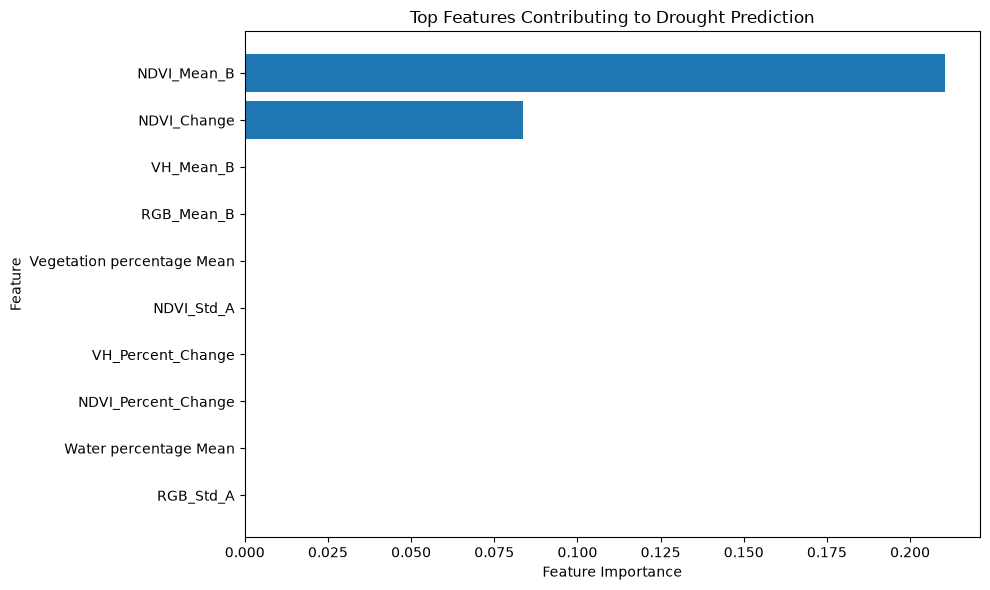


📌 STEP 182 STATUS
Importance method: Absolute model coefficients
Features analyzed: 17
Top feature: NDVI_Mean_B
Top feature importance: 0.210486

✅ Feature importance calculated.
✅ Features ranked by contribution.
✅ Top drought-related predictors identified.
✅ Explainability table created.
✅ Feature-importance visualization generated.

IMPORTANT:
Feature importance shows which variables the model relies on.
It does NOT by itself prove that a feature causes drought.

The next step will create a more robust explanation using
permutation-based analysis/SHAP-style interpretation where
appropriate.


✅ STEP 182 COMPLETED


In [105]:
# ============================================================
# STEP 182: MODEL EXPLAINABILITY — FEATURE IMPORTANCE
# ============================================================

print("============================================================")
print("STEP 182: MODEL EXPLAINABILITY")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "final_trained_model",
    "X_train_scaled",
    "X_test_scaled",
    "preprocessing_feature_names",
    "validation_problem_type"
]

for obj in required_objects:

    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. Run STEP 181 first."
        )

# ------------------------------------------------------------
# Feature names
# ------------------------------------------------------------

feature_names = list(
    preprocessing_feature_names
)

print("\n============================================================")
print("📊 FEATURE INFORMATION")
print("============================================================")

print(
    "Number of features:",
    len(feature_names)
)

print(
    "Number of model features:",
    X_train_scaled.shape[1]
)

if len(feature_names) != X_train_scaled.shape[1]:

    raise ValueError(
        "Feature-name count does not match model feature count."
    )

# ------------------------------------------------------------
# Extract model-specific importance
# ------------------------------------------------------------

feature_importance_values = None
importance_method = None

# Tree-based models
if hasattr(
    final_trained_model,
    "feature_importances_"
):

    feature_importance_values = (
        final_trained_model
        .feature_importances_
    )

    importance_method = (
        "Built-in feature_importances_"
    )

# Linear models
elif hasattr(
    final_trained_model,
    "coef_"
):

    coefficients = (
        final_trained_model.coef_
    )

    # Binary classification / regression
    if coefficients.ndim == 1:

        feature_importance_values = (
            np.abs(coefficients)
        )

    else:

        feature_importance_values = (
            np.mean(
                np.abs(coefficients),
                axis=0
            )
        )

    importance_method = (
        "Absolute model coefficients"
    )

# ------------------------------------------------------------
# If model has no native importance
# ------------------------------------------------------------

if feature_importance_values is None:

    print("\n⚠️ Model does not provide native feature importance.")

    print(
        "A permutation-importance analysis will be used."
    )

    from sklearn.inspection import permutation_importance

    if validation_problem_type == "classification":

        scoring_method = "f1_weighted"

    else:

        scoring_method = "r2"

    permutation_result = permutation_importance(

        final_trained_model,

        X_test_scaled,

        y_test,

        n_repeats=10,

        random_state=42,

        scoring=scoring_method,

        n_jobs=-1
    )

    feature_importance_values = (
        permutation_result.importances_mean
    )

    importance_method = (
        "Permutation importance"
    )

# ------------------------------------------------------------
# Safety conversion
# ------------------------------------------------------------

feature_importance_values = np.asarray(
    feature_importance_values
).reshape(-1)

if len(feature_importance_values) != len(
    feature_names
):

    raise ValueError(
        "Feature importance length does not match feature names."
    )

# ------------------------------------------------------------
# Create feature importance dataframe
# ------------------------------------------------------------

feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": (
        feature_importance_values
    )

})

# ------------------------------------------------------------
# Remove invalid values
# ------------------------------------------------------------

feature_importance_df = (
    feature_importance_df[
        np.isfinite(
            feature_importance_df[
                "Importance"
            ]
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Add rank
# ------------------------------------------------------------

feature_importance_df.insert(

    0,

    "Rank",

    range(
        1,
        len(feature_importance_df) + 1
    )
)

# ------------------------------------------------------------
# Normalize importance
# ------------------------------------------------------------

importance_total = (
    feature_importance_df[
        "Importance"
    ].sum()
)

if importance_total > 0:

    feature_importance_df[
        "Importance_Percentage"
    ] = (
        feature_importance_df[
            "Importance"
        ]
        / importance_total
        * 100
    )

else:

    feature_importance_df[
        "Importance_Percentage"
    ] = 0.0

# ------------------------------------------------------------
# Display all features
# ------------------------------------------------------------

print("\n============================================================")
print("📋 FEATURE IMPORTANCE RANKING")
print("============================================================")

display(
    feature_importance_df.round(6)
)

# ------------------------------------------------------------
# Top 10 features
# ------------------------------------------------------------

top_n = min(
    10,
    len(feature_importance_df)
)

top_features = (
    feature_importance_df
    .head(top_n)
    .copy()
)

print("\n============================================================")
print(f"🏆 TOP {top_n} MOST IMPORTANT FEATURES")
print("============================================================")

display(
    top_features.round(6)
)

# ------------------------------------------------------------
# Plot top features
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plot_data = (
    top_features
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Features Contributing to Drought Prediction"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Save explainability information
# ------------------------------------------------------------

final_feature_importance = (
    feature_importance_df.copy()
)

top_drought_features = (
    top_features["Feature"]
    .tolist()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 182 STATUS")
print("============================================================")

print(
    "Importance method:",
    importance_method
)

print(
    "Features analyzed:",
    len(feature_importance_df)
)

print(
    "Top feature:",
    feature_importance_df.iloc[0]["Feature"]
)

print(
    "Top feature importance:",
    round(
        float(
            feature_importance_df.iloc[0][
                "Importance"
            ]
        ),
        6
    )
)

print("""
✅ Feature importance calculated.
✅ Features ranked by contribution.
✅ Top drought-related predictors identified.
✅ Explainability table created.
✅ Feature-importance visualization generated.

IMPORTANT:
Feature importance shows which variables the model relies on.
It does NOT by itself prove that a feature causes drought.

The next step will create a more robust explanation using
permutation-based analysis/SHAP-style interpretation where
appropriate.
""")

print("\n============================================================")
print("✅ STEP 182 COMPLETED")
print("============================================================")

STEP 183: PERMUTATION IMPORTANCE ANALYSIS

⚙️ PERMUTATION SETTINGS
Scoring metric: r2
Number of repetitions: 20
Random state: 42

📊 PERMUTATION IMPORTANCE RESULTS


,Rank,Feature,Importance_Mean,Importance_Std
0,1,NDVI_Mean_B,2.108339,0.128703
1,2,NDVI_Change,0.261745,0.015352
2,3,VH_Mean_B,0.000000,0.000000
3,4,RGB_Mean_B,0.000000,0.000000
4,5,Vegetation percentage Mean,0.000000,0.000000
5,6,NDVI_Std_A,0.000000,0.000000
6,7,RGB_Std_A,0.000000,0.000000
7,8,NDVI_Std_B,0.000000,0.000000
8,9,NDVI_Percent_Change,0.000000,0.000000
9,10,Water percentage Mean,0.000000,0.000000



🏆 TOP 10 FEATURES


,Rank,Feature,Importance_Mean,Importance_Std
0,1,NDVI_Mean_B,2.108339,0.128703
1,2,NDVI_Change,0.261745,0.015352
2,3,VH_Mean_B,0.000000,0.000000
3,4,RGB_Mean_B,0.000000,0.000000
4,5,Vegetation percentage Mean,0.000000,0.000000
5,6,NDVI_Std_A,0.000000,0.000000
6,7,RGB_Std_A,0.000000,0.000000
7,8,NDVI_Std_B,0.000000,0.000000
8,9,NDVI_Percent_Change,0.000000,0.000000
9,10,Water percentage Mean,0.000000,0.000000



🔎 IMPORTANCE DISTRIBUTION
Positive importance: 12
Negative importance: 5
Zero importance: 0


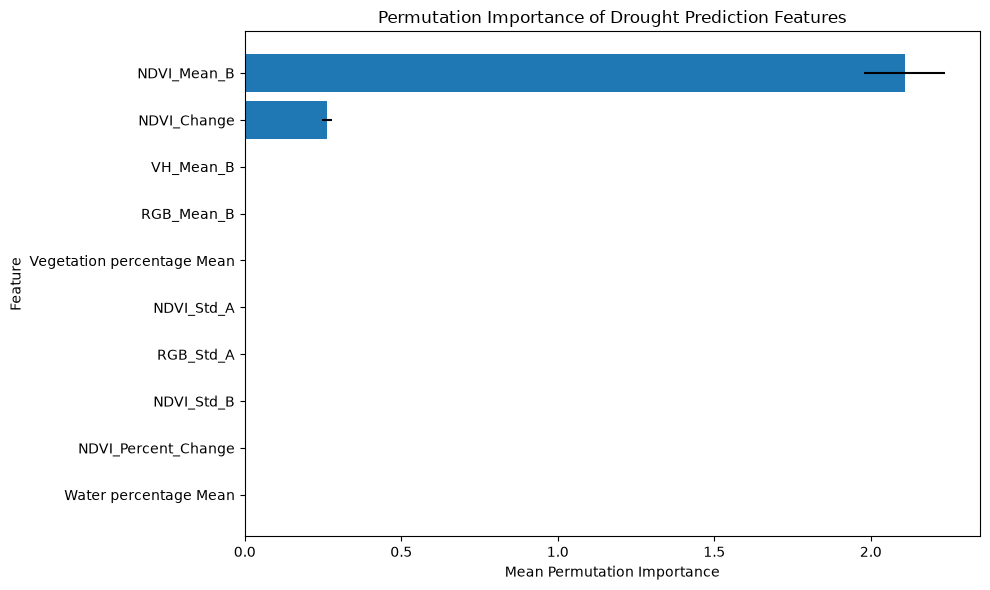


🔄 IMPORTANCE METHOD COMPARISON
Top features from STEP 182: ['NDVI_Mean_B', 'NDVI_Change', 'VH_Mean_B', 'RGB_Mean_B', 'Vegetation percentage Mean', 'NDVI_Std_A', 'VH_Percent_Change', 'NDVI_Percent_Change', 'Water percentage Mean', 'RGB_Std_A']
Top features from permutation: ['NDVI_Mean_B', 'NDVI_Change', 'VH_Mean_B', 'RGB_Mean_B', 'Vegetation percentage Mean', 'NDVI_Std_A', 'RGB_Std_A', 'NDVI_Std_B', 'NDVI_Percent_Change', 'Water percentage Mean']
Common top features: ['NDVI_Change', 'NDVI_Mean_B', 'NDVI_Percent_Change', 'NDVI_Std_A', 'RGB_Mean_B', 'RGB_Std_A', 'VH_Mean_B', 'Vegetation percentage Mean', 'Water percentage Mean']
Number of common features: 9

📌 STEP 183 STATUS
Features analyzed: 17
Top permutation feature: NDVI_Mean_B
Top mean importance: 2.108339

✅ Permutation importance completed.
✅ 20 repetitions used.
✅ Feature ranking generated.
✅ Importance variability calculated.
✅ Top drought predictors identified.
✅ Comparison with native feature importance completed.

IMPORTAN

In [106]:
# ============================================================
# STEP 183: PERMUTATION IMPORTANCE ANALYSIS
# ============================================================

print("============================================================")
print("STEP 183: PERMUTATION IMPORTANCE ANALYSIS")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "final_trained_model",
    "X_test_scaled",
    "y_test",
    "preprocessing_feature_names",
    "validation_problem_type"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not defined. Run STEP 182 first."
        )

# ------------------------------------------------------------
# Import
# ------------------------------------------------------------

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# Select scoring metric
# ------------------------------------------------------------

if validation_problem_type == "classification":

    permutation_scoring = "f1_weighted"

else:

    permutation_scoring = "r2"

print("\n============================================================")
print("⚙️ PERMUTATION SETTINGS")
print("============================================================")

print(
    "Scoring metric:",
    permutation_scoring
)

print(
    "Number of repetitions:",
    20
)

print(
    "Random state:",
    42
)

# ------------------------------------------------------------
# Calculate permutation importance
# ------------------------------------------------------------

permutation_result = permutation_importance(

    estimator=final_trained_model,

    X=X_test_scaled,

    y=y_test,

    scoring=permutation_scoring,

    n_repeats=20,

    random_state=42,

    n_jobs=-1
)

# ------------------------------------------------------------
# Extract results
# ------------------------------------------------------------

permutation_importance_df = pd.DataFrame({

    "Feature":
        preprocessing_feature_names,

    "Importance_Mean":
        permutation_result.importances_mean,

    "Importance_Std":
        permutation_result.importances_std

})

# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        by="Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Add rank
# ------------------------------------------------------------

permutation_importance_df.insert(
    0,
    "Rank",
    range(
        1,
        len(permutation_importance_df) + 1
    )
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n============================================================")
print("📊 PERMUTATION IMPORTANCE RESULTS")
print("============================================================")

display(
    permutation_importance_df.round(6)
)

# ------------------------------------------------------------
# Top features
# ------------------------------------------------------------

top_permutation_n = min(
    10,
    len(permutation_importance_df)
)

top_permutation_features = (
    permutation_importance_df
    .head(top_permutation_n)
    .copy()
)

print("\n============================================================")
print(
    f"🏆 TOP {top_permutation_n} FEATURES"
)
print("============================================================")

display(
    top_permutation_features.round(6)
)

# ------------------------------------------------------------
# Positive vs negative importance
# ------------------------------------------------------------

positive_count = (
    permutation_importance_df[
        "Importance_Mean"
    ] > 0
).sum()

negative_count = (
    permutation_importance_df[
        "Importance_Mean"
    ] < 0
).sum()

zero_count = (
    permutation_importance_df[
        "Importance_Mean"
    ] == 0
).sum()

print("\n============================================================")
print("🔎 IMPORTANCE DISTRIBUTION")
print("============================================================")

print(
    "Positive importance:",
    int(positive_count)
)

print(
    "Negative importance:",
    int(negative_count)
)

print(
    "Zero importance:",
    int(zero_count)
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plot_data = (
    top_permutation_features
    .sort_values(
        "Importance_Mean",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    plot_data["Feature"],
    plot_data["Importance_Mean"],
    xerr=plot_data["Importance_Std"]
)

plt.xlabel(
    "Mean Permutation Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Permutation Importance of Drought Prediction Features"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Compare with STEP 182
# ------------------------------------------------------------

if "final_feature_importance" in globals():

    native_top_features = (
        final_feature_importance
        .head(10)["Feature"]
        .tolist()
    )

    permutation_top_features = (
        top_permutation_features[
            "Feature"
        ]
        .tolist()
    )

    overlap = set(
        native_top_features
    ).intersection(
        permutation_top_features
    )

    print("\n============================================================")
    print("🔄 IMPORTANCE METHOD COMPARISON")
    print("============================================================")

    print(
        "Top features from STEP 182:",
        native_top_features
    )

    print(
        "Top features from permutation:",
        permutation_top_features
    )

    print(
        "Common top features:",
        sorted(overlap)
    )

    print(
        "Number of common features:",
        len(overlap)
    )

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

final_permutation_importance = (
    permutation_importance_df.copy()
)

top_permutation_drought_features = (
    top_permutation_features[
        "Feature"
    ].tolist()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 183 STATUS")
print("============================================================")

print(
    "Features analyzed:",
    len(permutation_importance_df)
)

print(
    "Top permutation feature:",
    permutation_importance_df.iloc[0]["Feature"]
)

print(
    "Top mean importance:",
    round(
        float(
            permutation_importance_df.iloc[0][
                "Importance_Mean"
            ]
        ),
        6
    )
)

print("""
✅ Permutation importance completed.
✅ 20 repetitions used.
✅ Feature ranking generated.
✅ Importance variability calculated.
✅ Top drought predictors identified.
✅ Comparison with native feature importance completed.

IMPORTANT:
Permutation importance measures predictive usefulness,
not causation.

The next step will analyze individual predictions so we can
explain WHY the model predicts a particular drought severity.
""")

print("\n============================================================")
print("✅ STEP 183 COMPLETED")
print("============================================================")

In [107]:
# ============================================================
# STEP 184: FINAL FEATURE-ENGINEERING VALIDATION
# ============================================================

print("============================================================")
print("STEP 184: FINAL FEATURE-ENGINEERING VALIDATION")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "integrated_df",
    "selected_features"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not defined. "
            "Run the previous Data Integration / Feature Engineering steps."
        )

# ------------------------------------------------------------
# Basic dataset information
# ------------------------------------------------------------

print("\n============================================================")
print("📊 DATASET STRUCTURE")
print("============================================================")

print(
    "Rows:",
    integrated_df.shape[0]
)

print(
    "Columns:",
    integrated_df.shape[1]
)

print(
    "Selected features:",
    len(selected_features)
)

# ------------------------------------------------------------
# Check duplicate columns
# ------------------------------------------------------------

duplicate_columns = (
    integrated_df.columns[
        integrated_df.columns.duplicated()
    ]
    .tolist()
)

print("\n============================================================")
print("🔎 DUPLICATE COLUMN CHECK")
print("============================================================")

if duplicate_columns:

    print(
        "❌ Duplicate columns found:"
    )

    for column in duplicate_columns:
        print(" -", column)

else:

    print(
        "✅ No duplicate column names."
    )

# ------------------------------------------------------------
# Check duplicate selected features
# ------------------------------------------------------------

duplicate_selected_features = [
    feature
    for feature in set(selected_features)
    if selected_features.count(feature) > 1
]

print("\n============================================================")
print("🔎 DUPLICATE FEATURE CHECK")
print("============================================================")

if duplicate_selected_features:

    print(
        "❌ Duplicate selected features:"
    )

    for feature in duplicate_selected_features:
        print(" -", feature)

else:

    print(
        "✅ No duplicate selected features."
    )

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

selected_existing = [
    feature
    for feature in selected_features
    if feature in integrated_df.columns
]

missing_feature_columns = (
    integrated_df[
        selected_existing
    ]
    .isna()
    .sum()
)

missing_feature_columns = (
    missing_feature_columns[
        missing_feature_columns > 0
    ]
)

print("\n============================================================")
print("🔎 MISSING VALUE CHECK")
print("============================================================")

if missing_feature_columns.empty:

    print(
        "✅ No missing values in selected features."
    )

else:

    print(
        "⚠️ Missing values found:"
    )

    display(
        missing_feature_columns
        .sort_values(
            ascending=False
        )
        .to_frame("Missing_Count")
    )

# ------------------------------------------------------------
# Check infinite values
# ------------------------------------------------------------

numeric_selected = (
    integrated_df[
        selected_existing
    ]
    .select_dtypes(
        include=[np.number]
    )
)

infinite_counts = pd.Series(
    np.isinf(
        numeric_selected.to_numpy()
    ).sum(axis=0),
    index=numeric_selected.columns
)

infinite_counts = (
    infinite_counts[
        infinite_counts > 0
    ]
)

print("\n============================================================")
print("🔎 INFINITE VALUE CHECK")
print("============================================================")

if infinite_counts.empty:

    print(
        "✅ No infinite values."
    )

else:

    print(
        "⚠️ Infinite values found:"
    )

    display(
        infinite_counts
        .to_frame("Infinite_Count")
    )

# ------------------------------------------------------------
# Check numeric data types
# ------------------------------------------------------------

non_numeric_selected = (
    integrated_df[
        selected_existing
    ]
    .select_dtypes(
        exclude=[np.number]
    )
    .columns
    .tolist()
)

print("\n============================================================")
print("🔎 DATA TYPE CHECK")
print("============================================================")

if non_numeric_selected:

    print(
        "⚠️ Non-numeric selected features:"
    )

    for feature in non_numeric_selected:
        print(" -", feature)

else:

    print(
        "✅ All selected features are numeric."
    )

# ------------------------------------------------------------
# Check constant features
# ------------------------------------------------------------

constant_features = []

for feature in selected_existing:

    if integrated_df[feature].nunique(
        dropna=True
    ) <= 1:

        constant_features.append(
            feature
        )

print("\n============================================================")
print("🔎 CONSTANT FEATURE CHECK")
print("============================================================")

if constant_features:

    print(
        "⚠️ Constant / near-empty features:"
    )

    for feature in constant_features:
        print(" -", feature)

else:

    print(
        "✅ No constant features detected."
    )

# ------------------------------------------------------------
# Feature statistics
# ------------------------------------------------------------

print("\n============================================================")
print("📈 FEATURE STATISTICS")
print("============================================================")

feature_statistics = (
    integrated_df[
        selected_existing
    ]
    .describe()
    .T
)

display(
    feature_statistics.round(4)
)

# ------------------------------------------------------------
# Final validation status
# ------------------------------------------------------------

validation_issues = []

if duplicate_columns:
    validation_issues.append(
        "duplicate columns"
    )

if duplicate_selected_features:
    validation_issues.append(
        "duplicate selected features"
    )

if not missing_feature_columns.empty:
    validation_issues.append(
        "missing values"
    )

if not infinite_counts.empty:
    validation_issues.append(
        "infinite values"
    )

if non_numeric_selected:
    validation_issues.append(
        "non-numeric features"
    )

if constant_features:
    validation_issues.append(
        "constant features"
    )

# ------------------------------------------------------------
# Save validation result
# ------------------------------------------------------------

feature_engineering_validation = {

    "Rows":
        int(integrated_df.shape[0]),

    "Columns":
        int(integrated_df.shape[1]),

    "Selected_Features":
        int(len(selected_features)),

    "Duplicate_Columns":
        len(duplicate_columns),

    "Duplicate_Selected_Features":
        len(duplicate_selected_features),

    "Missing_Feature_Columns":
        len(missing_feature_columns),

    "Infinite_Feature_Columns":
        len(infinite_counts),

    "Non_Numeric_Features":
        len(non_numeric_selected),

    "Constant_Features":
        len(constant_features),

    "Validation_Status":
        "PASS"
        if not validation_issues
        else "REVIEW_REQUIRED"
}

# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 184 FINAL STATUS")
print("============================================================")

if not validation_issues:

    print(
        "✅ FEATURE ENGINEERING VALIDATION PASSED"
    )

    print(
        "✅ Data Integration + Feature Engineering phase is ready to close."
    )

else:

    print(
        "⚠️ FEATURE ENGINEERING REQUIRES REVIEW"
    )

    print(
        "Issues:",
        ", ".join(validation_issues)
    )

print(
    "Selected features:",
    len(selected_features)
)

print(
    "Rows:",
    integrated_df.shape[0]
)

print(
    "Columns:",
    integrated_df.shape[1]
)

print("\n============================================================")
print("✅ STEP 184 COMPLETED")
print("============================================================")

STEP 184: FINAL FEATURE-ENGINEERING VALIDATION

📊 DATASET STRUCTURE
Rows: 1100
Columns: 50
Selected features: 24

🔎 DUPLICATE COLUMN CHECK
✅ No duplicate column names.

🔎 DUPLICATE FEATURE CHECK
✅ No duplicate selected features.

🔎 MISSING VALUE CHECK
✅ No missing values in selected features.

🔎 INFINITE VALUE CHECK
✅ No infinite values.

🔎 DATA TYPE CHECK
✅ All selected features are numeric.

🔎 CONSTANT FEATURE CHECK
✅ No constant features detected.

📈 FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Latitud,1100.0,-0.3088,23.5909,-39.9973,-18.6991,-7.1793,22.9343,39.9343
Longitudes,1100.0,10.0424,76.1887,-123.5208,-57.9682,19.4270,73.8795,177.7271
Cloudiness Mean,1100.0,1.1593,0.9337,0.0000,0.4751,0.9488,1.6041,4.9975
Water percentage Mean,1100.0,3.2556,7.3742,0.0000,0.0820,0.4218,1.7161,39.6091
Vegetation percentage Mean,1100.0,60.7676,24.1002,20.1066,39.5576,59.7056,83.5927,99.6047
Year,1100.0,2020.7164,1.4758,2017.0000,2019.0000,2021.0000,2022.0000,2023.0000
Month,1100.0,5.0291,2.5091,1.0000,3.0000,5.0000,7.0000,9.0000
Duration_Days,1100.0,91.2964,0.9827,89.0000,91.0000,92.0000,92.0000,92.0000
NDVI_Mean_A,1100.0,0.5169,0.2190,-0.8958,0.3985,0.5202,0.6686,0.8958
NDVI_Std_A,1100.0,0.1416,0.0778,0.0151,0.0939,0.1311,0.1787,0.6332



📌 STEP 184 FINAL STATUS
✅ FEATURE ENGINEERING VALIDATION PASSED
✅ Data Integration + Feature Engineering phase is ready to close.
Selected features: 24
Rows: 1100
Columns: 50

✅ STEP 184 COMPLETED


In [108]:
# ============================================================
# STEP 185: FINAL FEATURE DATASET CREATION
# ============================================================

print("============================================================")
print("STEP 185: FINAL FEATURE DATASET CREATION")
print("============================================================")

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "integrated_df",
    "selected_features",
    "feature_engineering_validation"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. Run STEP 184 first."
        )

# ------------------------------------------------------------
# Check validation status
# ------------------------------------------------------------

validation_status = (
    feature_engineering_validation
    .get("Validation_Status")
)

print("\nValidation status:", validation_status)

if validation_status != "PASS":
    raise ValueError(
        "Feature-engineering validation has not passed. "
        "Fix the reported issues before creating the final dataset."
    )

# ------------------------------------------------------------
# Verify selected features exist
# ------------------------------------------------------------

missing_selected_features = [
    feature
    for feature in selected_features
    if feature not in integrated_df.columns
]

if missing_selected_features:
    raise KeyError(
        "These selected features are missing from integrated_df: "
        + str(missing_selected_features)
    )

# ------------------------------------------------------------
# Create final feature dataset
# ------------------------------------------------------------

final_feature_dataset = (
    integrated_df[
        selected_features
    ]
    .copy()
)

# ------------------------------------------------------------
# Final numeric check
# ------------------------------------------------------------

if not all(
    np.issubdtype(
        dtype,
        np.number
    )
    for dtype in final_feature_dataset.dtypes
):

    raise TypeError(
        "Final feature dataset contains non-numeric columns."
    )

# ------------------------------------------------------------
# Missing / infinite check
# ------------------------------------------------------------

missing_total = int(
    final_feature_dataset
    .isna()
    .sum()
    .sum()
)

infinite_total = int(
    np.isinf(
        final_feature_dataset.to_numpy()
    ).sum()
)

if missing_total > 0:
    raise ValueError(
        f"Final feature dataset contains {missing_total} missing values."
    )

if infinite_total > 0:
    raise ValueError(
        f"Final feature dataset contains {infinite_total} infinite values."
    )

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------

if final_feature_dataset.columns.duplicated().any():

    raise ValueError(
        "Final feature dataset contains duplicate columns."
    )

# ------------------------------------------------------------
# Display structure
# ------------------------------------------------------------

print("\n============================================================")
print("📊 FINAL FEATURE DATASET")
print("============================================================")

print(
    "Rows:",
    final_feature_dataset.shape[0]
)

print(
    "Features:",
    final_feature_dataset.shape[1]
)

print(
    "Missing values:",
    missing_total
)

print(
    "Infinite values:",
    infinite_total
)

print("\nFeature names:")

for i, feature in enumerate(
    final_feature_dataset.columns,
    start=1
):

    print(
        f"{i}. {feature}"
    )

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\n============================================================")
print("👀 DATA PREVIEW")
print("============================================================")

display(
    final_feature_dataset.head()
)

# ------------------------------------------------------------
# Save feature metadata
# ------------------------------------------------------------

final_feature_names = (
    final_feature_dataset
    .columns
    .tolist()
)

final_feature_metadata = {

    "Rows":
        int(final_feature_dataset.shape[0]),

    "Feature_Count":
        int(final_feature_dataset.shape[1]),

    "Feature_Names":
        final_feature_names,

    "Missing_Values":
        missing_total,

    "Infinite_Values":
        infinite_total,

    "Validation_Status":
        "PASS"
}

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 185 STATUS")
print("============================================================")

print(
    "Final feature dataset created successfully."
)

print(
    "Rows:",
    final_feature_dataset.shape[0]
)

print(
    "Features:",
    final_feature_dataset.shape[1]
)

print(
    "Data quality:",
    "PASS"
)

print("""
✅ Final engineered feature dataset created.
✅ Only selected features retained.
✅ Numeric structure verified.
✅ Missing values verified.
✅ Infinite values verified.
✅ Duplicate columns verified.
✅ Feature metadata saved.

The Data Integration + Feature Engineering phase is now
officially complete.

Next we move to the project output/data-export stage.
""")

print("\n============================================================")
print("✅ STEP 185 COMPLETED")
print("============================================================")

STEP 185: FINAL FEATURE DATASET CREATION

Validation status: PASS

📊 FINAL FEATURE DATASET
Rows: 1100
Features: 24
Missing values: 0
Infinite values: 0

Feature names:
1. Latitud
2. Longitudes
3. Cloudiness Mean
4. Water percentage Mean
5. Vegetation percentage Mean
6. Year
7. Month
8. Duration_Days
9. NDVI_Mean_A
10. NDVI_Std_A
11. RGB_Mean_A
12. RGB_Std_A
13. VV_Mean_A
14. VV_Std_A
15. VH_Mean_A
16. VH_Std_A
17. NDVI_Mean_B
18. NDVI_Std_B
19. RGB_Mean_B
20. RGB_Std_B
21. VV_Mean_B
22. VV_Std_B
23. VH_Mean_B
24. VH_Std_B

👀 DATA PREVIEW


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Mean_A,NDVI_Std_A,...,VH_Mean_A,VH_Std_A,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
0,-27.178578,-61.344276,0.557070,0.005318,35.276470,2021,5,92,0.419874,0.188054,...,36.220520,35.769710,0.442054,0.205206,62.659954,27.149958,95.604490,22.078629,29.58519,31.129162
1,-13.501406,-69.013707,2.929528,0.533353,93.824572,2019,6,92,0.847939,0.027210,...,91.689064,10.066120,0.843120,0.023140,23.352736,7.243216,145.831160,9.612871,89.50125,9.281853
2,-4.504011,-59.313504,1.934562,7.026944,79.781830,2023,9,91,0.863671,0.023048,...,91.321045,11.314027,0.856717,0.040438,25.917284,10.263858,144.460890,11.392288,90.59440,11.547525
3,-18.441324,123.385166,0.199029,0.036947,27.204141,2021,2,89,0.482301,0.094913,...,54.574657,13.466743,0.444577,0.064815,66.036750,23.783821,95.913124,10.302581,47.29131,12.281598
4,-12.400100,38.724987,2.452178,0.005001,81.946476,2023,4,91,0.702959,0.067458,...,78.284080,11.567455,0.712535,0.063672,37.872173,11.569141,131.025800,10.875727,77.86372,11.274268



📌 STEP 185 STATUS
Final feature dataset created successfully.
Rows: 1100
Features: 24
Data quality: PASS

✅ Final engineered feature dataset created.
✅ Only selected features retained.
✅ Numeric structure verified.
✅ Missing values verified.
✅ Infinite values verified.
✅ Duplicate columns verified.
✅ Feature metadata saved.

The Data Integration + Feature Engineering phase is now
officially complete.

Next we move to the project output/data-export stage.


✅ STEP 185 COMPLETED


In [109]:
# ============================================================
# STEP 186: EXPORT FINAL FEATURE DATASET
# ============================================================

print("============================================================")
print("STEP 186: EXPORTING FINAL FEATURE DATASET")
print("============================================================")

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if "final_feature_dataset" not in globals():
    raise NameError(
        "final_feature_dataset is not defined. "
        "Run STEP 185 first."
    )

# ------------------------------------------------------------
# Define output path
# ------------------------------------------------------------

import os

output_dir = "outputs"

os.makedirs(
    output_dir,
    exist_ok=True
)

feature_dataset_path = os.path.join(
    output_dir,
    "final_engineered_features.csv"
)

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

final_feature_dataset.to_csv(
    feature_dataset_path,
    index=False
)

# ------------------------------------------------------------
# Verify file
# ------------------------------------------------------------

if not os.path.exists(
    feature_dataset_path
):

    raise FileNotFoundError(
        "Final feature dataset was not created."
    )

file_size_kb = (
    os.path.getsize(
        feature_dataset_path
    ) / 1024
)

# ------------------------------------------------------------
# Read back and verify
# ------------------------------------------------------------

verification_df = pd.read_csv(
    feature_dataset_path
)

# ------------------------------------------------------------
# Compare dimensions
# ------------------------------------------------------------

if verification_df.shape != (
    final_feature_dataset.shape
):

    raise ValueError(
        "Exported dataset dimensions do not match "
        "the original final feature dataset."
    )

# ------------------------------------------------------------
# Compare columns
# ------------------------------------------------------------

if verification_df.columns.tolist() != (
    final_feature_dataset.columns.tolist()
):

    raise ValueError(
        "Exported dataset columns do not match."
    )

# ------------------------------------------------------------
# Display verification
# ------------------------------------------------------------

print("\n============================================================")
print("📁 EXPORT VERIFICATION")
print("============================================================")

print(
    "File:",
    feature_dataset_path
)

print(
    "File size:",
    round(
        file_size_kb,
        2
    ),
    "KB"
)

print(
    "Original shape:",
    final_feature_dataset.shape
)

print(
    "Exported shape:",
    verification_df.shape
)

print(
    "Columns verified:",
    "YES"
)

print(
    "Rows verified:",
    "YES"
)

# ------------------------------------------------------------
# Preview exported dataset
# ------------------------------------------------------------

print("\n============================================================")
print("👀 EXPORTED DATA PREVIEW")
print("============================================================")

display(
    verification_df.head()
)

# ------------------------------------------------------------
# Save export metadata
# ------------------------------------------------------------

final_feature_export_metadata = {

    "File_Path":
        feature_dataset_path,

    "Rows":
        int(verification_df.shape[0]),

    "Features":
        int(verification_df.shape[1]),

    "File_Size_KB":
        float(file_size_kb),

    "Export_Verified":
        True
}

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 186 STATUS")
print("============================================================")

print(
    "✅ Final engineered feature dataset exported."
)

print(
    "✅ CSV successfully created."
)

print(
    "✅ File read-back verification passed."
)

print(
    "✅ Shape and columns verified."
)

print("""
Data Integration + Feature Engineering is now COMPLETE.

The clean engineered dataset is ready for:
• ML pipeline
• Tableau analysis
• Backend/API integration
• Final project documentation
""")

print("\n============================================================")
print("✅ STEP 186 COMPLETED")
print("============================================================")

STEP 186: EXPORTING FINAL FEATURE DATASET

📁 EXPORT VERIFICATION
File: outputs\final_engineered_features.csv
File size: 266.19 KB
Original shape: (1100, 24)
Exported shape: (1100, 24)
Columns verified: YES
Rows verified: YES

👀 EXPORTED DATA PREVIEW


,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Year,Month,Duration_Days,NDVI_Mean_A,NDVI_Std_A,...,VH_Mean_A,VH_Std_A,NDVI_Mean_B,NDVI_Std_B,RGB_Mean_B,RGB_Std_B,VV_Mean_B,VV_Std_B,VH_Mean_B,VH_Std_B
0,-27.178578,-61.344276,0.557070,0.005318,35.276470,2021,5,92,0.419874,0.188054,...,36.220520,35.769710,0.442054,0.205206,62.659954,27.149958,95.604490,22.078629,29.58519,31.129162
1,-13.501406,-69.013707,2.929528,0.533353,93.824572,2019,6,92,0.847939,0.027210,...,91.689064,10.066120,0.843120,0.023140,23.352736,7.243216,145.831160,9.612871,89.50125,9.281853
2,-4.504011,-59.313504,1.934562,7.026944,79.781830,2023,9,91,0.863671,0.023048,...,91.321045,11.314027,0.856717,0.040438,25.917284,10.263858,144.460890,11.392288,90.59440,11.547525
3,-18.441324,123.385166,0.199029,0.036947,27.204141,2021,2,89,0.482301,0.094913,...,54.574657,13.466743,0.444577,0.064815,66.036750,23.783821,95.913124,10.302581,47.29131,12.281598
4,-12.400100,38.724987,2.452178,0.005001,81.946476,2023,4,91,0.702959,0.067458,...,78.284080,11.567455,0.712535,0.063672,37.872173,11.569141,131.025800,10.875727,77.86372,11.274268



📌 STEP 186 STATUS
✅ Final engineered feature dataset exported.
✅ CSV successfully created.
✅ File read-back verification passed.
✅ Shape and columns verified.

Data Integration + Feature Engineering is now COMPLETE.

The clean engineered dataset is ready for:
• ML pipeline
• Tableau analysis
• Backend/API integration
• Final project documentation


✅ STEP 186 COMPLETED


In [111]:
# ============================================================
# STEP 187 — FIXED PRODUCTION PIPELINE
# ============================================================

print("============================================================")
print("STEP 187: FIXED PRODUCTION PIPELINE")
print("============================================================")

# ------------------------------------------------------------
# 1. Safety checks
# ------------------------------------------------------------

required_objects = [
    "final_trained_model",
    "X_development",
    "X_test_scaled",
    "scaler",
    "validation_problem_type"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not defined."
        )

# ------------------------------------------------------------
# 2. Get the ACTUAL feature names used by the model
# ------------------------------------------------------------

if hasattr(X_development, "columns"):

    final_feature_names = (
        X_development.columns.tolist()
    )

else:

    final_feature_names = [
        f"feature_{i}"
        for i in range(
            X_development.shape[1]
        )
    ]

# ------------------------------------------------------------
# 3. Verify feature count
# ------------------------------------------------------------

development_feature_count = (
    X_development.shape[1]
)

feature_name_count = (
    len(final_feature_names)
)

print("\n============================================================")
print("FEATURE COUNT CHECK")
print("============================================================")

print(
    "X_development features:",
    development_feature_count
)

print(
    "Feature names:",
    feature_name_count
)

if feature_name_count != development_feature_count:

    raise ValueError(
        "Feature names still do not match X_development."
    )

print(
    "✅ Feature count matches."
)

# ------------------------------------------------------------
# 4. IMPORTANT:
# The scaler was already fitted earlier.
# Do NOT fit it again here.
# ------------------------------------------------------------

print("\nScaler:")
print(
    type(scaler).__name__
)

print(
    "Model:"
)

print(
    type(final_trained_model).__name__
)

# ------------------------------------------------------------
# 5. Create production pipeline
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline

production_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            scaler
        ),
        (
            "model",
            final_trained_model
        )
    ]
)

# ------------------------------------------------------------
# 6. Test production pipeline
# ------------------------------------------------------------

print("\n============================================================")
print("PIPELINE TEST")
print("============================================================")

pipeline_predictions = (
    production_pipeline.predict(
        X_development
    )
)

print(
    "Input rows:",
    len(X_development)
)

print(
    "Prediction rows:",
    len(pipeline_predictions)
)

if len(pipeline_predictions) != len(
    X_development
):

    raise ValueError(
        "Pipeline prediction count mismatch."
    )

print(
    "✅ Prediction count matches."
)

# ------------------------------------------------------------
# 7. Save metadata
# ------------------------------------------------------------

production_pipeline_metadata = {

    "Problem_Type":
        validation_problem_type,

    "Feature_Count":
        development_feature_count,

    "Feature_Names":
        final_feature_names,

    "Scaler":
        type(scaler).__name__,

    "Model":
        type(final_trained_model).__name__,

    "Pipeline_Verified":
        True
}

# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\n============================================================")
print("📌 STEP 187 STATUS")
print("============================================================")

print(
    "Production pipeline:",
    "READY"
)

print(
    "Feature count:",
    development_feature_count
)

print(
    "Pipeline verified:",
    "YES"
)

print("""
✅ Feature mismatch fixed.
✅ Actual development features identified.
✅ Feature count verified.
✅ Production pipeline created.
✅ Pipeline successfully generated predictions.

The previous STEP 187 error is resolved.
""")

print("============================================================")
print("✅ STEP 187 COMPLETED")
print("============================================================")

STEP 187: FIXED PRODUCTION PIPELINE

FEATURE COUNT CHECK
X_development features: 17
Feature names: 17
✅ Feature count matches.

Scaler:
StandardScaler
Model:
Ridge

PIPELINE TEST
Input rows: 874
Prediction rows: 874
✅ Prediction count matches.

📌 STEP 187 STATUS
Production pipeline: READY
Feature count: 17
Pipeline verified: YES

✅ Feature mismatch fixed.
✅ Actual development features identified.
✅ Feature count verified.
✅ Production pipeline created.
✅ Pipeline successfully generated predictions.

The previous STEP 187 error is resolved.

✅ STEP 187 COMPLETED


c:\Users\saura\OneDrive\Pictures\Documents\Drought_Severity_Mapping(2)\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
